In [1]:
# База, знать и импортить всегда надо

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Продвинутое МО

## Задача классификации: метод опорных векторов

In [3]:
DATASET_PATH = "datasets/persons_pics_train.zip" # Из упражнения 1.1
RESERVED_DATASET_PATH = "datasets/persons_pics_reserved.zip" # Из упражнения 1.2

### Упраженение 1.1

In [4]:
import os
import zipfile

CSV_FILENAME = "persons_pics_train.csv"

with zipfile.ZipFile(DATASET_PATH) as z:
    with z.open(CSV_FILENAME) as f:
        df = pd.read_csv(f)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,2905,2906,2907,2908,2909,2910,2911,2912,2913,label
0,0.379085,0.312418,0.352941,0.445752,0.466667,0.473203,0.484967,0.513725,0.545098,0.571242,...,0.597386,0.620915,0.732026,0.852288,0.921569,0.937255,0.941176,0.950327,0.946405,John Ashcroft
1,0.450980,0.466667,0.512418,0.509804,0.450980,0.458824,0.516340,0.571242,0.607843,0.618301,...,0.430065,0.453595,0.679739,0.934640,0.985621,0.981699,0.963399,0.938562,0.874510,Ariel Sharon
2,0.589542,0.614379,0.688889,0.729412,0.738562,0.775163,0.789543,0.806536,0.820915,0.837908,...,0.733333,0.854902,0.937255,0.624837,0.128105,0.082353,0.107190,0.095425,0.100654,Colin Powell
3,0.390850,0.432680,0.499346,0.562091,0.597386,0.644444,0.670588,0.650980,0.637908,0.639216,...,0.713726,0.898039,0.968627,0.959477,0.832680,0.443137,0.266667,0.303268,0.313725,Jean Chretien
4,0.645752,0.626144,0.605229,0.585621,0.602614,0.664052,0.701961,0.709804,0.733333,0.771242,...,0.115033,0.129412,0.132026,0.129412,0.155556,0.171242,0.167320,0.176471,0.183007,Colin Powell


In [5]:
# Question 1: Определите число различных людей, фотографии которых содержатся в рассматриваемом наборе данных.
num_cls = df['label'].nunique()
num_cls

12

In [6]:
# Question 2: Постройте гистограмму распределения объектов по классам и вычислите долю объектов каждого класса.
# Введите долю объектов класса Serena Williams.

TARGET_CLASS = "Serena Williams"

labels_perc = df['label'].value_counts(normalize=True)

print(TARGET_CLASS, "=", round(labels_perc[TARGET_CLASS], 3))
print("\n All classes:")
labels_perc

Serena Williams = 0.033

 All classes:


label
George W Bush        0.340121
Colin Powell         0.151584
Tony Blair           0.092006
Donald Rumsfeld      0.077677
Gerhard Schroeder    0.070136
Ariel Sharon         0.049020
Hugo Chavez          0.045249
Junichiro Koizumi    0.038462
Jean Chretien        0.035445
John Ashcroft        0.033937
Serena Williams      0.033183
Jacques Chirac       0.033183
Name: proportion, dtype: float64

In [7]:
# Question 3: На основе имеющихся данных поставьте в соответствие каждому человеку один вектор, 
# координаты которого являются средним соответствующих координат всех векторов, отождествленных с этим человеком.
# Введите координату с индексом 0 усредненного вектора, соответствующего Tony Blair.

TARGET_CLASS = "Tony Blair"
TARGET_INDEX = 0

avg_vec = df.groupby('label').mean()
res_avg = avg_vec[str(TARGET_INDEX)][TARGET_CLASS]

print(round(res_avg, 3))

0.328


Ariel Sharon, Colin Powell, Donald Rumsfeld, George W Bush
Gerhard Schroeder, Hugo Chavez, Jacques Chirac, Jean Chretien
John Ashcroft, Junichiro Koizumi, Serena Williams, Tony Blair


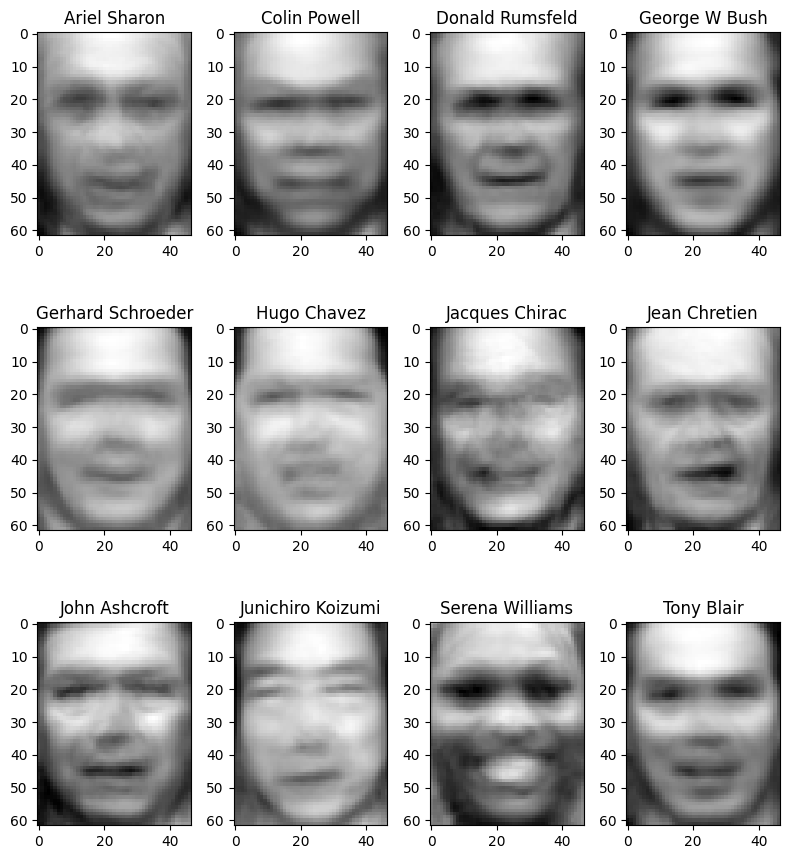

In [8]:
# Question 4: Используя усредненные векторы, постройте изображения всех людей из набора данных. Определите, кто изображен на картинке.
# Введите нужное имя так, как оно написано в колонке label.

# Тут нужно поглядеть какая наиболее похожа глазами, как найдёте можно скопировать
TARGET_IMAGE_PATH = ""

indexes = list(avg_vec.index)
imgs = avg_vec.to_numpy().reshape((num_cls, 62, 47))

cols = int(np.ceil(np.sqrt(num_cls)))
rows = int(np.ceil(num_cls / cols))

for i in range(rows):
    print(", ".join(indexes[i * cols:(i+1)*cols]))

plt.figure(figsize=(cols * 2, rows * 3))

for i in range(num_cls):
    plt.subplot(rows, cols, i + 1)
    plt.title(indexes[i])
    plt.imshow(imgs[i], 'gray')

plt.tight_layout()
plt.show()

Similarity between Colin Powell and Colin Powell: 0.995


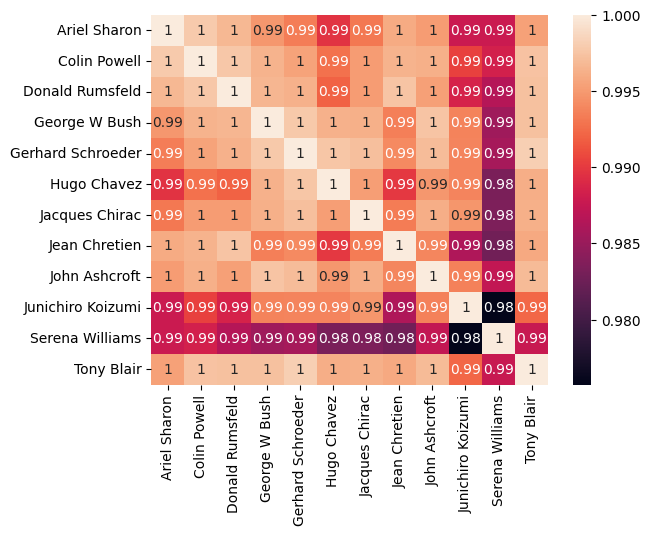

In [9]:
# Question 5: Постройте матрицу схожести объектов на основе их усредненных векторов. В качестве меры схожести используйте косинусное сходство.
# Введите значение косинусного сходства между парой усредненных векторов Colin Powell и Gerhard Schroeder.
from sklearn.metrics.pairwise import cosine_similarity

TARGET_CLASS_1 = "Colin Powell"
TARGET_CLASS_2 = "Gerhard Schroeder"

sim_matrix = cosine_similarity(imgs.reshape(num_cls, -1))

sim_df = pd.DataFrame(sim_matrix, columns=indexes, index=indexes)

sns.heatmap(sim_df, annot=True)

print(f"Similarity between {TARGET_CLASS_1} and {TARGET_CLASS_1}:", round(sim_df[TARGET_CLASS_1][TARGET_CLASS_2], 3))

In [76]:
# Question 6: 
# Первое приближение: базовый SVM классификатор с линейным ядром.
# При помощи train_test_split() разбейте набор данных на обучающую и тестовую выборки с параметрами test_size=0.2, random_state=23. 
# Используйте стратификацию по колонке label. 
# Обучите модель SVC() на тренировочном наборе данных со следующими параметрами: kernel='linear', random_state=23. 
# Оцените модель на тестовых данных.
# Вычислите f1_score(average='weighted') модели на тестовых данных.

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

RANDOM_STATE = 23 # for train_test_split and SVC
TEST_SIZE = 0.2
SVC_KERNEL = 'linear'

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('label', axis=1), 
    df['label'], 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=df['label']
)

svc = SVC(kernel=SVC_KERNEL, random_state=RANDOM_STATE)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print("F1 score:", round(f1_score(y_test, y_pred, average='weighted'), 3))

F1 score: 0.778


In [77]:
# Question 7:
# Подбор гиперпараметров
# Используя GridSearchCV(), осуществите подбор гиперпараметров на основе следующих значений:
# tuned_parameters = [{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'gamma': [1e-3, 1e-4],
#                     'C': [1, 10, 100, 1000], 'class_weight': [None, 'balanced'], 'random_state':[23]}]
# cv = GridSearchCV(SVC(), tuned_parameters, refit=True, verbose=3)

from sklearn.model_selection import GridSearchCV

tuned_parameters = [{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'gamma': [1e-3, 1e-4],
                    'C': [1, 10, 100, 1000], 'class_weight': [None, 'balanced'], 'random_state':[RANDOM_STATE]}]

cv = GridSearchCV(SVC(), tuned_parameters, refit=True, verbose=3)

cv.fit(X_train, y_train)
sorted(cv.cv_results_.keys())

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.731 total time=   0.4s
[CV 2/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.769 total time=   0.3s
[CV 3/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.769 total time=   0.3s
[CV 4/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.750 total time=   0.4s
[CV 5/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.811 total time=   0.3s
[CV 1/5] END C=1, class_weight=None, gamma=0.001, kernel=poly, random_state=23;, score=0.354 total time=   0.4s
[CV 2/5] END C=1, class_weight=None, gamma=0.001, kernel=poly, random_state=23;, score=0.382 total time=   0.4s
[CV 3/5] END C=1, class_weight=None, gamma=0.001, kernel=poly, random_state=23;, score=0.368 total time=   0.4s
[CV 4/5] END C=1, class_weight=N

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_C',
 'param_class_weight',
 'param_gamma',
 'param_kernel',
 'param_random_state',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [78]:
print("C:", cv.best_params_["C"])
print("gamma:", cv.best_params_["gamma"])
print("kernel:", cv.best_params_["kernel"])

C: 1000
gamma: 0.0001
kernel: sigmoid


In [79]:
# Question 8:
# Выполните предсказание для тестовых данных при помощи лучшей полученной модели.
# Вычислите f1_score(average='weighted') модели на тестовых данных.

svc = SVC(**cv.best_params_)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
print("F1 score:", round(f1_score(y_test, y_pred, average='weighted'), 3))

F1 score: 0.771


In [71]:
# Question 9:
# Обучите модель PCA(svd_solver='full') на тренировочных данных и определите минимальное количество компонент, 
# необходимое для того, чтобы уровень объясненной дисперсии был больше 0.95.

TARGET_VARIENCE = 0.95

from sklearn.decomposition import PCA

n_components = min(X_train.shape)

pca = PCA(n_components=n_components, svd_solver='full')
pca.fit(X_train)

evr_cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(evr_cumsum > TARGET_VARIENCE) + 1

print("Num components:", n_components)

Num components: 173


In [73]:
# Question 10:
# Заново обучите модель PCA(svd_solver='full') на тренировочных данных с использованием полученного числа ГК. 
# Примените полученное преобразование для тренировочных и тестовых данных. 
# Для полученных после PCA данных аналогично проделанному ранее, то есть используя GridSearchCV(), 
# осуществите подбор гиперпараметров из указанных ранее диапазонов. 
# Отдельно обратите внимание на время обучения моделей. 
# Определите следующие параметры лучшей полученной модели (cv.best_params_).

pca = PCA(n_components=n_components, svd_solver='full')
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

cv = GridSearchCV(SVC(), tuned_parameters, refit=True, verbose=3)

cv.fit(X_train_pca, y_train)
print()
print("C:", cv.best_params_["C"])
print("gamma:", cv.best_params_["gamma"])
print("kernel:", cv.best_params_["kernel"])

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.731 total time=   0.1s
[CV 2/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.759 total time=   0.0s
[CV 3/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.736 total time=   0.0s
[CV 4/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.759 total time=   0.0s
[CV 5/5] END C=1, class_weight=None, gamma=0.001, kernel=linear, random_state=23;, score=0.774 total time=   0.0s
[CV 1/5] END C=1, class_weight=None, gamma=0.001, kernel=poly, random_state=23;, score=0.340 total time=   0.0s
[CV 2/5] END C=1, class_weight=None, gamma=0.001, kernel=poly, random_state=23;, score=0.344 total time=   0.0s
[CV 3/5] END C=1, class_weight=None, gamma=0.001, kernel=poly, random_state=23;, score=0.340 total time=   0.0s
[CV 4/5] END C=1, class_weight=N

In [75]:
# Question 11:
# Выполните предсказание для тестовых данных при помощи лучшей полученной модели.
# Вычислите f1_score(average='weighted') модели на тестовых данных.

svc = SVC(**cv.best_params_)
svc.fit(X_train_pca, y_train)

y_pred = svc.predict(X_test_pca)
print("F1 score:", round(f1_score(y_test, y_pred, average='weighted'), 3))

F1 score: 0.767


### Упраженение 1.2

In [10]:
# Используя весь датасет из предыдущего задания как обучающий, выполните предсказания для следующего набора данных. 
# Для успешного выполнения задания необходимо, чтобы ваш результат превысил пороговое значение, равное 0.824. 
# В качестве метрики используется f1_score(average='weighted'). В ответ запишите предсказания в виде списка, 
# например: ['George W Bush', 'Ariel Sharon', 'Tony Blair']

import os
import zipfile

# Названия файлов в zip-архивах
CSV_FILENAME = "persons_pics_train.csv"
RESERVED_CSV_FILENAME = "persons_pics_reserved.csv"

with zipfile.ZipFile(DATASET_PATH) as z:
    with z.open(CSV_FILENAME) as f:
        df = pd.read_csv(f)

with zipfile.ZipFile(RESERVED_DATASET_PATH) as z:
    with z.open(RESERVED_CSV_FILENAME) as f:
        reserved_df = pd.read_csv(f)

print(df.shape)
print(reserved_df.shape)

(1326, 2915)
(234, 2914)


In [11]:
from sklearn.decomposition import PCA

TARGET_VARIENCE = 0.98

X, y = df.drop('label', axis=1).to_numpy(), df['label']

n_components = min(X.shape)

pca = PCA(n_components=n_components, svd_solver='full')
pca.fit(X)

evr_cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(evr_cumsum > TARGET_VARIENCE) + 1

print("Num components:", n_components)

Num components: 331


In [241]:
from sklearn.neural_network import MLPClassifier

pca = PCA(n_components=n_components, svd_solver='full')
X = pca.fit_transform(X)
reserved_X = pca.transform(reserved_df)

cls = MLPClassifier(hidden_layer_sizes=(256, 128), random_state=23)
cls.fit(X, y)

y_pred = cls.predict(reserved_X)
# print("F1 score:", round(f1_score(y_test, y_pred, average='weighted'), 3))
print(y_pred.tolist())

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


['George W Bush', 'Ariel Sharon', 'Tony Blair', 'Jacques Chirac', 'Tony Blair', 'Colin Powell', 'Donald Rumsfeld', 'Colin Powell', 'Tony Blair', 'Gerhard Schroeder', 'Donald Rumsfeld', 'Hugo Chavez', 'George W Bush', 'Hugo Chavez', 'Colin Powell', 'George W Bush', 'Ariel Sharon', 'Colin Powell', 'Colin Powell', 'Gerhard Schroeder', 'Donald Rumsfeld', 'George W Bush', 'Colin Powell', 'George W Bush', 'George W Bush', 'Donald Rumsfeld', 'Donald Rumsfeld', 'Tony Blair', 'Serena Williams', 'Jean Chretien', 'George W Bush', 'George W Bush', 'George W Bush', 'George W Bush', 'George W Bush', 'Donald Rumsfeld', 'Donald Rumsfeld', 'Colin Powell', 'George W Bush', 'Gerhard Schroeder', 'Colin Powell', 'Donald Rumsfeld', 'Gerhard Schroeder', 'George W Bush', 'Tony Blair', 'George W Bush', 'George W Bush', 'Tony Blair', 'Colin Powell', 'Tony Blair', 'Serena Williams', 'Jean Chretien', 'Tony Blair', 'George W Bush', 'Colin Powell', 'George W Bush', 'George W Bush', 'George W Bush', 'George W Bush',

## Задача классификации: деревья принятия решений

In [2]:
DATASET_PATH = "datasets/Bank_Personal_Loan_Modelling_train.csv" # Из упражнения 2.1
RESERVED_DATASET_PATH = "datasets/Bank_Personal_Loan_Modelling_reserved.csv" # Из упражнения 2.2

### Упражнение 2.1

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [54]:
df = pd.read_csv(DATASET_PATH)
df = df.drop('ID', axis=1)

print(df.shape)
df.head()

(4000, 13)


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,60,36,89,91745,2,2.8,1,0,0,0,0,1,0
1,44,19,30,91423,1,0.5,3,0,0,0,0,1,0
2,26,0,19,93014,1,0.1,2,121,0,0,0,1,0
3,34,9,41,92101,2,0.1,1,161,0,0,0,1,1
4,56,32,51,92780,4,1.5,1,0,0,0,0,0,0


#### 1. Разведочный анализ данных

<Axes: >

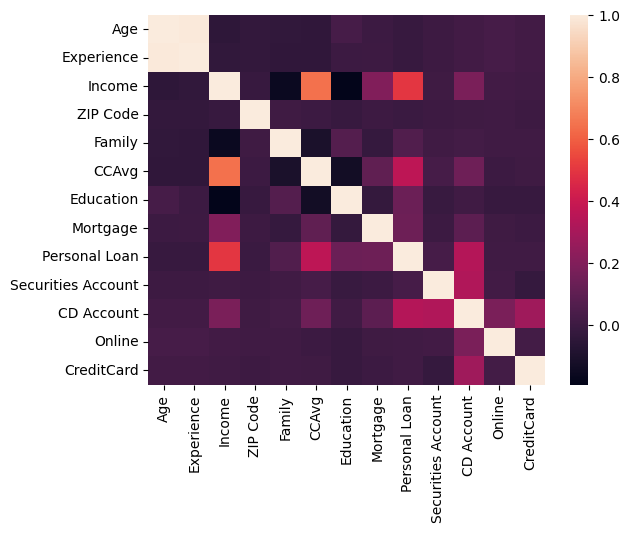

In [55]:
sns.heatmap(df.corr())

In [56]:
corr_matrix = df.corr()
corr_matrix[corr_matrix == 1] = 0

print("Pair of most correlated:", ', '.join(corr_matrix.max().index[:2]))

Pair of most correlated: Age, Experience


In [57]:
least_corr = corr_matrix.abs().sum().idxmin()

df = df.drop(least_corr, axis=1)

print("Least correlated:", least_corr)

Least correlated: ZIP Code


#### 2. Предварительная подготовка данных

In [58]:
min_experience = df['Experience'].min()
df['Experience'] -= min_experience

print('Experience mean:', df['Experience'].mean())

Experience mean: 23.19625


In [59]:
df['CCAvg'] *= 12

print('CCAvg mean:', df['CCAvg'].mean())

CCAvg mean: 23.06166


Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account',
       'Online', 'CreditCard'],
      dtype='object')


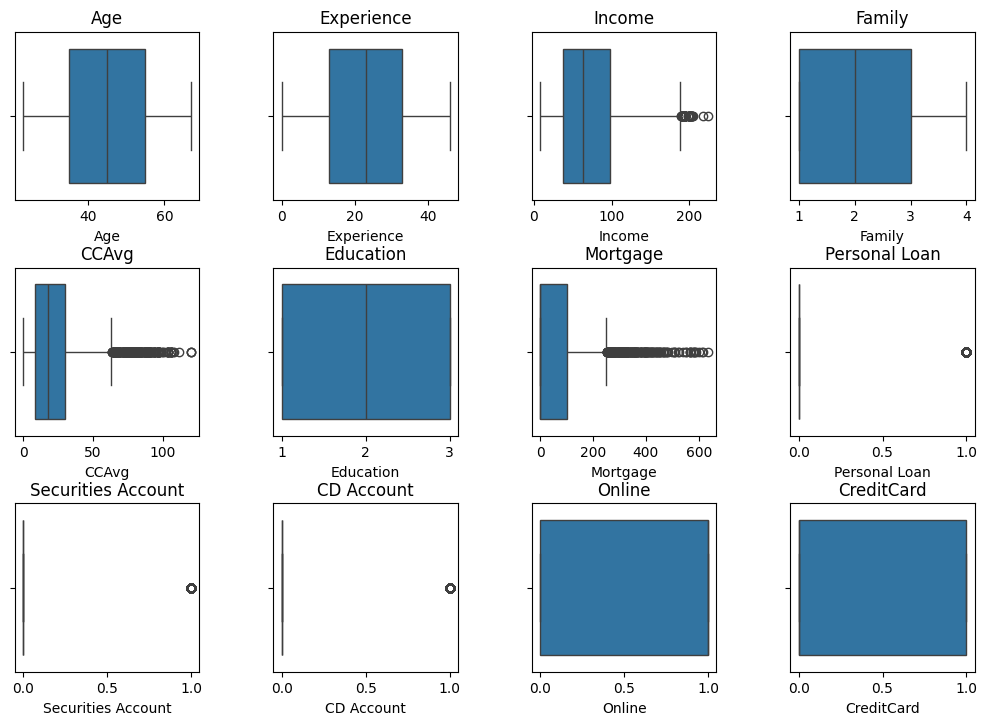

In [60]:
num_labels = len(df.columns)
sz = int((num_labels - 1)**(1/2)) + 1

print(df.columns)

plt.figure(figsize=(12, 8))

for i, label in enumerate(df.columns):
    plt.subplot((num_labels - 1) // sz + 1, sz, i + 1)

    sns.boxplot(df[label], orient="h")
    plt.title(label)

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)


Ищем картинку

In [61]:
from scipy import stats

continuous_fetures = df.columns[[len(df[col].unique()) > 4 for col in df.columns]]

num_sigma = 4
zscore = np.abs(stats.zscore(df[continuous_fetures]))
outliers = (zscore >= num_sigma).sum(axis=0)

print("Num outliers in each column:", list(continuous_fetures), outliers, sep='\n', end='\n\n')
print('Feature with most outliers:', continuous_fetures[np.argmax(outliers)])

Num outliers in each column:
['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
[ 0  0  0  6 30]

Feature with most outliers: Mortgage


In [62]:
most_outliers = (zscore > 3)[:, np.argmax(outliers)]

print("Z-score > 3:", most_outliers.sum())

Z-score > 3: 83


In [63]:
df = df[~most_outliers]

print("Len of data:", len(df))

Len of data: 3917


#### 3. Построение моделей

In [14]:
RANDOM_STATE = 3

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Personal Loan", axis=1),
    df["Personal Loan"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["Personal Loan"]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3133, 11)
Test shape: (784, 11)


In [19]:
def train_dtc(**kwargs):
    dtc = DecisionTreeClassifier(random_state=RANDOM_STATE, **kwargs)
    dtc.fit(X_train, y_train)

    print("F1 score (%s):" % kwargs, round(f1_score(y_test, dtc.predict(X_test)), 3))

    return dtc

In [20]:
# Базовый алгоритм
dtc = train_dtc(criterion='gini')
dtc = train_dtc(criterion='entropy')

# Учет дисбаланса соотношения классов
dtc = train_dtc(criterion='gini', class_weight='balanced')
dtc = train_dtc(criterion='entropy', class_weight='balanced')

F1 score ({'criterion': 'gini'}): 0.913
F1 score ({'criterion': 'entropy'}): 0.897
F1 score ({'criterion': 'gini', 'class_weight': 'balanced'}): 0.872
F1 score ({'criterion': 'entropy', 'class_weight': 'balanced'}): 0.904


In [35]:
# Upsampling обучающей выборки

y_train.value_counts(normalize=True)

Personal Loan
0    0.911267
1    0.088733
Name: proportion, dtype: float64

In [ ]:
%pip install imblearn

In [21]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = sm.fit_resample(X_train, y_train)

y_train.value_counts()

Personal Loan
0    2855
1    2855
Name: count, dtype: int64

In [22]:
dtc = train_dtc(criterion='gini')
dtc = train_dtc(criterion='entropy')

F1 score ({'criterion': 'gini'}): 0.778
F1 score ({'criterion': 'entropy'}): 0.863


### Упражнение 2.2

In [ ]:
# Используется df из прошлого упражнения (чтобы не копировать предобработку)

In [52]:
reserved_df = pd.read_csv(RESERVED_DATASET_PATH)
reserved_df = reserved_df.drop(['ID', 'ZIP Code'], axis=1)

print(reserved_df.shape)
reserved_df.head()

(1000, 11)


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,64,39,23,3,0.5,1,0,1,0,0,0
1,33,9,184,2,4.8,2,0,0,0,0,0
2,58,33,22,3,0.2,1,0,0,0,1,0
3,54,24,61,4,2.0,3,0,1,0,1,0
4,55,29,49,2,0.8,3,220,0,0,0,1


In [64]:
reserved_df['Experience'] -= min_experience
reserved_df['CCAvg'] *= 12

In [ ]:
%pip install xgboost

In [82]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [33]:
MODEL_PARAMS = {
    'objective': 'binary:logistic',
    "booster": "gbtree",
    'tree_method': 'hist',
}
SEEDS = [
    42, 672, 961, 956, 389, 
    387, 438, 379, 755, 173
]

#### Params selection process (you don't need this)

In [31]:
# Создаем DMatrix

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Personal Loan", axis=1).to_numpy(),
    df["Personal Loan"].to_numpy(),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["Personal Loan"]
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_test, label=y_test)

In [47]:
def f1_xgb(preds, dtrain):
    labels = dtrain.get_label()
    # Расчет взвешенной MAE
    pred_clases = np.round(preds)
    f1 = f1_score(labels, pred_clases)
    return 'f1', f1

def train_batch_models(params, dtrain, dval = None, num_boost_round=1000, verbose_eval=500):
    best_model = None
    best_score = None
    for seed in SEEDS:
        params['seed'] = seed

        evals = [(dtrain, 'train')]
        if dval is not None:
            evals.append((dval, 'val'))
    
        model = xgb.train(
            params, dtrain, 
            num_boost_round=num_boost_round,
            evals=evals,
            custom_metric=f1_xgb,
            early_stopping_rounds=50,
            verbose_eval=verbose_eval
        )

        if dval is not None:
            _, score = f1_xgb(model.predict(dval), dval)
        else:
            _, score = f1_xgb(model.predict(dtrain), dtrain)

        if best_score is None or best_score < score:
            best_score = score 
            best_model = model

    return best_model, best_score


In [48]:
import optuna

# Обучение моделей с подбором гиперпараметров
def objective(trial):
    params = {
        # "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.1),
        "lambda": trial.suggest_float("lambda", 1e-5, 1.0, log=True),
        'gamma': trial.suggest_float("gamma", 1e-5, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        'max_depth': trial.suggest_int("max_depth", 4, 10),
        'min_child_weight': trial.suggest_int("min_child_weight", 10, 100)
    }
    params.update(MODEL_PARAMS)

    _, score = train_batch_models(params, dtrain, dval)
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
study.best_params

[I 2025-11-24 17:42:26,007] A new study created in memory with name: no-name-d5af3a09-f2f5-448c-9533-422552c5db52


[0]	train-logloss:0.28871	train-f1:0.00000	val-logloss:0.29008	val-f1:0.00000
[50]	train-logloss:0.14148	train-f1:0.62716	val-logloss:0.15075	val-f1:0.61386
[0]	train-logloss:0.29345	train-f1:0.00000	val-logloss:0.29392	val-f1:0.00000
[50]	train-logloss:0.14021	train-f1:0.60652	val-logloss:0.14752	val-f1:0.62136
[0]	train-logloss:0.29389	train-f1:0.00000	val-logloss:0.29445	val-f1:0.00000
[50]	train-logloss:0.13765	train-f1:0.65048	val-logloss:0.14644	val-f1:0.60000
[0]	train-logloss:0.28814	train-f1:0.00000	val-logloss:0.29013	val-f1:0.00000
[50]	train-logloss:0.13940	train-f1:0.66346	val-logloss:0.14726	val-f1:0.59406
[0]	train-logloss:0.29372	train-f1:0.00000	val-logloss:0.29424	val-f1:0.00000
[50]	train-logloss:0.13844	train-f1:0.63570	val-logloss:0.14396	val-f1:0.66038
[0]	train-logloss:0.28827	train-f1:0.00000	val-logloss:0.29025	val-f1:0.00000
[50]	train-logloss:0.14155	train-f1:0.63391	val-logloss:0.15011	val-f1:0.59406
[0]	train-logloss:0.28754	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:26,914] Trial 0 finished with value: 0.660377358490566 and parameters: {'learning_rate': 0.04614766521131852, 'lambda': 0.0005185441377583365, 'gamma': 0.6630232458756392, 'alpha': 0.00014645171665758841, 'subsample': 0.6932868034143527, 'colsample_bytree': 0.8555476930333387, 'max_depth': 6, 'min_child_weight': 41}. Best is trial 0 with value: 0.660377358490566.


[0]	train-logloss:0.29360	train-f1:0.00000	val-logloss:0.29485	val-f1:0.00000
[50]	train-logloss:0.12688	train-f1:0.74041	val-logloss:0.13366	val-f1:0.72072
[0]	train-logloss:0.29534	train-f1:0.00000	val-logloss:0.29629	val-f1:0.00000
[50]	train-logloss:0.14009	train-f1:0.57069	val-logloss:0.14671	val-f1:0.58586
[0]	train-logloss:0.29540	train-f1:0.00000	val-logloss:0.29639	val-f1:0.00000
[50]	train-logloss:0.13606	train-f1:0.65865	val-logloss:0.14420	val-f1:0.58000
[0]	train-logloss:0.29362	train-f1:0.00000	val-logloss:0.29487	val-f1:0.00000
[50]	train-logloss:0.13319	train-f1:0.67773	val-logloss:0.14101	val-f1:0.59406
[0]	train-logloss:0.29535	train-f1:0.00000	val-logloss:0.29630	val-f1:0.00000
[50]	train-logloss:0.14348	train-f1:0.59446	val-logloss:0.14757	val-f1:0.58000
[0]	train-logloss:0.29372	train-f1:0.00000	val-logloss:0.29501	val-f1:0.00000
[50]	train-logloss:0.13845	train-f1:0.64059	val-logloss:0.14540	val-f1:0.58586
[0]	train-logloss:0.29350	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:27,726] Trial 1 finished with value: 0.7207207207207207 and parameters: {'learning_rate': 0.023233415340226646, 'lambda': 0.0007031026816552044, 'gamma': 4.561872440208338e-05, 'alpha': 1.1316920052644548e-05, 'subsample': 0.9650318891607832, 'colsample_bytree': 0.8051773947207754, 'max_depth': 5, 'min_child_weight': 28}. Best is trial 1 with value: 0.7207207207207207.


[0]	train-logloss:0.28424	train-f1:0.00000	val-logloss:0.28593	val-f1:0.00000
[50]	train-logloss:0.08392	train-f1:0.81988	val-logloss:0.09186	val-f1:0.79339
[0]	train-logloss:0.28830	train-f1:0.00000	val-logloss:0.28844	val-f1:0.00000
[50]	train-logloss:0.08648	train-f1:0.82546	val-logloss:0.09548	val-f1:0.77586
[0]	train-logloss:0.28865	train-f1:0.00000	val-logloss:0.28899	val-f1:0.00000
[50]	train-logloss:0.08664	train-f1:0.81818	val-logloss:0.09656	val-f1:0.76522
[0]	train-logloss:0.28396	train-f1:0.00000	val-logloss:0.28615	val-f1:0.00000
[50]	train-logloss:0.08544	train-f1:0.82135	val-logloss:0.09554	val-f1:0.77586
[0]	train-logloss:0.28881	train-f1:0.00000	val-logloss:0.28926	val-f1:0.00000
[50]	train-logloss:0.08876	train-f1:0.80753	val-logloss:0.09788	val-f1:0.76923
[0]	train-logloss:0.28387	train-f1:0.00000	val-logloss:0.28510	val-f1:0.00000
[50]	train-logloss:0.08553	train-f1:0.81237	val-logloss:0.09260	val-f1:0.80992
[0]	train-logloss:0.28289	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:28,529] Trial 2 finished with value: 0.8099173553719008 and parameters: {'learning_rate': 0.06351857466166731, 'lambda': 1.6731298079901988e-05, 'gamma': 0.02746177370450444, 'alpha': 0.01971801412159598, 'subsample': 0.6116973129929517, 'colsample_bytree': 0.8888725637911565, 'max_depth': 6, 'min_child_weight': 21}. Best is trial 2 with value: 0.8099173553719008.


[0]	train-logloss:0.29552	train-f1:0.00000	val-logloss:0.29679	val-f1:0.00000
[50]	train-logloss:0.16836	train-f1:0.00000	val-logloss:0.17553	val-f1:0.00000
[0]	train-logloss:0.29676	train-f1:0.00000	val-logloss:0.29782	val-f1:0.00000
[50]	train-logloss:0.17053	train-f1:0.00000	val-logloss:0.17721	val-f1:0.00000
[0]	train-logloss:0.29678	train-f1:0.00000	val-logloss:0.29784	val-f1:0.00000
[50]	train-logloss:0.17173	train-f1:0.00000	val-logloss:0.17859	val-f1:0.00000
[0]	train-logloss:0.29551	train-f1:0.00000	val-logloss:0.29679	val-f1:0.00000
[50]	train-logloss:0.17075	train-f1:0.00000	val-logloss:0.17781	val-f1:0.00000
[0]	train-logloss:0.29680	train-f1:0.00000	val-logloss:0.29786	val-f1:0.00000
[50]	train-logloss:0.17775	train-f1:0.00000	val-logloss:0.18227	val-f1:0.00000
[0]	train-logloss:0.29554	train-f1:0.00000	val-logloss:0.29681	val-f1:0.00000
[50]	train-logloss:0.17229	train-f1:0.00000	val-logloss:0.17925	val-f1:0.00000
[0]	train-logloss:0.29553	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:29,322] Trial 3 finished with value: 0.0 and parameters: {'learning_rate': 0.015759869633484323, 'lambda': 0.007772296155855642, 'gamma': 0.006218242356109799, 'alpha': 0.019416051490415524, 'subsample': 0.9915379529615709, 'colsample_bytree': 0.8260275995368125, 'max_depth': 5, 'min_child_weight': 36}. Best is trial 2 with value: 0.8099173553719008.


[0]	train-logloss:0.29440	train-f1:0.00000	val-logloss:0.29586	val-f1:0.00000
[50]	train-logloss:0.23200	train-f1:0.00000	val-logloss:0.23447	val-f1:0.00000
[0]	train-logloss:0.29717	train-f1:0.00000	val-logloss:0.29817	val-f1:0.00000
[50]	train-logloss:0.22649	train-f1:0.00000	val-logloss:0.22898	val-f1:0.00000
[0]	train-logloss:0.29732	train-f1:0.00000	val-logloss:0.29833	val-f1:0.00000
[50]	train-logloss:0.22842	train-f1:0.00000	val-logloss:0.23156	val-f1:0.00000
[0]	train-logloss:0.29424	train-f1:0.00000	val-logloss:0.29571	val-f1:0.00000
[50]	train-logloss:0.23628	train-f1:0.00000	val-logloss:0.23808	val-f1:0.00000
[0]	train-logloss:0.29712	train-f1:0.00000	val-logloss:0.29811	val-f1:0.00000
[50]	train-logloss:0.23314	train-f1:0.00000	val-logloss:0.23358	val-f1:0.00000
[0]	train-logloss:0.29959	train-f1:0.00000	val-logloss:0.30086	val-f1:0.00000
[50]	train-logloss:0.22442	train-f1:0.00000	val-logloss:0.22670	val-f1:0.00000
[0]	train-logloss:0.29387	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:30,171] Trial 4 finished with value: 0.0 and parameters: {'learning_rate': 0.05459934056468582, 'lambda': 0.0004005043704891457, 'gamma': 0.0009026824175649655, 'alpha': 0.04011686054074888, 'subsample': 0.6354701727488468, 'colsample_bytree': 0.6575422901377976, 'max_depth': 7, 'min_child_weight': 78}. Best is trial 2 with value: 0.8099173553719008.


[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30089	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30089	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30090	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30089	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.3

[I 2025-11-24 17:42:30,923] Trial 5 finished with value: 0.0 and parameters: {'learning_rate': 0.05190971556858901, 'lambda': 4.935214265725638e-05, 'gamma': 0.00014016612157533368, 'alpha': 0.0002506242488617104, 'subsample': 0.5206469111794159, 'colsample_bytree': 0.759443761037774, 'max_depth': 9, 'min_child_weight': 93}. Best is trial 2 with value: 0.8099173553719008.


[0]	train-logloss:0.29444	train-f1:0.00000	val-logloss:0.29594	val-f1:0.00000
[50]	train-logloss:0.17838	train-f1:0.00000	val-logloss:0.18088	val-f1:0.00000
[0]	train-logloss:0.29716	train-f1:0.00000	val-logloss:0.29811	val-f1:0.00000
[50]	train-logloss:0.18184	train-f1:0.00000	val-logloss:0.18346	val-f1:0.00000
[0]	train-logloss:0.29731	train-f1:0.00000	val-logloss:0.29828	val-f1:0.00000
[50]	train-logloss:0.18042	train-f1:0.00000	val-logloss:0.18298	val-f1:0.00000
[0]	train-logloss:0.29420	train-f1:0.00000	val-logloss:0.29571	val-f1:0.00000
[50]	train-logloss:0.17759	train-f1:0.00000	val-logloss:0.18042	val-f1:0.00000
[0]	train-logloss:0.29722	train-f1:0.00000	val-logloss:0.29818	val-f1:0.00000
[50]	train-logloss:0.18459	train-f1:0.00000	val-logloss:0.18500	val-f1:0.00000
[0]	train-logloss:0.29928	train-f1:0.00000	val-logloss:0.30097	val-f1:0.00000
[50]	train-logloss:0.17982	train-f1:0.00000	val-logloss:0.18231	val-f1:0.00000
[0]	train-logloss:0.29384	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:31,682] Trial 6 finished with value: 0.0 and parameters: {'learning_rate': 0.04234713327369187, 'lambda': 0.16756923388303446, 'gamma': 0.0009273704971365675, 'alpha': 0.8695026115576132, 'subsample': 0.6525297419789506, 'colsample_bytree': 0.7225144179780694, 'max_depth': 9, 'min_child_weight': 68}. Best is trial 2 with value: 0.8099173553719008.


[0]	train-logloss:0.28969	train-f1:0.00000	val-logloss:0.29130	val-f1:0.00000
[50]	train-logloss:0.15901	train-f1:0.30488	val-logloss:0.16743	val-f1:0.33333
[0]	train-logloss:0.29859	train-f1:0.00000	val-logloss:0.29981	val-f1:0.00000
[50]	train-logloss:0.16029	train-f1:0.29448	val-logloss:0.16767	val-f1:0.31325
[0]	train-logloss:0.29473	train-f1:0.00000	val-logloss:0.29557	val-f1:0.00000
[50]	train-logloss:0.16034	train-f1:0.29448	val-logloss:0.16766	val-f1:0.31325
[0]	train-logloss:0.29496	train-f1:0.00000	val-logloss:0.29583	val-f1:0.00000
[50]	train-logloss:0.15876	train-f1:0.29448	val-logloss:0.16538	val-f1:0.31325
[0]	train-logloss:0.29451	train-f1:0.00000	val-logloss:0.29532	val-f1:0.00000
[50]	train-logloss:0.16238	train-f1:0.30488	val-logloss:0.16736	val-f1:0.33333
[0]	train-logloss:0.29922	train-f1:0.00000	val-logloss:0.30099	val-f1:0.00000
[50]	train-logloss:0.16161	train-f1:0.29448	val-logloss:0.16949	val-f1:0.31325
[0]	train-logloss:0.28913	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:32,415] Trial 7 finished with value: 0.3333333333333333 and parameters: {'learning_rate': 0.052272411021515565, 'lambda': 0.13397560730489017, 'gamma': 0.00017203070036541282, 'alpha': 0.05700571713677558, 'subsample': 0.8442567313891218, 'colsample_bytree': 0.583551384151515, 'max_depth': 7, 'min_child_weight': 63}. Best is trial 2 with value: 0.8099173553719008.


[0]	train-logloss:0.28150	train-f1:0.00000	val-logloss:0.28265	val-f1:0.00000
[50]	train-logloss:0.08694	train-f1:0.83992	val-logloss:0.08978	val-f1:0.82645
[0]	train-logloss:0.28074	train-f1:0.00000	val-logloss:0.28167	val-f1:0.00000
[50]	train-logloss:0.08649	train-f1:0.85306	val-logloss:0.08766	val-f1:0.83607
[0]	train-logloss:0.28202	train-f1:0.00000	val-logloss:0.28319	val-f1:0.00000
[50]	train-logloss:0.08714	train-f1:0.84536	val-logloss:0.08960	val-f1:0.83607
[0]	train-logloss:0.28108	train-f1:0.00000	val-logloss:0.28257	val-f1:0.00000
[50]	train-logloss:0.08738	train-f1:0.84711	val-logloss:0.09057	val-f1:0.83607
[0]	train-logloss:0.28856	train-f1:0.00000	val-logloss:0.28932	val-f1:0.00000
[50]	train-logloss:0.09105	train-f1:0.83992	val-logloss:0.09405	val-f1:0.82645
[0]	train-logloss:0.28193	train-f1:0.00000	val-logloss:0.28313	val-f1:0.00000
[50]	train-logloss:0.08622	train-f1:0.86004	val-logloss:0.08827	val-f1:0.84553
[0]	train-logloss:0.28191	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:33,689] Trial 8 finished with value: 0.8548387096774194 and parameters: {'learning_rate': 0.03131523590541691, 'lambda': 3.278094236583131e-05, 'gamma': 0.6151610484718802, 'alpha': 0.04414794392552448, 'subsample': 0.7821516563421929, 'colsample_bytree': 0.9492555369332865, 'max_depth': 8, 'min_child_weight': 13}. Best is trial 8 with value: 0.8548387096774194.


[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30089	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30089	val-f1:0.00000
[50]	train-logloss:0.29961	train-f1:0.00000	val-logloss:0.30091	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30089	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[50]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.30088	val-f1:0.00000
[0]	train-logloss:0.29960	train-f1:0.00000	val-logloss:0.3

[I 2025-11-24 17:42:34,412] Trial 9 finished with value: 0.0 and parameters: {'learning_rate': 0.08773671198415257, 'lambda': 3.86698242751477e-05, 'gamma': 0.0019259217552367056, 'alpha': 0.002535041609390749, 'subsample': 0.5902346914251488, 'colsample_bytree': 0.9401961392052094, 'max_depth': 10, 'min_child_weight': 81}. Best is trial 8 with value: 0.8548387096774194.


[0]	train-logloss:0.28257	train-f1:0.00000	val-logloss:0.28396	val-f1:0.00000
[50]	train-logloss:0.09112	train-f1:0.84490	val-logloss:0.09411	val-f1:0.83871
[0]	train-logloss:0.28955	train-f1:0.00000	val-logloss:0.29159	val-f1:0.00000
[50]	train-logloss:0.09168	train-f1:0.85193	val-logloss:0.09361	val-f1:0.83871
[0]	train-logloss:0.28300	train-f1:0.00000	val-logloss:0.28423	val-f1:0.00000
[50]	train-logloss:0.09170	train-f1:0.84124	val-logloss:0.09442	val-f1:0.82927
[0]	train-logloss:0.28182	train-f1:0.00000	val-logloss:0.28330	val-f1:0.00000
[50]	train-logloss:0.09249	train-f1:0.85020	val-logloss:0.09546	val-f1:0.84800
[0]	train-logloss:0.29392	train-f1:0.00000	val-logloss:0.29469	val-f1:0.00000
[50]	train-logloss:0.09613	train-f1:0.80086	val-logloss:0.09964	val-f1:0.76522
[0]	train-logloss:0.28250	train-f1:0.00000	val-logloss:0.28372	val-f1:0.00000
[50]	train-logloss:0.09049	train-f1:0.85540	val-logloss:0.09277	val-f1:0.83607
[0]	train-logloss:0.28290	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:35,192] Trial 10 finished with value: 0.848 and parameters: {'learning_rate': 0.030433846787194213, 'lambda': 0.01873493066449341, 'gamma': 0.6988968787763887, 'alpha': 0.35387019509176276, 'subsample': 0.7946489021389213, 'colsample_bytree': 0.9975582507576135, 'max_depth': 8, 'min_child_weight': 15}. Best is trial 8 with value: 0.8548387096774194.


[0]	train-logloss:0.28195	train-f1:0.00000	val-logloss:0.28328	val-f1:0.00000
[50]	train-logloss:0.08745	train-f1:0.82947	val-logloss:0.09042	val-f1:0.83607
[0]	train-logloss:0.27989	train-f1:0.00000	val-logloss:0.28086	val-f1:0.00000
[50]	train-logloss:0.08582	train-f1:0.83925	val-logloss:0.08744	val-f1:0.83607
[0]	train-logloss:0.28273	train-f1:0.00000	val-logloss:0.28390	val-f1:0.00000
[50]	train-logloss:0.08730	train-f1:0.84774	val-logloss:0.09026	val-f1:0.82645
[0]	train-logloss:0.28124	train-f1:0.00000	val-logloss:0.28266	val-f1:0.00000
[50]	train-logloss:0.08838	train-f1:0.82773	val-logloss:0.09158	val-f1:0.80672
[0]	train-logloss:0.28899	train-f1:0.00000	val-logloss:0.28975	val-f1:0.00000
[50]	train-logloss:0.09203	train-f1:0.83193	val-logloss:0.09557	val-f1:0.79661
[0]	train-logloss:0.28217	train-f1:0.00000	val-logloss:0.28334	val-f1:0.00000
[50]	train-logloss:0.08681	train-f1:0.84167	val-logloss:0.08911	val-f1:0.83607
[0]	train-logloss:0.28257	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:36,047] Trial 11 finished with value: 0.8360655737704918 and parameters: {'learning_rate': 0.030371415453061268, 'lambda': 0.015154505706070048, 'gamma': 0.5047603197806042, 'alpha': 0.6338253486645657, 'subsample': 0.8070931392632247, 'colsample_bytree': 0.9958996554266889, 'max_depth': 8, 'min_child_weight': 11}. Best is trial 8 with value: 0.8548387096774194.


[0]	train-logloss:0.29197	train-f1:0.00000	val-logloss:0.29373	val-f1:0.00000
[50]	train-logloss:0.16515	train-f1:0.00000	val-logloss:0.17194	val-f1:0.00000
[0]	train-logloss:0.29124	train-f1:0.00000	val-logloss:0.29277	val-f1:0.00000
[50]	train-logloss:0.16439	train-f1:0.00000	val-logloss:0.17003	val-f1:0.00000
[0]	train-logloss:0.29180	train-f1:0.00000	val-logloss:0.29331	val-f1:0.00000
[50]	train-logloss:0.16755	train-f1:0.00000	val-logloss:0.17367	val-f1:0.00000
[0]	train-logloss:0.29178	train-f1:0.00000	val-logloss:0.29354	val-f1:0.00000
[50]	train-logloss:0.16575	train-f1:0.00000	val-logloss:0.17123	val-f1:0.00000
[0]	train-logloss:0.29586	train-f1:0.00000	val-logloss:0.29672	val-f1:0.00000
[50]	train-logloss:0.16589	train-f1:0.00000	val-logloss:0.17200	val-f1:0.00000
[0]	train-logloss:0.29181	train-f1:0.00000	val-logloss:0.29355	val-f1:0.00000
[50]	train-logloss:0.16592	train-f1:0.00000	val-logloss:0.17298	val-f1:0.00000
[0]	train-logloss:0.29166	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:36,916] Trial 12 finished with value: 0.0 and parameters: {'learning_rate': 0.032079947171349196, 'lambda': 0.8890569407799183, 'gamma': 0.07984394776531434, 'alpha': 0.20417601713304528, 'subsample': 0.767589226613991, 'colsample_bytree': 0.9970256501000248, 'max_depth': 8, 'min_child_weight': 47}. Best is trial 8 with value: 0.8548387096774194.


[0]	train-logloss:0.26004	train-f1:0.00000	val-logloss:0.26098	val-f1:0.00000
[50]	train-logloss:0.05431	train-f1:0.91288	val-logloss:0.05662	val-f1:0.91304
[0]	train-logloss:0.25837	train-f1:0.00000	val-logloss:0.25975	val-f1:0.00000
[50]	train-logloss:0.05356	train-f1:0.91386	val-logloss:0.05600	val-f1:0.91304
[0]	train-logloss:0.25955	train-f1:0.00000	val-logloss:0.26095	val-f1:0.00000
[50]	train-logloss:0.05312	train-f1:0.91461	val-logloss:0.05474	val-f1:0.91045
[0]	train-logloss:0.25814	train-f1:0.00000	val-logloss:0.25978	val-f1:0.00000
[50]	train-logloss:0.05295	train-f1:0.92135	val-logloss:0.05568	val-f1:0.91304
[0]	train-logloss:0.27445	train-f1:0.00000	val-logloss:0.27455	val-f1:0.00000
[50]	train-logloss:0.05550	train-f1:0.91620	val-logloss:0.05951	val-f1:0.91971
[0]	train-logloss:0.25909	train-f1:0.00000	val-logloss:0.26004	val-f1:0.00000
[50]	train-logloss:0.05385	train-f1:0.91667	val-logloss:0.05636	val-f1:0.91852
[0]	train-logloss:0.25944	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:37,728] Trial 13 finished with value: 0.9333333333333333 and parameters: {'learning_rate': 0.07285723487435569, 'lambda': 0.029514119270730933, 'gamma': 0.10915366706918109, 'alpha': 0.004003807969932618, 'subsample': 0.8849590001158489, 'colsample_bytree': 0.9181127615795764, 'max_depth': 8, 'min_child_weight': 14}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28184	train-f1:0.00000	val-logloss:0.28305	val-f1:0.00000
[50]	train-logloss:0.07754	train-f1:0.82546	val-logloss:0.08603	val-f1:0.80328
[0]	train-logloss:0.28084	train-f1:0.00000	val-logloss:0.28215	val-f1:0.00000
[50]	train-logloss:0.07450	train-f1:0.86508	val-logloss:0.08105	val-f1:0.83200
[0]	train-logloss:0.28136	train-f1:0.00000	val-logloss:0.28268	val-f1:0.00000
[50]	train-logloss:0.07341	train-f1:0.87179	val-logloss:0.07989	val-f1:0.85938
[0]	train-logloss:0.28140	train-f1:0.00000	val-logloss:0.28257	val-f1:0.00000
[50]	train-logloss:0.07364	train-f1:0.84910	val-logloss:0.08099	val-f1:0.81600
[0]	train-logloss:0.28645	train-f1:0.00000	val-logloss:0.28661	val-f1:0.00000
[50]	train-logloss:0.07546	train-f1:0.87352	val-logloss:0.08437	val-f1:0.84800
[0]	train-logloss:0.28148	train-f1:0.00000	val-logloss:0.28269	val-f1:0.00000
[50]	train-logloss:0.07367	train-f1:0.82546	val-logloss:0.08112	val-f1:0.81301
[0]	train-logloss:0.28111	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:38,523] Trial 14 finished with value: 0.8854961832061069 and parameters: {'learning_rate': 0.07287401618464057, 'lambda': 0.002295658640645948, 'gamma': 0.09715901176859677, 'alpha': 0.0025867755233460335, 'subsample': 0.8931897865247139, 'colsample_bytree': 0.9101353806135679, 'max_depth': 10, 'min_child_weight': 29}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28090	train-f1:0.00000	val-logloss:0.28211	val-f1:0.00000
[50]	train-logloss:0.07521	train-f1:0.82546	val-logloss:0.08403	val-f1:0.81301
[0]	train-logloss:0.27990	train-f1:0.00000	val-logloss:0.28122	val-f1:0.00000
[50]	train-logloss:0.07245	train-f1:0.87402	val-logloss:0.08057	val-f1:0.86822
[0]	train-logloss:0.28052	train-f1:0.00000	val-logloss:0.28185	val-f1:0.00000
[50]	train-logloss:0.07216	train-f1:0.87402	val-logloss:0.07790	val-f1:0.86822
[0]	train-logloss:0.28071	train-f1:0.00000	val-logloss:0.28192	val-f1:0.00000
[50]	train-logloss:0.07172	train-f1:0.86508	val-logloss:0.07890	val-f1:0.83200
[0]	train-logloss:0.28586	train-f1:0.00000	val-logloss:0.28597	val-f1:0.00000
[50]	train-logloss:0.07300	train-f1:0.87129	val-logloss:0.08123	val-f1:0.83871
[0]	train-logloss:0.28047	train-f1:0.00000	val-logloss:0.28167	val-f1:0.00000
[50]	train-logloss:0.07316	train-f1:0.84444	val-logloss:0.08006	val-f1:0.82258
[0]	train-logloss:0.27994	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:39,405] Trial 15 finished with value: 0.8939393939393939 and parameters: {'learning_rate': 0.07709610407680627, 'lambda': 0.0019966712615326204, 'gamma': 0.07718348165874217, 'alpha': 0.002068399581204173, 'subsample': 0.9060837169678742, 'colsample_bytree': 0.9185638290312266, 'max_depth': 10, 'min_child_weight': 29}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27607	train-f1:0.00000	val-logloss:0.27727	val-f1:0.00000
[50]	train-logloss:0.10482	train-f1:0.78355	val-logloss:0.11531	val-f1:0.73214
[0]	train-logloss:0.28574	train-f1:0.00000	val-logloss:0.28490	val-f1:0.00000
[50]	train-logloss:0.11271	train-f1:0.76484	val-logloss:0.12402	val-f1:0.72072
[0]	train-logloss:0.28691	train-f1:0.00000	val-logloss:0.28635	val-f1:0.00000
[50]	train-logloss:0.11379	train-f1:0.72273	val-logloss:0.12578	val-f1:0.66038
[0]	train-logloss:0.27576	train-f1:0.00000	val-logloss:0.27696	val-f1:0.00000
[50]	train-logloss:0.10882	train-f1:0.74286	val-logloss:0.11943	val-f1:0.70909
[0]	train-logloss:0.28591	train-f1:0.00000	val-logloss:0.28519	val-f1:0.00000
[50]	train-logloss:0.10917	train-f1:0.73543	val-logloss:0.11952	val-f1:0.69725
[0]	train-logloss:0.27559	train-f1:0.00000	val-logloss:0.27693	val-f1:0.00000
[50]	train-logloss:0.10952	train-f1:0.75817	val-logloss:0.12075	val-f1:0.70909
[0]	train-logloss:0.27500	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:40,215] Trial 16 finished with value: 0.7321428571428571 and parameters: {'learning_rate': 0.09978425822070833, 'lambda': 0.06653597960924522, 'gamma': 0.014583142995907517, 'alpha': 0.0004994057220164764, 'subsample': 0.8978333727345905, 'colsample_bytree': 0.7607177647879338, 'max_depth': 9, 'min_child_weight': 49}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28104	train-f1:0.00000	val-logloss:0.28223	val-f1:0.00000
[50]	train-logloss:0.07326	train-f1:0.87352	val-logloss:0.08064	val-f1:0.86614
[0]	train-logloss:0.28654	train-f1:0.00000	val-logloss:0.28677	val-f1:0.00000
[50]	train-logloss:0.07974	train-f1:0.82474	val-logloss:0.08939	val-f1:0.78992
[0]	train-logloss:0.28671	train-f1:0.00000	val-logloss:0.28702	val-f1:0.00000
[50]	train-logloss:0.08065	train-f1:0.83711	val-logloss:0.09197	val-f1:0.76522
[0]	train-logloss:0.27972	train-f1:0.00000	val-logloss:0.28012	val-f1:0.00000
[50]	train-logloss:0.07652	train-f1:0.84146	val-logloss:0.08559	val-f1:0.80000
[0]	train-logloss:0.28585	train-f1:0.00000	val-logloss:0.28604	val-f1:0.00000
[50]	train-logloss:0.08211	train-f1:0.86680	val-logloss:0.08910	val-f1:0.81967
[0]	train-logloss:0.29723	train-f1:0.00000	val-logloss:0.29874	val-f1:0.00000
[50]	train-logloss:0.07949	train-f1:0.82816	val-logloss:0.08873	val-f1:0.78992
[0]	train-logloss:0.28024	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:41,001] Trial 17 finished with value: 0.8661417322834646 and parameters: {'learning_rate': 0.07636626225945099, 'lambda': 0.002838961498640643, 'gamma': 0.0903298061276831, 'alpha': 0.0009048988381378804, 'subsample': 0.9177904241218409, 'colsample_bytree': 0.692071598494962, 'max_depth': 4, 'min_child_weight': 26}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28339	train-f1:0.00000	val-logloss:0.28482	val-f1:0.00000
[50]	train-logloss:0.11229	train-f1:0.74667	val-logloss:0.12312	val-f1:0.67890
[0]	train-logloss:0.29939	train-f1:0.00000	val-logloss:0.30090	val-f1:0.00000
[50]	train-logloss:0.11693	train-f1:0.69977	val-logloss:0.12538	val-f1:0.68468
[0]	train-logloss:0.28819	train-f1:0.00000	val-logloss:0.28859	val-f1:0.00000
[50]	train-logloss:0.11527	train-f1:0.72235	val-logloss:0.12580	val-f1:0.64151
[0]	train-logloss:0.28816	train-f1:0.00000	val-logloss:0.28849	val-f1:0.00000
[50]	train-logloss:0.11088	train-f1:0.73825	val-logloss:0.12254	val-f1:0.67890
[0]	train-logloss:0.28768	train-f1:0.00000	val-logloss:0.28803	val-f1:0.00000
[50]	train-logloss:0.11700	train-f1:0.68664	val-logloss:0.12312	val-f1:0.67890
[0]	train-logloss:0.29910	train-f1:0.00000	val-logloss:0.30102	val-f1:0.00000
[50]	train-logloss:0.11064	train-f1:0.73661	val-logloss:0.11862	val-f1:0.67890
[0]	train-logloss:0.28242	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:41,786] Trial 18 finished with value: 0.6846846846846847 and parameters: {'learning_rate': 0.06750129402267509, 'lambda': 0.044807473782659854, 'gamma': 0.018112808518429162, 'alpha': 5.279450145459123e-05, 'subsample': 0.8636921020729397, 'colsample_bytree': 0.513747548446857, 'max_depth': 10, 'min_child_weight': 36}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27970	train-f1:0.00000	val-logloss:0.28220	val-f1:0.00000
[50]	train-logloss:0.12201	train-f1:0.70833	val-logloss:0.13322	val-f1:0.66038
[0]	train-logloss:0.28876	train-f1:0.00000	val-logloss:0.28859	val-f1:0.00000
[50]	train-logloss:0.12303	train-f1:0.72727	val-logloss:0.13410	val-f1:0.67290
[0]	train-logloss:0.29031	train-f1:0.00000	val-logloss:0.29034	val-f1:0.00000
[50]	train-logloss:0.12344	train-f1:0.72311	val-logloss:0.13461	val-f1:0.67290
[0]	train-logloss:0.27979	train-f1:0.00000	val-logloss:0.28197	val-f1:0.00000
[50]	train-logloss:0.12498	train-f1:0.71264	val-logloss:0.13576	val-f1:0.63462
[0]	train-logloss:0.28997	train-f1:0.00000	val-logloss:0.28994	val-f1:0.00000
[50]	train-logloss:0.12421	train-f1:0.71132	val-logloss:0.13512	val-f1:0.66038
[0]	train-logloss:0.27967	train-f1:0.00000	val-logloss:0.28218	val-f1:0.00000
[50]	train-logloss:0.12504	train-f1:0.71429	val-logloss:0.13581	val-f1:0.66038
[0]	train-logloss:0.27947	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:42,639] Trial 19 finished with value: 0.6972477064220184 and parameters: {'learning_rate': 0.08366938573063845, 'lambda': 0.00016076724569073412, 'gamma': 0.15220118833179003, 'alpha': 0.004597496284057401, 'subsample': 0.951288884777828, 'colsample_bytree': 0.8677979882596786, 'max_depth': 9, 'min_child_weight': 58}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27655	train-f1:0.00000	val-logloss:0.27769	val-f1:0.00000
[50]	train-logloss:0.07206	train-f1:0.86957	val-logloss:0.08120	val-f1:0.83465
[0]	train-logloss:0.28317	train-f1:0.00000	val-logloss:0.28300	val-f1:0.00000
[50]	train-logloss:0.07396	train-f1:0.86166	val-logloss:0.08060	val-f1:0.85714
[0]	train-logloss:0.28389	train-f1:0.00000	val-logloss:0.28392	val-f1:0.00000
[50]	train-logloss:0.07266	train-f1:0.87329	val-logloss:0.08149	val-f1:0.84800
[0]	train-logloss:0.27552	train-f1:0.00000	val-logloss:0.27665	val-f1:0.00000
[50]	train-logloss:0.06983	train-f1:0.90249	val-logloss:0.07738	val-f1:0.88550
[0]	train-logloss:0.28346	train-f1:0.00000	val-logloss:0.28338	val-f1:0.00000
[50]	train-logloss:0.07345	train-f1:0.87129	val-logloss:0.08215	val-f1:0.84127
[0]	train-logloss:0.27684	train-f1:0.00000	val-logloss:0.27820	val-f1:0.00000
[50]	train-logloss:0.07176	train-f1:0.87623	val-logloss:0.08107	val-f1:0.85714
[0]	train-logloss:0.27511	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:43,430] Trial 20 finished with value: 0.8854961832061069 and parameters: {'learning_rate': 0.09600152021940116, 'lambda': 0.7725321561622243, 'gamma': 0.005551604657650556, 'alpha': 0.006556055828956379, 'subsample': 0.7210819765858086, 'colsample_bytree': 0.8012596428174786, 'max_depth': 7, 'min_child_weight': 22}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28306	train-f1:0.00000	val-logloss:0.28439	val-f1:0.00000
[50]	train-logloss:0.08466	train-f1:0.81761	val-logloss:0.09448	val-f1:0.75862
[0]	train-logloss:0.28157	train-f1:0.00000	val-logloss:0.28257	val-f1:0.00000
[50]	train-logloss:0.08452	train-f1:0.82135	val-logloss:0.09308	val-f1:0.77586
[0]	train-logloss:0.28234	train-f1:0.00000	val-logloss:0.28369	val-f1:0.00000
[50]	train-logloss:0.08450	train-f1:0.82281	val-logloss:0.09274	val-f1:0.78992
[0]	train-logloss:0.28246	train-f1:0.00000	val-logloss:0.28370	val-f1:0.00000
[50]	train-logloss:0.08446	train-f1:0.82353	val-logloss:0.09426	val-f1:0.75862
[0]	train-logloss:0.28723	train-f1:0.00000	val-logloss:0.28740	val-f1:0.00000
[50]	train-logloss:0.08699	train-f1:0.82573	val-logloss:0.09846	val-f1:0.76522
[0]	train-logloss:0.28248	train-f1:0.00000	val-logloss:0.28373	val-f1:0.00000
[50]	train-logloss:0.08512	train-f1:0.81743	val-logloss:0.09464	val-f1:0.76923
[0]	train-logloss:0.28188	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:44,216] Trial 21 finished with value: 0.8032786885245902 and parameters: {'learning_rate': 0.06898566470556247, 'lambda': 0.0018076726081128983, 'gamma': 0.18376224246340067, 'alpha': 0.0016278843549941274, 'subsample': 0.8542544742999478, 'colsample_bytree': 0.9117215225810967, 'max_depth': 10, 'min_child_weight': 31}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27868	train-f1:0.00000	val-logloss:0.28002	val-f1:0.00000
[50]	train-logloss:0.06083	train-f1:0.90602	val-logloss:0.06559	val-f1:0.90370
[0]	train-logloss:0.27804	train-f1:0.00000	val-logloss:0.27935	val-f1:0.00000
[50]	train-logloss:0.06108	train-f1:0.90977	val-logloss:0.06430	val-f1:0.91177
[0]	train-logloss:0.27834	train-f1:0.00000	val-logloss:0.27974	val-f1:0.00000
[50]	train-logloss:0.06020	train-f1:0.91248	val-logloss:0.06406	val-f1:0.90511
[0]	train-logloss:0.27841	train-f1:0.00000	val-logloss:0.27976	val-f1:0.00000
[50]	train-logloss:0.06074	train-f1:0.90909	val-logloss:0.06584	val-f1:0.90511
[0]	train-logloss:0.28561	train-f1:0.00000	val-logloss:0.28585	val-f1:0.00000
[50]	train-logloss:0.06486	train-f1:0.88109	val-logloss:0.07187	val-f1:0.86614
[0]	train-logloss:0.27828	train-f1:0.00000	val-logloss:0.27963	val-f1:0.00000
[50]	train-logloss:0.06320	train-f1:0.91082	val-logloss:0.06865	val-f1:0.89706
[0]	train-logloss:0.27833	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:45,022] Trial 22 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.07742648344142455, 'lambda': 0.0052762973398559, 'gamma': 0.04316601483576187, 'alpha': 0.007052463939747883, 'subsample': 0.9102001368303781, 'colsample_bytree': 0.9328586948464523, 'max_depth': 10, 'min_child_weight': 21}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25673	train-f1:0.00000	val-logloss:0.25780	val-f1:0.00000
[50]	train-logloss:0.05740	train-f1:0.91115	val-logloss:0.06106	val-f1:0.91045
[0]	train-logloss:0.25640	train-f1:0.00000	val-logloss:0.25747	val-f1:0.00000
[50]	train-logloss:0.05666	train-f1:0.90977	val-logloss:0.05991	val-f1:0.91045
[0]	train-logloss:0.25700	train-f1:0.00000	val-logloss:0.25809	val-f1:0.00000
[50]	train-logloss:0.05612	train-f1:0.91045	val-logloss:0.05877	val-f1:0.90511
[0]	train-logloss:0.25692	train-f1:0.00000	val-logloss:0.25799	val-f1:0.00000
[50]	train-logloss:0.05573	train-f1:0.91111	val-logloss:0.05921	val-f1:0.91177
[0]	train-logloss:0.28503	train-f1:0.00000	val-logloss:0.28543	val-f1:0.00000
[50]	train-logloss:0.05842	train-f1:0.91418	val-logloss:0.06330	val-f1:0.90370
[0]	train-logloss:0.25669	train-f1:0.00000	val-logloss:0.25772	val-f1:0.00000
[50]	train-logloss:0.05512	train-f1:0.90977	val-logloss:0.05837	val-f1:0.91045
[0]	train-logloss:0.27468	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:45,957] Trial 23 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.08039480641503072, 'lambda': 0.00686473495233087, 'gamma': 0.03630643073499876, 'alpha': 0.009741915913804307, 'subsample': 0.9398344483897947, 'colsample_bytree': 0.9511380720250434, 'max_depth': 9, 'min_child_weight': 19}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25264	train-f1:0.00000	val-logloss:0.25362	val-f1:0.00000
[50]	train-logloss:0.05260	train-f1:0.91111	val-logloss:0.05516	val-f1:0.90511
[0]	train-logloss:0.25271	train-f1:0.00000	val-logloss:0.25369	val-f1:0.00000
[50]	train-logloss:0.05359	train-f1:0.90909	val-logloss:0.05577	val-f1:0.90511
[0]	train-logloss:0.25276	train-f1:0.00000	val-logloss:0.25375	val-f1:0.00000
[50]	train-logloss:0.05456	train-f1:0.91353	val-logloss:0.05723	val-f1:0.90370
[0]	train-logloss:0.25260	train-f1:0.00000	val-logloss:0.25359	val-f1:0.00000
[50]	train-logloss:0.05275	train-f1:0.91111	val-logloss:0.05497	val-f1:0.90511
[0]	train-logloss:0.27055	train-f1:0.00000	val-logloss:0.27035	val-f1:0.00000
[50]	train-logloss:0.05388	train-f1:0.90909	val-logloss:0.05783	val-f1:0.90511
[0]	train-logloss:0.25264	train-f1:0.00000	val-logloss:0.25362	val-f1:0.00000
[50]	train-logloss:0.05378	train-f1:0.91111	val-logloss:0.05593	val-f1:0.90511
[0]	train-logloss:0.25290	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:46,703] Trial 24 finished with value: 0.9130434782608695 and parameters: {'learning_rate': 0.08774570776681018, 'lambda': 0.006592726908024721, 'gamma': 0.04092563509434567, 'alpha': 0.009639810045419786, 'subsample': 0.9930878119536795, 'colsample_bytree': 0.9624025159236785, 'max_depth': 9, 'min_child_weight': 17}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26470	train-f1:0.00000	val-logloss:0.26575	val-f1:0.00000
[50]	train-logloss:0.05172	train-f1:0.91429	val-logloss:0.05537	val-f1:0.91603
[0]	train-logloss:0.27818	train-f1:0.00000	val-logloss:0.27851	val-f1:0.00000
[50]	train-logloss:0.05362	train-f1:0.91603	val-logloss:0.05707	val-f1:0.90076
[0]	train-logloss:0.27818	train-f1:0.00000	val-logloss:0.27850	val-f1:0.00000
[50]	train-logloss:0.05320	train-f1:0.91603	val-logloss:0.05793	val-f1:0.91729
[0]	train-logloss:0.26450	train-f1:0.00000	val-logloss:0.26555	val-f1:0.00000
[50]	train-logloss:0.05209	train-f1:0.91255	val-logloss:0.05554	val-f1:0.91852
[0]	train-logloss:0.27822	train-f1:0.00000	val-logloss:0.27855	val-f1:0.00000
[50]	train-logloss:0.05549	train-f1:0.91363	val-logloss:0.05983	val-f1:0.89923
[0]	train-logloss:0.26474	train-f1:0.00000	val-logloss:0.26578	val-f1:0.00000
[50]	train-logloss:0.05306	train-f1:0.91635	val-logloss:0.05695	val-f1:0.90076
[0]	train-logloss:0.26482	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:47,470] Trial 25 finished with value: 0.9185185185185185 and parameters: {'learning_rate': 0.06208534556990115, 'lambda': 0.024790242283127747, 'gamma': 0.2456066107493372, 'alpha': 0.11420417420912693, 'subsample': 0.9892044731488578, 'colsample_bytree': 0.8504052271027196, 'max_depth': 9, 'min_child_weight': 11}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26449	train-f1:0.00000	val-logloss:0.26553	val-f1:0.00000
[50]	train-logloss:0.05149	train-f1:0.91571	val-logloss:0.05532	val-f1:0.88372
[0]	train-logloss:0.27805	train-f1:0.00000	val-logloss:0.27837	val-f1:0.00000
[50]	train-logloss:0.05302	train-f1:0.91603	val-logloss:0.05602	val-f1:0.89923
[0]	train-logloss:0.27810	train-f1:0.00000	val-logloss:0.27842	val-f1:0.00000
[50]	train-logloss:0.05275	train-f1:0.91571	val-logloss:0.05792	val-f1:0.90076
[0]	train-logloss:0.26449	train-f1:0.00000	val-logloss:0.26553	val-f1:0.00000
[50]	train-logloss:0.05091	train-f1:0.91667	val-logloss:0.05534	val-f1:0.91852
[0]	train-logloss:0.27810	train-f1:0.00000	val-logloss:0.27842	val-f1:0.00000
[50]	train-logloss:0.05503	train-f1:0.91571	val-logloss:0.05944	val-f1:0.89062
[0]	train-logloss:0.26449	train-f1:0.00000	val-logloss:0.26553	val-f1:0.00000
[50]	train-logloss:0.05261	train-f1:0.91809	val-logloss:0.05666	val-f1:0.89231
[0]	train-logloss:0.26448	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:48,233] Trial 26 finished with value: 0.9185185185185185 and parameters: {'learning_rate': 0.06246889130984114, 'lambda': 0.025075479601475683, 'gamma': 0.2845611479360965, 'alpha': 0.10353538728452961, 'subsample': 0.9983706037403361, 'colsample_bytree': 0.8439247529597688, 'max_depth': 8, 'min_child_weight': 11}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26167	train-f1:0.00000	val-logloss:0.26211	val-f1:0.00000
[50]	train-logloss:0.05146	train-f1:0.91363	val-logloss:0.05612	val-f1:0.87500
[0]	train-logloss:0.27823	train-f1:0.00000	val-logloss:0.27843	val-f1:0.00000
[50]	train-logloss:0.05241	train-f1:0.91603	val-logloss:0.05594	val-f1:0.90769
[0]	train-logloss:0.27826	train-f1:0.00000	val-logloss:0.27836	val-f1:0.00000
[50]	train-logloss:0.05209	train-f1:0.91603	val-logloss:0.05721	val-f1:0.90909
[0]	train-logloss:0.26183	train-f1:0.00000	val-logloss:0.26184	val-f1:0.00000
[50]	train-logloss:0.05109	train-f1:0.91667	val-logloss:0.05496	val-f1:0.91852
[0]	train-logloss:0.27815	train-f1:0.00000	val-logloss:0.27838	val-f1:0.00000
[50]	train-logloss:0.05450	train-f1:0.91778	val-logloss:0.05925	val-f1:0.89231
[0]	train-logloss:0.26202	train-f1:0.00000	val-logloss:0.26199	val-f1:0.00000
[50]	train-logloss:0.05148	train-f1:0.92015	val-logloss:0.05590	val-f1:0.90769
[0]	train-logloss:0.26356	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:49,139] Trial 27 finished with value: 0.9185185185185185 and parameters: {'learning_rate': 0.061716244512629116, 'lambda': 0.028381726600626912, 'gamma': 0.25946442372266876, 'alpha': 0.10707793089008948, 'subsample': 0.9709616398899307, 'colsample_bytree': 0.8402820295586739, 'max_depth': 8, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28449	train-f1:0.00000	val-logloss:0.28574	val-f1:0.00000
[50]	train-logloss:0.08876	train-f1:0.82716	val-logloss:0.09826	val-f1:0.77966
[0]	train-logloss:0.28916	train-f1:0.00000	val-logloss:0.28960	val-f1:0.00000
[50]	train-logloss:0.09278	train-f1:0.82329	val-logloss:0.10333	val-f1:0.76522
[0]	train-logloss:0.28922	train-f1:0.00000	val-logloss:0.28965	val-f1:0.00000
[50]	train-logloss:0.09515	train-f1:0.81263	val-logloss:0.10623	val-f1:0.75439
[0]	train-logloss:0.28449	train-f1:0.00000	val-logloss:0.28574	val-f1:0.00000
[50]	train-logloss:0.09200	train-f1:0.82231	val-logloss:0.10159	val-f1:0.77966
[0]	train-logloss:0.28928	train-f1:0.00000	val-logloss:0.28972	val-f1:0.00000
[50]	train-logloss:0.09680	train-f1:0.74725	val-logloss:0.10598	val-f1:0.67890
[0]	train-logloss:0.28464	train-f1:0.00000	val-logloss:0.28597	val-f1:0.00000
[50]	train-logloss:0.09317	train-f1:0.81250	val-logloss:0.10257	val-f1:0.76522
[0]	train-logloss:0.28451	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:49,882] Trial 28 finished with value: 0.7796610169491526 and parameters: {'learning_rate': 0.05975871550516927, 'lambda': 0.17887135854264857, 'gamma': 0.29240398219373626, 'alpha': 0.15204599215424122, 'subsample': 0.994053608046602, 'colsample_bytree': 0.7853527817329322, 'max_depth': 7, 'min_child_weight': 35}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28913	train-f1:0.00000	val-logloss:0.29039	val-f1:0.00000
[50]	train-logloss:0.12709	train-f1:0.77560	val-logloss:0.13365	val-f1:0.73214
[0]	train-logloss:0.29238	train-f1:0.00000	val-logloss:0.29291	val-f1:0.00000
[50]	train-logloss:0.12666	train-f1:0.76856	val-logloss:0.13360	val-f1:0.73214
[0]	train-logloss:0.29266	train-f1:0.00000	val-logloss:0.29322	val-f1:0.00000
[50]	train-logloss:0.12588	train-f1:0.70233	val-logloss:0.13496	val-f1:0.66038
[0]	train-logloss:0.28924	train-f1:0.00000	val-logloss:0.29050	val-f1:0.00000
[50]	train-logloss:0.12530	train-f1:0.75893	val-logloss:0.13483	val-f1:0.72072
[0]	train-logloss:0.29243	train-f1:0.00000	val-logloss:0.29296	val-f1:0.00000
[50]	train-logloss:0.12890	train-f1:0.65248	val-logloss:0.13416	val-f1:0.66667
[0]	train-logloss:0.28912	train-f1:0.00000	val-logloss:0.29038	val-f1:0.00000
[50]	train-logloss:0.12323	train-f1:0.77632	val-logloss:0.13181	val-f1:0.73214
[0]	train-logloss:0.28901	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:50,636] Trial 29 finished with value: 0.7321428571428571 and parameters: {'learning_rate': 0.04175885310758004, 'lambda': 0.35162109762160354, 'gamma': 0.34123249889738394, 'alpha': 7.478904784309136e-05, 'subsample': 0.9482216740349282, 'colsample_bytree': 0.8720174362886223, 'max_depth': 6, 'min_child_weight': 43}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.29465	train-f1:0.00000	val-logloss:0.29611	val-f1:0.00000
[50]	train-logloss:0.19476	train-f1:0.00000	val-logloss:0.19802	val-f1:0.00000
[0]	train-logloss:0.29725	train-f1:0.00000	val-logloss:0.29826	val-f1:0.00000
[50]	train-logloss:0.19414	train-f1:0.00000	val-logloss:0.19744	val-f1:0.00000
[0]	train-logloss:0.29739	train-f1:0.00000	val-logloss:0.29841	val-f1:0.00000
[50]	train-logloss:0.19261	train-f1:0.00000	val-logloss:0.19560	val-f1:0.00000
[0]	train-logloss:0.29456	train-f1:0.00000	val-logloss:0.29599	val-f1:0.00000
[50]	train-logloss:0.19744	train-f1:0.00000	val-logloss:0.20226	val-f1:0.00000
[0]	train-logloss:0.29726	train-f1:0.00000	val-logloss:0.29827	val-f1:0.00000
[50]	train-logloss:0.19783	train-f1:0.00000	val-logloss:0.19998	val-f1:0.00000
[0]	train-logloss:0.29446	train-f1:0.00000	val-logloss:0.29590	val-f1:0.00000
[50]	train-logloss:0.19596	train-f1:0.00000	val-logloss:0.20017	val-f1:0.00000
[0]	train-logloss:0.29441	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:51,366] Trial 30 finished with value: 0.0 and parameters: {'learning_rate': 0.0468414729658303, 'lambda': 0.0667741311484984, 'gamma': 0.8522636218541659, 'alpha': 0.3218824729655306, 'subsample': 0.8701156527860153, 'colsample_bytree': 0.8407314176470644, 'max_depth': 8, 'min_child_weight': 100}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26292	train-f1:0.00000	val-logloss:0.26367	val-f1:0.00000
[50]	train-logloss:0.05131	train-f1:0.91013	val-logloss:0.05481	val-f1:0.90909
[0]	train-logloss:0.27816	train-f1:0.00000	val-logloss:0.27836	val-f1:0.00000
[50]	train-logloss:0.05200	train-f1:0.91603	val-logloss:0.05581	val-f1:0.89923
[0]	train-logloss:0.27824	train-f1:0.00000	val-logloss:0.27860	val-f1:0.00000
[50]	train-logloss:0.05177	train-f1:0.91985	val-logloss:0.05712	val-f1:0.91729
[0]	train-logloss:0.26177	train-f1:0.00000	val-logloss:0.26177	val-f1:0.00000
[50]	train-logloss:0.05156	train-f1:0.91603	val-logloss:0.05550	val-f1:0.90909
[0]	train-logloss:0.27816	train-f1:0.00000	val-logloss:0.27858	val-f1:0.00000
[50]	train-logloss:0.05433	train-f1:0.91778	val-logloss:0.05903	val-f1:0.89231
[0]	train-logloss:0.26191	train-f1:0.00000	val-logloss:0.26188	val-f1:0.00000
[50]	train-logloss:0.05170	train-f1:0.91809	val-logloss:0.05603	val-f1:0.89923
[0]	train-logloss:0.26342	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:52,237] Trial 31 finished with value: 0.9172932330827067 and parameters: {'learning_rate': 0.06192059807230064, 'lambda': 0.025918045903064235, 'gamma': 0.22614303679485626, 'alpha': 0.1023653196316036, 'subsample': 0.9666070007098226, 'colsample_bytree': 0.8399695016718777, 'max_depth': 8, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26312	train-f1:0.00000	val-logloss:0.26359	val-f1:0.00000
[50]	train-logloss:0.05241	train-f1:0.91154	val-logloss:0.05676	val-f1:0.87500
[0]	train-logloss:0.27909	train-f1:0.00000	val-logloss:0.27928	val-f1:0.00000
[50]	train-logloss:0.05312	train-f1:0.91603	val-logloss:0.05706	val-f1:0.89923
[0]	train-logloss:0.27920	train-f1:0.00000	val-logloss:0.27953	val-f1:0.00000
[50]	train-logloss:0.05308	train-f1:0.91778	val-logloss:0.05838	val-f1:0.90909
[0]	train-logloss:0.26335	train-f1:0.00000	val-logloss:0.26340	val-f1:0.00000
[50]	train-logloss:0.05211	train-f1:0.91667	val-logloss:0.05653	val-f1:0.91852
[0]	train-logloss:0.27908	train-f1:0.00000	val-logloss:0.27949	val-f1:0.00000
[50]	train-logloss:0.05560	train-f1:0.91363	val-logloss:0.05996	val-f1:0.90076
[0]	train-logloss:0.26348	train-f1:0.00000	val-logloss:0.26350	val-f1:0.00000
[50]	train-logloss:0.05273	train-f1:0.91603	val-logloss:0.05770	val-f1:0.90769
[0]	train-logloss:0.26493	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:53,009] Trial 32 finished with value: 0.9185185185185185 and parameters: {'learning_rate': 0.05924463624864152, 'lambda': 0.030575588393003943, 'gamma': 0.2879360112766701, 'alpha': 0.07709028613707108, 'subsample': 0.9670353896695724, 'colsample_bytree': 0.8839742645892332, 'max_depth': 7, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26380	train-f1:0.00000	val-logloss:0.26489	val-f1:0.00000
[50]	train-logloss:0.06235	train-f1:0.90421	val-logloss:0.06775	val-f1:0.90226
[0]	train-logloss:0.28787	train-f1:0.00000	val-logloss:0.28846	val-f1:0.00000
[50]	train-logloss:0.06499	train-f1:0.89748	val-logloss:0.07021	val-f1:0.90909
[0]	train-logloss:0.28791	train-f1:0.00000	val-logloss:0.28855	val-f1:0.00000
[50]	train-logloss:0.07002	train-f1:0.87921	val-logloss:0.07943	val-f1:0.83871
[0]	train-logloss:0.27970	train-f1:0.00000	val-logloss:0.28325	val-f1:0.00000
[50]	train-logloss:0.06867	train-f1:0.88281	val-logloss:0.07596	val-f1:0.86614
[0]	train-logloss:0.28729	train-f1:0.00000	val-logloss:0.28768	val-f1:0.00000
[50]	train-logloss:0.06782	train-f1:0.88235	val-logloss:0.07441	val-f1:0.84800
[0]	train-logloss:0.26414	train-f1:0.00000	val-logloss:0.26546	val-f1:0.00000
[50]	train-logloss:0.06631	train-f1:0.90211	val-logloss:0.07239	val-f1:0.90226
[0]	train-logloss:0.26278	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:53,770] Trial 33 finished with value: 0.9090909090909091 and parameters: {'learning_rate': 0.0665590594734296, 'lambda': 0.013750379524829034, 'gamma': 1.0684272992385572e-05, 'alpha': 0.02279365777816546, 'subsample': 0.9293139840794555, 'colsample_bytree': 0.8133369770062531, 'max_depth': 8, 'min_child_weight': 18}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28250	train-f1:0.00000	val-logloss:0.28379	val-f1:0.00000
[50]	train-logloss:0.07177	train-f1:0.87891	val-logloss:0.07935	val-f1:0.85714
[0]	train-logloss:0.28739	train-f1:0.00000	val-logloss:0.28771	val-f1:0.00000
[50]	train-logloss:0.07247	train-f1:0.87280	val-logloss:0.07862	val-f1:0.85039
[0]	train-logloss:0.28755	train-f1:0.00000	val-logloss:0.28807	val-f1:0.00000
[50]	train-logloss:0.07482	train-f1:0.82716	val-logloss:0.08220	val-f1:0.80992
[0]	train-logloss:0.28180	train-f1:0.00000	val-logloss:0.28297	val-f1:0.00000
[50]	train-logloss:0.07337	train-f1:0.82474	val-logloss:0.08189	val-f1:0.80992
[0]	train-logloss:0.28724	train-f1:0.00000	val-logloss:0.28748	val-f1:0.00000
[50]	train-logloss:0.07557	train-f1:0.87352	val-logloss:0.08247	val-f1:0.84800
[0]	train-logloss:0.28234	train-f1:0.00000	val-logloss:0.28354	val-f1:0.00000
[50]	train-logloss:0.07015	train-f1:0.87059	val-logloss:0.07620	val-f1:0.85039
[0]	train-logloss:0.28189	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:54,535] Trial 34 finished with value: 0.8571428571428571 and parameters: {'learning_rate': 0.07039687574745558, 'lambda': 0.0756381266083897, 'gamma': 0.9767891764392894, 'alpha': 0.02624318617826404, 'subsample': 0.8286300760751965, 'colsample_bytree': 0.8550248772904526, 'max_depth': 9, 'min_child_weight': 24}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26737	train-f1:0.00000	val-logloss:0.26840	val-f1:0.00000
[50]	train-logloss:0.06125	train-f1:0.90840	val-logloss:0.06574	val-f1:0.91045
[0]	train-logloss:0.27984	train-f1:0.00000	val-logloss:0.28004	val-f1:0.00000
[50]	train-logloss:0.06654	train-f1:0.89883	val-logloss:0.07112	val-f1:0.88189
[0]	train-logloss:0.27992	train-f1:0.00000	val-logloss:0.28031	val-f1:0.00000
[50]	train-logloss:0.06789	train-f1:0.90020	val-logloss:0.07585	val-f1:0.86400
[0]	train-logloss:0.28090	train-f1:0.00000	val-logloss:0.28403	val-f1:0.00000
[50]	train-logloss:0.06676	train-f1:0.90020	val-logloss:0.07300	val-f1:0.88189
[0]	train-logloss:0.27989	train-f1:0.00000	val-logloss:0.28006	val-f1:0.00000
[50]	train-logloss:0.06664	train-f1:0.89883	val-logloss:0.07142	val-f1:0.86614
[0]	train-logloss:0.26770	train-f1:0.00000	val-logloss:0.26905	val-f1:0.00000
[50]	train-logloss:0.06560	train-f1:0.90234	val-logloss:0.07149	val-f1:0.88189
[0]	train-logloss:0.26740	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:55,433] Trial 35 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.05794962948588312, 'lambda': 0.033670418727995366, 'gamma': 0.009387686524379981, 'alpha': 0.13982015834896208, 'subsample': 0.9976235579392401, 'colsample_bytree': 0.7769331392413777, 'max_depth': 6, 'min_child_weight': 15}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27267	train-f1:0.00000	val-logloss:0.27379	val-f1:0.00000
[50]	train-logloss:0.06356	train-f1:0.89370	val-logloss:0.06682	val-f1:0.88189
[0]	train-logloss:0.28315	train-f1:0.00000	val-logloss:0.28358	val-f1:0.00000
[50]	train-logloss:0.06920	train-f1:0.91051	val-logloss:0.07418	val-f1:0.89062
[0]	train-logloss:0.28321	train-f1:0.00000	val-logloss:0.28372	val-f1:0.00000
[50]	train-logloss:0.06847	train-f1:0.90097	val-logloss:0.07494	val-f1:0.89923
[0]	train-logloss:0.27774	train-f1:0.00000	val-logloss:0.28246	val-f1:0.00000
[50]	train-logloss:0.06771	train-f1:0.90234	val-logloss:0.07379	val-f1:0.89062
[0]	train-logloss:0.28316	train-f1:0.00000	val-logloss:0.28360	val-f1:0.00000
[50]	train-logloss:0.07170	train-f1:0.89804	val-logloss:0.07698	val-f1:0.89062
[0]	train-logloss:0.27113	train-f1:0.00000	val-logloss:0.27171	val-f1:0.00000
[50]	train-logloss:0.06742	train-f1:0.89709	val-logloss:0.07152	val-f1:0.90769
[0]	train-logloss:0.27169	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:56,226] Trial 36 finished with value: 0.9076923076923077 and parameters: {'learning_rate': 0.04742325271576197, 'lambda': 0.000900203689988701, 'gamma': 0.1212129070432852, 'alpha': 0.3854445534134442, 'subsample': 0.9583556756534234, 'colsample_bytree': 0.7278378438889761, 'max_depth': 7, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28177	train-f1:0.00000	val-logloss:0.28275	val-f1:0.00000
[50]	train-logloss:0.07144	train-f1:0.86837	val-logloss:0.07788	val-f1:0.85938
[0]	train-logloss:0.28794	train-f1:0.00000	val-logloss:0.28838	val-f1:0.00000
[50]	train-logloss:0.06936	train-f1:0.88417	val-logloss:0.07405	val-f1:0.87879
[0]	train-logloss:0.28810	train-f1:0.00000	val-logloss:0.28851	val-f1:0.00000
[50]	train-logloss:0.07004	train-f1:0.87179	val-logloss:0.07672	val-f1:0.85938
[0]	train-logloss:0.28183	train-f1:0.00000	val-logloss:0.28281	val-f1:0.00000
[50]	train-logloss:0.06774	train-f1:0.88932	val-logloss:0.07362	val-f1:0.89394
[0]	train-logloss:0.28799	train-f1:0.00000	val-logloss:0.28844	val-f1:0.00000
[50]	train-logloss:0.07382	train-f1:0.87008	val-logloss:0.07983	val-f1:0.86614
[0]	train-logloss:0.28199	train-f1:0.00000	val-logloss:0.28296	val-f1:0.00000
[50]	train-logloss:0.07208	train-f1:0.82520	val-logloss:0.07852	val-f1:0.80645
[0]	train-logloss:0.28213	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:56,961] Trial 37 finished with value: 0.8939393939393939 and parameters: {'learning_rate': 0.06483912712801904, 'lambda': 0.012421171034100993, 'gamma': 0.4074641324701166, 'alpha': 2.628922530183592e-05, 'subsample': 0.9677850100719804, 'colsample_bytree': 0.8939095858720139, 'max_depth': 8, 'min_child_weight': 24}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28648	train-f1:0.00000	val-logloss:0.28773	val-f1:0.00000
[50]	train-logloss:0.10126	train-f1:0.79493	val-logloss:0.11160	val-f1:0.74336
[0]	train-logloss:0.29051	train-f1:0.00000	val-logloss:0.29097	val-f1:0.00000
[50]	train-logloss:0.10121	train-f1:0.81837	val-logloss:0.11146	val-f1:0.75439
[0]	train-logloss:0.29050	train-f1:0.00000	val-logloss:0.29105	val-f1:0.00000
[50]	train-logloss:0.10250	train-f1:0.80591	val-logloss:0.11294	val-f1:0.74336
[0]	train-logloss:0.28628	train-f1:0.00000	val-logloss:0.28751	val-f1:0.00000
[50]	train-logloss:0.10111	train-f1:0.80167	val-logloss:0.11139	val-f1:0.75439
[0]	train-logloss:0.29003	train-f1:0.00000	val-logloss:0.29047	val-f1:0.00000
[50]	train-logloss:0.10333	train-f1:0.75330	val-logloss:0.11182	val-f1:0.70270
[0]	train-logloss:0.28623	train-f1:0.00000	val-logloss:0.28748	val-f1:0.00000
[50]	train-logloss:0.10008	train-f1:0.79832	val-logloss:0.10898	val-f1:0.76923
[0]	train-logloss:0.28600	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:57,702] Trial 38 finished with value: 0.7692307692307693 and parameters: {'learning_rate': 0.053684723979711524, 'lambda': 0.34905604950653285, 'gamma': 0.05808451205220775, 'alpha': 0.01831216531134683, 'subsample': 0.8860617276415718, 'colsample_bytree': 0.8276861180811603, 'max_depth': 9, 'min_child_weight': 35}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26024	train-f1:0.00000	val-logloss:0.26129	val-f1:0.00000
[50]	train-logloss:0.05880	train-f1:0.91048	val-logloss:0.06380	val-f1:0.90226
[0]	train-logloss:0.27523	train-f1:0.00000	val-logloss:0.27528	val-f1:0.00000
[50]	train-logloss:0.06427	train-f1:0.89748	val-logloss:0.07130	val-f1:0.87302
[0]	train-logloss:0.27547	train-f1:0.00000	val-logloss:0.27544	val-f1:0.00000
[50]	train-logloss:0.06739	train-f1:0.89669	val-logloss:0.07800	val-f1:0.87302
[0]	train-logloss:0.27671	train-f1:0.00000	val-logloss:0.28020	val-f1:0.00000
[50]	train-logloss:0.06529	train-f1:0.89320	val-logloss:0.07344	val-f1:0.89231
[0]	train-logloss:0.27495	train-f1:0.00000	val-logloss:0.27487	val-f1:0.00000
[50]	train-logloss:0.06725	train-f1:0.89147	val-logloss:0.07361	val-f1:0.87500
[0]	train-logloss:0.29650	train-f1:0.00000	val-logloss:0.29855	val-f1:0.00000
[50]	train-logloss:0.06370	train-f1:0.89575	val-logloss:0.07063	val-f1:0.89231
[0]	train-logloss:0.25917	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:58,672] Trial 39 finished with value: 0.9022556390977443 and parameters: {'learning_rate': 0.07353072242309114, 'lambda': 0.10996939727233432, 'gamma': 0.019367487894315232, 'alpha': 0.0588862774729217, 'subsample': 0.9321882762798838, 'colsample_bytree': 0.6531267383943699, 'max_depth': 7, 'min_child_weight': 16}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.29490	train-f1:0.00000	val-logloss:0.29636	val-f1:0.00000
[50]	train-logloss:0.18375	train-f1:0.00000	val-logloss:0.18690	val-f1:0.00000
[0]	train-logloss:0.29725	train-f1:0.00000	val-logloss:0.29821	val-f1:0.00000
[50]	train-logloss:0.18596	train-f1:0.00000	val-logloss:0.18847	val-f1:0.00000
[0]	train-logloss:0.29766	train-f1:0.00000	val-logloss:0.29871	val-f1:0.00000
[50]	train-logloss:0.18412	train-f1:0.00000	val-logloss:0.18650	val-f1:0.00000
[0]	train-logloss:0.29491	train-f1:0.00000	val-logloss:0.29633	val-f1:0.00000
[50]	train-logloss:0.18169	train-f1:0.00000	val-logloss:0.18484	val-f1:0.00000
[0]	train-logloss:0.29727	train-f1:0.00000	val-logloss:0.29823	val-f1:0.00000
[50]	train-logloss:0.18621	train-f1:0.00000	val-logloss:0.18795	val-f1:0.00000
[0]	train-logloss:0.29485	train-f1:0.00000	val-logloss:0.29631	val-f1:0.00000
[50]	train-logloss:0.18459	train-f1:0.00000	val-logloss:0.18707	val-f1:0.00000
[0]	train-logloss:0.29433	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:42:59,410] Trial 40 finished with value: 0.0 and parameters: {'learning_rate': 0.04107777568217687, 'lambda': 0.3059634102650843, 'gamma': 0.17321582814273467, 'alpha': 0.8988034994652044, 'subsample': 0.70323948816328, 'colsample_bytree': 0.8019860013720962, 'max_depth': 5, 'min_child_weight': 77}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26688	train-f1:0.00000	val-logloss:0.26791	val-f1:0.00000
[50]	train-logloss:0.05659	train-f1:0.90840	val-logloss:0.06004	val-f1:0.91045
[0]	train-logloss:0.27936	train-f1:0.00000	val-logloss:0.27957	val-f1:0.00000
[50]	train-logloss:0.05794	train-f1:0.90979	val-logloss:0.06107	val-f1:0.90909
[0]	train-logloss:0.27959	train-f1:0.00000	val-logloss:0.27995	val-f1:0.00000
[50]	train-logloss:0.05851	train-f1:0.90979	val-logloss:0.06223	val-f1:0.90076
[0]	train-logloss:0.26665	train-f1:0.00000	val-logloss:0.26767	val-f1:0.00000
[50]	train-logloss:0.05725	train-f1:0.91603	val-logloss:0.06131	val-f1:0.91729
[0]	train-logloss:0.27929	train-f1:0.00000	val-logloss:0.27950	val-f1:0.00000
[50]	train-logloss:0.06023	train-f1:0.90944	val-logloss:0.06405	val-f1:0.89923
[0]	train-logloss:0.26694	train-f1:0.00000	val-logloss:0.26796	val-f1:0.00000
[50]	train-logloss:0.05783	train-f1:0.90805	val-logloss:0.06143	val-f1:0.90076
[0]	train-logloss:0.26524	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:00,170] Trial 41 finished with value: 0.9172932330827067 and parameters: {'learning_rate': 0.05908498318952235, 'lambda': 0.03541048973594862, 'gamma': 0.3299107694191966, 'alpha': 0.07396919178330467, 'subsample': 0.9716509375522028, 'colsample_bytree': 0.8860247686743602, 'max_depth': 7, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26122	train-f1:0.00000	val-logloss:0.26165	val-f1:0.00000
[50]	train-logloss:0.05120	train-f1:0.91778	val-logloss:0.05526	val-f1:0.87500
[0]	train-logloss:0.27797	train-f1:0.00000	val-logloss:0.27815	val-f1:0.00000
[50]	train-logloss:0.05229	train-f1:0.91396	val-logloss:0.05565	val-f1:0.89923
[0]	train-logloss:0.27804	train-f1:0.00000	val-logloss:0.27813	val-f1:0.00000
[50]	train-logloss:0.05167	train-f1:0.91429	val-logloss:0.05635	val-f1:0.91852
[0]	train-logloss:0.26144	train-f1:0.00000	val-logloss:0.26144	val-f1:0.00000
[50]	train-logloss:0.05068	train-f1:0.92075	val-logloss:0.05499	val-f1:0.91852
[0]	train-logloss:0.27796	train-f1:0.00000	val-logloss:0.27818	val-f1:0.00000
[50]	train-logloss:0.05457	train-f1:0.91778	val-logloss:0.05887	val-f1:0.89231
[0]	train-logloss:0.26128	train-f1:0.00000	val-logloss:0.26170	val-f1:0.00000
[50]	train-logloss:0.05109	train-f1:0.91809	val-logloss:0.05547	val-f1:0.89231
[0]	train-logloss:0.26314	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:00,993] Trial 42 finished with value: 0.9185185185185185 and parameters: {'learning_rate': 0.062472258175167356, 'lambda': 0.024963293641225008, 'gamma': 0.25038926649420945, 'alpha': 0.21441693492686412, 'subsample': 0.9765936625544479, 'colsample_bytree': 0.8834390359644819, 'max_depth': 8, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28437	train-f1:0.00000	val-logloss:0.28752	val-f1:0.00000
[50]	train-logloss:0.07139	train-f1:0.87795	val-logloss:0.07754	val-f1:0.87500
[0]	train-logloss:0.29045	train-f1:0.00000	val-logloss:0.29114	val-f1:0.00000
[50]	train-logloss:0.07300	train-f1:0.87843	val-logloss:0.07702	val-f1:0.87692
[0]	train-logloss:0.29084	train-f1:0.00000	val-logloss:0.29152	val-f1:0.00000
[50]	train-logloss:0.07381	train-f1:0.87623	val-logloss:0.07895	val-f1:0.85938
[0]	train-logloss:0.28442	train-f1:0.00000	val-logloss:0.28745	val-f1:0.00000
[50]	train-logloss:0.07414	train-f1:0.87077	val-logloss:0.08051	val-f1:0.85039
[0]	train-logloss:0.29028	train-f1:0.00000	val-logloss:0.29090	val-f1:0.00000
[50]	train-logloss:0.08071	train-f1:0.84615	val-logloss:0.08603	val-f1:0.80992
[0]	train-logloss:0.28443	train-f1:0.00000	val-logloss:0.28741	val-f1:0.00000
[50]	train-logloss:0.07428	train-f1:0.87077	val-logloss:0.08039	val-f1:0.85039
[0]	train-logloss:0.28524	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:01,860] Trial 43 finished with value: 0.8769230769230769 and parameters: {'learning_rate': 0.05062278217779472, 'lambda': 0.004566262651080793, 'gamma': 0.637994635457415, 'alpha': 0.07920448291623162, 'subsample': 0.9342475770853357, 'colsample_bytree': 0.8576565783388105, 'max_depth': 7, 'min_child_weight': 20}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.29263	train-f1:0.00000	val-logloss:0.29387	val-f1:0.00000
[50]	train-logloss:0.15196	train-f1:0.41143	val-logloss:0.15423	val-f1:0.35294
[0]	train-logloss:0.29263	train-f1:0.00000	val-logloss:0.29387	val-f1:0.00000
[50]	train-logloss:0.15219	train-f1:0.34524	val-logloss:0.15398	val-f1:0.33333
[0]	train-logloss:0.29263	train-f1:0.00000	val-logloss:0.29388	val-f1:0.00000
[50]	train-logloss:0.15243	train-f1:0.41595	val-logloss:0.15497	val-f1:0.35294
[0]	train-logloss:0.29263	train-f1:0.00000	val-logloss:0.29387	val-f1:0.00000
[50]	train-logloss:0.15278	train-f1:0.42938	val-logloss:0.15539	val-f1:0.35294
[0]	train-logloss:0.29534	train-f1:0.00000	val-logloss:0.29644	val-f1:0.00000
[50]	train-logloss:0.15758	train-f1:0.33533	val-logloss:0.16078	val-f1:0.33333
[0]	train-logloss:0.29263	train-f1:0.00000	val-logloss:0.29387	val-f1:0.00000
[50]	train-logloss:0.15130	train-f1:0.44258	val-logloss:0.15361	val-f1:0.35294
[0]	train-logloss:0.29263	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:02,612] Trial 44 finished with value: 0.35294117647058826 and parameters: {'learning_rate': 0.012174020395589694, 'lambda': 0.010430226517693538, 'gamma': 0.00029462956240059444, 'alpha': 0.04075040055950713, 'subsample': 0.9987928779677315, 'colsample_bytree': 0.9696106048072323, 'max_depth': 6, 'min_child_weight': 15}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28615	train-f1:0.00000	val-logloss:0.28736	val-f1:0.00000
[50]	train-logloss:0.07702	train-f1:0.83299	val-logloss:0.08360	val-f1:0.80672
[0]	train-logloss:0.28948	train-f1:0.00000	val-logloss:0.28982	val-f1:0.00000
[50]	train-logloss:0.07983	train-f1:0.85312	val-logloss:0.08587	val-f1:0.80992
[0]	train-logloss:0.28998	train-f1:0.00000	val-logloss:0.29054	val-f1:0.00000
[50]	train-logloss:0.07982	train-f1:0.84787	val-logloss:0.08617	val-f1:0.85714
[0]	train-logloss:0.28294	train-f1:0.00000	val-logloss:0.28368	val-f1:0.00000
[50]	train-logloss:0.07725	train-f1:0.82957	val-logloss:0.08451	val-f1:0.80000
[0]	train-logloss:0.29001	train-f1:0.00000	val-logloss:0.29044	val-f1:0.00000
[50]	train-logloss:0.08183	train-f1:0.83232	val-logloss:0.08825	val-f1:0.78333
[0]	train-logloss:0.28496	train-f1:0.00000	val-logloss:0.28555	val-f1:0.00000
[50]	train-logloss:0.07647	train-f1:0.81818	val-logloss:0.08187	val-f1:0.81600
[0]	train-logloss:0.28265	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:03,386] Trial 45 finished with value: 0.8571428571428571 and parameters: {'learning_rate': 0.05624114217874839, 'lambda': 0.047969756697495376, 'gamma': 0.49968421904281923, 'alpha': 0.5149311392526338, 'subsample': 0.514483940706362, 'colsample_bytree': 0.8976879602797097, 'max_depth': 8, 'min_child_weight': 14}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28280	train-f1:0.00000	val-logloss:0.28350	val-f1:0.00000
[50]	train-logloss:0.07020	train-f1:0.87475	val-logloss:0.07777	val-f1:0.85714
[0]	train-logloss:0.28807	train-f1:0.00000	val-logloss:0.28851	val-f1:0.00000
[50]	train-logloss:0.07051	train-f1:0.87549	val-logloss:0.07715	val-f1:0.86154
[0]	train-logloss:0.28834	train-f1:0.00000	val-logloss:0.28899	val-f1:0.00000
[50]	train-logloss:0.07466	train-f1:0.82546	val-logloss:0.08235	val-f1:0.80328
[0]	train-logloss:0.28212	train-f1:0.00000	val-logloss:0.28271	val-f1:0.00000
[50]	train-logloss:0.06991	train-f1:0.86889	val-logloss:0.07621	val-f1:0.85271
[0]	train-logloss:0.28795	train-f1:0.00000	val-logloss:0.28828	val-f1:0.00000
[50]	train-logloss:0.07333	train-f1:0.87574	val-logloss:0.07904	val-f1:0.86614
[0]	train-logloss:0.28216	train-f1:0.00000	val-logloss:0.28314	val-f1:0.00000
[50]	train-logloss:0.07102	train-f1:0.82716	val-logloss:0.07709	val-f1:0.80645
[0]	train-logloss:0.28179	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:04,302] Trial 46 finished with value: 0.8682170542635659 and parameters: {'learning_rate': 0.06564720620681626, 'lambda': 0.021884637989872183, 'gamma': 0.14194618716284635, 'alpha': 0.034845625953795256, 'subsample': 0.8323789845423659, 'colsample_bytree': 0.8296599327318327, 'max_depth': 9, 'min_child_weight': 21}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.29020	train-f1:0.00000	val-logloss:0.29145	val-f1:0.00000
[50]	train-logloss:0.09786	train-f1:0.80000	val-logloss:0.10492	val-f1:0.76923
[0]	train-logloss:0.29002	train-f1:0.00000	val-logloss:0.29127	val-f1:0.00000
[50]	train-logloss:0.09843	train-f1:0.80000	val-logloss:0.10531	val-f1:0.76923
[0]	train-logloss:0.29022	train-f1:0.00000	val-logloss:0.29147	val-f1:0.00000
[50]	train-logloss:0.09954	train-f1:0.80000	val-logloss:0.10672	val-f1:0.76923
[0]	train-logloss:0.29021	train-f1:0.00000	val-logloss:0.29146	val-f1:0.00000
[50]	train-logloss:0.09849	train-f1:0.80000	val-logloss:0.10678	val-f1:0.76923
[0]	train-logloss:0.29306	train-f1:0.00000	val-logloss:0.29382	val-f1:0.00000
[50]	train-logloss:0.10110	train-f1:0.80679	val-logloss:0.10796	val-f1:0.76522
[0]	train-logloss:0.29023	train-f1:0.00000	val-logloss:0.29148	val-f1:0.00000
[50]	train-logloss:0.09698	train-f1:0.80000	val-logloss:0.10401	val-f1:0.76923
[0]	train-logloss:0.29020	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:05,185] Trial 47 finished with value: 0.7796610169491526 and parameters: {'learning_rate': 0.03662636962846413, 'lambda': 0.09513016305950599, 'gamma': 0.0019999268355350725, 'alpha': 0.014926193919641896, 'subsample': 0.9784806128178536, 'colsample_bytree': 0.9266419580789858, 'max_depth': 8, 'min_child_weight': 31}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28198	train-f1:0.00000	val-logloss:0.28318	val-f1:0.00000
[50]	train-logloss:0.07481	train-f1:0.82957	val-logloss:0.08247	val-f1:0.80992
[0]	train-logloss:0.28745	train-f1:0.00000	val-logloss:0.28777	val-f1:0.00000
[50]	train-logloss:0.07689	train-f1:0.82474	val-logloss:0.08496	val-f1:0.78992
[0]	train-logloss:0.28748	train-f1:0.00000	val-logloss:0.28786	val-f1:0.00000
[50]	train-logloss:0.07688	train-f1:0.84725	val-logloss:0.08672	val-f1:0.78633
[0]	train-logloss:0.28161	train-f1:0.00000	val-logloss:0.28277	val-f1:0.00000
[50]	train-logloss:0.07535	train-f1:0.86282	val-logloss:0.08435	val-f1:0.80645
[0]	train-logloss:0.28685	train-f1:0.00000	val-logloss:0.28711	val-f1:0.00000
[50]	train-logloss:0.07939	train-f1:0.82957	val-logloss:0.08636	val-f1:0.77966
[0]	train-logloss:0.28109	train-f1:0.00000	val-logloss:0.28176	val-f1:0.00000
[50]	train-logloss:0.07842	train-f1:0.81837	val-logloss:0.08763	val-f1:0.78992
[0]	train-logloss:0.28119	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:05,981] Trial 48 finished with value: 0.848 and parameters: {'learning_rate': 0.07176650878755195, 'lambda': 0.19009852324401139, 'gamma': 0.05516175882893818, 'alpha': 0.2407310116065552, 'subsample': 0.8816101422962233, 'colsample_bytree': 0.7408518729666165, 'max_depth': 8, 'min_child_weight': 25}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27535	train-f1:0.00000	val-logloss:0.27684	val-f1:0.00000
[50]	train-logloss:0.06622	train-f1:0.89709	val-logloss:0.07002	val-f1:0.90226
[0]	train-logloss:0.28196	train-f1:0.00000	val-logloss:0.28205	val-f1:0.00000
[50]	train-logloss:0.06931	train-f1:0.89615	val-logloss:0.07123	val-f1:0.90909
[0]	train-logloss:0.28333	train-f1:0.00000	val-logloss:0.28369	val-f1:0.00000
[50]	train-logloss:0.06975	train-f1:0.88063	val-logloss:0.07448	val-f1:0.87692
[0]	train-logloss:0.27438	train-f1:0.00000	val-logloss:0.27662	val-f1:0.00000
[50]	train-logloss:0.06804	train-f1:0.89147	val-logloss:0.07240	val-f1:0.90226
[0]	train-logloss:0.28249	train-f1:0.00000	val-logloss:0.28287	val-f1:0.00000
[50]	train-logloss:0.07451	train-f1:0.87280	val-logloss:0.07839	val-f1:0.85714
[0]	train-logloss:0.27224	train-f1:0.00000	val-logloss:0.27340	val-f1:0.00000
[50]	train-logloss:0.06734	train-f1:0.89788	val-logloss:0.06946	val-f1:0.90226
[0]	train-logloss:0.27437	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:06,729] Trial 49 finished with value: 0.9090909090909091 and parameters: {'learning_rate': 0.049536147129867494, 'lambda': 1.1008365587439083e-05, 'gamma': 0.4679622745206788, 'alpha': 0.12762488788483084, 'subsample': 0.5716060797945219, 'colsample_bytree': 0.8619997293904189, 'max_depth': 7, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.29556	train-f1:0.00000	val-logloss:0.29695	val-f1:0.00000
[50]	train-logloss:0.20103	train-f1:0.00000	val-logloss:0.20622	val-f1:0.00000
[0]	train-logloss:0.29748	train-f1:0.00000	val-logloss:0.29858	val-f1:0.00000
[50]	train-logloss:0.20189	train-f1:0.00000	val-logloss:0.20646	val-f1:0.00000
[0]	train-logloss:0.29761	train-f1:0.00000	val-logloss:0.29872	val-f1:0.00000
[50]	train-logloss:0.20126	train-f1:0.00000	val-logloss:0.20664	val-f1:0.00000
[0]	train-logloss:0.29556	train-f1:0.00000	val-logloss:0.29695	val-f1:0.00000
[50]	train-logloss:0.20143	train-f1:0.00000	val-logloss:0.20606	val-f1:0.00000
[0]	train-logloss:0.29745	train-f1:0.00000	val-logloss:0.29855	val-f1:0.00000
[50]	train-logloss:0.20389	train-f1:0.00000	val-logloss:0.20696	val-f1:0.00000
[0]	train-logloss:0.29549	train-f1:0.00000	val-logloss:0.29688	val-f1:0.00000
[50]	train-logloss:0.20206	train-f1:0.00000	val-logloss:0.20738	val-f1:0.00000
[0]	train-logloss:0.29544	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:07,466] Trial 50 finished with value: 0.0 and parameters: {'learning_rate': 0.021879538924188605, 'lambda': 0.009247890360489825, 'gamma': 0.026377210378972595, 'alpha': 0.00033390441452303427, 'subsample': 0.9202423450952628, 'colsample_bytree': 0.7857650046709101, 'max_depth': 9, 'min_child_weight': 72}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26168	train-f1:0.00000	val-logloss:0.26212	val-f1:0.00000
[50]	train-logloss:0.05156	train-f1:0.90734	val-logloss:0.05576	val-f1:0.87500
[0]	train-logloss:0.27825	train-f1:0.00000	val-logloss:0.27846	val-f1:0.00000
[50]	train-logloss:0.05246	train-f1:0.91603	val-logloss:0.05588	val-f1:0.89923
[0]	train-logloss:0.27828	train-f1:0.00000	val-logloss:0.27838	val-f1:0.00000
[50]	train-logloss:0.05283	train-f1:0.91778	val-logloss:0.05788	val-f1:0.91729
[0]	train-logloss:0.26185	train-f1:0.00000	val-logloss:0.26186	val-f1:0.00000
[50]	train-logloss:0.05114	train-f1:0.91525	val-logloss:0.05515	val-f1:0.91852
[0]	train-logloss:0.27820	train-f1:0.00000	val-logloss:0.27841	val-f1:0.00000
[50]	train-logloss:0.05460	train-f1:0.91363	val-logloss:0.05883	val-f1:0.89231
[0]	train-logloss:0.26204	train-f1:0.00000	val-logloss:0.26201	val-f1:0.00000
[50]	train-logloss:0.05177	train-f1:0.91809	val-logloss:0.05692	val-f1:0.89923
[0]	train-logloss:0.26356	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:08,348] Trial 51 finished with value: 0.9185185185185185 and parameters: {'learning_rate': 0.06173939709662532, 'lambda': 0.022678578574287008, 'gamma': 0.24580466315112853, 'alpha': 0.21545693216237816, 'subsample': 0.9703195732312442, 'colsample_bytree': 0.8883394115978817, 'max_depth': 8, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26856	train-f1:0.00000	val-logloss:0.26960	val-f1:0.00000
[50]	train-logloss:0.05924	train-f1:0.90385	val-logloss:0.06286	val-f1:0.89231
[0]	train-logloss:0.28053	train-f1:0.00000	val-logloss:0.28081	val-f1:0.00000
[50]	train-logloss:0.05967	train-f1:0.90595	val-logloss:0.06344	val-f1:0.89062
[0]	train-logloss:0.28082	train-f1:0.00000	val-logloss:0.28134	val-f1:0.00000
[50]	train-logloss:0.06140	train-f1:0.90769	val-logloss:0.06519	val-f1:0.88372
[0]	train-logloss:0.26864	train-f1:0.00000	val-logloss:0.26969	val-f1:0.00000
[50]	train-logloss:0.06059	train-f1:0.90944	val-logloss:0.06530	val-f1:0.89923
[0]	train-logloss:0.28052	train-f1:0.00000	val-logloss:0.28085	val-f1:0.00000
[50]	train-logloss:0.06355	train-f1:0.90097	val-logloss:0.06686	val-f1:0.87500
[0]	train-logloss:0.26883	train-f1:0.00000	val-logloss:0.26987	val-f1:0.00000
[50]	train-logloss:0.06138	train-f1:0.90522	val-logloss:0.06520	val-f1:0.88189
[0]	train-logloss:0.26719	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:09,131] Trial 52 finished with value: 0.8992248062015504 and parameters: {'learning_rate': 0.0557933479031044, 'lambda': 0.016462147488456723, 'gamma': 0.10134098511336906, 'alpha': 0.5164736321675069, 'subsample': 0.9557203692222724, 'colsample_bytree': 0.8804616787609273, 'max_depth': 8, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26601	train-f1:0.00000	val-logloss:0.26712	val-f1:0.00000
[50]	train-logloss:0.05949	train-f1:0.91255	val-logloss:0.06305	val-f1:0.91177
[0]	train-logloss:0.27862	train-f1:0.00000	val-logloss:0.27890	val-f1:0.00000
[50]	train-logloss:0.05893	train-f1:0.91013	val-logloss:0.06159	val-f1:0.90909
[0]	train-logloss:0.27871	train-f1:0.00000	val-logloss:0.27891	val-f1:0.00000
[50]	train-logloss:0.06047	train-f1:0.91013	val-logloss:0.06453	val-f1:0.90909
[0]	train-logloss:0.26512	train-f1:0.00000	val-logloss:0.26612	val-f1:0.00000
[50]	train-logloss:0.05943	train-f1:0.91255	val-logloss:0.06226	val-f1:0.91045
[0]	train-logloss:0.27864	train-f1:0.00000	val-logloss:0.27893	val-f1:0.00000
[50]	train-logloss:0.06286	train-f1:0.89961	val-logloss:0.06637	val-f1:0.89231
[0]	train-logloss:0.26609	train-f1:0.00000	val-logloss:0.26719	val-f1:0.00000
[50]	train-logloss:0.06035	train-f1:0.90840	val-logloss:0.06407	val-f1:0.91045
[0]	train-logloss:0.26536	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:09,917] Trial 53 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.06194739112342323, 'lambda': 0.05113223259793076, 'gamma': 0.24886868902051063, 'alpha': 0.08771856355318551, 'subsample': 0.9824600549279084, 'colsample_bytree': 0.908120623747849, 'max_depth': 7, 'min_child_weight': 16}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26252	train-f1:0.00000	val-logloss:0.26361	val-f1:0.00000
[50]	train-logloss:0.06028	train-f1:0.90840	val-logloss:0.06503	val-f1:0.90226
[0]	train-logloss:0.28697	train-f1:0.00000	val-logloss:0.28767	val-f1:0.00000
[50]	train-logloss:0.06043	train-f1:0.91215	val-logloss:0.06401	val-f1:0.90511
[0]	train-logloss:0.28745	train-f1:0.00000	val-logloss:0.28820	val-f1:0.00000
[50]	train-logloss:0.06240	train-f1:0.90421	val-logloss:0.06749	val-f1:0.90226
[0]	train-logloss:0.26262	train-f1:0.00000	val-logloss:0.26371	val-f1:0.00000
[50]	train-logloss:0.05930	train-f1:0.90977	val-logloss:0.06313	val-f1:0.91045
[0]	train-logloss:0.28700	train-f1:0.00000	val-logloss:0.28747	val-f1:0.00000
[50]	train-logloss:0.06329	train-f1:0.89237	val-logloss:0.06755	val-f1:0.88372
[0]	train-logloss:0.26262	train-f1:0.00000	val-logloss:0.26371	val-f1:0.00000
[50]	train-logloss:0.06033	train-f1:0.91255	val-logloss:0.06461	val-f1:0.90226
[0]	train-logloss:0.26176	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:10,699] Trial 54 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.06904024980993062, 'lambda': 0.028221084416634283, 'gamma': 0.14776931714657782, 'alpha': 0.18504732907151783, 'subsample': 0.9456536386850124, 'colsample_bytree': 0.8527125357968226, 'max_depth': 8, 'min_child_weight': 18}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28140	train-f1:0.00000	val-logloss:0.28260	val-f1:0.00000
[50]	train-logloss:0.06965	train-f1:0.87179	val-logloss:0.07584	val-f1:0.86822
[0]	train-logloss:0.28051	train-f1:0.00000	val-logloss:0.28181	val-f1:0.00000
[50]	train-logloss:0.07062	train-f1:0.87179	val-logloss:0.07730	val-f1:0.86822
[0]	train-logloss:0.28113	train-f1:0.00000	val-logloss:0.28243	val-f1:0.00000
[50]	train-logloss:0.06897	train-f1:0.88063	val-logloss:0.07487	val-f1:0.85039
[0]	train-logloss:0.28126	train-f1:0.00000	val-logloss:0.28247	val-f1:0.00000
[50]	train-logloss:0.06864	train-f1:0.87692	val-logloss:0.07479	val-f1:0.87218
[0]	train-logloss:0.28623	train-f1:0.00000	val-logloss:0.28643	val-f1:0.00000
[50]	train-logloss:0.07129	train-f1:0.87795	val-logloss:0.07945	val-f1:0.84800
[0]	train-logloss:0.28101	train-f1:0.00000	val-logloss:0.28221	val-f1:0.00000
[50]	train-logloss:0.07096	train-f1:0.86111	val-logloss:0.07590	val-f1:0.84615
[0]	train-logloss:0.28057	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:11,595] Trial 55 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.07466743835456341, 'lambda': 0.0012453987937486224, 'gamma': 0.5760682840345406, 'alpha': 0.05930593937743836, 'subsample': 0.9111661805183257, 'colsample_bytree': 0.9741446513555662, 'max_depth': 9, 'min_child_weight': 27}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.26969	train-f1:0.00000	val-logloss:0.27126	val-f1:0.00000
[50]	train-logloss:0.06324	train-f1:0.91288	val-logloss:0.06715	val-f1:0.89552
[0]	train-logloss:0.28314	train-f1:0.00000	val-logloss:0.28385	val-f1:0.00000
[50]	train-logloss:0.06428	train-f1:0.90631	val-logloss:0.06636	val-f1:0.90226
[0]	train-logloss:0.27094	train-f1:0.00000	val-logloss:0.27207	val-f1:0.00000
[50]	train-logloss:0.06295	train-f1:0.90840	val-logloss:0.06567	val-f1:0.91045
[0]	train-logloss:0.26883	train-f1:0.00000	val-logloss:0.27041	val-f1:0.00000
[50]	train-logloss:0.06325	train-f1:0.90772	val-logloss:0.06602	val-f1:0.90511
[0]	train-logloss:0.28155	train-f1:0.00000	val-logloss:0.28192	val-f1:0.00000
[50]	train-logloss:0.06690	train-f1:0.89961	val-logloss:0.06992	val-f1:0.90909
[0]	train-logloss:0.27028	train-f1:0.00000	val-logloss:0.27138	val-f1:0.00000
[50]	train-logloss:0.06406	train-f1:0.91048	val-logloss:0.06671	val-f1:0.91045
[0]	train-logloss:0.27078	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:12,370] Trial 56 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.052901025153392914, 'lambda': 0.0034127192710501743, 'gamma': 0.07004223521098968, 'alpha': 0.39361727523465706, 'subsample': 0.7505561806999298, 'colsample_bytree': 0.930366388409899, 'max_depth': 7, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.29443	train-f1:0.00000	val-logloss:0.29593	val-f1:0.00000
[50]	train-logloss:0.20813	train-f1:0.00000	val-logloss:0.21238	val-f1:0.00000
[0]	train-logloss:0.29377	train-f1:0.00000	val-logloss:0.29529	val-f1:0.00000
[50]	train-logloss:0.20598	train-f1:0.00000	val-logloss:0.20992	val-f1:0.00000
[0]	train-logloss:0.29393	train-f1:0.00000	val-logloss:0.29542	val-f1:0.00000
[50]	train-logloss:0.21002	train-f1:0.00000	val-logloss:0.21465	val-f1:0.00000
[0]	train-logloss:0.29413	train-f1:0.00000	val-logloss:0.29564	val-f1:0.00000
[50]	train-logloss:0.20804	train-f1:0.00000	val-logloss:0.21323	val-f1:0.00000
[0]	train-logloss:0.29703	train-f1:0.00000	val-logloss:0.29802	val-f1:0.00000
[50]	train-logloss:0.20598	train-f1:0.00000	val-logloss:0.21027	val-f1:0.00000
[0]	train-logloss:0.29418	train-f1:0.00000	val-logloss:0.29568	val-f1:0.00000
[50]	train-logloss:0.20242	train-f1:0.00000	val-logloss:0.20766	val-f1:0.00000
[0]	train-logloss:0.29387	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:13,091] Trial 57 finished with value: 0.0 and parameters: {'learning_rate': 0.05257578713851045, 'lambda': 0.0036864468717039854, 'gamma': 0.06850858877061755, 'alpha': 0.5949339064482657, 'subsample': 0.7510747968639585, 'colsample_bytree': 0.9406317244533418, 'max_depth': 7, 'min_child_weight': 89}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28881	train-f1:0.00000	val-logloss:0.28992	val-f1:0.00000
[50]	train-logloss:0.09215	train-f1:0.82816	val-logloss:0.09980	val-f1:0.78992
[0]	train-logloss:0.28663	train-f1:0.00000	val-logloss:0.28858	val-f1:0.00000
[50]	train-logloss:0.09344	train-f1:0.81013	val-logloss:0.10099	val-f1:0.77586
[0]	train-logloss:0.28804	train-f1:0.00000	val-logloss:0.28903	val-f1:0.00000
[50]	train-logloss:0.09382	train-f1:0.81159	val-logloss:0.10195	val-f1:0.76923
[0]	train-logloss:0.28895	train-f1:0.00000	val-logloss:0.29085	val-f1:0.00000
[50]	train-logloss:0.09403	train-f1:0.81342	val-logloss:0.10201	val-f1:0.76522
[0]	train-logloss:0.29222	train-f1:0.00000	val-logloss:0.29287	val-f1:0.00000
[50]	train-logloss:0.09457	train-f1:0.80761	val-logloss:0.10240	val-f1:0.76522
[0]	train-logloss:0.28868	train-f1:0.00000	val-logloss:0.28993	val-f1:0.00000
[50]	train-logloss:0.09106	train-f1:0.81573	val-logloss:0.09622	val-f1:0.80992
[0]	train-logloss:0.28811	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:13,882] Trial 58 finished with value: 0.8099173553719008 and parameters: {'learning_rate': 0.04369434432380051, 'lambda': 9.54729831140186e-05, 'gamma': 0.11368737564256555, 'alpha': 0.35085701802631575, 'subsample': 0.6682142143933201, 'colsample_bytree': 0.9189392384233989, 'max_depth': 6, 'min_child_weight': 22}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25438	train-f1:0.00000	val-logloss:0.25575	val-f1:0.00000
[50]	train-logloss:0.05211	train-f1:0.91791	val-logloss:0.05593	val-f1:0.91304
[0]	train-logloss:0.25247	train-f1:0.00000	val-logloss:0.25280	val-f1:0.00000
[50]	train-logloss:0.05275	train-f1:0.91111	val-logloss:0.05581	val-f1:0.90511
[0]	train-logloss:0.25574	train-f1:0.00000	val-logloss:0.25665	val-f1:0.00000
[50]	train-logloss:0.05274	train-f1:0.90977	val-logloss:0.05407	val-f1:0.91852
[0]	train-logloss:0.25383	train-f1:0.00000	val-logloss:0.25548	val-f1:0.00000
[50]	train-logloss:0.05162	train-f1:0.91111	val-logloss:0.05499	val-f1:0.91304
[0]	train-logloss:0.27192	train-f1:0.00000	val-logloss:0.27179	val-f1:0.00000
[50]	train-logloss:0.05406	train-f1:0.91248	val-logloss:0.05797	val-f1:0.91177
[0]	train-logloss:0.25460	train-f1:0.00000	val-logloss:0.25549	val-f1:0.00000
[50]	train-logloss:0.05164	train-f1:0.91011	val-logloss:0.05373	val-f1:0.91852
[0]	train-logloss:0.25568	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:14,831] Trial 59 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.08066652638277062, 'lambda': 0.0005679557356894717, 'gamma': 0.024839250143579614, 'alpha': 0.000977087030998215, 'subsample': 0.7970221813608772, 'colsample_bytree': 0.9756225590815685, 'max_depth': 7, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28015	train-f1:0.00000	val-logloss:0.28267	val-f1:0.00000
[50]	train-logloss:0.12547	train-f1:0.69321	val-logloss:0.13604	val-f1:0.66038
[0]	train-logloss:0.27891	train-f1:0.00000	val-logloss:0.28113	val-f1:0.00000
[50]	train-logloss:0.12385	train-f1:0.71689	val-logloss:0.13464	val-f1:0.63462
[0]	train-logloss:0.28019	train-f1:0.00000	val-logloss:0.28270	val-f1:0.00000
[50]	train-logloss:0.12344	train-f1:0.70805	val-logloss:0.13541	val-f1:0.63462
[0]	train-logloss:0.27985	train-f1:0.00000	val-logloss:0.28238	val-f1:0.00000
[50]	train-logloss:0.12746	train-f1:0.70805	val-logloss:0.13644	val-f1:0.63462
[0]	train-logloss:0.28994	train-f1:0.00000	val-logloss:0.29008	val-f1:0.00000
[50]	train-logloss:0.12551	train-f1:0.71132	val-logloss:0.13611	val-f1:0.67290
[0]	train-logloss:0.27984	train-f1:0.00000	val-logloss:0.28236	val-f1:0.00000
[50]	train-logloss:0.12603	train-f1:0.70233	val-logloss:0.13734	val-f1:0.63462
[0]	train-logloss:0.27931	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:15,605] Trial 60 finished with value: 0.6728971962616822 and parameters: {'learning_rate': 0.08330129250929133, 'lambda': 0.00041613892563322445, 'gamma': 0.01163355923203974, 'alpha': 0.0007550280418250609, 'subsample': 0.805579861383887, 'colsample_bytree': 0.9771374340778755, 'max_depth': 7, 'min_child_weight': 51}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25089	train-f1:0.00000	val-logloss:0.25174	val-f1:0.00000
[50]	train-logloss:0.05309	train-f1:0.91111	val-logloss:0.05936	val-f1:0.90511
[0]	train-logloss:0.24795	train-f1:0.00000	val-logloss:0.24819	val-f1:0.00000
[50]	train-logloss:0.05302	train-f1:0.91111	val-logloss:0.05656	val-f1:0.90511
[0]	train-logloss:0.25177	train-f1:0.00000	val-logloss:0.25277	val-f1:0.00000
[50]	train-logloss:0.05245	train-f1:0.91760	val-logloss:0.05377	val-f1:0.91177
[0]	train-logloss:0.24853	train-f1:0.00000	val-logloss:0.25018	val-f1:0.00000
[50]	train-logloss:0.05173	train-f1:0.91111	val-logloss:0.05563	val-f1:0.90511
[0]	train-logloss:0.26921	train-f1:0.00000	val-logloss:0.26904	val-f1:0.00000
[50]	train-logloss:0.05458	train-f1:0.91248	val-logloss:0.05985	val-f1:0.90511
[0]	train-logloss:0.25074	train-f1:0.00000	val-logloss:0.25170	val-f1:0.00000
[50]	train-logloss:0.05270	train-f1:0.92075	val-logloss:0.05362	val-f1:0.92647
[0]	train-logloss:0.25187	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:16,416] Trial 61 finished with value: 0.9264705882352942 and parameters: {'learning_rate': 0.09021732502856358, 'lambda': 0.00020015376351297174, 'gamma': 0.026037740194548468, 'alpha': 0.0010796609664133104, 'subsample': 0.774125174771878, 'colsample_bytree': 0.9508988669209741, 'max_depth': 7, 'min_child_weight': 14}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25018	train-f1:0.00000	val-logloss:0.25104	val-f1:0.00000
[50]	train-logloss:0.05182	train-f1:0.91450	val-logloss:0.05652	val-f1:0.90511
[0]	train-logloss:0.24676	train-f1:0.00000	val-logloss:0.24694	val-f1:0.00000
[50]	train-logloss:0.05146	train-f1:0.91418	val-logloss:0.05442	val-f1:0.90511
[0]	train-logloss:0.25102	train-f1:0.00000	val-logloss:0.25198	val-f1:0.00000
[50]	train-logloss:0.05140	train-f1:0.91589	val-logloss:0.05239	val-f1:0.91971
[0]	train-logloss:0.24788	train-f1:0.00000	val-logloss:0.24954	val-f1:0.00000
[50]	train-logloss:0.05051	train-f1:0.91111	val-logloss:0.05542	val-f1:0.90511
[0]	train-logloss:0.26884	train-f1:0.00000	val-logloss:0.26863	val-f1:0.00000
[50]	train-logloss:0.05262	train-f1:0.91248	val-logloss:0.05766	val-f1:0.90511
[0]	train-logloss:0.24991	train-f1:0.00000	val-logloss:0.25081	val-f1:0.00000
[50]	train-logloss:0.05120	train-f1:0.91149	val-logloss:0.05276	val-f1:0.91177
[0]	train-logloss:0.25104	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:17,357] Trial 62 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.09144209507051, 'lambda': 0.00023497283479231748, 'gamma': 0.006345215814292664, 'alpha': 0.0012846046640442362, 'subsample': 0.7735942753415187, 'colsample_bytree': 0.9490588625822232, 'max_depth': 6, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27608	train-f1:0.00000	val-logloss:0.27659	val-f1:0.00000
[50]	train-logloss:0.05935	train-f1:0.91045	val-logloss:0.06434	val-f1:0.90511
[0]	train-logloss:0.27322	train-f1:0.00000	val-logloss:0.27474	val-f1:0.00000
[50]	train-logloss:0.06046	train-f1:0.91288	val-logloss:0.06494	val-f1:0.90909
[0]	train-logloss:0.27394	train-f1:0.00000	val-logloss:0.27532	val-f1:0.00000
[50]	train-logloss:0.05907	train-f1:0.90772	val-logloss:0.06407	val-f1:0.91045
[0]	train-logloss:0.27444	train-f1:0.00000	val-logloss:0.27452	val-f1:0.00000
[50]	train-logloss:0.06244	train-f1:0.91149	val-logloss:0.06860	val-f1:0.90370
[0]	train-logloss:0.28351	train-f1:0.00000	val-logloss:0.28358	val-f1:0.00000
[50]	train-logloss:0.05959	train-f1:0.90672	val-logloss:0.06516	val-f1:0.89552
[0]	train-logloss:0.25439	train-f1:0.00000	val-logloss:0.25766	val-f1:0.00000
[50]	train-logloss:0.05874	train-f1:0.91353	val-logloss:0.06153	val-f1:0.90511
[0]	train-logloss:0.27443	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:18,115] Trial 63 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.09212902543716853, 'lambda': 0.00022066064736270456, 'gamma': 0.003435484354955554, 'alpha': 0.001176567340453626, 'subsample': 0.7332864584279565, 'colsample_bytree': 0.9526988483771562, 'max_depth': 5, 'min_child_weight': 18}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25011	train-f1:0.00000	val-logloss:0.25176	val-f1:0.00000
[50]	train-logloss:0.05192	train-f1:0.91450	val-logloss:0.05681	val-f1:0.90511
[0]	train-logloss:0.26913	train-f1:0.00000	val-logloss:0.27262	val-f1:0.00000
[50]	train-logloss:0.05272	train-f1:0.91418	val-logloss:0.05458	val-f1:0.91852
[0]	train-logloss:0.25227	train-f1:0.00000	val-logloss:0.25323	val-f1:0.00000
[50]	train-logloss:0.05153	train-f1:0.91418	val-logloss:0.05291	val-f1:0.92647
[0]	train-logloss:0.24880	train-f1:0.00000	val-logloss:0.25045	val-f1:0.00000
[50]	train-logloss:0.05170	train-f1:0.91111	val-logloss:0.05566	val-f1:0.90511
[0]	train-logloss:0.26968	train-f1:0.00000	val-logloss:0.26948	val-f1:0.00000
[50]	train-logloss:0.05360	train-f1:0.91248	val-logloss:0.05837	val-f1:0.90511
[0]	train-logloss:0.25137	train-f1:0.00000	val-logloss:0.25227	val-f1:0.00000
[50]	train-logloss:0.05215	train-f1:0.91321	val-logloss:0.05453	val-f1:0.91045
[0]	train-logloss:0.25202	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:18,897] Trial 64 finished with value: 0.9264705882352942 and parameters: {'learning_rate': 0.08929637298548224, 'lambda': 0.00017219215408272276, 'gamma': 0.007394845271719312, 'alpha': 0.0038225781897650965, 'subsample': 0.7594552030044956, 'colsample_bytree': 0.9999991436888511, 'max_depth': 6, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25529	train-f1:0.00000	val-logloss:0.25681	val-f1:0.00000
[50]	train-logloss:0.05216	train-f1:0.91045	val-logloss:0.05682	val-f1:0.91177
[0]	train-logloss:0.24766	train-f1:0.00000	val-logloss:0.24786	val-f1:0.00000
[50]	train-logloss:0.05169	train-f1:0.91418	val-logloss:0.05477	val-f1:0.90511
[0]	train-logloss:0.25199	train-f1:0.00000	val-logloss:0.25295	val-f1:0.00000
[50]	train-logloss:0.05180	train-f1:0.91589	val-logloss:0.05314	val-f1:0.91971
[0]	train-logloss:0.24878	train-f1:0.00000	val-logloss:0.25044	val-f1:0.00000
[50]	train-logloss:0.05192	train-f1:0.91111	val-logloss:0.05555	val-f1:0.90511
[0]	train-logloss:0.26947	train-f1:0.00000	val-logloss:0.26930	val-f1:0.00000
[50]	train-logloss:0.05330	train-f1:0.91248	val-logloss:0.05749	val-f1:0.90511
[0]	train-logloss:0.25087	train-f1:0.00000	val-logloss:0.25176	val-f1:0.00000
[50]	train-logloss:0.05248	train-f1:0.91729	val-logloss:0.05470	val-f1:0.91045
[0]	train-logloss:0.25189	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:19,705] Trial 65 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.08972708097891105, 'lambda': 0.00016936996227155652, 'gamma': 0.005637244011618085, 'alpha': 0.003671052033312602, 'subsample': 0.7705737172555235, 'colsample_bytree': 0.9916588516513132, 'max_depth': 6, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27733	train-f1:0.00000	val-logloss:0.27835	val-f1:0.00000
[50]	train-logloss:0.06572	train-f1:0.90667	val-logloss:0.07320	val-f1:0.89231
[0]	train-logloss:0.27471	train-f1:0.00000	val-logloss:0.27512	val-f1:0.00000
[50]	train-logloss:0.06437	train-f1:0.90737	val-logloss:0.07045	val-f1:0.89552
[0]	train-logloss:0.27535	train-f1:0.00000	val-logloss:0.27591	val-f1:0.00000
[50]	train-logloss:0.06613	train-f1:0.89788	val-logloss:0.07262	val-f1:0.88550
[0]	train-logloss:0.27636	train-f1:0.00000	val-logloss:0.27749	val-f1:0.00000
[50]	train-logloss:0.06655	train-f1:0.90805	val-logloss:0.07230	val-f1:0.89231
[0]	train-logloss:0.28344	train-f1:0.00000	val-logloss:0.28334	val-f1:0.00000
[50]	train-logloss:0.06775	train-f1:0.88109	val-logloss:0.07425	val-f1:0.87500
[0]	train-logloss:0.27680	train-f1:0.00000	val-logloss:0.27798	val-f1:0.00000
[50]	train-logloss:0.06434	train-f1:0.90076	val-logloss:0.06942	val-f1:0.88722
[0]	train-logloss:0.27621	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:20,634] Trial 66 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.09231347447608113, 'lambda': 0.0002286402122119471, 'gamma': 0.006104139458106543, 'alpha': 0.004092840294521202, 'subsample': 0.7737383102767099, 'colsample_bytree': 0.9889329894341606, 'max_depth': 6, 'min_child_weight': 22}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27823	train-f1:0.00000	val-logloss:0.27943	val-f1:0.00000
[50]	train-logloss:0.08830	train-f1:0.81818	val-logloss:0.10048	val-f1:0.76522
[0]	train-logloss:0.27510	train-f1:0.00000	val-logloss:0.27607	val-f1:0.00000
[50]	train-logloss:0.08879	train-f1:0.85265	val-logloss:0.10047	val-f1:0.77311
[0]	train-logloss:0.27766	train-f1:0.00000	val-logloss:0.27889	val-f1:0.00000
[50]	train-logloss:0.08445	train-f1:0.85371	val-logloss:0.09338	val-f1:0.78633
[0]	train-logloss:0.27719	train-f1:0.00000	val-logloss:0.27839	val-f1:0.00000
[50]	train-logloss:0.08800	train-f1:0.81557	val-logloss:0.09816	val-f1:0.74783
[0]	train-logloss:0.28446	train-f1:0.00000	val-logloss:0.28437	val-f1:0.00000
[50]	train-logloss:0.08457	train-f1:0.86508	val-logloss:0.09551	val-f1:0.82645
[0]	train-logloss:0.27810	train-f1:0.00000	val-logloss:0.27932	val-f1:0.00000
[50]	train-logloss:0.08397	train-f1:0.82281	val-logloss:0.09269	val-f1:0.77966
[0]	train-logloss:0.27730	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:21,740] Trial 67 finished with value: 0.8387096774193549 and parameters: {'learning_rate': 0.08817601287086417, 'lambda': 6.829457822486647e-05, 'gamma': 0.00368844262349132, 'alpha': 0.0016483751352578057, 'subsample': 0.751787355427981, 'colsample_bytree': 0.9984901478838601, 'max_depth': 5, 'min_child_weight': 30}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24603	train-f1:0.00000	val-logloss:0.24748	val-f1:0.00000
[50]	train-logloss:0.05165	train-f1:0.91011	val-logloss:0.05736	val-f1:0.90511
[0]	train-logloss:0.24289	train-f1:0.00000	val-logloss:0.24301	val-f1:0.00000
[50]	train-logloss:0.05194	train-f1:0.90706	val-logloss:0.05521	val-f1:0.90511
[0]	train-logloss:0.24713	train-f1:0.00000	val-logloss:0.24805	val-f1:0.00000
[50]	train-logloss:0.05091	train-f1:0.91589	val-logloss:0.05268	val-f1:0.91852
[0]	train-logloss:0.24357	train-f1:0.00000	val-logloss:0.24524	val-f1:0.00000
[50]	train-logloss:0.05039	train-f1:0.90909	val-logloss:0.05437	val-f1:0.90511
[0]	train-logloss:0.26593	train-f1:0.00000	val-logloss:0.26543	val-f1:0.00000
[50]	train-logloss:0.05288	train-f1:0.91248	val-logloss:0.05715	val-f1:0.90511
[0]	train-logloss:0.24602	train-f1:0.00000	val-logloss:0.24692	val-f1:0.00000
[50]	train-logloss:0.05195	train-f1:0.91215	val-logloss:0.05211	val-f1:0.91971
[0]	train-logloss:0.24716	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:22,535] Trial 68 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.09972861750550421, 'lambda': 0.000624478094178458, 'gamma': 0.00876594724721441, 'alpha': 0.00016315260687704212, 'subsample': 0.7895691530312205, 'colsample_bytree': 0.9581757289156614, 'max_depth': 6, 'min_child_weight': 14}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.28516	train-f1:0.00000	val-logloss:0.28649	val-f1:0.00000
[50]	train-logloss:0.14086	train-f1:0.62716	val-logloss:0.14564	val-f1:0.66667
[0]	train-logloss:0.28361	train-f1:0.00000	val-logloss:0.28494	val-f1:0.00000
[50]	train-logloss:0.14046	train-f1:0.57069	val-logloss:0.14629	val-f1:0.62745
[0]	train-logloss:0.28498	train-f1:0.00000	val-logloss:0.28629	val-f1:0.00000
[50]	train-logloss:0.14106	train-f1:0.60301	val-logloss:0.14556	val-f1:0.62745
[0]	train-logloss:0.28435	train-f1:0.00000	val-logloss:0.28567	val-f1:0.00000
[50]	train-logloss:0.14101	train-f1:0.60301	val-logloss:0.14533	val-f1:0.62745
[0]	train-logloss:0.29177	train-f1:0.00000	val-logloss:0.29218	val-f1:0.00000
[50]	train-logloss:0.14125	train-f1:0.64059	val-logloss:0.14675	val-f1:0.67924
[0]	train-logloss:0.28510	train-f1:0.00000	val-logloss:0.28644	val-f1:0.00000
[50]	train-logloss:0.14005	train-f1:0.60301	val-logloss:0.14467	val-f1:0.62745
[0]	train-logloss:0.28417	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:23,348] Trial 69 finished with value: 0.6792452830188679 and parameters: {'learning_rate': 0.08470056406827238, 'lambda': 2.748143770756593e-05, 'gamma': 0.026238402961569512, 'alpha': 0.000542042698219053, 'subsample': 0.7307968224901531, 'colsample_bytree': 0.9390124020124297, 'max_depth': 6, 'min_child_weight': 60}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27823	train-f1:0.00000	val-logloss:0.27992	val-f1:0.00000
[50]	train-logloss:0.06199	train-f1:0.90637	val-logloss:0.06791	val-f1:0.90511
[0]	train-logloss:0.27687	train-f1:0.00000	val-logloss:0.27748	val-f1:0.00000
[50]	train-logloss:0.06013	train-f1:0.91011	val-logloss:0.06459	val-f1:0.90370
[0]	train-logloss:0.27746	train-f1:0.00000	val-logloss:0.27881	val-f1:0.00000
[50]	train-logloss:0.06123	train-f1:0.91386	val-logloss:0.06524	val-f1:0.90511
[0]	train-logloss:0.27798	train-f1:0.00000	val-logloss:0.27823	val-f1:0.00000
[50]	train-logloss:0.06290	train-f1:0.90841	val-logloss:0.06835	val-f1:0.90511
[0]	train-logloss:0.28545	train-f1:0.00000	val-logloss:0.28573	val-f1:0.00000
[50]	train-logloss:0.06255	train-f1:0.87984	val-logloss:0.06849	val-f1:0.87692
[0]	train-logloss:0.27771	train-f1:0.00000	val-logloss:0.27895	val-f1:0.00000
[50]	train-logloss:0.06258	train-f1:0.90286	val-logloss:0.06731	val-f1:0.91045
[0]	train-logloss:0.27735	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:24,328] Trial 70 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.07976250060376615, 'lambda': 0.00013356739029201557, 'gamma': 0.01824712564008992, 'alpha': 0.003104558942018153, 'subsample': 0.7658880611708763, 'colsample_bytree': 0.9828868589841309, 'max_depth': 6, 'min_child_weight': 18}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24794	train-f1:0.00000	val-logloss:0.24939	val-f1:0.00000
[50]	train-logloss:0.05263	train-f1:0.91111	val-logloss:0.05831	val-f1:0.90511
[0]	train-logloss:0.24490	train-f1:0.00000	val-logloss:0.24507	val-f1:0.00000
[50]	train-logloss:0.05219	train-f1:0.91280	val-logloss:0.05535	val-f1:0.90511
[0]	train-logloss:0.24893	train-f1:0.00000	val-logloss:0.24988	val-f1:0.00000
[50]	train-logloss:0.05149	train-f1:0.91386	val-logloss:0.05320	val-f1:0.91045
[0]	train-logloss:0.24556	train-f1:0.00000	val-logloss:0.24723	val-f1:0.00000
[50]	train-logloss:0.05071	train-f1:0.90909	val-logloss:0.05498	val-f1:0.90511
[0]	train-logloss:0.26713	train-f1:0.00000	val-logloss:0.26669	val-f1:0.00000
[50]	train-logloss:0.05347	train-f1:0.91248	val-logloss:0.05810	val-f1:0.90511
[0]	train-logloss:0.24793	train-f1:0.00000	val-logloss:0.24885	val-f1:0.00000
[50]	train-logloss:0.05254	train-f1:0.92105	val-logloss:0.05314	val-f1:0.91304
[0]	train-logloss:0.24903	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:25,126] Trial 71 finished with value: 0.9130434782608695 and parameters: {'learning_rate': 0.09588764771733041, 'lambda': 0.0006550351431463861, 'gamma': 0.010131201026293783, 'alpha': 0.00016262477448208092, 'subsample': 0.7898723736946738, 'colsample_bytree': 0.9615277594674556, 'max_depth': 6, 'min_child_weight': 14}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24432	train-f1:0.00000	val-logloss:0.24567	val-f1:0.00000
[50]	train-logloss:0.04954	train-f1:0.91589	val-logloss:0.05442	val-f1:0.90511
[0]	train-logloss:0.26654	train-f1:0.00000	val-logloss:0.27013	val-f1:0.00000
[50]	train-logloss:0.05055	train-f1:0.91280	val-logloss:0.05204	val-f1:0.90370
[0]	train-logloss:0.24643	train-f1:0.00000	val-logloss:0.24721	val-f1:0.00000
[50]	train-logloss:0.04999	train-f1:0.91248	val-logloss:0.05204	val-f1:0.91971
[0]	train-logloss:0.24393	train-f1:0.00000	val-logloss:0.24577	val-f1:0.00000
[50]	train-logloss:0.04884	train-f1:0.91111	val-logloss:0.05298	val-f1:0.90511
[0]	train-logloss:0.26624	train-f1:0.00000	val-logloss:0.26584	val-f1:0.00000
[50]	train-logloss:0.05078	train-f1:0.91248	val-logloss:0.05432	val-f1:0.91304
[0]	train-logloss:0.24479	train-f1:0.00000	val-logloss:0.24554	val-f1:0.00000
[50]	train-logloss:0.04924	train-f1:0.91386	val-logloss:0.05132	val-f1:0.92647
[0]	train-logloss:0.24602	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:25,927] Trial 72 finished with value: 0.9264705882352942 and parameters: {'learning_rate': 0.09958317731506795, 'lambda': 0.00030061408958892823, 'gamma': 0.001995282733492678, 'alpha': 0.0012391039741799855, 'subsample': 0.8033815898966029, 'colsample_bytree': 0.9603300377052792, 'max_depth': 5, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27661	train-f1:0.00000	val-logloss:0.27711	val-f1:0.00000
[50]	train-logloss:0.06017	train-f1:0.90395	val-logloss:0.06525	val-f1:0.90370
[0]	train-logloss:0.27497	train-f1:0.00000	val-logloss:0.27554	val-f1:0.00000
[50]	train-logloss:0.06025	train-f1:0.91221	val-logloss:0.06474	val-f1:0.90909
[0]	train-logloss:0.27502	train-f1:0.00000	val-logloss:0.27639	val-f1:0.00000
[50]	train-logloss:0.06001	train-f1:0.91045	val-logloss:0.06495	val-f1:0.90370
[0]	train-logloss:0.27571	train-f1:0.00000	val-logloss:0.27593	val-f1:0.00000
[50]	train-logloss:0.05991	train-f1:0.91045	val-logloss:0.06294	val-f1:0.90511
[0]	train-logloss:0.28375	train-f1:0.00000	val-logloss:0.28371	val-f1:0.00000
[50]	train-logloss:0.06276	train-f1:0.87549	val-logloss:0.07065	val-f1:0.87500
[0]	train-logloss:0.27570	train-f1:0.00000	val-logloss:0.27695	val-f1:0.00000
[50]	train-logloss:0.06190	train-f1:0.90530	val-logloss:0.06708	val-f1:0.89706
[0]	train-logloss:0.27525	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:26,865] Trial 73 finished with value: 0.9090909090909091 and parameters: {'learning_rate': 0.08999605465605133, 'lambda': 0.00018032493017374593, 'gamma': 0.0006775793456862864, 'alpha': 0.0010938123632535735, 'subsample': 0.817340562135363, 'colsample_bytree': 0.9436117736187303, 'max_depth': 4, 'min_child_weight': 20}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27488	train-f1:0.00000	val-logloss:0.27530	val-f1:0.00000
[50]	train-logloss:0.05708	train-f1:0.91011	val-logloss:0.06138	val-f1:0.91045
[0]	train-logloss:0.27192	train-f1:0.00000	val-logloss:0.27242	val-f1:0.00000
[50]	train-logloss:0.05822	train-f1:0.91461	val-logloss:0.06166	val-f1:0.90370
[0]	train-logloss:0.27427	train-f1:0.00000	val-logloss:0.27478	val-f1:0.00000
[50]	train-logloss:0.05760	train-f1:0.90602	val-logloss:0.06104	val-f1:0.91177
[0]	train-logloss:0.25366	train-f1:0.00000	val-logloss:0.25702	val-f1:0.00000
[50]	train-logloss:0.05759	train-f1:0.91045	val-logloss:0.06128	val-f1:0.90511
[0]	train-logloss:0.28328	train-f1:0.00000	val-logloss:0.28321	val-f1:0.00000
[50]	train-logloss:0.05807	train-f1:0.90875	val-logloss:0.06250	val-f1:0.89552
[0]	train-logloss:0.27310	train-f1:0.00000	val-logloss:0.27451	val-f1:0.00000
[50]	train-logloss:0.05848	train-f1:0.91557	val-logloss:0.06269	val-f1:0.90370
[0]	train-logloss:0.25255	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:27,653] Trial 74 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.09620634082681434, 'lambda': 0.0002998242792789044, 'gamma': 0.002182429645752804, 'alpha': 0.002250062904669299, 'subsample': 0.6872792073411389, 'colsample_bytree': 0.9824430457625315, 'max_depth': 5, 'min_child_weight': 16}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25178	train-f1:0.00000	val-logloss:0.25343	val-f1:0.00000
[50]	train-logloss:0.05175	train-f1:0.91450	val-logloss:0.05576	val-f1:0.90511
[0]	train-logloss:0.27035	train-f1:0.00000	val-logloss:0.27375	val-f1:0.00000
[50]	train-logloss:0.05286	train-f1:0.91248	val-logloss:0.05442	val-f1:0.91852
[0]	train-logloss:0.25413	train-f1:0.00000	val-logloss:0.25511	val-f1:0.00000
[50]	train-logloss:0.05222	train-f1:0.91760	val-logloss:0.05355	val-f1:0.91971
[0]	train-logloss:0.25079	train-f1:0.00000	val-logloss:0.25244	val-f1:0.00000
[50]	train-logloss:0.05278	train-f1:0.91111	val-logloss:0.05682	val-f1:0.90511
[0]	train-logloss:0.27094	train-f1:0.00000	val-logloss:0.27082	val-f1:0.00000
[50]	train-logloss:0.05393	train-f1:0.91248	val-logloss:0.05811	val-f1:0.90511
[0]	train-logloss:0.25304	train-f1:0.00000	val-logloss:0.25395	val-f1:0.00000
[50]	train-logloss:0.05398	train-f1:0.91215	val-logloss:0.05638	val-f1:0.90370
[0]	train-logloss:0.25382	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:28,427] Trial 75 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.08554391238612896, 'lambda': 0.00038221536471622563, 'gamma': 0.0011939240421136696, 'alpha': 0.0006735736306054349, 'subsample': 0.7630947745908243, 'colsample_bytree': 0.9699053048723987, 'max_depth': 5, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27973	train-f1:0.00000	val-logloss:0.28090	val-f1:0.00000
[50]	train-logloss:0.07872	train-f1:0.86800	val-logloss:0.08899	val-f1:0.82645
[0]	train-logloss:0.27708	train-f1:0.00000	val-logloss:0.27805	val-f1:0.00000
[50]	train-logloss:0.07766	train-f1:0.86889	val-logloss:0.08630	val-f1:0.82927
[0]	train-logloss:0.27934	train-f1:0.00000	val-logloss:0.28046	val-f1:0.00000
[50]	train-logloss:0.07577	train-f1:0.86561	val-logloss:0.08193	val-f1:0.83871
[0]	train-logloss:0.27873	train-f1:0.00000	val-logloss:0.27989	val-f1:0.00000
[50]	train-logloss:0.07751	train-f1:0.86614	val-logloss:0.08688	val-f1:0.82927
[0]	train-logloss:0.28569	train-f1:0.00000	val-logloss:0.28588	val-f1:0.00000
[50]	train-logloss:0.07807	train-f1:0.87402	val-logloss:0.08732	val-f1:0.82927
[0]	train-logloss:0.27963	train-f1:0.00000	val-logloss:0.28084	val-f1:0.00000
[50]	train-logloss:0.07897	train-f1:0.83200	val-logloss:0.08600	val-f1:0.80328
[0]	train-logloss:0.27813	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:29,209] Trial 76 finished with value: 0.8387096774193549 and parameters: {'learning_rate': 0.08154031162365272, 'lambda': 0.00011404654137096668, 'gamma': 0.004210344188750773, 'alpha': 0.005808298782170271, 'subsample': 0.7141224433539677, 'colsample_bytree': 0.9314339427648387, 'max_depth': 4, 'min_child_weight': 25}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27570	train-f1:0.00000	val-logloss:0.27639	val-f1:0.00000
[50]	train-logloss:0.06516	train-f1:0.90173	val-logloss:0.07256	val-f1:0.89394
[0]	train-logloss:0.27388	train-f1:0.00000	val-logloss:0.27525	val-f1:0.00000
[50]	train-logloss:0.06375	train-f1:0.91082	val-logloss:0.07106	val-f1:0.88372
[0]	train-logloss:0.27479	train-f1:0.00000	val-logloss:0.27539	val-f1:0.00000
[50]	train-logloss:0.06185	train-f1:0.91115	val-logloss:0.06690	val-f1:0.90226
[0]	train-logloss:0.27598	train-f1:0.00000	val-logloss:0.27711	val-f1:0.00000
[50]	train-logloss:0.06423	train-f1:0.91255	val-logloss:0.06879	val-f1:0.91045
[0]	train-logloss:0.28294	train-f1:0.00000	val-logloss:0.28280	val-f1:0.00000
[50]	train-logloss:0.06324	train-f1:0.88588	val-logloss:0.06973	val-f1:0.89394
[0]	train-logloss:0.27525	train-f1:0.00000	val-logloss:0.27548	val-f1:0.00000
[50]	train-logloss:0.06151	train-f1:0.91115	val-logloss:0.06581	val-f1:0.91045
[0]	train-logloss:0.27469	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:30,092] Trial 77 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.09444151111421792, 'lambda': 0.0012863221244942974, 'gamma': 0.002524179511605626, 'alpha': 0.0003406262133108621, 'subsample': 0.8029923391782874, 'colsample_bytree': 0.9528087568744099, 'max_depth': 5, 'min_child_weight': 22}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24596	train-f1:0.00000	val-logloss:0.24731	val-f1:0.00000
[50]	train-logloss:0.04999	train-f1:0.91791	val-logloss:0.05491	val-f1:0.91304
[0]	train-logloss:0.24437	train-f1:0.00000	val-logloss:0.24515	val-f1:0.00000
[50]	train-logloss:0.04903	train-f1:0.91620	val-logloss:0.05165	val-f1:0.91304
[0]	train-logloss:0.24606	train-f1:0.00000	val-logloss:0.24744	val-f1:0.00000
[50]	train-logloss:0.04775	train-f1:0.92135	val-logloss:0.04999	val-f1:0.91852
[0]	train-logloss:0.24316	train-f1:0.00000	val-logloss:0.24470	val-f1:0.00000
[50]	train-logloss:0.04936	train-f1:0.91280	val-logloss:0.05341	val-f1:0.90370
[0]	train-logloss:0.26623	train-f1:0.00000	val-logloss:0.26602	val-f1:0.00000
[50]	train-logloss:0.05030	train-f1:0.91620	val-logloss:0.05452	val-f1:0.91971
[0]	train-logloss:0.24563	train-f1:0.00000	val-logloss:0.24639	val-f1:0.00000
[50]	train-logloss:0.04944	train-f1:0.91589	val-logloss:0.05277	val-f1:0.91304
[0]	train-logloss:0.24452	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:30,891] Trial 78 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.09908778716287658, 'lambda': 6.436090228193341e-05, 'gamma': 0.006500991146245674, 'alpha': 0.0014919303901425097, 'subsample': 0.8465049933235278, 'colsample_bytree': 0.9893116104740424, 'max_depth': 6, 'min_child_weight': 13}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27612	train-f1:0.00000	val-logloss:0.27657	val-f1:0.00000
[50]	train-logloss:0.06237	train-f1:0.90841	val-logloss:0.06822	val-f1:0.91177
[0]	train-logloss:0.27344	train-f1:0.00000	val-logloss:0.27477	val-f1:0.00000
[50]	train-logloss:0.06037	train-f1:0.91321	val-logloss:0.06502	val-f1:0.90370
[0]	train-logloss:0.27430	train-f1:0.00000	val-logloss:0.27556	val-f1:0.00000
[50]	train-logloss:0.06034	train-f1:0.91115	val-logloss:0.06501	val-f1:0.91045
[0]	train-logloss:0.27578	train-f1:0.00000	val-logloss:0.27692	val-f1:0.00000
[50]	train-logloss:0.06208	train-f1:0.91115	val-logloss:0.06761	val-f1:0.88550
[0]	train-logloss:0.28365	train-f1:0.00000	val-logloss:0.28360	val-f1:0.00000
[50]	train-logloss:0.06222	train-f1:0.87524	val-logloss:0.06898	val-f1:0.86154
[0]	train-logloss:0.27479	train-f1:0.00000	val-logloss:0.27694	val-f1:0.00000
[50]	train-logloss:0.06182	train-f1:0.90977	val-logloss:0.06657	val-f1:0.89706
[0]	train-logloss:0.27460	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:31,686] Trial 79 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.0917586861819296, 'lambda': 0.00030409600664149384, 'gamma': 0.0014327378699940988, 'alpha': 0.0035982187494361683, 'subsample': 0.7377357826177221, 'colsample_bytree': 0.9999731334836391, 'max_depth': 7, 'min_child_weight': 19}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25189	train-f1:0.00000	val-logloss:0.25325	val-f1:0.00000
[50]	train-logloss:0.05028	train-f1:0.92279	val-logloss:0.05587	val-f1:0.91304
[0]	train-logloss:0.27100	train-f1:0.00000	val-logloss:0.27088	val-f1:0.00000
[50]	train-logloss:0.04989	train-f1:0.92336	val-logloss:0.05271	val-f1:0.91971
[0]	train-logloss:0.27132	train-f1:0.00000	val-logloss:0.27112	val-f1:0.00000
[50]	train-logloss:0.04983	train-f1:0.92046	val-logloss:0.05417	val-f1:0.91852
[0]	train-logloss:0.24991	train-f1:0.00000	val-logloss:0.25144	val-f1:0.00000
[50]	train-logloss:0.04984	train-f1:0.91791	val-logloss:0.05389	val-f1:0.92647
[0]	train-logloss:0.27053	train-f1:0.00000	val-logloss:0.27037	val-f1:0.00000
[50]	train-logloss:0.05336	train-f1:0.91353	val-logloss:0.05811	val-f1:0.91729
[0]	train-logloss:0.25180	train-f1:0.00000	val-logloss:0.25265	val-f1:0.00000
[50]	train-logloss:0.05041	train-f1:0.91729	val-logloss:0.05388	val-f1:0.91177
[0]	train-logloss:0.25263	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:32,483] Trial 80 finished with value: 0.9264705882352942 and parameters: {'learning_rate': 0.08646444845378538, 'lambda': 4.276353083743567e-05, 'gamma': 0.03348862749815709, 'alpha': 0.010212437695060484, 'subsample': 0.8258437311275653, 'colsample_bytree': 0.9088668288690451, 'max_depth': 7, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25122	train-f1:0.00000	val-logloss:0.25201	val-f1:0.00000
[50]	train-logloss:0.04974	train-f1:0.91791	val-logloss:0.05417	val-f1:0.91304
[0]	train-logloss:0.24891	train-f1:0.00000	val-logloss:0.24928	val-f1:0.00000
[50]	train-logloss:0.05107	train-f1:0.91078	val-logloss:0.05357	val-f1:0.91971
[0]	train-logloss:0.25253	train-f1:0.00000	val-logloss:0.25340	val-f1:0.00000
[50]	train-logloss:0.04984	train-f1:0.91589	val-logloss:0.05201	val-f1:0.91852
[0]	train-logloss:0.24901	train-f1:0.00000	val-logloss:0.25053	val-f1:0.00000
[50]	train-logloss:0.04995	train-f1:0.91111	val-logloss:0.05413	val-f1:0.91304
[0]	train-logloss:0.27007	train-f1:0.00000	val-logloss:0.26999	val-f1:0.00000
[50]	train-logloss:0.05136	train-f1:0.91248	val-logloss:0.05606	val-f1:0.91304
[0]	train-logloss:0.25132	train-f1:0.00000	val-logloss:0.25217	val-f1:0.00000
[50]	train-logloss:0.05074	train-f1:0.91418	val-logloss:0.05321	val-f1:0.91304
[0]	train-logloss:0.25229	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:33,414] Trial 81 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.08695071962735144, 'lambda': 2.6577426607671904e-05, 'gamma': 0.01442688553677501, 'alpha': 0.002727280860945415, 'subsample': 0.7792423773798598, 'colsample_bytree': 0.9177236879185611, 'max_depth': 7, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25170	train-f1:0.00000	val-logloss:0.25317	val-f1:0.00000
[50]	train-logloss:0.05574	train-f1:0.91115	val-logloss:0.06147	val-f1:0.90226
[0]	train-logloss:0.28354	train-f1:0.00000	val-logloss:0.28384	val-f1:0.00000
[50]	train-logloss:0.05536	train-f1:0.91182	val-logloss:0.05935	val-f1:0.91729
[0]	train-logloss:0.28398	train-f1:0.00000	val-logloss:0.28454	val-f1:0.00000
[50]	train-logloss:0.05534	train-f1:0.91011	val-logloss:0.05920	val-f1:0.91177
[0]	train-logloss:0.27188	train-f1:0.00000	val-logloss:0.27661	val-f1:0.00000
[50]	train-logloss:0.05793	train-f1:0.91418	val-logloss:0.06423	val-f1:0.89706
[0]	train-logloss:0.28352	train-f1:0.00000	val-logloss:0.28367	val-f1:0.00000
[50]	train-logloss:0.05819	train-f1:0.90667	val-logloss:0.06317	val-f1:0.90909
[0]	train-logloss:0.25106	train-f1:0.00000	val-logloss:0.25203	val-f1:0.00000
[50]	train-logloss:0.05489	train-f1:0.91760	val-logloss:0.05882	val-f1:0.90511
[0]	train-logloss:0.25246	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:34,209] Trial 82 finished with value: 0.9172932330827067 and parameters: {'learning_rate': 0.08961270776924223, 'lambda': 7.656711554893403e-05, 'gamma': 0.034827390233431815, 'alpha': 0.005182068956980147, 'subsample': 0.8244217552704739, 'colsample_bytree': 0.9079169264132948, 'max_depth': 6, 'min_child_weight': 16}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27637	train-f1:0.00000	val-logloss:0.28072	val-f1:0.00000
[50]	train-logloss:0.05716	train-f1:0.91418	val-logloss:0.06281	val-f1:0.90370
[0]	train-logloss:0.27470	train-f1:0.00000	val-logloss:0.27883	val-f1:0.00000
[50]	train-logloss:0.05676	train-f1:0.90467	val-logloss:0.06015	val-f1:0.91045
[0]	train-logloss:0.25780	train-f1:0.00000	val-logloss:0.25928	val-f1:0.00000
[50]	train-logloss:0.05545	train-f1:0.90637	val-logloss:0.05784	val-f1:0.91177
[0]	train-logloss:0.27850	train-f1:0.00000	val-logloss:0.27933	val-f1:0.00000
[50]	train-logloss:0.05708	train-f1:0.91045	val-logloss:0.06023	val-f1:0.90511
[0]	train-logloss:0.28543	train-f1:0.00000	val-logloss:0.28551	val-f1:0.00000
[50]	train-logloss:0.06014	train-f1:0.91011	val-logloss:0.06500	val-f1:0.90370
[0]	train-logloss:0.25713	train-f1:0.00000	val-logloss:0.25816	val-f1:0.00000
[50]	train-logloss:0.05571	train-f1:0.90977	val-logloss:0.05867	val-f1:0.91045
[0]	train-logloss:0.25791	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:35,025] Trial 83 finished with value: 0.9130434782608695 and parameters: {'learning_rate': 0.07824765049692685, 'lambda': 5.140896597775852e-05, 'gamma': 0.004768078809938512, 'alpha': 0.010365666724414711, 'subsample': 0.8395028519722555, 'colsample_bytree': 0.9669355198152506, 'max_depth': 7, 'min_child_weight': 17}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24782	train-f1:0.00000	val-logloss:0.24917	val-f1:0.00000
[50]	train-logloss:0.04829	train-f1:0.91791	val-logloss:0.05297	val-f1:0.91304
[0]	train-logloss:0.24101	train-f1:0.00000	val-logloss:0.24132	val-f1:0.00000
[50]	train-logloss:0.04903	train-f1:0.91111	val-logloss:0.05113	val-f1:0.91304
[0]	train-logloss:0.24913	train-f1:0.00000	val-logloss:0.24996	val-f1:0.00000
[50]	train-logloss:0.04798	train-f1:0.91932	val-logloss:0.04982	val-f1:0.92647
[0]	train-logloss:0.24577	train-f1:0.00000	val-logloss:0.24730	val-f1:0.00000
[50]	train-logloss:0.04818	train-f1:0.91280	val-logloss:0.05246	val-f1:0.91177
[0]	train-logloss:0.26763	train-f1:0.00000	val-logloss:0.26744	val-f1:0.00000
[50]	train-logloss:0.05074	train-f1:0.91450	val-logloss:0.05426	val-f1:0.91971
[0]	train-logloss:0.24783	train-f1:0.00000	val-logloss:0.24862	val-f1:0.00000
[50]	train-logloss:0.04891	train-f1:0.91760	val-logloss:0.05188	val-f1:0.91304
[0]	train-logloss:0.24873	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:35,853] Trial 84 finished with value: 0.9264705882352942 and parameters: {'learning_rate': 0.09402114692185251, 'lambda': 0.000511275114059286, 'gamma': 0.007492981769640047, 'alpha': 0.0017471708028195154, 'subsample': 0.8108156283536253, 'colsample_bytree': 0.9254945449119973, 'max_depth': 7, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27727	train-f1:0.00000	val-logloss:0.27863	val-f1:0.00000
[50]	train-logloss:0.10500	train-f1:0.78788	val-logloss:0.11605	val-f1:0.73214
[0]	train-logloss:0.27566	train-f1:0.00000	val-logloss:0.27656	val-f1:0.00000
[50]	train-logloss:0.10736	train-f1:0.78525	val-logloss:0.11751	val-f1:0.75439
[0]	train-logloss:0.27710	train-f1:0.00000	val-logloss:0.27833	val-f1:0.00000
[50]	train-logloss:0.10705	train-f1:0.73731	val-logloss:0.11668	val-f1:0.70909
[0]	train-logloss:0.27678	train-f1:0.00000	val-logloss:0.27783	val-f1:0.00000
[50]	train-logloss:0.10840	train-f1:0.75556	val-logloss:0.11836	val-f1:0.72072
[0]	train-logloss:0.28610	train-f1:0.00000	val-logloss:0.28531	val-f1:0.00000
[50]	train-logloss:0.10429	train-f1:0.78879	val-logloss:0.11525	val-f1:0.73214
[0]	train-logloss:0.27710	train-f1:0.00000	val-logloss:0.27832	val-f1:0.00000
[50]	train-logloss:0.10583	train-f1:0.77637	val-logloss:0.11429	val-f1:0.74138
[0]	train-logloss:0.27628	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:36,729] Trial 85 finished with value: 0.7652173913043478 and parameters: {'learning_rate': 0.09403355502038624, 'lambda': 0.0008565195149234759, 'gamma': 0.05004900204062735, 'alpha': 0.001769491048958358, 'subsample': 0.8132539403558448, 'colsample_bytree': 0.9252884784017293, 'max_depth': 7, 'min_child_weight': 43}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27531	train-f1:0.00000	val-logloss:0.27590	val-f1:0.00000
[50]	train-logloss:0.07031	train-f1:0.88889	val-logloss:0.07945	val-f1:0.86614
[0]	train-logloss:0.29723	train-f1:0.00000	val-logloss:0.29868	val-f1:0.00000
[50]	train-logloss:0.07574	train-f1:0.87302	val-logloss:0.08691	val-f1:0.81301
[0]	train-logloss:0.28304	train-f1:0.00000	val-logloss:0.28304	val-f1:0.00000
[50]	train-logloss:0.07490	train-f1:0.86400	val-logloss:0.08502	val-f1:0.82645
[0]	train-logloss:0.28298	train-f1:0.00000	val-logloss:0.28299	val-f1:0.00000
[50]	train-logloss:0.07177	train-f1:0.87352	val-logloss:0.08261	val-f1:0.85714
[0]	train-logloss:0.28247	train-f1:0.00000	val-logloss:0.28236	val-f1:0.00000
[50]	train-logloss:0.07652	train-f1:0.86940	val-logloss:0.08509	val-f1:0.83871
[0]	train-logloss:0.29797	train-f1:0.00000	val-logloss:0.30029	val-f1:0.00000
[50]	train-logloss:0.07238	train-f1:0.87352	val-logloss:0.08302	val-f1:0.84800
[0]	train-logloss:0.27438	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:37,524] Trial 86 finished with value: 0.8661417322834646 and parameters: {'learning_rate': 0.09756417259581715, 'lambda': 0.0004910689535880642, 'gamma': 0.03390880712987124, 'alpha': 0.0010758982101240027, 'subsample': 0.8579092908368356, 'colsample_bytree': 0.6259847001540915, 'max_depth': 7, 'min_child_weight': 23}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27906	train-f1:0.00000	val-logloss:0.28055	val-f1:0.00000
[50]	train-logloss:0.09293	train-f1:0.79744	val-logloss:0.10492	val-f1:0.74783
[0]	train-logloss:0.29935	train-f1:0.00000	val-logloss:0.30091	val-f1:0.00000
[50]	train-logloss:0.09809	train-f1:0.75109	val-logloss:0.10994	val-f1:0.71429
[0]	train-logloss:0.28505	train-f1:0.00000	val-logloss:0.28527	val-f1:0.00000
[50]	train-logloss:0.09484	train-f1:0.78541	val-logloss:0.10551	val-f1:0.72072
[0]	train-logloss:0.28492	train-f1:0.00000	val-logloss:0.28499	val-f1:0.00000
[50]	train-logloss:0.09514	train-f1:0.78970	val-logloss:0.10725	val-f1:0.73684
[0]	train-logloss:0.28437	train-f1:0.00000	val-logloss:0.28449	val-f1:0.00000
[50]	train-logloss:0.09622	train-f1:0.75054	val-logloss:0.10578	val-f1:0.72566
[0]	train-logloss:0.29897	train-f1:0.00000	val-logloss:0.30105	val-f1:0.00000
[50]	train-logloss:0.09472	train-f1:0.76191	val-logloss:0.10405	val-f1:0.72566
[0]	train-logloss:0.27802	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:38,311] Trial 87 finished with value: 0.7478260869565218 and parameters: {'learning_rate': 0.08633207743372505, 'lambda': 0.001401771042263641, 'gamma': 0.023699615031696212, 'alpha': 0.008388531246082982, 'subsample': 0.7970278932390293, 'colsample_bytree': 0.5111930823366776, 'max_depth': 7, 'min_child_weight': 28}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27706	train-f1:0.00000	val-logloss:0.27841	val-f1:0.00000
[50]	train-logloss:0.06164	train-f1:0.89866	val-logloss:0.06784	val-f1:0.89552
[0]	train-logloss:0.28519	train-f1:0.00000	val-logloss:0.28545	val-f1:0.00000
[50]	train-logloss:0.06156	train-f1:0.90807	val-logloss:0.06703	val-f1:0.90226
[0]	train-logloss:0.28532	train-f1:0.00000	val-logloss:0.28557	val-f1:0.00000
[50]	train-logloss:0.06289	train-f1:0.87814	val-logloss:0.06848	val-f1:0.88550
[0]	train-logloss:0.27720	train-f1:0.00000	val-logloss:0.27756	val-f1:0.00000
[50]	train-logloss:0.06253	train-f1:0.90807	val-logloss:0.06937	val-f1:0.90370
[0]	train-logloss:0.28454	train-f1:0.00000	val-logloss:0.28473	val-f1:0.00000
[50]	train-logloss:0.06574	train-f1:0.87549	val-logloss:0.07255	val-f1:0.85714
[0]	train-logloss:0.27665	train-f1:0.00000	val-logloss:0.27800	val-f1:0.00000
[50]	train-logloss:0.06228	train-f1:0.89811	val-logloss:0.06898	val-f1:0.89552
[0]	train-logloss:0.27673	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:39,093] Trial 88 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.08355346101681063, 'lambda': 0.0025275262269213797, 'gamma': 0.007677607316813385, 'alpha': 0.0004347330842139934, 'subsample': 0.874492283296089, 'colsample_bytree': 0.9013735070330915, 'max_depth': 7, 'min_child_weight': 20}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25394	train-f1:0.00000	val-logloss:0.25560	val-f1:0.00000
[50]	train-logloss:0.05153	train-f1:0.91450	val-logloss:0.05579	val-f1:0.91304
[0]	train-logloss:0.27143	train-f1:0.00000	val-logloss:0.27472	val-f1:0.00000
[50]	train-logloss:0.05181	train-f1:0.91386	val-logloss:0.05366	val-f1:0.92647
[0]	train-logloss:0.25513	train-f1:0.00000	val-logloss:0.25604	val-f1:0.00000
[50]	train-logloss:0.05093	train-f1:0.90977	val-logloss:0.05265	val-f1:0.91971
[0]	train-logloss:0.25273	train-f1:0.00000	val-logloss:0.25439	val-f1:0.00000
[50]	train-logloss:0.05045	train-f1:0.91111	val-logloss:0.05433	val-f1:0.91304
[0]	train-logloss:0.27193	train-f1:0.00000	val-logloss:0.27191	val-f1:0.00000
[50]	train-logloss:0.05356	train-f1:0.91248	val-logloss:0.05755	val-f1:0.91304
[0]	train-logloss:0.25521	train-f1:0.00000	val-logloss:0.25619	val-f1:0.00000
[50]	train-logloss:0.05201	train-f1:0.91557	val-logloss:0.05449	val-f1:0.91304
[0]	train-logloss:0.25469	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:40,001] Trial 89 finished with value: 0.9264705882352942 and parameters: {'learning_rate': 0.08177574150787079, 'lambda': 0.0002752639905910369, 'gamma': 0.013433380117857502, 'alpha': 0.0007183363857327289, 'subsample': 0.7553623844718088, 'colsample_bytree': 0.9479134258694462, 'max_depth': 7, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27786	train-f1:0.00000	val-logloss:0.27819	val-f1:0.00000
[50]	train-logloss:0.05803	train-f1:0.91450	val-logloss:0.06339	val-f1:0.90511
[0]	train-logloss:0.27531	train-f1:0.00000	val-logloss:0.27660	val-f1:0.00000
[50]	train-logloss:0.05555	train-f1:0.91248	val-logloss:0.05852	val-f1:0.90511
[0]	train-logloss:0.25624	train-f1:0.00000	val-logloss:0.25728	val-f1:0.00000
[50]	train-logloss:0.05545	train-f1:0.90977	val-logloss:0.05842	val-f1:0.91045
[0]	train-logloss:0.27658	train-f1:0.00000	val-logloss:0.27703	val-f1:0.00000
[50]	train-logloss:0.05789	train-f1:0.90094	val-logloss:0.06189	val-f1:0.91177
[0]	train-logloss:0.28502	train-f1:0.00000	val-logloss:0.28498	val-f1:0.00000
[50]	train-logloss:0.05830	train-f1:0.91011	val-logloss:0.06264	val-f1:0.90370
[0]	train-logloss:0.25532	train-f1:0.00000	val-logloss:0.25638	val-f1:0.00000
[50]	train-logloss:0.05689	train-f1:0.90841	val-logloss:0.05939	val-f1:0.90511
[0]	train-logloss:0.25491	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:40,793] Trial 90 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.0817971307676435, 'lambda': 1.8135250789074137e-05, 'gamma': 0.012285268122907752, 'alpha': 0.0008841330861950479, 'subsample': 0.746611270140089, 'colsample_bytree': 0.9347300944138546, 'max_depth': 7, 'min_child_weight': 15}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.25711	train-f1:0.00000	val-logloss:0.25847	val-f1:0.00000
[50]	train-logloss:0.05206	train-f1:0.91902	val-logloss:0.05594	val-f1:0.91304
[0]	train-logloss:0.25488	train-f1:0.00000	val-logloss:0.25546	val-f1:0.00000
[50]	train-logloss:0.05208	train-f1:0.91280	val-logloss:0.05554	val-f1:0.91971
[0]	train-logloss:0.25817	train-f1:0.00000	val-logloss:0.25911	val-f1:0.00000
[50]	train-logloss:0.05169	train-f1:0.90977	val-logloss:0.05387	val-f1:0.91852
[0]	train-logloss:0.25520	train-f1:0.00000	val-logloss:0.25673	val-f1:0.00000
[50]	train-logloss:0.05193	train-f1:0.91111	val-logloss:0.05554	val-f1:0.91304
[0]	train-logloss:0.27343	train-f1:0.00000	val-logloss:0.27348	val-f1:0.00000
[50]	train-logloss:0.05398	train-f1:0.91248	val-logloss:0.05702	val-f1:0.91304
[0]	train-logloss:0.25724	train-f1:0.00000	val-logloss:0.25816	val-f1:0.00000
[50]	train-logloss:0.05245	train-f1:0.91557	val-logloss:0.05525	val-f1:0.91304
[0]	train-logloss:0.25799	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:41,612] Trial 91 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.07578389137499397, 'lambda': 0.00029550739624589447, 'gamma': 0.017032842900786434, 'alpha': 0.0018949701902419862, 'subsample': 0.7871295943064791, 'colsample_bytree': 0.9480572360175907, 'max_depth': 7, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24776	train-f1:0.00000	val-logloss:0.24943	val-f1:0.00000
[50]	train-logloss:0.05004	train-f1:0.91450	val-logloss:0.05351	val-f1:0.90511
[0]	train-logloss:0.26772	train-f1:0.00000	val-logloss:0.27133	val-f1:0.00000
[50]	train-logloss:0.05022	train-f1:0.91215	val-logloss:0.05194	val-f1:0.91852
[0]	train-logloss:0.24912	train-f1:0.00000	val-logloss:0.24994	val-f1:0.00000
[50]	train-logloss:0.04988	train-f1:0.91589	val-logloss:0.05172	val-f1:0.91971
[0]	train-logloss:0.24638	train-f1:0.00000	val-logloss:0.24806	val-f1:0.00000
[50]	train-logloss:0.04932	train-f1:0.91111	val-logloss:0.05328	val-f1:0.91304
[0]	train-logloss:0.26815	train-f1:0.00000	val-logloss:0.26800	val-f1:0.00000
[50]	train-logloss:0.05178	train-f1:0.91248	val-logloss:0.05548	val-f1:0.91304
[0]	train-logloss:0.24916	train-f1:0.00000	val-logloss:0.25007	val-f1:0.00000
[50]	train-logloss:0.04923	train-f1:0.91386	val-logloss:0.05147	val-f1:0.91852
[0]	train-logloss:0.24863	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:42,416] Trial 92 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.09364177757964609, 'lambda': 0.000891528464576875, 'gamma': 0.07162622431166073, 'alpha': 0.0013141573603352896, 'subsample': 0.7592051551881119, 'colsample_bytree': 0.9559784295376337, 'max_depth': 7, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27735	train-f1:0.00000	val-logloss:0.27817	val-f1:0.00000
[50]	train-logloss:0.07319	train-f1:0.87179	val-logloss:0.08587	val-f1:0.80000
[0]	train-logloss:0.29918	train-f1:0.00000	val-logloss:0.30085	val-f1:0.00000
[50]	train-logloss:0.07488	train-f1:0.86680	val-logloss:0.08417	val-f1:0.82927
[0]	train-logloss:0.28488	train-f1:0.00000	val-logloss:0.28509	val-f1:0.00000
[50]	train-logloss:0.07706	train-f1:0.85830	val-logloss:0.08853	val-f1:0.79661
[0]	train-logloss:0.28394	train-f1:0.00000	val-logloss:0.28407	val-f1:0.00000
[50]	train-logloss:0.07413	train-f1:0.87352	val-logloss:0.08467	val-f1:0.85714
[0]	train-logloss:0.28453	train-f1:0.00000	val-logloss:0.28453	val-f1:0.00000
[50]	train-logloss:0.07591	train-f1:0.87402	val-logloss:0.08594	val-f1:0.80992
[0]	train-logloss:0.29794	train-f1:0.00000	val-logloss:0.29998	val-f1:0.00000
[50]	train-logloss:0.07458	train-f1:0.84040	val-logloss:0.08170	val-f1:0.80992
[0]	train-logloss:0.27410	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:43,331] Trial 93 finished with value: 0.8571428571428571 and parameters: {'learning_rate': 0.0885958177181533, 'lambda': 0.0002356725019432286, 'gamma': 0.002866771253351647, 'alpha': 0.0006265247280514963, 'subsample': 0.7197477291937294, 'colsample_bytree': 0.5302550772869944, 'max_depth': 7, 'min_child_weight': 16}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27881	train-f1:0.00000	val-logloss:0.28011	val-f1:0.00000
[50]	train-logloss:0.06131	train-f1:0.90602	val-logloss:0.06675	val-f1:0.90370
[0]	train-logloss:0.27772	train-f1:0.00000	val-logloss:0.27918	val-f1:0.00000
[50]	train-logloss:0.06036	train-f1:0.91115	val-logloss:0.06387	val-f1:0.91045
[0]	train-logloss:0.27801	train-f1:0.00000	val-logloss:0.27936	val-f1:0.00000
[50]	train-logloss:0.06062	train-f1:0.91045	val-logloss:0.06533	val-f1:0.90511
[0]	train-logloss:0.27852	train-f1:0.00000	val-logloss:0.27887	val-f1:0.00000
[50]	train-logloss:0.06155	train-f1:0.91011	val-logloss:0.06594	val-f1:0.90370
[0]	train-logloss:0.28542	train-f1:0.00000	val-logloss:0.28556	val-f1:0.00000
[50]	train-logloss:0.06545	train-f1:0.87549	val-logloss:0.07257	val-f1:0.87500
[0]	train-logloss:0.27821	train-f1:0.00000	val-logloss:0.27956	val-f1:0.00000
[50]	train-logloss:0.06262	train-f1:0.89184	val-logloss:0.06696	val-f1:0.89706
[0]	train-logloss:0.27743	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:44,143] Trial 94 finished with value: 0.9104477611940298 and parameters: {'learning_rate': 0.07904748335764311, 'lambda': 9.989602260849217e-05, 'gamma': 0.020471439608255194, 'alpha': 0.00023179385032337792, 'subsample': 0.8137413460300279, 'colsample_bytree': 0.9200793662241966, 'max_depth': 6, 'min_child_weight': 19}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24686	train-f1:0.00000	val-logloss:0.24841	val-f1:0.00000
[50]	train-logloss:0.04719	train-f1:0.92509	val-logloss:0.05255	val-f1:0.91971
[0]	train-logloss:0.24275	train-f1:0.00000	val-logloss:0.24310	val-f1:0.00000
[50]	train-logloss:0.04662	train-f1:0.91482	val-logloss:0.04893	val-f1:0.91971
[0]	train-logloss:0.25036	train-f1:0.00000	val-logloss:0.25117	val-f1:0.00000
[50]	train-logloss:0.04639	train-f1:0.91932	val-logloss:0.04901	val-f1:0.91304
[0]	train-logloss:0.24580	train-f1:0.00000	val-logloss:0.24726	val-f1:0.00000
[50]	train-logloss:0.04692	train-f1:0.91111	val-logloss:0.05033	val-f1:0.91304
[0]	train-logloss:0.26846	train-f1:0.00000	val-logloss:0.26818	val-f1:0.00000
[50]	train-logloss:0.04858	train-f1:0.91651	val-logloss:0.05215	val-f1:0.91304
[0]	train-logloss:0.25398	train-f1:0.00000	val-logloss:0.25697	val-f1:0.00000
[50]	train-logloss:0.04672	train-f1:0.91418	val-logloss:0.04948	val-f1:0.91177
[0]	train-logloss:0.24777	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:44,944] Trial 95 finished with value: 0.9197080291970803 and parameters: {'learning_rate': 0.09106216553519894, 'lambda': 0.0004959301512871987, 'gamma': 0.0007231880361485326, 'alpha': 0.002263148840652107, 'subsample': 0.7424534386257626, 'colsample_bytree': 0.9769562827283131, 'max_depth': 7, 'min_child_weight': 10}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27669	train-f1:0.00000	val-logloss:0.27774	val-f1:0.00000
[50]	train-logloss:0.10105	train-f1:0.79310	val-logloss:0.11116	val-f1:0.75439
[0]	train-logloss:0.27443	train-f1:0.00000	val-logloss:0.27531	val-f1:0.00000
[50]	train-logloss:0.10132	train-f1:0.80085	val-logloss:0.11080	val-f1:0.76522
[0]	train-logloss:0.27603	train-f1:0.00000	val-logloss:0.27725	val-f1:0.00000
[50]	train-logloss:0.10199	train-f1:0.78814	val-logloss:0.11190	val-f1:0.75439
[0]	train-logloss:0.27565	train-f1:0.00000	val-logloss:0.27683	val-f1:0.00000
[50]	train-logloss:0.09812	train-f1:0.79498	val-logloss:0.10625	val-f1:0.74783
[0]	train-logloss:0.28509	train-f1:0.00000	val-logloss:0.28426	val-f1:0.00000
[50]	train-logloss:0.10052	train-f1:0.80753	val-logloss:0.11036	val-f1:0.75439
[0]	train-logloss:0.27601	train-f1:0.00000	val-logloss:0.27722	val-f1:0.00000
[50]	train-logloss:0.10056	train-f1:0.78298	val-logloss:0.10838	val-f1:0.74783
[0]	train-logloss:0.27549	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:45,810] Trial 96 finished with value: 0.8166666666666667 and parameters: {'learning_rate': 0.09736557703087195, 'lambda': 0.00014041698246830921, 'gamma': 0.04599877621151892, 'alpha': 0.0008544853732845007, 'subsample': 0.7776918895656121, 'colsample_bytree': 0.9322528226062905, 'max_depth': 7, 'min_child_weight': 39}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27835	train-f1:0.00000	val-logloss:0.27887	val-f1:0.00000
[50]	train-logloss:0.06296	train-f1:0.89184	val-logloss:0.06895	val-f1:0.90511
[0]	train-logloss:0.28528	train-f1:0.00000	val-logloss:0.28538	val-f1:0.00000
[50]	train-logloss:0.06222	train-f1:0.91011	val-logloss:0.06714	val-f1:0.89552
[0]	train-logloss:0.28563	train-f1:0.00000	val-logloss:0.28615	val-f1:0.00000
[50]	train-logloss:0.06363	train-f1:0.87719	val-logloss:0.06954	val-f1:0.87692
[0]	train-logloss:0.25971	train-f1:0.00000	val-logloss:0.26279	val-f1:0.00000
[50]	train-logloss:0.06338	train-f1:0.89184	val-logloss:0.07025	val-f1:0.91177
[0]	train-logloss:0.28553	train-f1:0.00000	val-logloss:0.28567	val-f1:0.00000
[50]	train-logloss:0.06556	train-f1:0.87861	val-logloss:0.07221	val-f1:0.86154
[0]	train-logloss:0.27735	train-f1:0.00000	val-logloss:0.27860	val-f1:0.00000
[50]	train-logloss:0.06436	train-f1:0.89362	val-logloss:0.07106	val-f1:0.85271
[0]	train-logloss:0.25981	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:46,596] Trial 97 finished with value: 0.9117647058823529 and parameters: {'learning_rate': 0.08186867002627053, 'lambda': 0.0003827184130238439, 'gamma': 0.015127264375411488, 'alpha': 0.00040643192357958473, 'subsample': 0.7041289437648537, 'colsample_bytree': 0.875145377002009, 'max_depth': 7, 'min_child_weight': 17}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.27323	train-f1:0.00000	val-logloss:0.27790	val-f1:0.00000
[50]	train-logloss:0.05581	train-f1:0.91620	val-logloss:0.06178	val-f1:0.90370
[0]	train-logloss:0.27400	train-f1:0.00000	val-logloss:0.27431	val-f1:0.00000
[50]	train-logloss:0.05427	train-f1:0.91045	val-logloss:0.05611	val-f1:0.91177
[0]	train-logloss:0.25420	train-f1:0.00000	val-logloss:0.25522	val-f1:0.00000
[50]	train-logloss:0.05372	train-f1:0.91111	val-logloss:0.05548	val-f1:0.90511
[0]	train-logloss:0.25066	train-f1:0.00000	val-logloss:0.25231	val-f1:0.00000
[50]	train-logloss:0.05318	train-f1:0.90706	val-logloss:0.05686	val-f1:0.90511
[0]	train-logloss:0.28439	train-f1:0.00000	val-logloss:0.28427	val-f1:0.00000
[50]	train-logloss:0.05538	train-f1:0.91078	val-logloss:0.05972	val-f1:0.90511
[0]	train-logloss:0.25332	train-f1:0.00000	val-logloss:0.25431	val-f1:0.00000
[50]	train-logloss:0.05432	train-f1:0.90943	val-logloss:0.05640	val-f1:0.90511
[0]	train-logloss:0.25398	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:47,408] Trial 98 finished with value: 0.9130434782608695 and parameters: {'learning_rate': 0.08578053841461505, 'lambda': 3.917121600186337e-05, 'gamma': 0.007837733310407356, 'alpha': 0.0027017767867615994, 'subsample': 0.758598008594091, 'colsample_bytree': 0.9645549868240473, 'max_depth': 5, 'min_child_weight': 14}. Best is trial 13 with value: 0.9333333333333333.


[0]	train-logloss:0.24727	train-f1:0.00000	val-logloss:0.24862	val-f1:0.00000
[50]	train-logloss:0.05061	train-f1:0.91841	val-logloss:0.05724	val-f1:0.91729
[0]	train-logloss:0.26852	train-f1:0.00000	val-logloss:0.26783	val-f1:0.00000
[50]	train-logloss:0.05343	train-f1:0.91493	val-logloss:0.05912	val-f1:0.90909
[0]	train-logloss:0.26882	train-f1:0.00000	val-logloss:0.26832	val-f1:0.00000
[50]	train-logloss:0.05528	train-f1:0.90559	val-logloss:0.06442	val-f1:0.90769
[0]	train-logloss:0.26957	train-f1:0.00000	val-logloss:0.27428	val-f1:0.00000
[50]	train-logloss:0.05365	train-f1:0.91048	val-logloss:0.06107	val-f1:0.93233
[0]	train-logloss:0.26764	train-f1:0.00000	val-logloss:0.26691	val-f1:0.00000
[50]	train-logloss:0.05504	train-f1:0.91729	val-logloss:0.06204	val-f1:0.90909
[0]	train-logloss:0.28859	train-f1:0.00000	val-logloss:0.28711	val-f1:0.00000
[50]	train-logloss:0.05222	train-f1:0.90909	val-logloss:0.05911	val-f1:0.90909
[0]	train-logloss:0.24797	train-f1:0.00000	val-logloss:0.2

[I 2025-11-24 17:43:48,235] Trial 99 finished with value: 0.9323308270676691 and parameters: {'learning_rate': 0.09537195074390878, 'lambda': 0.0018436863515662542, 'gamma': 0.02920126658191061, 'alpha': 0.0002673545904790075, 'subsample': 0.8363357571533658, 'colsample_bytree': 0.6988866528020522, 'max_depth': 6, 'min_child_weight': 12}. Best is trial 13 with value: 0.9333333333333333.


{'learning_rate': 0.07285723487435569,
 'lambda': 0.029514119270730933,
 'gamma': 0.10915366706918109,
 'alpha': 0.004003807969932618,
 'subsample': 0.8849590001158489,
 'colsample_bytree': 0.9181127615795764,
 'max_depth': 8,
 'min_child_weight': 14}

In [49]:
study.best_params

{'learning_rate': 0.07285723487435569,
 'lambda': 0.029514119270730933,
 'gamma': 0.10915366706918109,
 'alpha': 0.004003807969932618,
 'subsample': 0.8849590001158489,
 'colsample_bytree': 0.9181127615795764,
 'max_depth': 8,
 'min_child_weight': 14}

#### Continue

In [ ]:
def f1_xgb(preds, dtrain):
    labels = dtrain.get_label()
    # Расчет взвешенной MAE
    pred_clases = np.round(preds)
    f1 = f1_score(labels, pred_clases)
    return 'f1', f1

In [87]:
# Train model with best params (on validation) on whole dataset

params = {
    'learning_rate': 0.095,
    'lambda': 0.02,
    'gamma': 0.1,
    'alpha': 0.004,
    'subsample': 0.88,
    'colsample_bytree': 0.9,
    'max_depth': 6,
    'min_child_weight': 12,
    'seed': 13
}
params.update(MODEL_PARAMS)

X, y = df.drop("Personal Loan", axis=1).to_numpy(), df["Personal Loan"].to_numpy()
dtrain_all = xgb.DMatrix(X, label=y)

model = xgb.train(
    params, dtrain_all, 
    num_boost_round=1000,
    evals=[(dtrain_all, 'train')],
    custom_metric=f1_xgb,
    early_stopping_rounds=50,
    verbose_eval=50
)

# Predict on reserved DataFrame
reserved_X = reserved_df.to_numpy()
preds = model.predict(xgb.DMatrix(reserved_X))

[0]	train-logloss:0.24561	train-f1:0.00000
[50]	train-logloss:0.04368	train-f1:0.92354


In [88]:
print(np.round(preds).astype(int).tolist())

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Ансамблевые методы

In [27]:
DATASET_PATH = "datasets/electricity_train.csv" # Из упражнения 3.1
RESERVED_DATASET_PATH = "datasets/electricity_reserved.csv" # Из упражнения 3.2

### Упражнение 3.1

In [3]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report

In [5]:
df = pd.read_csv(DATASET_PATH)

print(df.shape)
df.head()

(36249, 9)


,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.425556,6,0.723404,0.076258,0.311366,0.003467,0.422915,0.414912,1
1,0.867351,7,0.808511,0.028131,0.299018,0.001838,0.325738,0.832018,0
2,0.031680,1,0.723404,0.055242,0.398691,0.003467,0.422915,0.414912,0
3,0.867793,3,1.000000,0.028822,0.396162,0.001014,0.394873,0.639474,0
4,0.880536,4,0.978723,0.040741,0.468908,0.002655,0.425427,0.630702,1


#### 1. Разведочный анализ данных

In [6]:
print("Parts of classes:", df['class'].value_counts(normalize=True), sep='\n')

Parts of classes:
class
0    0.575464
1    0.424536
Name: proportion, dtype: float64


<Axes: >

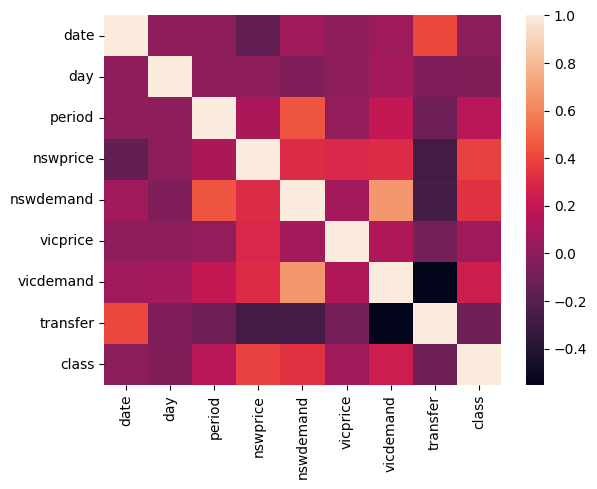

In [7]:
sns.heatmap(df.corr())

In [8]:
corr_matrix = df.corr()
corr_matrix[corr_matrix == 1.0] = 0.0

first_feature = corr_matrix.max().idxmax()
second_feature = corr_matrix.idxmax()[first_feature]

print("Pair of most correleted features: %s, %s (%s)" % (first_feature, second_feature, corr_matrix.max().max()))

Pair of most correleted features: nswdemand, vicdemand (0.6671743250710647)


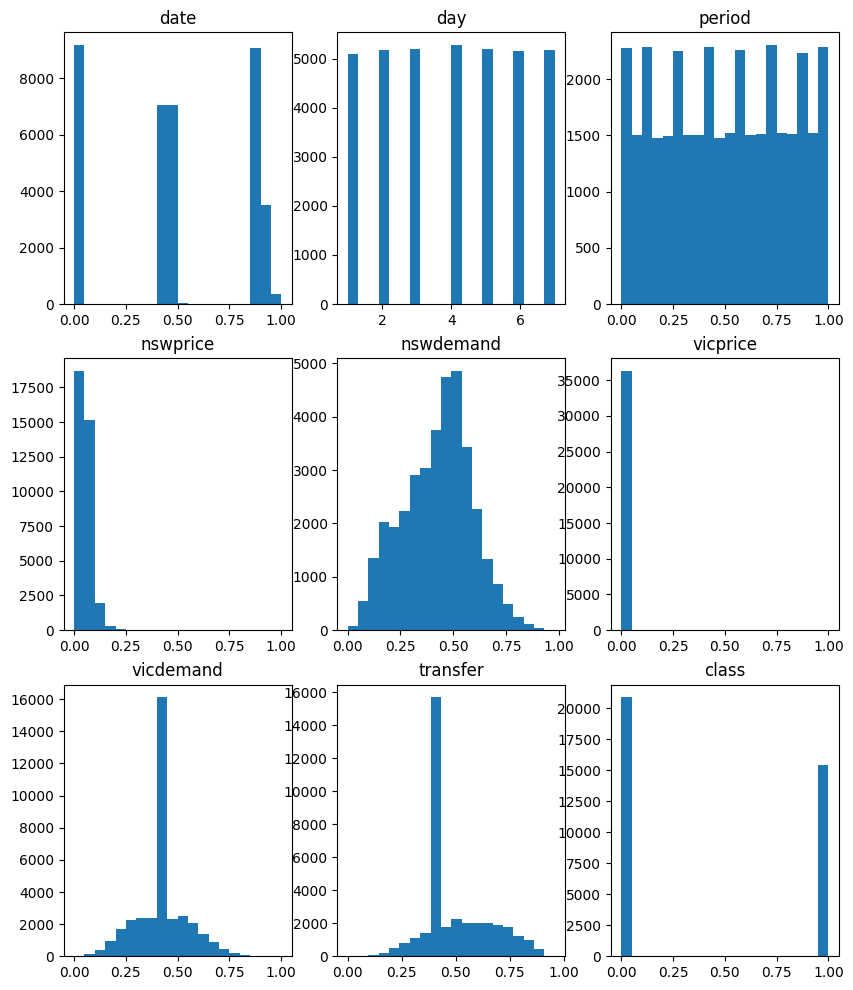

In [9]:
plt.figure(figsize=(10, 12))
cols = df.columns
plt_size = int(np.sqrt(len(cols) - 1)) + 1

for i, col in enumerate(cols):
    plt.subplot(plt_size, int((len(cols) - 1) / plt_size) + 1, i + 1)
    plt.title(col)
    plt.hist(df[col], bins=20)


Ищем картинку

#### 2. Random Forests Classifier

In [10]:
RANDOM_STATE = 3

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('class', axis=1),
    df['class'],
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 28999
Test size: 7250


In [12]:
random_forest = RandomForestClassifier(random_state=RANDOM_STATE)

random_forest.fit(X_train, y_train)

print(classification_report(y_train, random_forest.predict(X_train), digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000     16728
           1      1.000     1.000     1.000     12271

    accuracy                          1.000     28999
   macro avg      1.000     1.000     1.000     28999
weighted avg      1.000     1.000     1.000     28999



Точность - accuracy

In [13]:
# Search for best params

params_grid = {
    'n_estimators': [100,300,500],
    'max_leaf_nodes': list(range(6,10)),
    'min_samples_leaf': [1,2,3]
}


cv = GridSearchCV(
    RandomForestClassifier(
        bootstrap=False,
        class_weight='balanced',
        n_jobs=-1,
        max_features='sqrt',
        random_state=RANDOM_STATE
    ),
    params_grid,
    verbose=4,
    cv=3
)

cv.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV 1/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=100;, score=0.773 total time=   0.2s
[CV 2/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=100;, score=0.767 total time=   0.2s
[CV 3/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=100;, score=0.777 total time=   0.2s
[CV 1/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=300;, score=0.774 total time=   0.7s
[CV 2/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=300;, score=0.769 total time=   0.6s
[CV 3/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=300;, score=0.778 total time=   0.6s
[CV 1/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=500;, score=0.773 total time=   1.0s
[CV 2/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=500;, score=0.768 total time=   1.1s
[CV 3/3] END max_leaf_nodes=6, min_samples_leaf=1, n_estimators=500;, score=0.777 total time=   1.0s
[CV 1/3] END max_leaf_nodes=6

,estimator,RandomForestC...andom_state=3)
,param_grid,"{'max_leaf_nodes': [6, 7, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 300, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


##### По традиции паста, пока работает GridSearchCV

Что я меньше всего люблю в работе учителем — так это из года в год задавать детям на лето ахинею под названием «Ожившая история». Суть проекта в следующем: ученики сидят своими бабушками-дедушками и записывают (в тетрадь, на диктофон или на камеру) их самые давние воспоминания, якобы для будущих поколений, — на самом же деле это просто лёгкий способ поднять свой средний балл.

Это продолжалось семнадцать лет подряд. В очередной раз получив от учеников выполненные проекты, я ожидала, что они будут такими же нудными, как обычно, — и это ещё в лучшем случае. Н-да, далеко не самый блестящий мой класс.

Итак, пришла я домой, налила вина и приготовилась к длинной ночи из сплошных «А вот в твои годы у меня было только две пары штанов» и прочих «Моего брата как-то раз драли газетой за то, что он загнал мяч на соседскую». И как же в таких историях без типичных для стариков комментариев — по уровню сексизма или расизма порою доходящих до абсурда.

В этом классе была девочка, — назовём её Оливия. Оливия была пухленькой, миленькой, тихонькой и училась на одни четвёрки. В общем — особо ничем не примечательная ученица. Её проект обещал быть таким же средненьким, как и его автор. Отчасти именно поэтому я была настолько поражена тем, что увидела той ночью на самом деле.

По какой-то причине Оливия сдала два диска. Я начала проверку с того, который был подписан как «Интервью». По экрану компьютера пробежала рябь, после чего стартовала зернистая видеозапись. В кадре — зал, заваленный всяким барахлом. Оливия сидит в кресле с блокнотом в руках и выглядит как испуганный котёнок. Напротив неё сидит мужчина с мрачным выражением лица и покуривает сигарету, выжидательно вглядываясь в девочку.

— Начинай, — из-за камеры послышался женский голос. Большие глаза Оливии метнулись в сторону объектива, затем — обратно к человеку напротив.

— Я у своего двоюродного дедушки Стивена, — пробормотала девочка, — Он расскажет нам о том, как когда-то давно служил в армии.

Выражение лица у дедушки Стивена было такое, будто он предпочёл бы всему происходящему снова оказаться в окопе, однако он терпеливо дождался вопросов.

Как и ожидалось, Оливия вслух зачитывала заранее заготовленные мной вопросы, которые я раздала всему классу. Пару раз за интервью мама девочки шёпотом просила:

— Говори погромче, Оливия.

Ну и скукотень.

Для меня было большой интригой, когда Оливия наконец положила блокнот и спросила:

— Тебе нравилось в армии?

Совсем не по сценарию. С характерным для заядлого курильщика хрипом в голосе дедушка Стивен ответил:

— Нет. Но было приятно уехать подальше от родного города.

А куда ты поехал?

—На Балканы.

— Угу-у, — промычала Оливия. “Похоже, она впервые слышит о Балканах”, — подумала я. Через мгновение моё предположение подтвердилось:

— И как там, на Булканах, всё по-другому, не как тут?

— Да.

За кадром мать девочки осуждающе покашляла, чтобы дедушка Стивен был чуть поразговорчивее.

Но Оливия, кажется, всерьёз заинтересовалась:

— Деда Стивен, а какое твоё самое худшее армейское воспоминание?

Старик потушил сигарету о пепельницу и медленно поднялся со стула.

— Сейчас приду, — пробурчал он, и изображение погасло.

Когда камеру сняли с паузы, всё осталось по-прежнему; разве что дедушка Стивен успел разложить какие-то бумажки в файлах поверх всякой всячины, разбросанной по кофейному столику. Он взял один из файлов.

— Я пошёл служить ещё ребёнком, — сказал он Оливии. — Ровесником твоего брата.

Оливия кивнула.

— Я не участвовал в боях. Обе мои операции проходили в восточноевропейских городах, разрушенных в ходе гражданских войн. Я вот что скажу: хе-ро-та. Я там был как уборщик какой-то, твою ж ма…

— Кхе-кхе! — прозвучало из-за камеры.

Дедушка Стивен вздохнул и перевёл взгляд на файл.

— Наш отряд прикрепили к развалинам школы. Разбитые окна, провалившиеся потолки… но больше всего меня удивило то, что к нашему прибытию в таком состоянии школа пробыла уже несколько лет. То есть, никто и пальцем о палец не удосужился ударить, чтобы привести её в порядок. Мимо меня проходили детишки — наверное, шли выпрашивать деньги или ещё что, мля...

Камера резко обратилась к полу, и недовольная мама Оливии отчитала Стивена. Было трудно расслышать, как именно — но вполне возможно было представить.

— Да ну тебя, вы вообще хотите дослушать или нет? — огрызнулся он. — То-то же. Буду говорить то, что хочу.

— Мам, — вклинилась Оливия, — пожалуйста, не перебивай.

— Ты же не будешь это перед всем классом презентовать?

— Нет, мам, мы просто сдаём работу учителю.

— Ну тогда тем более. Что, учитель — не мужик, ругани не слышал? — подметил дедушка Стивен. В принципе, с ним трудно было не согласиться — разве что, я действительно не «мужик».

Камера вернулась в изначальное положение, и, после того, как объектив нашёл фокус, кадр полностью восстановился.

— Эх-х, всё равно я слишком многого прошу, — проворчал Стивен. Он поднёс лист бумаги ближе к лицу. — Это письмо я нашёл в школьном подвале. Тогда я понятия не имел, что в нём написано, но мой приятель его перевёл. Сейчас я его зачитаю. А после — расскажу, что увидел в том подвале.

У меня по спине пробежал холодок. Мама Оливии навела крупный план на дедушку Стивена. Руки, в которых он держал письмо, судорожно дрожали. Вот что он зачитал:

«Уважаемый г-н,

Я никогда не любил свою страну. Все эти битвы — порождение ярого патриотизма, борьбы за власть над осколками некогда великой державы. Но мне, откровенно говоря, плевать, какими буквами мой дом обозначен на карте. Война лишена всякого смысла, и я пытаюсь держаться от неё как можно дальше.

Но не бесконечные атаки и не безразборное насилие отняли у меня жену и ребёнка. Нет, — то была болезнь. Над малышом зараза сжалилась, и всё закончилось быстро. А вот Надя страдала дольше. Мне приходилось лишь в ужасе наблюдать за их муками, не в силах хоть как-то помочь. Единственное моё утешение в том, что я был рядом. В какой-то момент я просто перестал ходить на работу — и никто не стал меня искать. Хотя я сомневаюсь, что там заметили моё отсутствие. Школу видно из окна, и я мог бы уходить туда на пару часов в день, а потом возвращаться и сидеть с родными — но в чём смысл? Вся моя работа состояла в том, чтобы драить полы. Для мира я был так же бесполезен, как и для своей семьи.

Я хотел отвести Надю в больницу, но ей было слишком тяжело, и мы вернулись домой. В ту же ночь она скончалась.

После того, как они умерли… я мало что помню. Я не вылазил из своего барака, толком не ел, не спал и часто помышлял о самоубийстве. Но, увы, как бы заманчиво оно ни было, — я был напрочь скован собственной беспомощностью.

Радио не давало мне потерять рассудок. Я не выключал его ни на секунду. И это притом, что к словам-то я, на самом деле, не прислушивался. Даже так: канал, на котором было меньше всего помех, был на английском (кажется), в котором я полный ноль. Но звучание голосов, музыки; осознание того, что где-то там, за пределами этого чёртова города, продолжается жизнь — всё это помогало мне держаться.

Не знаю, сколько прошло времени, пока я снова не увидел солнечный свет. С голоду в глазах начинало темнеть, и моей главной задачей было раздобыть чего-нибудь съестного. Радио я, конечно же, взял с собой. С того момента, как я закрылся в доме, я с ним не расставался. Оно говорит со мной, пока я сплю и когда просыпаюсь. Без понятия, что именно оно говорит, но знаю, что без него я бы и минуты не протянул.

Добыв еду и воду, я понял, что осталось только вернуться на работу — и я вернулся. Уже на следующее утро я снова был в школе, где работал уборщиком, и взялся за дело.

Никто не поднимал эту тему. Как я уже говорил, Надя болела довольно долго, и в школе об этом знали. Я благодарен, что никто не стал силой тащить меня на работу в самые тяжёлые дни в моей жизни. Учителя редко говорили со мной — обычно мы просто улыбались друг другу в коридорах. Если подумать, то это взаимное уважение — и есть та самая причина, по которой я вышел на работу.

В моё отсутствие школа катилась в тартарары — я достал из своего шкафчика швабру и тряпки и сразу приступил к уборке. Все довольны, что я вернулся, куда ж без этого. Но лучше всего то, что никому нет дела до моего радио. Я выставил звук пониже, чтобы не мешать учебному процессу, и ношу его повсюду. Никто пока не жаловался. Мне даже кажется, что им нравится.

Само здание школы не очень большое, но за ним нужен глаз да глаз. Полы постоянно липкие и грязные, и на их оттирание у меня уходит больше всего времени. Дети любят наводить бардак — наверное, поэтому я и остаюсь востребован. Время от времени приходится двигать всякие предметы по полу, чтобы достать до каждого пятнышка, но я горжусь преданностью своему делу.

Ой, точно, ещё ведь есть починка! В школе то и дело нужно подкрутить пару гаек — и я тут как тут. Иногда я чиню поломанные парты, присвистывая в такт радио, а иногда — занимаюсь чем-то посерьёзнее, например, ремонтом. В такие дни я чувствую себя незаменимым — как шестерёнка в механизме. Как школа вообще без меня выживала? Наконец-то я снова кому-то нужен.

За школой есть кладовая с консервами. Вместо зарплаты руководство разрешает мне брать оттуда столько еды, сколько мне хочется. И меня это устраивает — в самом деле, на кой чёрт мне сдались деньги? Сначала я таскал еду домой, но потом стал ночевать в подвале. Никто, собственно, не возражал. Эта школа заняла особое место в моём сердце, и я не могу оставить её без присмотра.

Когда на меня сваливается память о жене и малыше, я просто делаю звук на радио погромче. И это работало.

Вплоть до этого утра.

На этот раз я проснулся в полной тишине.

В панике я начал осматривать радио. Даже и не предположу, сколько дней подряд я держал его включённым. Неужели оно отслужило свой срок и больше никогда не заработает? Целый день я пытался его починить. И почти весь этот день я не мог остановить слёзы. Я схожу с ума.

Если не починю радио до заката, то лишу себя жизни. Я пишу это письмо, потому что солнце уже близится к горизонту, и я не сомневаюсь в своей участи.

Я думал о том, чтобы пройтись по коридорам школы в последний раз и попрощаться со школьниками и преподавателями. По мне будут скучать, я знаю. Но я не могу заставить себя покинуть эту комнату. Не могу уйти, зная, что моё радио мертво.

Я выплакал все слёзы. Кажется, я даже не могу вдохнуть полной грудью. Всё скромное содержимое моего желудка вышло наружу, и в глазах опять стало темнеть. Но ничего, — мне уже совсем недолго осталось.

Но перед тем, как покончить с собой, я закрыл дверь в свою каморку и подпёр ручку стулом. Это единственное помещение в подвале, и в нём есть крохотное окошко — через него внутрь проникает достаточно света, чтобы я мог разглядеть петлю. Если найдётся добрый человек, который отправится меня искать, то я не хочу, чтобы первым, что он увидел, была такая картина. Нет, — пусть увидит закрытую дверь, почувствует запах моего полуразложившегося трупа и просто забудет о том, что я когда-либо существовал.

Я помещу радио и эту записку возле двери. Уважаемый г-н, если вы это читаете, то у меня к вам одна скромная просьба: почините радио. Пожалуйста, спасите его. Оно не заслужило так бесславно умереть во сне, и мне стыдно, что я не смог его воскресить.

Теперь я готов вновь увидеть Надю и малышку-Людмилу. Надеюсь, школа найдёт нового уборщика, который будет любить её так же, как любил её я.

Всё. Пора. Не забудьте про моё радио.

Станислав»

Когда кадр отдалился, Оливия была в слезах.

— Спасибо, деда Стивен, — сказала мама девочки, тоже плача. — Думаю, этого хватит.

— Постой! — прощебетала Оливия. — он сказал, что это не всё. Что ты увидел в том подвале?

Но, до того, как дедушка Стивен успел что-то сказать, изображение пропало. Я сидела с открытым ртом. Что он там увидел? Что же?!

Очень кстати я вспомнила про второй диск. На нём не было пометок, но я надеялась увидеть продолжение интервью.

Видео на нём не было, но была аудиодорожка. Послышался голос Оливии:

— Здравствуйте, мисс Джеррити. Извиняюсь за маму, но она не захотела снимать остальное. Я попросила его продолжить и втайне от мамы записала всё на диктофон телефона. Помню, вы говорили нам, что, пусть историю пишут те, кто побеждает на войне, но… — она глубоко вздохнула и сорвалась на плач, — но история любого, даже самого маленького и слабого человека, по-своему важна, и не важно, что этот человек ни разу в жизни не одерживал побед. Я завершила свой проект вчера и не могла уснуть этой ночью, но вы должны услышать то, что мой дедушка сказал дальше.

В моих глазах тоже стояли слёзы. Искренность в её голосе была прекрасна. И меня очень умилило то, что она запомнила одну из сотен банальных фраз, которые мне когда-то говорил мой учитель истории.

Пока сантименты ещё не успели взять надо мной верх, звук появился вновь:

— Ну ладно, — раздражённо бросила мать, — хочешь услышать конец — пожалуйста. Но для школьного проекта это слишком.

— Да дай ты мне уже закончить, — не на шутку разозлился дедушка Стивен. — Если для тебя это слишком, то иди на кухню и перекуси. Оливия вот хочет знать, что было дальше.

Было слышно, как женщина что-то пробубнила и вышла из комнаты. Оливия и её дед остались вдвоём. Девочка смотрела на Стивена взглядом, полным нетерпения — по крайней мере, так я изобразила это у себя в голове.

— Так ты нашёл радио? Или оно исчезло, когда школу подорвали?

Он прокашлялся, и послышался щелчок зажигалки.

— На том письме, — начал он медленно, — стояла дата.

— Какая? — жадно спросила Оливия.

— Оно было написано за две недели до того, как мы начали восстанавливать школу.

— Н-но разве ты не говорил, что школу разрушили как минимум за два года до этого?

— Да, — ответил дедушка Стивен. — Да, её и разрушили.

Молчание. По моим рукам пробежали мурашки. Мои догадки трудно было передать словами, но у дедушки Стивена это прекрасно получилось, без малейшей запинки. Было видно, что он уже долго живёт с этой мыслью.

— Этот человек, Станислав, жил в развалинах школы и убирал кровь и обломки, будто это были разлитые напитки и пыль. Он улыбался мертвецам и думал, что они улыбаются в ответ, потому что им нравится его радио. Он перетаскивал трупы, чтобы протереть под ними пол. Крыша была обвалена, но он был так отрешён, что не чувствовал на себе капель дождя.

Было слышно, как Оливия плачет.

— Я нашёл тот склад, с которого он таскал еду. Внутри — сплошные квашеные консервы — наверное, отвратительные на вкус. И почти всё это поросло плесенью.

— А ты… ты видел его тело?

— Да. Оно свисало с потолка, но было почти как… почти как живое. Он ещё не начал разлагаться. Прошло совсем немного времени.

— Он выглядел умиротворённым? — спросила она с ноткой отчаяния в голосе.

— Трудно сказать. Стояла дикая вонь, его лицо было синюшное, глаза выпирали из глазниц. Вот так, — видимо, изобразил он на себе.

— А что с радио? — Оливия всхлипнула.

Дедушка Стивен глубоко затянулся сигаретой.

— Оно было там. И знаешь что? Оно было включено.

##### Продолжаем хайпить

In [14]:
best_params = cv.best_params_

print("Best model params:", best_params)

Best model params: {'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'n_estimators': 500}


In [15]:
# Train report
random_forest = cv.best_estimator_

print(classification_report(y_train, random_forest.predict(X_train), digits=3))

              precision    recall  f1-score   support

           0      0.788     0.873     0.828     16728
           1      0.797     0.680     0.734     12271

    accuracy                          0.791     28999
   macro avg      0.792     0.776     0.781     28999
weighted avg      0.792     0.791     0.788     28999



In [16]:
# Test report

print(classification_report(y_test, random_forest.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.789     0.875     0.830      4132
           1      0.806     0.690     0.744      3118

    accuracy                          0.795      7250
   macro avg      0.798     0.783     0.787      7250
weighted avg      0.797     0.795     0.793      7250



In [17]:
print("Most important feaature:", cols[np.argmax(random_forest.feature_importances_)])

Most important feaature: nswprice


#### 3. Voting Classifier

In [18]:
voting = VotingClassifier(
    [
        ('LogisticRegression', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE)),
        ('SVC', SVC(random_state=RANDOM_STATE)),
        ('SGD', SGDClassifier(random_state=RANDOM_STATE))
    ],
    voting='hard'
)

voting.fit(X_train, y_train)

print(classification_report(y_test, voting.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.727     0.907     0.807      4132
           1      0.817     0.549     0.657      3118

    accuracy                          0.753      7250
   macro avg      0.772     0.728     0.732      7250
weighted avg      0.766     0.753     0.743      7250



#### 4. Bagging Classifier

In [19]:
bagging = BaggingClassifier(
    DecisionTreeClassifier(class_weight='balanced'),
    max_samples=0.5,
    max_features=0.5,
    bootstrap=False,
    random_state=RANDOM_STATE
)

bagging.fit(X_train, y_train)

print(classification_report(y_test, bagging.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.815     0.910     0.860      4132
           1      0.860     0.726     0.787      3118

    accuracy                          0.831      7250
   macro avg      0.837     0.818     0.824      7250
weighted avg      0.834     0.831     0.829      7250



#### 5. Gradient Boosting Classifier

In [20]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.8,
    max_depth=2,
    random_state=RANDOM_STATE
)

gradient_boosting.fit(X_train, y_train)

print(classification_report(y_test, gradient_boosting.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.908     0.915     0.912      4132
           1      0.886     0.878     0.882      3118

    accuracy                          0.899      7250
   macro avg      0.897     0.896     0.897      7250
weighted avg      0.899     0.899     0.899      7250



#### 6. AdaBoost Classifier

In [22]:
ada_boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
    n_estimators=300,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

ada_boost.fit(X_train, y_train)

print(classification_report(y_test, ada_boost.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.826     0.864     0.844      4132
           1      0.808     0.758     0.782      3118

    accuracy                          0.818      7250
   macro avg      0.817     0.811     0.813      7250
weighted avg      0.818     0.818     0.818      7250



#### 7. Stacking Classifier

А вот эта фигня работает долго (1-2 минуты), можете дочитать пасту, если не дочитали

In [23]:
stacking = StackingClassifier(
    estimators=[
        ('RandomForest', RandomForestClassifier(random_state=RANDOM_STATE)),
        ('SVC', SVC(random_state=RANDOM_STATE))
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE)
)

stacking.fit(X_train, y_train)

print(classification_report(y_test, stacking.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.911     0.921     0.916      4132
           1      0.894     0.881     0.887      3118

    accuracy                          0.904      7250
   macro avg      0.902     0.901     0.901      7250
weighted avg      0.903     0.904     0.903      7250



### Упражнение 3.2

Бустинги, наши любимые бустинги

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

In [28]:
df = pd.read_csv(DATASET_PATH)
reserved_df = pd.read_csv(RESERVED_DATASET_PATH)

print(reserved_df.shape)
print(df.shape)

(9063, 8)
(36249, 9)


In [29]:
MODEL_PARAMS = {
    'objective': 'binary:logistic',
    "booster": "gbtree",
    'tree_method': 'hist',
}
SEEDS = [
    42, 672, 961, 956, 389, 
    387, 438, 379, 755, 173
]

In [33]:
def acc_xgb(preds, dtrain):
    labels = dtrain.get_label()
    # Расчет взвешенной MAE
    pred_clases = np.round(preds)
    acc = accuracy_score(labels, pred_clases)
    return 'accuracy', acc

def train_batch_models(params, dtrain, dval = None, num_boost_round=1000, verbose_eval=500):
    best_model = None
    best_score = None
    for seed in SEEDS:
        params['seed'] = seed

        evals = [(dtrain, 'train')]
        if dval is not None:
            evals.append((dval, 'val'))
    
        model = xgb.train(
            params, dtrain, 
            num_boost_round=num_boost_round,
            evals=evals,
            custom_metric=acc_xgb,
            early_stopping_rounds=50,
            verbose_eval=verbose_eval
        )

        if dval is not None:
            _, score = acc_xgb(model.predict(dval), dval)
        else:
            _, score = acc_xgb(model.predict(dtrain), dtrain)

        if best_score is None or best_score < score:
            best_score = score 
            best_model = model

    return best_model, best_score


#### Params selection process (you don't need this)

In [67]:
# Создаем DMatrix
RANDOM_STATE = 3

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("class", axis=1).to_numpy(),
    df["class"].to_numpy(),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["class"]
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_test, label=y_test)

In [68]:
import optuna

# Обучение моделей с подбором гиперпараметров
def objective(trial):
    params = {
        # "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.1),
        "lambda": trial.suggest_float("lambda", 1e-5, 1.0, log=True),
        'gamma': trial.suggest_float("gamma", 1e-5, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        'max_depth': trial.suggest_int("max_depth", 6, 25),
        'min_child_weight': trial.suggest_int("min_child_weight", 2, 40)
    }
    params.update(MODEL_PARAMS)

    _, score = train_batch_models(params, dtrain, dval)
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
study.best_params

[I 2025-11-25 11:38:58,927] A new study created in memory with name: no-name-a5cfeb9a-37d4-4f7a-bd61-163417c0fff8


[0]	train-logloss:0.62886	train-accuracy:0.57547	val-logloss:0.63353	val-accuracy:0.57545
[50]	train-logloss:0.13291	train-accuracy:0.97048	val-logloss:0.22496	val-accuracy:0.91241
[0]	train-logloss:0.63837	train-accuracy:0.57547	val-logloss:0.64429	val-accuracy:0.57545
[50]	train-logloss:0.13454	train-accuracy:0.97086	val-logloss:0.22909	val-accuracy:0.91186
[0]	train-logloss:0.62840	train-accuracy:0.57547	val-logloss:0.63309	val-accuracy:0.57545
[50]	train-logloss:0.13490	train-accuracy:0.96990	val-logloss:0.22773	val-accuracy:0.90979
[0]	train-logloss:0.62801	train-accuracy:0.57547	val-logloss:0.63247	val-accuracy:0.57545
[50]	train-logloss:0.13496	train-accuracy:0.96945	val-logloss:0.22935	val-accuracy:0.90993
[0]	train-logloss:0.62858	train-accuracy:0.57547	val-logloss:0.63348	val-accuracy:0.57545
[50]	train-logloss:0.13576	train-accuracy:0.96914	val-logloss:0.23056	val-accuracy:0.91283
[0]	train-logloss:0.62954	train-accuracy:0.57547	val-logloss:0.63393	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:00,880] Trial 0 finished with value: 0.9153103448275862 and parameters: {'learning_rate': 0.08354751158601183, 'lambda': 2.821481771722146e-05, 'gamma': 0.05597593757197845, 'alpha': 0.0360199447158361, 'subsample': 0.8710284838409025, 'colsample_bytree': 0.9981199929965092, 'max_depth': 18, 'min_child_weight': 4}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.67196	train-accuracy:0.57547	val-logloss:0.67234	val-accuracy:0.57545
[50]	train-logloss:0.41570	train-accuracy:0.89803	val-logloss:0.43772	val-accuracy:0.87159
[0]	train-logloss:0.67426	train-accuracy:0.57547	val-logloss:0.67492	val-accuracy:0.57545
[50]	train-logloss:0.42532	train-accuracy:0.89648	val-logloss:0.44854	val-accuracy:0.86703
[0]	train-logloss:0.67193	train-accuracy:0.57547	val-logloss:0.67247	val-accuracy:0.57545
[50]	train-logloss:0.41745	train-accuracy:0.89941	val-logloss:0.43913	val-accuracy:0.87214
[0]	train-logloss:0.67197	train-accuracy:0.57547	val-logloss:0.67249	val-accuracy:0.57545
[50]	train-logloss:0.41611	train-accuracy:0.90062	val-logloss:0.43801	val-accuracy:0.87490
[0]	train-logloss:0.67190	train-accuracy:0.57547	val-logloss:0.67246	val-accuracy:0.57545
[50]	train-logloss:0.41866	train-accuracy:0.89575	val-logloss:0.44079	val-accuracy:0.86924
[0]	train-logloss:0.67221	train-accuracy:0.57547	val-logloss:0.67264	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:02,363] Trial 1 finished with value: 0.8755862068965518 and parameters: {'learning_rate': 0.016318597503869176, 'lambda': 0.0016591237188182406, 'gamma': 0.13209531628401108, 'alpha': 3.5539556151246956e-05, 'subsample': 0.8707014028420359, 'colsample_bytree': 0.7882752308990274, 'max_depth': 14, 'min_child_weight': 7}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.64875	train-accuracy:0.57547	val-logloss:0.64870	val-accuracy:0.57545
[50]	train-logloss:0.32433	train-accuracy:0.86496	val-logloss:0.34092	val-accuracy:0.85972
[0]	train-logloss:0.65937	train-accuracy:0.57547	val-logloss:0.66002	val-accuracy:0.57545
[50]	train-logloss:0.32996	train-accuracy:0.86317	val-logloss:0.34710	val-accuracy:0.85641
[0]	train-logloss:0.64904	train-accuracy:0.57547	val-logloss:0.64926	val-accuracy:0.57545
[50]	train-logloss:0.32597	train-accuracy:0.86365	val-logloss:0.34215	val-accuracy:0.85641
[0]	train-logloss:0.64850	train-accuracy:0.57547	val-logloss:0.64839	val-accuracy:0.57545
[50]	train-logloss:0.32471	train-accuracy:0.86317	val-logloss:0.34074	val-accuracy:0.85835
[0]	train-logloss:0.64951	train-accuracy:0.57547	val-logloss:0.64987	val-accuracy:0.57545
[50]	train-logloss:0.32945	train-accuracy:0.86082	val-logloss:0.34574	val-accuracy:0.85876
[0]	train-logloss:0.64959	train-accuracy:0.57547	val-logloss:0.64934	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:03,198] Trial 2 finished with value: 0.8613793103448276 and parameters: {'learning_rate': 0.0742820979361594, 'lambda': 0.2909631243362999, 'gamma': 0.7566112704634209, 'alpha': 0.0021987809653510734, 'subsample': 0.7676030463251342, 'colsample_bytree': 0.8364143680448421, 'max_depth': 8, 'min_child_weight': 19}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.64686	train-accuracy:0.57547	val-logloss:0.64739	val-accuracy:0.57545
[50]	train-logloss:0.27023	train-accuracy:0.90038	val-logloss:0.30384	val-accuracy:0.87972
[0]	train-logloss:0.65585	train-accuracy:0.57547	val-logloss:0.65743	val-accuracy:0.57545
[50]	train-logloss:0.27703	train-accuracy:0.89879	val-logloss:0.31118	val-accuracy:0.87421
[0]	train-logloss:0.64611	train-accuracy:0.57547	val-logloss:0.64710	val-accuracy:0.57545
[50]	train-logloss:0.27003	train-accuracy:0.90158	val-logloss:0.30279	val-accuracy:0.88179
[0]	train-logloss:0.64704	train-accuracy:0.57547	val-logloss:0.64797	val-accuracy:0.57545
[50]	train-logloss:0.26905	train-accuracy:0.90175	val-logloss:0.30252	val-accuracy:0.87986
[0]	train-logloss:0.64627	train-accuracy:0.57547	val-logloss:0.64749	val-accuracy:0.57545
[50]	train-logloss:0.27272	train-accuracy:0.89955	val-logloss:0.30677	val-accuracy:0.87600
[0]	train-logloss:0.64707	train-accuracy:0.57547	val-logloss:0.64741	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:04,506] Trial 3 finished with value: 0.8820689655172413 and parameters: {'learning_rate': 0.06999388030872043, 'lambda': 0.34398018651859513, 'gamma': 2.6018635327807864e-05, 'alpha': 2.8724097882956407e-05, 'subsample': 0.5386947537974067, 'colsample_bytree': 0.7746120445761968, 'max_depth': 23, 'min_child_weight': 11}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.66740	train-accuracy:0.57547	val-logloss:0.66779	val-accuracy:0.57545
[50]	train-logloss:0.36365	train-accuracy:0.87193	val-logloss:0.38024	val-accuracy:0.86248
[0]	train-logloss:0.67102	train-accuracy:0.57547	val-logloss:0.67206	val-accuracy:0.57545
[50]	train-logloss:0.38085	train-accuracy:0.86824	val-logloss:0.39972	val-accuracy:0.85876
[0]	train-logloss:0.66466	train-accuracy:0.57547	val-logloss:0.66507	val-accuracy:0.57545
[50]	train-logloss:0.37143	train-accuracy:0.87151	val-logloss:0.38800	val-accuracy:0.86428
[0]	train-logloss:0.66735	train-accuracy:0.57547	val-logloss:0.66784	val-accuracy:0.57545
[50]	train-logloss:0.37270	train-accuracy:0.87379	val-logloss:0.39006	val-accuracy:0.86386
[0]	train-logloss:0.66408	train-accuracy:0.57547	val-logloss:0.66418	val-accuracy:0.57545
[50]	train-logloss:0.36843	train-accuracy:0.87058	val-logloss:0.38528	val-accuracy:0.86083
[0]	train-logloss:0.66482	train-accuracy:0.57547	val-logloss:0.66493	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:05,617] Trial 4 finished with value: 0.8652413793103448 and parameters: {'learning_rate': 0.033492110905807414, 'lambda': 0.00013626865106057453, 'gamma': 0.045040046727819694, 'alpha': 0.33138264316437327, 'subsample': 0.9492321105533003, 'colsample_bytree': 0.6638312805655591, 'max_depth': 17, 'min_child_weight': 21}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.64559	train-accuracy:0.57547	val-logloss:0.64655	val-accuracy:0.57545
[50]	train-logloss:0.29600	train-accuracy:0.88251	val-logloss:0.32122	val-accuracy:0.87103
[0]	train-logloss:0.65626	train-accuracy:0.57547	val-logloss:0.65749	val-accuracy:0.57545
[50]	train-logloss:0.29829	train-accuracy:0.88286	val-logloss:0.32595	val-accuracy:0.86841
[0]	train-logloss:0.64508	train-accuracy:0.57547	val-logloss:0.64565	val-accuracy:0.57545
[50]	train-logloss:0.29650	train-accuracy:0.88244	val-logloss:0.32218	val-accuracy:0.86800
[0]	train-logloss:0.64538	train-accuracy:0.57547	val-logloss:0.64576	val-accuracy:0.57545
[50]	train-logloss:0.29291	train-accuracy:0.88317	val-logloss:0.31903	val-accuracy:0.86814
[0]	train-logloss:0.64567	train-accuracy:0.57547	val-logloss:0.64633	val-accuracy:0.57545
[50]	train-logloss:0.29676	train-accuracy:0.88224	val-logloss:0.32299	val-accuracy:0.87255
[0]	train-logloss:0.64592	train-accuracy:0.57547	val-logloss:0.64624	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:06,552] Trial 5 finished with value: 0.872551724137931 and parameters: {'learning_rate': 0.07441044141549306, 'lambda': 0.041764866328414293, 'gamma': 0.0074193422711428016, 'alpha': 0.026587165372778727, 'subsample': 0.897418141677633, 'colsample_bytree': 0.8227396222901026, 'max_depth': 10, 'min_child_weight': 18}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.66992	train-accuracy:0.57547	val-logloss:0.67005	val-accuracy:0.57545
[50]	train-logloss:0.41882	train-accuracy:0.84982	val-logloss:0.42789	val-accuracy:0.84400
[0]	train-logloss:0.67356	train-accuracy:0.57547	val-logloss:0.67390	val-accuracy:0.57545
[50]	train-logloss:0.42606	train-accuracy:0.84606	val-logloss:0.43543	val-accuracy:0.84221
[0]	train-logloss:0.66997	train-accuracy:0.57547	val-logloss:0.67017	val-accuracy:0.57545
[50]	train-logloss:0.42138	train-accuracy:0.85037	val-logloss:0.43081	val-accuracy:0.84028
[0]	train-logloss:0.66966	train-accuracy:0.57547	val-logloss:0.66972	val-accuracy:0.57545
[50]	train-logloss:0.41817	train-accuracy:0.85186	val-logloss:0.42762	val-accuracy:0.84345
[0]	train-logloss:0.67001	train-accuracy:0.57547	val-logloss:0.67016	val-accuracy:0.57545
[50]	train-logloss:0.42109	train-accuracy:0.84796	val-logloss:0.42978	val-accuracy:0.84207
[0]	train-logloss:0.67011	train-accuracy:0.57547	val-logloss:0.67014	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:07,599] Trial 6 finished with value: 0.8448275862068966 and parameters: {'learning_rate': 0.024852472082599, 'lambda': 8.895016968823912e-05, 'gamma': 2.344822631713049e-05, 'alpha': 0.9851298294698896, 'subsample': 0.7937722358822537, 'colsample_bytree': 0.77062306252937, 'max_depth': 9, 'min_child_weight': 15}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.65254	train-accuracy:0.57547	val-logloss:0.65358	val-accuracy:0.57545
[50]	train-logloss:0.28535	train-accuracy:0.89845	val-logloss:0.32060	val-accuracy:0.87641
[0]	train-logloss:0.66094	train-accuracy:0.57547	val-logloss:0.66216	val-accuracy:0.57545
[50]	train-logloss:0.29141	train-accuracy:0.89734	val-logloss:0.32772	val-accuracy:0.87448
[0]	train-logloss:0.65321	train-accuracy:0.57547	val-logloss:0.65453	val-accuracy:0.57545
[50]	train-logloss:0.28822	train-accuracy:0.89603	val-logloss:0.32201	val-accuracy:0.87255
[0]	train-logloss:0.65254	train-accuracy:0.57547	val-logloss:0.65389	val-accuracy:0.57545
[50]	train-logloss:0.28549	train-accuracy:0.89820	val-logloss:0.31895	val-accuracy:0.87710
[0]	train-logloss:0.65282	train-accuracy:0.57547	val-logloss:0.65399	val-accuracy:0.57545
[50]	train-logloss:0.28739	train-accuracy:0.89917	val-logloss:0.32208	val-accuracy:0.87779
[0]	train-logloss:0.65343	train-accuracy:0.57547	val-logloss:0.65424	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:08,639] Trial 7 finished with value: 0.8788965517241379 and parameters: {'learning_rate': 0.0549597676298575, 'lambda': 0.02423397118130798, 'gamma': 0.00041763818085487065, 'alpha': 0.04427182614029319, 'subsample': 0.9645551861615127, 'colsample_bytree': 0.757424492709541, 'max_depth': 10, 'min_child_weight': 8}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.66333	train-accuracy:0.57547	val-logloss:0.66351	val-accuracy:0.57545
[50]	train-logloss:0.35503	train-accuracy:0.85896	val-logloss:0.36711	val-accuracy:0.85545
[0]	train-logloss:0.66973	train-accuracy:0.57547	val-logloss:0.67078	val-accuracy:0.57545
[50]	train-logloss:0.37055	train-accuracy:0.85720	val-logloss:0.38433	val-accuracy:0.85310
[0]	train-logloss:0.66018	train-accuracy:0.57547	val-logloss:0.66035	val-accuracy:0.57545
[50]	train-logloss:0.36201	train-accuracy:0.85969	val-logloss:0.37426	val-accuracy:0.85517
[0]	train-logloss:0.66322	train-accuracy:0.57547	val-logloss:0.66347	val-accuracy:0.57545
[50]	train-logloss:0.36284	train-accuracy:0.86186	val-logloss:0.37618	val-accuracy:0.85738
[0]	train-logloss:0.65941	train-accuracy:0.57547	val-logloss:0.65949	val-accuracy:0.57545
[50]	train-logloss:0.35970	train-accuracy:0.85975	val-logloss:0.37209	val-accuracy:0.85338
[0]	train-logloss:0.65995	train-accuracy:0.57547	val-logloss:0.65992	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:09,718] Trial 8 finished with value: 0.8573793103448276 and parameters: {'learning_rate': 0.04540254656043292, 'lambda': 0.00020056963051407733, 'gamma': 0.026104799848191796, 'alpha': 3.5829891828400305e-05, 'subsample': 0.6638331904153137, 'colsample_bytree': 0.6751299585857136, 'max_depth': 21, 'min_child_weight': 26}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.66770	train-accuracy:0.57547	val-logloss:0.66801	val-accuracy:0.57545
[50]	train-logloss:0.36807	train-accuracy:0.86986	val-logloss:0.38348	val-accuracy:0.86372
[0]	train-logloss:0.67145	train-accuracy:0.57547	val-logloss:0.67232	val-accuracy:0.57545
[50]	train-logloss:0.38575	train-accuracy:0.86651	val-logloss:0.40322	val-accuracy:0.85490
[0]	train-logloss:0.66496	train-accuracy:0.57547	val-logloss:0.66531	val-accuracy:0.57545
[50]	train-logloss:0.37520	train-accuracy:0.87058	val-logloss:0.39135	val-accuracy:0.86193
[0]	train-logloss:0.66772	train-accuracy:0.57547	val-logloss:0.66831	val-accuracy:0.57545
[50]	train-logloss:0.37787	train-accuracy:0.87131	val-logloss:0.39437	val-accuracy:0.86041
[0]	train-logloss:0.66441	train-accuracy:0.57547	val-logloss:0.66452	val-accuracy:0.57545
[50]	train-logloss:0.37205	train-accuracy:0.86838	val-logloss:0.38764	val-accuracy:0.86083
[0]	train-logloss:0.66513	train-accuracy:0.57547	val-logloss:0.66520	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:10,994] Trial 9 finished with value: 0.8637241379310345 and parameters: {'learning_rate': 0.03276088107644785, 'lambda': 0.013985467400446979, 'gamma': 0.00023897139793418822, 'alpha': 1.859365142890602e-05, 'subsample': 0.8896726270031556, 'colsample_bytree': 0.7265202001052866, 'max_depth': 17, 'min_child_weight': 21}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.64130	train-accuracy:0.57547	val-logloss:0.64137	val-accuracy:0.57545
[50]	train-logloss:0.30831	train-accuracy:0.86972	val-logloss:0.32612	val-accuracy:0.86262
[0]	train-logloss:0.65277	train-accuracy:0.57547	val-logloss:0.65380	val-accuracy:0.57545
[50]	train-logloss:0.30978	train-accuracy:0.86917	val-logloss:0.32677	val-accuracy:0.86386
[0]	train-logloss:0.64084	train-accuracy:0.57547	val-logloss:0.64100	val-accuracy:0.57545
[50]	train-logloss:0.30893	train-accuracy:0.87044	val-logloss:0.32635	val-accuracy:0.86552
[0]	train-logloss:0.64122	train-accuracy:0.57547	val-logloss:0.64157	val-accuracy:0.57545
[50]	train-logloss:0.30796	train-accuracy:0.87144	val-logloss:0.32585	val-accuracy:0.86565
[0]	train-logloss:0.64103	train-accuracy:0.57547	val-logloss:0.64144	val-accuracy:0.57545
[50]	train-logloss:0.31154	train-accuracy:0.86865	val-logloss:0.32868	val-accuracy:0.86428
[0]	train-logloss:0.64146	train-accuracy:0.57547	val-logloss:0.64159	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:11,948] Trial 10 finished with value: 0.8666206896551724 and parameters: {'learning_rate': 0.08969042952289695, 'lambda': 1.3531945730747658e-05, 'gamma': 0.7324549887146037, 'alpha': 0.0009934691730276843, 'subsample': 0.6300048464844674, 'colsample_bytree': 0.9896423282968436, 'max_depth': 25, 'min_child_weight': 33}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.65127	train-accuracy:0.57547	val-logloss:0.65484	val-accuracy:0.57545
[50]	train-logloss:0.16151	train-accuracy:0.96493	val-logloss:0.25622	val-accuracy:0.90000
[0]	train-logloss:0.64697	train-accuracy:0.57547	val-logloss:0.65382	val-accuracy:0.57545
[50]	train-logloss:0.17620	train-accuracy:0.96310	val-logloss:0.27909	val-accuracy:0.89310
[0]	train-logloss:0.62737	train-accuracy:0.57547	val-logloss:0.63011	val-accuracy:0.57545
[50]	train-logloss:0.17076	train-accuracy:0.96348	val-logloss:0.26991	val-accuracy:0.89793
[0]	train-logloss:0.63978	train-accuracy:0.57547	val-logloss:0.64338	val-accuracy:0.57545
[50]	train-logloss:0.16302	train-accuracy:0.96614	val-logloss:0.25848	val-accuracy:0.90069
[0]	train-logloss:0.62231	train-accuracy:0.57547	val-logloss:0.62506	val-accuracy:0.57545
[50]	train-logloss:0.16631	train-accuracy:0.96407	val-logloss:0.25908	val-accuracy:0.90262
[0]	train-logloss:0.64311	train-accuracy:0.57547	val-logloss:0.64652	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:13,718] Trial 11 finished with value: 0.9026206896551724 and parameters: {'learning_rate': 0.0997120685167961, 'lambda': 0.8043522451326032, 'gamma': 1.4339436105407887e-05, 'alpha': 0.0002816768255115579, 'subsample': 0.5077867638995679, 'colsample_bytree': 0.5167789452703434, 'max_depth': 22, 'min_child_weight': 2}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.65110	train-accuracy:0.57547	val-logloss:0.65557	val-accuracy:0.57545
[50]	train-logloss:0.14795	train-accuracy:0.97003	val-logloss:0.25275	val-accuracy:0.90221
[0]	train-logloss:0.64531	train-accuracy:0.57547	val-logloss:0.65351	val-accuracy:0.57545
[50]	train-logloss:0.16077	train-accuracy:0.97041	val-logloss:0.27432	val-accuracy:0.89517
[0]	train-logloss:0.62613	train-accuracy:0.57547	val-logloss:0.62940	val-accuracy:0.57545
[50]	train-logloss:0.15620	train-accuracy:0.97107	val-logloss:0.26808	val-accuracy:0.89545
[0]	train-logloss:0.63926	train-accuracy:0.57547	val-logloss:0.64438	val-accuracy:0.57545
[50]	train-logloss:0.14944	train-accuracy:0.97276	val-logloss:0.25213	val-accuracy:0.90593
[0]	train-logloss:0.62262	train-accuracy:0.57547	val-logloss:0.62596	val-accuracy:0.57545
[50]	train-logloss:0.15240	train-accuracy:0.97000	val-logloss:0.25524	val-accuracy:0.90248
[0]	train-logloss:0.64373	train-accuracy:0.57547	val-logloss:0.64735	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:15,539] Trial 12 finished with value: 0.9059310344827586 and parameters: {'learning_rate': 0.09149686092449949, 'lambda': 0.0015906386810749787, 'gamma': 0.0010110083938119087, 'alpha': 0.0003469369426406456, 'subsample': 0.5032679523125856, 'colsample_bytree': 0.5124318286349134, 'max_depth': 21, 'min_child_weight': 2}. Best is trial 0 with value: 0.9153103448275862.


[0]	train-logloss:0.62259	train-accuracy:0.57547	val-logloss:0.62867	val-accuracy:0.57545
[50]	train-logloss:0.10000	train-accuracy:0.98479	val-logloss:0.21300	val-accuracy:0.91614
[0]	train-logloss:0.63312	train-accuracy:0.57547	val-logloss:0.64132	val-accuracy:0.57545
[50]	train-logloss:0.10091	train-accuracy:0.98552	val-logloss:0.21706	val-accuracy:0.91365
[0]	train-logloss:0.62229	train-accuracy:0.57547	val-logloss:0.62803	val-accuracy:0.57545
[50]	train-logloss:0.10164	train-accuracy:0.98462	val-logloss:0.21584	val-accuracy:0.91462
[0]	train-logloss:0.62288	train-accuracy:0.57547	val-logloss:0.62946	val-accuracy:0.57545
[50]	train-logloss:0.10146	train-accuracy:0.98414	val-logloss:0.21591	val-accuracy:0.91490
[0]	train-logloss:0.62246	train-accuracy:0.57547	val-logloss:0.62834	val-accuracy:0.57545
[50]	train-logloss:0.10162	train-accuracy:0.98514	val-logloss:0.21858	val-accuracy:0.91228
[0]	train-logloss:0.62487	train-accuracy:0.57547	val-logloss:0.63087	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:17,761] Trial 13 finished with value: 0.9168275862068965 and parameters: {'learning_rate': 0.08866821061934212, 'lambda': 0.001236187822194028, 'gamma': 0.0015128201350061094, 'alpha': 0.020146080228493155, 'subsample': 0.6765592058663669, 'colsample_bytree': 0.9967325466367001, 'max_depth': 19, 'min_child_weight': 2}. Best is trial 13 with value: 0.9168275862068965.


[0]	train-logloss:0.63901	train-accuracy:0.57547	val-logloss:0.64034	val-accuracy:0.57545
[50]	train-logloss:0.24739	train-accuracy:0.90914	val-logloss:0.28542	val-accuracy:0.88276
[0]	train-logloss:0.64929	train-accuracy:0.57547	val-logloss:0.65144	val-accuracy:0.57545
[50]	train-logloss:0.24469	train-accuracy:0.90986	val-logloss:0.28543	val-accuracy:0.88469
[0]	train-logloss:0.63840	train-accuracy:0.57547	val-logloss:0.64010	val-accuracy:0.57545
[50]	train-logloss:0.24548	train-accuracy:0.91086	val-logloss:0.28621	val-accuracy:0.88676
[0]	train-logloss:0.63869	train-accuracy:0.57547	val-logloss:0.64013	val-accuracy:0.57545
[50]	train-logloss:0.24715	train-accuracy:0.90814	val-logloss:0.28741	val-accuracy:0.88207
[0]	train-logloss:0.63844	train-accuracy:0.57547	val-logloss:0.64025	val-accuracy:0.57545
[50]	train-logloss:0.25097	train-accuracy:0.90607	val-logloss:0.29070	val-accuracy:0.88235
[0]	train-logloss:0.63904	train-accuracy:0.57547	val-logloss:0.64030	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:18,916] Trial 14 finished with value: 0.8867586206896552 and parameters: {'learning_rate': 0.08330698885653381, 'lambda': 1.9948907689539934e-05, 'gamma': 0.002961936100241256, 'alpha': 0.015022957327900899, 'subsample': 0.6937968698253523, 'colsample_bytree': 0.9993031397594033, 'max_depth': 14, 'min_child_weight': 12}. Best is trial 13 with value: 0.9168275862068965.


[0]	train-logloss:0.65222	train-accuracy:0.57547	val-logloss:0.65228	val-accuracy:0.57545
[50]	train-logloss:0.32699	train-accuracy:0.86169	val-logloss:0.34060	val-accuracy:0.85931
[0]	train-logloss:0.66094	train-accuracy:0.57547	val-logloss:0.66150	val-accuracy:0.57545
[50]	train-logloss:0.32941	train-accuracy:0.86255	val-logloss:0.34330	val-accuracy:0.85848
[0]	train-logloss:0.65252	train-accuracy:0.57547	val-logloss:0.65294	val-accuracy:0.57545
[50]	train-logloss:0.32899	train-accuracy:0.86234	val-logloss:0.34237	val-accuracy:0.85972
[0]	train-logloss:0.65170	train-accuracy:0.57547	val-logloss:0.65199	val-accuracy:0.57545
[50]	train-logloss:0.32837	train-accuracy:0.86217	val-logloss:0.34231	val-accuracy:0.85710
[0]	train-logloss:0.65242	train-accuracy:0.57547	val-logloss:0.65271	val-accuracy:0.57545
[50]	train-logloss:0.33120	train-accuracy:0.86096	val-logloss:0.34568	val-accuracy:0.85752
[0]	train-logloss:0.65245	train-accuracy:0.57547	val-logloss:0.65251	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:20,016] Trial 15 finished with value: 0.860551724137931 and parameters: {'learning_rate': 0.06381648891529894, 'lambda': 0.00043185902350221676, 'gamma': 0.006358100287849367, 'alpha': 0.12940273738799388, 'subsample': 0.810731631903754, 'colsample_bytree': 0.8963156034010745, 'max_depth': 19, 'min_child_weight': 40}. Best is trial 13 with value: 0.9168275862068965.


[0]	train-logloss:0.63614	train-accuracy:0.57547	val-logloss:0.63839	val-accuracy:0.57545
[50]	train-logloss:0.19675	train-accuracy:0.93783	val-logloss:0.25741	val-accuracy:0.89738
[0]	train-logloss:0.64596	train-accuracy:0.57547	val-logloss:0.64918	val-accuracy:0.57545
[50]	train-logloss:0.19612	train-accuracy:0.93879	val-logloss:0.25846	val-accuracy:0.89779
[0]	train-logloss:0.63492	train-accuracy:0.57547	val-logloss:0.63738	val-accuracy:0.57545
[50]	train-logloss:0.19548	train-accuracy:0.93917	val-logloss:0.25678	val-accuracy:0.90152
[0]	train-logloss:0.63516	train-accuracy:0.57547	val-logloss:0.63764	val-accuracy:0.57545
[50]	train-logloss:0.19594	train-accuracy:0.93769	val-logloss:0.25899	val-accuracy:0.89572
[0]	train-logloss:0.63576	train-accuracy:0.57547	val-logloss:0.63769	val-accuracy:0.57545
[50]	train-logloss:0.19870	train-accuracy:0.93748	val-logloss:0.26309	val-accuracy:0.89531
[0]	train-logloss:0.63644	train-accuracy:0.57547	val-logloss:0.63835	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:21,756] Trial 16 finished with value: 0.9015172413793103 and parameters: {'learning_rate': 0.0819580773425673, 'lambda': 0.004348147781804651, 'gamma': 0.13089744388158295, 'alpha': 0.00602259397712732, 'subsample': 0.6033692831709565, 'colsample_bytree': 0.9200868752170401, 'max_depth': 18, 'min_child_weight': 6}. Best is trial 13 with value: 0.9168275862068965.


[0]	train-logloss:0.63581	train-accuracy:0.57547	val-logloss:0.63643	val-accuracy:0.57545
[50]	train-logloss:0.28939	train-accuracy:0.88141	val-logloss:0.31283	val-accuracy:0.86883
[0]	train-logloss:0.64920	train-accuracy:0.57547	val-logloss:0.65088	val-accuracy:0.57545
[50]	train-logloss:0.28771	train-accuracy:0.88262	val-logloss:0.31299	val-accuracy:0.87090
[0]	train-logloss:0.63596	train-accuracy:0.57547	val-logloss:0.63702	val-accuracy:0.57545
[50]	train-logloss:0.28926	train-accuracy:0.88148	val-logloss:0.31353	val-accuracy:0.87090
[0]	train-logloss:0.63624	train-accuracy:0.57547	val-logloss:0.63746	val-accuracy:0.57545
[50]	train-logloss:0.28840	train-accuracy:0.88162	val-logloss:0.31145	val-accuracy:0.87145
[0]	train-logloss:0.63591	train-accuracy:0.57547	val-logloss:0.63672	val-accuracy:0.57545
[50]	train-logloss:0.29087	train-accuracy:0.88055	val-logloss:0.31557	val-accuracy:0.86800
[0]	train-logloss:0.63658	train-accuracy:0.57547	val-logloss:0.63664	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:22,871] Trial 17 finished with value: 0.8728275862068966 and parameters: {'learning_rate': 0.09796098619224461, 'lambda': 4.18989465639396e-05, 'gamma': 8.607438087145893e-05, 'alpha': 0.06980615687756646, 'subsample': 0.716008767866341, 'colsample_bytree': 0.9264388708348377, 'max_depth': 13, 'min_child_weight': 27}. Best is trial 13 with value: 0.9168275862068965.


[0]	train-logloss:0.64203	train-accuracy:0.57547	val-logloss:0.64616	val-accuracy:0.57545
[50]	train-logloss:0.12638	train-accuracy:0.98459	val-logloss:0.23356	val-accuracy:0.91545
[0]	train-logloss:0.64836	train-accuracy:0.57547	val-logloss:0.65450	val-accuracy:0.57545
[50]	train-logloss:0.12793	train-accuracy:0.98534	val-logloss:0.23562	val-accuracy:0.91724
[0]	train-logloss:0.64188	train-accuracy:0.57547	val-logloss:0.64659	val-accuracy:0.57545
[50]	train-logloss:0.12657	train-accuracy:0.98507	val-logloss:0.23282	val-accuracy:0.91586
[0]	train-logloss:0.64177	train-accuracy:0.57547	val-logloss:0.64666	val-accuracy:0.57545
[50]	train-logloss:0.12526	train-accuracy:0.98507	val-logloss:0.23405	val-accuracy:0.91503
[0]	train-logloss:0.64186	train-accuracy:0.57547	val-logloss:0.64676	val-accuracy:0.57545
[50]	train-logloss:0.12854	train-accuracy:0.98486	val-logloss:0.23519	val-accuracy:0.91338
[0]	train-logloss:0.64300	train-accuracy:0.57547	val-logloss:0.64801	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:25,487] Trial 18 finished with value: 0.9177931034482759 and parameters: {'learning_rate': 0.05608093640407878, 'lambda': 0.0004457907096511965, 'gamma': 0.0020523794434400447, 'alpha': 0.006755228461362563, 'subsample': 0.8488884873444121, 'colsample_bytree': 0.9562421659435085, 'max_depth': 20, 'min_child_weight': 2}. Best is trial 18 with value: 0.9177931034482759.


[0]	train-logloss:0.65296	train-accuracy:0.57547	val-logloss:0.65393	val-accuracy:0.57545
[50]	train-logloss:0.26001	train-accuracy:0.91386	val-logloss:0.29956	val-accuracy:0.88648
[0]	train-logloss:0.65958	train-accuracy:0.57547	val-logloss:0.66115	val-accuracy:0.57545
[50]	train-logloss:0.26224	train-accuracy:0.91386	val-logloss:0.30160	val-accuracy:0.88855
[0]	train-logloss:0.65271	train-accuracy:0.57547	val-logloss:0.65404	val-accuracy:0.57545
[50]	train-logloss:0.26037	train-accuracy:0.91293	val-logloss:0.29966	val-accuracy:0.88745
[0]	train-logloss:0.65271	train-accuracy:0.57547	val-logloss:0.65397	val-accuracy:0.57545
[50]	train-logloss:0.26004	train-accuracy:0.91289	val-logloss:0.30010	val-accuracy:0.88607
[0]	train-logloss:0.65317	train-accuracy:0.57547	val-logloss:0.65452	val-accuracy:0.57545
[50]	train-logloss:0.26204	train-accuracy:0.91196	val-logloss:0.30181	val-accuracy:0.88538
[0]	train-logloss:0.65346	train-accuracy:0.57547	val-logloss:0.65465	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:26,991] Trial 19 finished with value: 0.888551724137931 and parameters: {'learning_rate': 0.052217994257717365, 'lambda': 0.0005378963126002375, 'gamma': 0.0011088454232316821, 'alpha': 0.007246494587513817, 'subsample': 0.8244514094579277, 'colsample_bytree': 0.8766370024280866, 'max_depth': 25, 'min_child_weight': 11}. Best is trial 18 with value: 0.9177931034482759.


[0]	train-logloss:0.66429	train-accuracy:0.57547	val-logloss:0.66431	val-accuracy:0.57545
[50]	train-logloss:0.39198	train-accuracy:0.83096	val-logloss:0.39567	val-accuracy:0.83186
[0]	train-logloss:0.67021	train-accuracy:0.57547	val-logloss:0.67050	val-accuracy:0.57545
[50]	train-logloss:0.39270	train-accuracy:0.83161	val-logloss:0.39674	val-accuracy:0.83572
[0]	train-logloss:0.66405	train-accuracy:0.57547	val-logloss:0.66396	val-accuracy:0.57545
[50]	train-logloss:0.39337	train-accuracy:0.82968	val-logloss:0.39745	val-accuracy:0.83145
[0]	train-logloss:0.66422	train-accuracy:0.57547	val-logloss:0.66400	val-accuracy:0.57545
[50]	train-logloss:0.39148	train-accuracy:0.83486	val-logloss:0.39514	val-accuracy:0.83890
[0]	train-logloss:0.66447	train-accuracy:0.57547	val-logloss:0.66433	val-accuracy:0.57545
[50]	train-logloss:0.39350	train-accuracy:0.83458	val-logloss:0.39787	val-accuracy:0.83655
[0]	train-logloss:0.66443	train-accuracy:0.57547	val-logloss:0.66432	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:27,757] Trial 20 finished with value: 0.8388965517241379 and parameters: {'learning_rate': 0.04340714794662014, 'lambda': 0.005735106187422991, 'gamma': 0.0001099469466739446, 'alpha': 0.0014851818350894012, 'subsample': 0.7398287480505823, 'colsample_bytree': 0.9483620877286114, 'max_depth': 6, 'min_child_weight': 15}. Best is trial 18 with value: 0.9177931034482759.


[0]	train-logloss:0.64011	train-accuracy:0.57547	val-logloss:0.64345	val-accuracy:0.57545
[50]	train-logloss:0.15482	train-accuracy:0.96572	val-logloss:0.23822	val-accuracy:0.91048
[0]	train-logloss:0.64796	train-accuracy:0.57547	val-logloss:0.65268	val-accuracy:0.57545
[50]	train-logloss:0.15654	train-accuracy:0.96559	val-logloss:0.24290	val-accuracy:0.90772
[0]	train-logloss:0.63976	train-accuracy:0.57547	val-logloss:0.64341	val-accuracy:0.57545
[50]	train-logloss:0.15625	train-accuracy:0.96407	val-logloss:0.24036	val-accuracy:0.90952
[0]	train-logloss:0.63963	train-accuracy:0.57547	val-logloss:0.64337	val-accuracy:0.57545
[50]	train-logloss:0.15558	train-accuracy:0.96527	val-logloss:0.23921	val-accuracy:0.90841
[0]	train-logloss:0.63982	train-accuracy:0.57547	val-logloss:0.64323	val-accuracy:0.57545
[50]	train-logloss:0.15847	train-accuracy:0.96386	val-logloss:0.24270	val-accuracy:0.90938
[0]	train-logloss:0.64095	train-accuracy:0.57547	val-logloss:0.64464	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:29,794] Trial 21 finished with value: 0.9128275862068965 and parameters: {'learning_rate': 0.0647794251509756, 'lambda': 0.0005503570039793334, 'gamma': 0.018638697739926734, 'alpha': 0.01646341064924491, 'subsample': 0.8592248231044131, 'colsample_bytree': 0.9583934302088138, 'max_depth': 20, 'min_child_weight': 4}. Best is trial 18 with value: 0.9177931034482759.


[0]	train-logloss:0.63196	train-accuracy:0.57547	val-logloss:0.63521	val-accuracy:0.57545
[50]	train-logloss:0.16494	train-accuracy:0.95552	val-logloss:0.24046	val-accuracy:0.90772
[0]	train-logloss:0.64243	train-accuracy:0.57547	val-logloss:0.64694	val-accuracy:0.57545
[50]	train-logloss:0.16559	train-accuracy:0.95559	val-logloss:0.24118	val-accuracy:0.90662
[0]	train-logloss:0.63160	train-accuracy:0.57547	val-logloss:0.63540	val-accuracy:0.57545
[50]	train-logloss:0.16527	train-accuracy:0.95586	val-logloss:0.24251	val-accuracy:0.90524
[0]	train-logloss:0.63179	train-accuracy:0.57547	val-logloss:0.63549	val-accuracy:0.57545
[50]	train-logloss:0.16618	train-accuracy:0.95479	val-logloss:0.24491	val-accuracy:0.90303
[0]	train-logloss:0.63183	train-accuracy:0.57547	val-logloss:0.63530	val-accuracy:0.57545
[50]	train-logloss:0.16414	train-accuracy:0.95620	val-logloss:0.24264	val-accuracy:0.90607
[0]	train-logloss:0.63283	train-accuracy:0.57547	val-logloss:0.63670	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:31,347] Trial 22 finished with value: 0.9081379310344827 and parameters: {'learning_rate': 0.08192850817551467, 'lambda': 4.3636862834499636e-05, 'gamma': 0.0022665170059578397, 'alpha': 0.15154136157043355, 'subsample': 0.987880004381636, 'colsample_bytree': 0.9982904253598018, 'max_depth': 16, 'min_child_weight': 6}. Best is trial 18 with value: 0.9177931034482759.


[0]	train-logloss:0.63839	train-accuracy:0.57547	val-logloss:0.64353	val-accuracy:0.57545
[50]	train-logloss:0.11926	train-accuracy:0.98872	val-logloss:0.23469	val-accuracy:0.91476
[0]	train-logloss:0.64470	train-accuracy:0.57547	val-logloss:0.65132	val-accuracy:0.57545
[50]	train-logloss:0.12474	train-accuracy:0.98993	val-logloss:0.24422	val-accuracy:0.91214
[0]	train-logloss:0.63792	train-accuracy:0.57547	val-logloss:0.64293	val-accuracy:0.57545
[50]	train-logloss:0.12060	train-accuracy:0.98879	val-logloss:0.23312	val-accuracy:0.91517
[0]	train-logloss:0.63813	train-accuracy:0.57547	val-logloss:0.64355	val-accuracy:0.57545
[50]	train-logloss:0.11893	train-accuracy:0.98893	val-logloss:0.22974	val-accuracy:0.91945
[0]	train-logloss:0.63741	train-accuracy:0.57547	val-logloss:0.64197	val-accuracy:0.57545
[50]	train-logloss:0.12148	train-accuracy:0.98893	val-logloss:0.23472	val-accuracy:0.91407
[0]	train-logloss:0.63940	train-accuracy:0.57547	val-logloss:0.64502	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:34,100] Trial 23 finished with value: 0.919448275862069 and parameters: {'learning_rate': 0.06114348440887848, 'lambda': 0.0018586360375286335, 'gamma': 0.008902273608682539, 'alpha': 0.005129386629917077, 'subsample': 0.9194295709506418, 'colsample_bytree': 0.8716833120608742, 'max_depth': 19, 'min_child_weight': 2}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.64751	train-accuracy:0.57547	val-logloss:0.64892	val-accuracy:0.57545
[50]	train-logloss:0.22699	train-accuracy:0.93151	val-logloss:0.28023	val-accuracy:0.89462
[0]	train-logloss:0.65473	train-accuracy:0.57547	val-logloss:0.65725	val-accuracy:0.57545
[50]	train-logloss:0.23543	train-accuracy:0.92962	val-logloss:0.29019	val-accuracy:0.89186
[0]	train-logloss:0.64686	train-accuracy:0.57547	val-logloss:0.64858	val-accuracy:0.57545
[50]	train-logloss:0.22904	train-accuracy:0.93045	val-logloss:0.28231	val-accuracy:0.89186
[0]	train-logloss:0.64755	train-accuracy:0.57547	val-logloss:0.64894	val-accuracy:0.57545
[50]	train-logloss:0.22705	train-accuracy:0.93107	val-logloss:0.27947	val-accuracy:0.89628
[0]	train-logloss:0.64714	train-accuracy:0.57547	val-logloss:0.64890	val-accuracy:0.57545
[50]	train-logloss:0.23060	train-accuracy:0.93065	val-logloss:0.28538	val-accuracy:0.89310
[0]	train-logloss:0.64816	train-accuracy:0.57547	val-logloss:0.64969	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:35,742] Trial 24 finished with value: 0.8962758620689655 and parameters: {'learning_rate': 0.05956649749811704, 'lambda': 0.0015315827422052852, 'gamma': 0.005780618623552386, 'alpha': 0.004649565032574549, 'subsample': 0.9303748935288733, 'colsample_bytree': 0.8573329556547443, 'max_depth': 20, 'min_child_weight': 9}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.64891	train-accuracy:0.57547	val-logloss:0.65320	val-accuracy:0.57545
[50]	train-logloss:0.14729	train-accuracy:0.98441	val-logloss:0.25150	val-accuracy:0.91200
[0]	train-logloss:0.65360	train-accuracy:0.57547	val-logloss:0.65917	val-accuracy:0.57545
[50]	train-logloss:0.14855	train-accuracy:0.98472	val-logloss:0.25339	val-accuracy:0.91365
[0]	train-logloss:0.64867	train-accuracy:0.57547	val-logloss:0.65247	val-accuracy:0.57545
[50]	train-logloss:0.14762	train-accuracy:0.98479	val-logloss:0.25007	val-accuracy:0.91283
[0]	train-logloss:0.64865	train-accuracy:0.57547	val-logloss:0.65294	val-accuracy:0.57545
[50]	train-logloss:0.14673	train-accuracy:0.98338	val-logloss:0.24879	val-accuracy:0.91572
[0]	train-logloss:0.64854	train-accuracy:0.57547	val-logloss:0.65241	val-accuracy:0.57545
[50]	train-logloss:0.14855	train-accuracy:0.98362	val-logloss:0.25260	val-accuracy:0.91186
[0]	train-logloss:0.64938	train-accuracy:0.57547	val-logloss:0.65396	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:38,973] Trial 25 finished with value: 0.9157241379310345 and parameters: {'learning_rate': 0.04545207918890452, 'lambda': 0.009123269118033416, 'gamma': 0.0008984555216709976, 'alpha': 0.0006911531532918812, 'subsample': 0.9192610458239301, 'colsample_bytree': 0.9443570849597143, 'max_depth': 23, 'min_child_weight': 2}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.65130	train-accuracy:0.57547	val-logloss:0.65304	val-accuracy:0.57545
[50]	train-logloss:0.22110	train-accuracy:0.93886	val-logloss:0.27821	val-accuracy:0.89697
[0]	train-logloss:0.65790	train-accuracy:0.57547	val-logloss:0.66048	val-accuracy:0.57545
[50]	train-logloss:0.22340	train-accuracy:0.93962	val-logloss:0.28125	val-accuracy:0.89724
[0]	train-logloss:0.65106	train-accuracy:0.57547	val-logloss:0.65345	val-accuracy:0.57545
[50]	train-logloss:0.22345	train-accuracy:0.93879	val-logloss:0.28013	val-accuracy:0.89531
[0]	train-logloss:0.65061	train-accuracy:0.57547	val-logloss:0.65232	val-accuracy:0.57545
[50]	train-logloss:0.22209	train-accuracy:0.93793	val-logloss:0.27954	val-accuracy:0.89559
[0]	train-logloss:0.65131	train-accuracy:0.57547	val-logloss:0.65308	val-accuracy:0.57545
[50]	train-logloss:0.22444	train-accuracy:0.93772	val-logloss:0.28186	val-accuracy:0.89462
[0]	train-logloss:0.65191	train-accuracy:0.57547	val-logloss:0.65369	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:40,581] Trial 26 finished with value: 0.8984827586206896 and parameters: {'learning_rate': 0.050822420515191834, 'lambda': 0.06402103649927529, 'gamma': 0.013574038784916165, 'alpha': 0.00997552407232642, 'subsample': 0.7677158205993969, 'colsample_bytree': 0.8923398035717964, 'max_depth': 15, 'min_child_weight': 5}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.64448	train-accuracy:0.57547	val-logloss:0.64554	val-accuracy:0.57545
[50]	train-logloss:0.24493	train-accuracy:0.91327	val-logloss:0.28403	val-accuracy:0.88897
[0]	train-logloss:0.65347	train-accuracy:0.57547	val-logloss:0.65548	val-accuracy:0.57545
[50]	train-logloss:0.24787	train-accuracy:0.91244	val-logloss:0.28828	val-accuracy:0.88579
[0]	train-logloss:0.64444	train-accuracy:0.57547	val-logloss:0.64579	val-accuracy:0.57545
[50]	train-logloss:0.24817	train-accuracy:0.91155	val-logloss:0.28836	val-accuracy:0.88345
[0]	train-logloss:0.64402	train-accuracy:0.57547	val-logloss:0.64527	val-accuracy:0.57545
[50]	train-logloss:0.24792	train-accuracy:0.91134	val-logloss:0.28805	val-accuracy:0.88593
[0]	train-logloss:0.64429	train-accuracy:0.57547	val-logloss:0.64585	val-accuracy:0.57545
[50]	train-logloss:0.24978	train-accuracy:0.91076	val-logloss:0.29134	val-accuracy:0.88510
[0]	train-logloss:0.64459	train-accuracy:0.57547	val-logloss:0.64575	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:42,056] Trial 27 finished with value: 0.8889655172413793 and parameters: {'learning_rate': 0.07072932804356105, 'lambda': 0.0010505022242284696, 'gamma': 0.0020677837837569345, 'alpha': 0.0029024312805249314, 'subsample': 0.8369829430146625, 'colsample_bytree': 0.9604269763798643, 'max_depth': 19, 'min_child_weight': 14}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.66091	train-accuracy:0.57547	val-logloss:0.66149	val-accuracy:0.57545
[50]	train-logloss:0.30614	train-accuracy:0.89600	val-logloss:0.33351	val-accuracy:0.87724
[0]	train-logloss:0.66591	train-accuracy:0.57547	val-logloss:0.66728	val-accuracy:0.57545
[50]	train-logloss:0.30872	train-accuracy:0.89562	val-logloss:0.33682	val-accuracy:0.87683
[0]	train-logloss:0.66044	train-accuracy:0.57547	val-logloss:0.66121	val-accuracy:0.57545
[50]	train-logloss:0.30666	train-accuracy:0.89545	val-logloss:0.33486	val-accuracy:0.87710
[0]	train-logloss:0.66051	train-accuracy:0.57547	val-logloss:0.66126	val-accuracy:0.57545
[50]	train-logloss:0.30600	train-accuracy:0.89548	val-logloss:0.33370	val-accuracy:0.87462
[0]	train-logloss:0.66047	train-accuracy:0.57547	val-logloss:0.66125	val-accuracy:0.57545
[50]	train-logloss:0.30805	train-accuracy:0.89534	val-logloss:0.33646	val-accuracy:0.87462
[0]	train-logloss:0.66079	train-accuracy:0.57547	val-logloss:0.66131	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:43,507] Trial 28 finished with value: 0.8790344827586207 and parameters: {'learning_rate': 0.03918274635346112, 'lambda': 0.00021813907586690394, 'gamma': 0.000429580168065907, 'alpha': 0.00012910118415373822, 'subsample': 0.5768307157186755, 'colsample_bytree': 0.907748907187989, 'max_depth': 23, 'min_child_weight': 9}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.65376	train-accuracy:0.57547	val-logloss:0.65410	val-accuracy:0.57545
[50]	train-logloss:0.32467	train-accuracy:0.86910	val-logloss:0.34021	val-accuracy:0.86331
[0]	train-logloss:0.66153	train-accuracy:0.57547	val-logloss:0.66240	val-accuracy:0.57545
[50]	train-logloss:0.33077	train-accuracy:0.86562	val-logloss:0.34824	val-accuracy:0.85835
[0]	train-logloss:0.65362	train-accuracy:0.57547	val-logloss:0.65405	val-accuracy:0.57545
[50]	train-logloss:0.32545	train-accuracy:0.86913	val-logloss:0.34185	val-accuracy:0.86138
[0]	train-logloss:0.65347	train-accuracy:0.57547	val-logloss:0.65370	val-accuracy:0.57545
[50]	train-logloss:0.32401	train-accuracy:0.86934	val-logloss:0.34027	val-accuracy:0.86497
[0]	train-logloss:0.65381	train-accuracy:0.57547	val-logloss:0.65414	val-accuracy:0.57545
[50]	train-logloss:0.32823	train-accuracy:0.86699	val-logloss:0.34461	val-accuracy:0.86097
[0]	train-logloss:0.65406	train-accuracy:0.57547	val-logloss:0.65420	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:44,560] Trial 29 finished with value: 0.8649655172413793 and parameters: {'learning_rate': 0.05885144608840087, 'lambda': 0.0026334924844510234, 'gamma': 0.09569874865011135, 'alpha': 0.03188795977203505, 'subsample': 0.6750156022871039, 'colsample_bytree': 0.819257379538406, 'max_depth': 18, 'min_child_weight': 26}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.66066	train-accuracy:0.57547	val-logloss:0.66321	val-accuracy:0.57545
[50]	train-logloss:0.22432	train-accuracy:0.93951	val-logloss:0.29025	val-accuracy:0.89214
[0]	train-logloss:0.65796	train-accuracy:0.57547	val-logloss:0.66165	val-accuracy:0.57545
[50]	train-logloss:0.24271	train-accuracy:0.93924	val-logloss:0.31378	val-accuracy:0.88690
[0]	train-logloss:0.64382	train-accuracy:0.57547	val-logloss:0.64584	val-accuracy:0.57545
[50]	train-logloss:0.23685	train-accuracy:0.94062	val-logloss:0.30590	val-accuracy:0.88965
[0]	train-logloss:0.65234	train-accuracy:0.57547	val-logloss:0.65485	val-accuracy:0.57545
[50]	train-logloss:0.22805	train-accuracy:0.94310	val-logloss:0.29450	val-accuracy:0.89103
[0]	train-logloss:0.64060	train-accuracy:0.57547	val-logloss:0.64197	val-accuracy:0.57545
[50]	train-logloss:0.22902	train-accuracy:0.93972	val-logloss:0.29553	val-accuracy:0.89090
[0]	train-logloss:0.65597	train-accuracy:0.57547	val-logloss:0.65726	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:46,253] Trial 30 finished with value: 0.8928275862068965 and parameters: {'learning_rate': 0.06541074331556541, 'lambda': 0.0004026050811306065, 'gamma': 0.009664326679538702, 'alpha': 0.0038440095027595677, 'subsample': 0.6367606233714389, 'colsample_bytree': 0.5788033521832827, 'max_depth': 16, 'min_child_weight': 4}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.64772	train-accuracy:0.57547	val-logloss:0.65211	val-accuracy:0.57545
[50]	train-logloss:0.14119	train-accuracy:0.98479	val-logloss:0.24818	val-accuracy:0.91131
[0]	train-logloss:0.65240	train-accuracy:0.57547	val-logloss:0.65806	val-accuracy:0.57545
[50]	train-logloss:0.14246	train-accuracy:0.98586	val-logloss:0.24818	val-accuracy:0.91407
[0]	train-logloss:0.64750	train-accuracy:0.57547	val-logloss:0.65154	val-accuracy:0.57545
[50]	train-logloss:0.14134	train-accuracy:0.98579	val-logloss:0.24642	val-accuracy:0.91283
[0]	train-logloss:0.64744	train-accuracy:0.57547	val-logloss:0.65169	val-accuracy:0.57545
[50]	train-logloss:0.14158	train-accuracy:0.98462	val-logloss:0.24686	val-accuracy:0.91407
[0]	train-logloss:0.64737	train-accuracy:0.57547	val-logloss:0.65153	val-accuracy:0.57545
[50]	train-logloss:0.14287	train-accuracy:0.98507	val-logloss:0.24855	val-accuracy:0.91310
[0]	train-logloss:0.64823	train-accuracy:0.57547	val-logloss:0.65297	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:49,308] Trial 31 finished with value: 0.9168275862068965 and parameters: {'learning_rate': 0.047188351926849434, 'lambda': 0.008553860698975542, 'gamma': 0.0008735101132378017, 'alpha': 0.0006999825812295524, 'subsample': 0.9230054209674443, 'colsample_bytree': 0.947672864112152, 'max_depth': 24, 'min_child_weight': 2}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.65641	train-accuracy:0.57547	val-logloss:0.65923	val-accuracy:0.57545
[50]	train-logloss:0.19185	train-accuracy:0.97741	val-logloss:0.28051	val-accuracy:0.90952
[0]	train-logloss:0.65995	train-accuracy:0.57547	val-logloss:0.66420	val-accuracy:0.57545
[50]	train-logloss:0.19414	train-accuracy:0.97738	val-logloss:0.28400	val-accuracy:0.90786
[0]	train-logloss:0.65607	train-accuracy:0.57547	val-logloss:0.65890	val-accuracy:0.57545
[50]	train-logloss:0.19231	train-accuracy:0.97838	val-logloss:0.28074	val-accuracy:0.90993
[0]	train-logloss:0.65607	train-accuracy:0.57547	val-logloss:0.65932	val-accuracy:0.57545
[50]	train-logloss:0.19179	train-accuracy:0.97717	val-logloss:0.28013	val-accuracy:0.90910
[0]	train-logloss:0.65608	train-accuracy:0.57547	val-logloss:0.65931	val-accuracy:0.57545
[50]	train-logloss:0.19356	train-accuracy:0.97690	val-logloss:0.28197	val-accuracy:0.90634
[0]	train-logloss:0.65706	train-accuracy:0.57547	val-logloss:0.66009	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:52,417] Trial 32 finished with value: 0.9118620689655172 and parameters: {'learning_rate': 0.03532994251266118, 'lambda': 0.0039839249283929856, 'gamma': 0.0014818056834821063, 'alpha': 0.00010072307065227683, 'subsample': 0.8634906884737392, 'colsample_bytree': 0.9702745182251136, 'max_depth': 24, 'min_child_weight': 2}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.66549	train-accuracy:0.57547	val-logloss:0.66630	val-accuracy:0.57545
[50]	train-logloss:0.32462	train-accuracy:0.92331	val-logloss:0.36268	val-accuracy:0.88814
[0]	train-logloss:0.66886	train-accuracy:0.57547	val-logloss:0.67012	val-accuracy:0.57545
[50]	train-logloss:0.33455	train-accuracy:0.92017	val-logloss:0.37513	val-accuracy:0.88276
[0]	train-logloss:0.66560	train-accuracy:0.57547	val-logloss:0.66666	val-accuracy:0.57545
[50]	train-logloss:0.32686	train-accuracy:0.92179	val-logloss:0.36552	val-accuracy:0.88648
[0]	train-logloss:0.66550	train-accuracy:0.57547	val-logloss:0.66641	val-accuracy:0.57545
[50]	train-logloss:0.32421	train-accuracy:0.92255	val-logloss:0.36276	val-accuracy:0.88924
[0]	train-logloss:0.66558	train-accuracy:0.57547	val-logloss:0.66647	val-accuracy:0.57545
[50]	train-logloss:0.32784	train-accuracy:0.92089	val-logloss:0.36664	val-accuracy:0.88703
[0]	train-logloss:0.66593	train-accuracy:0.57547	val-logloss:0.66690	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:54,339] Trial 33 finished with value: 0.8893793103448275 and parameters: {'learning_rate': 0.026151712166062033, 'lambda': 0.0103499119910378, 'gamma': 0.00039900947209048175, 'alpha': 0.0015099537021148646, 'subsample': 0.9949845279277841, 'colsample_bytree': 0.8663319213605178, 'max_depth': 21, 'min_child_weight': 7}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.67069	train-accuracy:0.57547	val-logloss:0.67156	val-accuracy:0.57545
[50]	train-logloss:0.37323	train-accuracy:0.92317	val-logloss:0.40699	val-accuracy:0.89021
[0]	train-logloss:0.67295	train-accuracy:0.57547	val-logloss:0.67405	val-accuracy:0.57545
[50]	train-logloss:0.37663	train-accuracy:0.92255	val-logloss:0.41017	val-accuracy:0.88717
[0]	train-logloss:0.67059	train-accuracy:0.57547	val-logloss:0.67149	val-accuracy:0.57545
[50]	train-logloss:0.37400	train-accuracy:0.92314	val-logloss:0.40692	val-accuracy:0.88662
[0]	train-logloss:0.67056	train-accuracy:0.57547	val-logloss:0.67141	val-accuracy:0.57545
[50]	train-logloss:0.37235	train-accuracy:0.92279	val-logloss:0.40499	val-accuracy:0.88607
[0]	train-logloss:0.67064	train-accuracy:0.57547	val-logloss:0.67156	val-accuracy:0.57545
[50]	train-logloss:0.37402	train-accuracy:0.92286	val-logloss:0.40663	val-accuracy:0.88621
[0]	train-logloss:0.67087	train-accuracy:0.57547	val-logloss:0.67176	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:56,326] Trial 34 finished with value: 0.8902068965517241 and parameters: {'learning_rate': 0.0171828057694305, 'lambda': 0.0023822224833822446, 'gamma': 0.0032230890176527683, 'alpha': 0.013531237709109264, 'subsample': 0.900931811000481, 'colsample_bytree': 0.9296610274981941, 'max_depth': 22, 'min_child_weight': 5}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.65344	train-accuracy:0.57547	val-logloss:0.65470	val-accuracy:0.57545
[50]	train-logloss:0.24359	train-accuracy:0.92520	val-logloss:0.29058	val-accuracy:0.89365
[0]	train-logloss:0.65925	train-accuracy:0.57547	val-logloss:0.66123	val-accuracy:0.57545
[50]	train-logloss:0.24441	train-accuracy:0.92596	val-logloss:0.29193	val-accuracy:0.89269
[0]	train-logloss:0.65287	train-accuracy:0.57547	val-logloss:0.65426	val-accuracy:0.57545
[50]	train-logloss:0.24364	train-accuracy:0.92551	val-logloss:0.29196	val-accuracy:0.88993
[0]	train-logloss:0.65296	train-accuracy:0.57547	val-logloss:0.65456	val-accuracy:0.57545
[50]	train-logloss:0.24313	train-accuracy:0.92517	val-logloss:0.29083	val-accuracy:0.89283
[0]	train-logloss:0.65288	train-accuracy:0.57547	val-logloss:0.65441	val-accuracy:0.57545
[50]	train-logloss:0.24662	train-accuracy:0.92451	val-logloss:0.29565	val-accuracy:0.89007
[0]	train-logloss:0.65357	train-accuracy:0.57547	val-logloss:0.65500	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:39:57,954] Trial 35 finished with value: 0.8946206896551724 and parameters: {'learning_rate': 0.04921751636784076, 'lambda': 0.11321543636407261, 'gamma': 0.00018312345371638807, 'alpha': 0.0005808906681302623, 'subsample': 0.9492831266533636, 'colsample_bytree': 0.9781236873156085, 'max_depth': 19, 'min_child_weight': 9}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.63142	train-accuracy:0.57547	val-logloss:0.63590	val-accuracy:0.57545
[50]	train-logloss:0.12530	train-accuracy:0.97896	val-logloss:0.22718	val-accuracy:0.91241
[0]	train-logloss:0.63999	train-accuracy:0.57547	val-logloss:0.64648	val-accuracy:0.57545
[50]	train-logloss:0.13103	train-accuracy:0.97924	val-logloss:0.23909	val-accuracy:0.90745
[0]	train-logloss:0.63154	train-accuracy:0.57547	val-logloss:0.63680	val-accuracy:0.57545
[50]	train-logloss:0.12736	train-accuracy:0.97910	val-logloss:0.22774	val-accuracy:0.91434
[0]	train-logloss:0.63208	train-accuracy:0.57547	val-logloss:0.63688	val-accuracy:0.57545
[50]	train-logloss:0.12542	train-accuracy:0.97962	val-logloss:0.22551	val-accuracy:0.91669
[0]	train-logloss:0.63088	train-accuracy:0.57547	val-logloss:0.63510	val-accuracy:0.57545
[50]	train-logloss:0.12873	train-accuracy:0.97931	val-logloss:0.23166	val-accuracy:0.90910
[0]	train-logloss:0.63311	train-accuracy:0.57547	val-logloss:0.63761	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:00,039] Trial 36 finished with value: 0.9166896551724137 and parameters: {'learning_rate': 0.07568121112400131, 'lambda': 0.0010020170004823978, 'gamma': 0.04110756234939642, 'alpha': 0.0021267235914836256, 'subsample': 0.8520543410992719, 'colsample_bytree': 0.8524008148980371, 'max_depth': 20, 'min_child_weight': 3}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.67588	train-accuracy:0.57547	val-logloss:0.67605	val-accuracy:0.57545
[50]	train-logloss:0.49756	train-accuracy:0.85589	val-logloss:0.50723	val-accuracy:0.84041
[0]	train-logloss:0.67737	train-accuracy:0.57547	val-logloss:0.67770	val-accuracy:0.57545
[50]	train-logloss:0.50524	train-accuracy:0.84965	val-logloss:0.51521	val-accuracy:0.83752
[0]	train-logloss:0.67581	train-accuracy:0.57547	val-logloss:0.67605	val-accuracy:0.57545
[50]	train-logloss:0.49934	train-accuracy:0.85765	val-logloss:0.50880	val-accuracy:0.84055
[0]	train-logloss:0.67590	train-accuracy:0.57547	val-logloss:0.67608	val-accuracy:0.57545
[50]	train-logloss:0.49783	train-accuracy:0.85713	val-logloss:0.50755	val-accuracy:0.84359
[0]	train-logloss:0.67588	train-accuracy:0.57547	val-logloss:0.67608	val-accuracy:0.57545
[50]	train-logloss:0.49909	train-accuracy:0.85282	val-logloss:0.50856	val-accuracy:0.83793
[0]	train-logloss:0.67597	train-accuracy:0.57547	val-logloss:0.67613	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:01,380] Trial 37 finished with value: 0.8435862068965517 and parameters: {'learning_rate': 0.010681502967771692, 'lambda': 0.027156725219927715, 'gamma': 0.0042957624833717, 'alpha': 0.07567247781795383, 'subsample': 0.9192675699094929, 'colsample_bytree': 0.8129416884433527, 'max_depth': 12, 'min_child_weight': 12}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.64757	train-accuracy:0.57547	val-logloss:0.64947	val-accuracy:0.57545
[50]	train-logloss:0.21040	train-accuracy:0.93855	val-logloss:0.26870	val-accuracy:0.89890
[0]	train-logloss:0.65470	train-accuracy:0.57547	val-logloss:0.65733	val-accuracy:0.57545
[50]	train-logloss:0.21302	train-accuracy:0.93989	val-logloss:0.27252	val-accuracy:0.89862
[0]	train-logloss:0.64713	train-accuracy:0.57547	val-logloss:0.64941	val-accuracy:0.57545
[50]	train-logloss:0.21039	train-accuracy:0.94007	val-logloss:0.26999	val-accuracy:0.89683
[0]	train-logloss:0.64710	train-accuracy:0.57547	val-logloss:0.64925	val-accuracy:0.57545
[50]	train-logloss:0.21125	train-accuracy:0.93945	val-logloss:0.27097	val-accuracy:0.89710
[0]	train-logloss:0.64750	train-accuracy:0.57547	val-logloss:0.64962	val-accuracy:0.57545
[50]	train-logloss:0.21268	train-accuracy:0.93896	val-logloss:0.27204	val-accuracy:0.89434
[0]	train-logloss:0.64834	train-accuracy:0.57547	val-logloss:0.65039	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:02,976] Trial 38 finished with value: 0.9019310344827586 and parameters: {'learning_rate': 0.05751034926202479, 'lambda': 0.006897772604617305, 'gamma': 0.0005839719865634023, 'alpha': 0.022844926322894508, 'subsample': 0.7896538000490558, 'colsample_bytree': 0.8909951843273143, 'max_depth': 17, 'min_child_weight': 6}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.64525	train-accuracy:0.57547	val-logloss:0.64887	val-accuracy:0.57545
[50]	train-logloss:0.16188	train-accuracy:0.96648	val-logloss:0.24579	val-accuracy:0.90552
[0]	train-logloss:0.64928	train-accuracy:0.57547	val-logloss:0.65510	val-accuracy:0.57545
[50]	train-logloss:0.17503	train-accuracy:0.96676	val-logloss:0.26505	val-accuracy:0.90331
[0]	train-logloss:0.63741	train-accuracy:0.57547	val-logloss:0.64104	val-accuracy:0.57545
[50]	train-logloss:0.16769	train-accuracy:0.96421	val-logloss:0.25362	val-accuracy:0.90676
[0]	train-logloss:0.64483	train-accuracy:0.57547	val-logloss:0.64927	val-accuracy:0.57545
[50]	train-logloss:0.16731	train-accuracy:0.96641	val-logloss:0.25263	val-accuracy:0.90662
[0]	train-logloss:0.63396	train-accuracy:0.57547	val-logloss:0.63673	val-accuracy:0.57545
[50]	train-logloss:0.16654	train-accuracy:0.96559	val-logloss:0.25168	val-accuracy:0.90634
[0]	train-logloss:0.63664	train-accuracy:0.57547	val-logloss:0.63875	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:04,864] Trial 39 finished with value: 0.9078620689655172 and parameters: {'learning_rate': 0.07430525552103308, 'lambda': 0.0008679957247822274, 'gamma': 0.009866784348385532, 'alpha': 0.41077172014128915, 'subsample': 0.8903626157909044, 'colsample_bytree': 0.7121833010035773, 'max_depth': 24, 'min_child_weight': 4}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.66044	train-accuracy:0.57547	val-logloss:0.66088	val-accuracy:0.57545
[50]	train-logloss:0.31219	train-accuracy:0.89003	val-logloss:0.33722	val-accuracy:0.87490
[0]	train-logloss:0.66559	train-accuracy:0.57547	val-logloss:0.66660	val-accuracy:0.57545
[50]	train-logloss:0.31444	train-accuracy:0.89031	val-logloss:0.33962	val-accuracy:0.87503
[0]	train-logloss:0.66041	train-accuracy:0.57547	val-logloss:0.66118	val-accuracy:0.57545
[50]	train-logloss:0.31292	train-accuracy:0.89051	val-logloss:0.33786	val-accuracy:0.87572
[0]	train-logloss:0.66037	train-accuracy:0.57547	val-logloss:0.66119	val-accuracy:0.57545
[50]	train-logloss:0.31200	train-accuracy:0.88972	val-logloss:0.33713	val-accuracy:0.87379
[0]	train-logloss:0.66044	train-accuracy:0.57547	val-logloss:0.66114	val-accuracy:0.57545
[50]	train-logloss:0.31406	train-accuracy:0.88831	val-logloss:0.33944	val-accuracy:0.87214
[0]	train-logloss:0.66057	train-accuracy:0.57547	val-logloss:0.66124	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:06,164] Trial 40 finished with value: 0.8757241379310344 and parameters: {'learning_rate': 0.03990887810556048, 'lambda': 0.0002369709412294363, 'gamma': 5.2589393819586975e-05, 'alpha': 0.0002214163392625871, 'subsample': 0.9643231095126263, 'colsample_bytree': 0.9358366418459193, 'max_depth': 22, 'min_child_weight': 17}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.62301	train-accuracy:0.57547	val-logloss:0.62807	val-accuracy:0.57545
[50]	train-logloss:0.11174	train-accuracy:0.98248	val-logloss:0.21875	val-accuracy:0.91214
[0]	train-logloss:0.63353	train-accuracy:0.57547	val-logloss:0.64094	val-accuracy:0.57545
[50]	train-logloss:0.11520	train-accuracy:0.98259	val-logloss:0.22851	val-accuracy:0.91462
[0]	train-logloss:0.62303	train-accuracy:0.57547	val-logloss:0.62912	val-accuracy:0.57545
[50]	train-logloss:0.11279	train-accuracy:0.98179	val-logloss:0.22148	val-accuracy:0.91655
[0]	train-logloss:0.62363	train-accuracy:0.57547	val-logloss:0.62928	val-accuracy:0.57545
[50]	train-logloss:0.11116	train-accuracy:0.98290	val-logloss:0.21714	val-accuracy:0.91710
[0]	train-logloss:0.62292	train-accuracy:0.57547	val-logloss:0.62855	val-accuracy:0.57545
[50]	train-logloss:0.11330	train-accuracy:0.98303	val-logloss:0.22309	val-accuracy:0.91365
[0]	train-logloss:0.62480	train-accuracy:0.57547	val-logloss:0.63013	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:08,280] Trial 41 finished with value: 0.9171034482758621 and parameters: {'learning_rate': 0.08898569755132632, 'lambda': 0.00010125409675123923, 'gamma': 0.043618914890500224, 'alpha': 0.002184055283543333, 'subsample': 0.8466024682260599, 'colsample_bytree': 0.8545934219580191, 'max_depth': 20, 'min_child_weight': 3}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.63743	train-accuracy:0.57547	val-logloss:0.63881	val-accuracy:0.57545
[50]	train-logloss:0.20537	train-accuracy:0.93638	val-logloss:0.26425	val-accuracy:0.89628
[0]	train-logloss:0.64738	train-accuracy:0.57547	val-logloss:0.65042	val-accuracy:0.57545
[50]	train-logloss:0.21158	train-accuracy:0.93483	val-logloss:0.27420	val-accuracy:0.89338
[0]	train-logloss:0.63754	train-accuracy:0.57547	val-logloss:0.63997	val-accuracy:0.57545
[50]	train-logloss:0.20630	train-accuracy:0.93603	val-logloss:0.26368	val-accuracy:0.89669
[0]	train-logloss:0.63813	train-accuracy:0.57547	val-logloss:0.63989	val-accuracy:0.57545
[50]	train-logloss:0.20558	train-accuracy:0.93627	val-logloss:0.26500	val-accuracy:0.89352
[0]	train-logloss:0.63692	train-accuracy:0.57547	val-logloss:0.63855	val-accuracy:0.57545
[50]	train-logloss:0.20874	train-accuracy:0.93541	val-logloss:0.26999	val-accuracy:0.89448
[0]	train-logloss:0.63866	train-accuracy:0.57547	val-logloss:0.64049	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:09,687] Trial 42 finished with value: 0.8991724137931034 and parameters: {'learning_rate': 0.0786380716750889, 'lambda': 9.72051558253643e-05, 'gamma': 0.2498874451661752, 'alpha': 0.0028223806132374116, 'subsample': 0.7732905880591807, 'colsample_bytree': 0.7915796652132232, 'max_depth': 18, 'min_child_weight': 8}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.62644	train-accuracy:0.57547	val-logloss:0.63040	val-accuracy:0.57545
[50]	train-logloss:0.13406	train-accuracy:0.96921	val-logloss:0.22364	val-accuracy:0.91269
[0]	train-logloss:0.63744	train-accuracy:0.57547	val-logloss:0.64325	val-accuracy:0.57545
[50]	train-logloss:0.13463	train-accuracy:0.96827	val-logloss:0.22852	val-accuracy:0.90910
[0]	train-logloss:0.62621	train-accuracy:0.57547	val-logloss:0.63102	val-accuracy:0.57545
[50]	train-logloss:0.13584	train-accuracy:0.96834	val-logloss:0.22837	val-accuracy:0.90883
[0]	train-logloss:0.62521	train-accuracy:0.57547	val-logloss:0.63005	val-accuracy:0.57545
[50]	train-logloss:0.13507	train-accuracy:0.96817	val-logloss:0.22698	val-accuracy:0.91269
[0]	train-logloss:0.62502	train-accuracy:0.57547	val-logloss:0.62897	val-accuracy:0.57545
[50]	train-logloss:0.13626	train-accuracy:0.96762	val-logloss:0.22921	val-accuracy:0.91172
[0]	train-logloss:0.62735	train-accuracy:0.57547	val-logloss:0.63149	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:11,534] Trial 43 finished with value: 0.9126896551724137 and parameters: {'learning_rate': 0.09089211920120677, 'lambda': 5.514375309054186e-05, 'gamma': 0.027818877204928948, 'alpha': 0.00811863950417527, 'subsample': 0.7428944589251323, 'colsample_bytree': 0.9706789148794146, 'max_depth': 21, 'min_child_weight': 4}. Best is trial 23 with value: 0.919448275862069.


[0]	train-logloss:0.63314	train-accuracy:0.57547	val-logloss:0.63880	val-accuracy:0.57545
[50]	train-logloss:0.10645	train-accuracy:0.99059	val-logloss:0.22478	val-accuracy:0.91669
[0]	train-logloss:0.64028	train-accuracy:0.57547	val-logloss:0.64780	val-accuracy:0.57545
[50]	train-logloss:0.11226	train-accuracy:0.99107	val-logloss:0.23725	val-accuracy:0.91159
[0]	train-logloss:0.63273	train-accuracy:0.57547	val-logloss:0.63824	val-accuracy:0.57545
[50]	train-logloss:0.10865	train-accuracy:0.99007	val-logloss:0.22444	val-accuracy:0.91862
[0]	train-logloss:0.63306	train-accuracy:0.57547	val-logloss:0.63861	val-accuracy:0.57545
[50]	train-logloss:0.10627	train-accuracy:0.98996	val-logloss:0.22143	val-accuracy:0.92055
[0]	train-logloss:0.63308	train-accuracy:0.57547	val-logloss:0.63879	val-accuracy:0.57545
[50]	train-logloss:0.10943	train-accuracy:0.99031	val-logloss:0.22699	val-accuracy:0.91641
[0]	train-logloss:0.63460	train-accuracy:0.57547	val-logloss:0.64065	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:14,149] Trial 44 finished with value: 0.9205517241379311 and parameters: {'learning_rate': 0.06851015776205314, 'lambda': 0.00012587807712512733, 'gamma': 0.06564811143960464, 'alpha': 0.0008607593048264336, 'subsample': 0.8863354726810326, 'colsample_bytree': 0.8479583994221329, 'max_depth': 20, 'min_child_weight': 2}. Best is trial 44 with value: 0.9205517241379311.


[0]	train-logloss:0.64206	train-accuracy:0.57547	val-logloss:0.64379	val-accuracy:0.57545
[50]	train-logloss:0.20747	train-accuracy:0.93907	val-logloss:0.26754	val-accuracy:0.89903
[0]	train-logloss:0.65073	train-accuracy:0.57547	val-logloss:0.65416	val-accuracy:0.57545
[50]	train-logloss:0.21465	train-accuracy:0.93869	val-logloss:0.27857	val-accuracy:0.89531
[0]	train-logloss:0.64204	train-accuracy:0.57547	val-logloss:0.64455	val-accuracy:0.57545
[50]	train-logloss:0.20840	train-accuracy:0.93924	val-logloss:0.26791	val-accuracy:0.89972
[0]	train-logloss:0.64214	train-accuracy:0.57547	val-logloss:0.64363	val-accuracy:0.57545
[50]	train-logloss:0.20605	train-accuracy:0.93924	val-logloss:0.26735	val-accuracy:0.89628
[0]	train-logloss:0.64176	train-accuracy:0.57547	val-logloss:0.64361	val-accuracy:0.57545
[50]	train-logloss:0.21186	train-accuracy:0.93741	val-logloss:0.27224	val-accuracy:0.89531
[0]	train-logloss:0.64296	train-accuracy:0.57547	val-logloss:0.64502	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:15,650] Trial 45 finished with value: 0.8997241379310345 and parameters: {'learning_rate': 0.068321849696491, 'lambda': 0.00013669191298195635, 'gamma': 0.2968539157263069, 'alpha': 0.001240183800469135, 'subsample': 0.8135749740034149, 'colsample_bytree': 0.837216200706826, 'max_depth': 17, 'min_child_weight': 7}. Best is trial 44 with value: 0.9205517241379311.


[0]	train-logloss:0.63269	train-accuracy:0.57547	val-logloss:0.63453	val-accuracy:0.57545
[50]	train-logloss:0.20356	train-accuracy:0.93558	val-logloss:0.26408	val-accuracy:0.89434
[0]	train-logloss:0.64358	train-accuracy:0.57547	val-logloss:0.64689	val-accuracy:0.57545
[50]	train-logloss:0.20716	train-accuracy:0.93648	val-logloss:0.27024	val-accuracy:0.89283
[0]	train-logloss:0.63221	train-accuracy:0.57547	val-logloss:0.63446	val-accuracy:0.57545
[50]	train-logloss:0.20370	train-accuracy:0.93548	val-logloss:0.26027	val-accuracy:0.89724
[0]	train-logloss:0.63315	train-accuracy:0.57547	val-logloss:0.63494	val-accuracy:0.57545
[50]	train-logloss:0.20189	train-accuracy:0.93514	val-logloss:0.26059	val-accuracy:0.89793
[0]	train-logloss:0.63178	train-accuracy:0.57547	val-logloss:0.63412	val-accuracy:0.57545
[50]	train-logloss:0.20504	train-accuracy:0.93531	val-logloss:0.26613	val-accuracy:0.89434
[0]	train-logloss:0.63383	train-accuracy:0.57547	val-logloss:0.63531	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:17,143] Trial 46 finished with value: 0.899448275862069 and parameters: {'learning_rate': 0.08886295874360287, 'lambda': 0.00029355923804249786, 'gamma': 0.08111909403153501, 'alpha': 0.00482568680523357, 'subsample': 0.8726705374116507, 'colsample_bytree': 0.7859780086876852, 'max_depth': 19, 'min_child_weight': 10}. Best is trial 44 with value: 0.9205517241379311.


[0]	train-logloss:0.64327	train-accuracy:0.57547	val-logloss:0.64436	val-accuracy:0.57545
[50]	train-logloss:0.26291	train-accuracy:0.90048	val-logloss:0.29696	val-accuracy:0.88014
[0]	train-logloss:0.65342	train-accuracy:0.57547	val-logloss:0.65627	val-accuracy:0.57545
[50]	train-logloss:0.27347	train-accuracy:0.89513	val-logloss:0.31070	val-accuracy:0.87338
[0]	train-logloss:0.63612	train-accuracy:0.57547	val-logloss:0.63679	val-accuracy:0.57545
[50]	train-logloss:0.26826	train-accuracy:0.89862	val-logloss:0.30083	val-accuracy:0.87835
[0]	train-logloss:0.64330	train-accuracy:0.57547	val-logloss:0.64456	val-accuracy:0.57545
[50]	train-logloss:0.26874	train-accuracy:0.89845	val-logloss:0.30088	val-accuracy:0.88000
[0]	train-logloss:0.63396	train-accuracy:0.57547	val-logloss:0.63442	val-accuracy:0.57545
[50]	train-logloss:0.26727	train-accuracy:0.89838	val-logloss:0.29998	val-accuracy:0.88055
[0]	train-logloss:0.63541	train-accuracy:0.57547	val-logloss:0.63532	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:18,242] Trial 47 finished with value: 0.880551724137931 and parameters: {'learning_rate': 0.09386365522527859, 'lambda': 7.536941742754307e-05, 'gamma': 0.032246382592361525, 'alpha': 0.0004322841624224902, 'subsample': 0.8312877667828211, 'colsample_bytree': 0.7493551013897842, 'max_depth': 20, 'min_child_weight': 21}. Best is trial 44 with value: 0.9205517241379311.


[0]	train-logloss:0.64432	train-accuracy:0.57547	val-logloss:0.64615	val-accuracy:0.57545
[50]	train-logloss:0.20063	train-accuracy:0.94610	val-logloss:0.26632	val-accuracy:0.90055
[0]	train-logloss:0.65255	train-accuracy:0.57547	val-logloss:0.65605	val-accuracy:0.57545
[50]	train-logloss:0.20857	train-accuracy:0.94572	val-logloss:0.27672	val-accuracy:0.89614
[0]	train-logloss:0.64470	train-accuracy:0.57547	val-logloss:0.64736	val-accuracy:0.57545
[50]	train-logloss:0.20141	train-accuracy:0.94610	val-logloss:0.26622	val-accuracy:0.90331
[0]	train-logloss:0.64472	train-accuracy:0.57547	val-logloss:0.64663	val-accuracy:0.57545
[50]	train-logloss:0.20022	train-accuracy:0.94683	val-logloss:0.26517	val-accuracy:0.90028
[0]	train-logloss:0.64427	train-accuracy:0.57547	val-logloss:0.64617	val-accuracy:0.57545
[50]	train-logloss:0.20435	train-accuracy:0.94551	val-logloss:0.27120	val-accuracy:0.89972
[0]	train-logloss:0.64547	train-accuracy:0.57547	val-logloss:0.64761	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:20,016] Trial 48 finished with value: 0.9033103448275862 and parameters: {'learning_rate': 0.061559525659631194, 'lambda': 2.3043970130560455e-05, 'gamma': 0.01826662245377606, 'alpha': 0.0025766879911537323, 'subsample': 0.7210956160891822, 'colsample_bytree': 0.8341813312797106, 'max_depth': 18, 'min_child_weight': 5}. Best is trial 44 with value: 0.9205517241379311.


[0]	train-logloss:0.65535	train-accuracy:0.57547	val-logloss:0.65545	val-accuracy:0.57545
[50]	train-logloss:0.32584	train-accuracy:0.86648	val-logloss:0.34094	val-accuracy:0.86193
[0]	train-logloss:0.66265	train-accuracy:0.57547	val-logloss:0.66345	val-accuracy:0.57545
[50]	train-logloss:0.32709	train-accuracy:0.86699	val-logloss:0.34244	val-accuracy:0.86179
[0]	train-logloss:0.65502	train-accuracy:0.57547	val-logloss:0.65538	val-accuracy:0.57545
[50]	train-logloss:0.32578	train-accuracy:0.86644	val-logloss:0.34179	val-accuracy:0.86138
[0]	train-logloss:0.65474	train-accuracy:0.57547	val-logloss:0.65509	val-accuracy:0.57545
[50]	train-logloss:0.32519	train-accuracy:0.86693	val-logloss:0.34145	val-accuracy:0.86083
[0]	train-logloss:0.65527	train-accuracy:0.57547	val-logloss:0.65570	val-accuracy:0.57545
[50]	train-logloss:0.32787	train-accuracy:0.86682	val-logloss:0.34465	val-accuracy:0.85972
[0]	train-logloss:0.65550	train-accuracy:0.57547	val-logloss:0.65552	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:21,094] Trial 49 finished with value: 0.8633103448275862 and parameters: {'learning_rate': 0.05483721105171602, 'lambda': 0.0001324543952292143, 'gamma': 0.06718072238223582, 'alpha': 0.058559821811933636, 'subsample': 0.8808299282160624, 'colsample_bytree': 0.9081183744029295, 'max_depth': 15, 'min_child_weight': 33}. Best is trial 44 with value: 0.9205517241379311.


[0]	train-logloss:0.62195	train-accuracy:0.57547	val-logloss:0.62788	val-accuracy:0.57545
[50]	train-logloss:0.09161	train-accuracy:0.99079	val-logloss:0.21219	val-accuracy:0.91931
[0]	train-logloss:0.63144	train-accuracy:0.57547	val-logloss:0.64085	val-accuracy:0.57545
[50]	train-logloss:0.09611	train-accuracy:0.99165	val-logloss:0.22535	val-accuracy:0.91379
[0]	train-logloss:0.62167	train-accuracy:0.57547	val-logloss:0.62820	val-accuracy:0.57545
[50]	train-logloss:0.09263	train-accuracy:0.99079	val-logloss:0.21289	val-accuracy:0.91765
[0]	train-logloss:0.62238	train-accuracy:0.57547	val-logloss:0.62805	val-accuracy:0.57545
[50]	train-logloss:0.09111	train-accuracy:0.99138	val-logloss:0.20992	val-accuracy:0.92124
[0]	train-logloss:0.62217	train-accuracy:0.57547	val-logloss:0.62800	val-accuracy:0.57545
[50]	train-logloss:0.09435	train-accuracy:0.99048	val-logloss:0.21732	val-accuracy:0.91338
[0]	train-logloss:0.62367	train-accuracy:0.57547	val-logloss:0.63001	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:23,420] Trial 50 finished with value: 0.9222068965517242 and parameters: {'learning_rate': 0.08684782275257925, 'lambda': 1.0302645531473706e-05, 'gamma': 0.18402046679627335, 'alpha': 0.008619364089353201, 'subsample': 0.7933451573700558, 'colsample_bytree': 0.8072445445152789, 'max_depth': 21, 'min_child_weight': 2}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.62413	train-accuracy:0.57547	val-logloss:0.62889	val-accuracy:0.57545
[50]	train-logloss:0.11140	train-accuracy:0.98259	val-logloss:0.21892	val-accuracy:0.91434
[0]	train-logloss:0.63413	train-accuracy:0.57547	val-logloss:0.64156	val-accuracy:0.57545
[50]	train-logloss:0.11519	train-accuracy:0.98331	val-logloss:0.23014	val-accuracy:0.91145
[0]	train-logloss:0.62414	train-accuracy:0.57547	val-logloss:0.62999	val-accuracy:0.57545
[50]	train-logloss:0.11303	train-accuracy:0.98238	val-logloss:0.22001	val-accuracy:0.91765
[0]	train-logloss:0.62491	train-accuracy:0.57547	val-logloss:0.63034	val-accuracy:0.57545
[50]	train-logloss:0.11180	train-accuracy:0.98221	val-logloss:0.21786	val-accuracy:0.91765
[0]	train-logloss:0.62348	train-accuracy:0.57547	val-logloss:0.62891	val-accuracy:0.57545
[50]	train-logloss:0.11417	train-accuracy:0.98283	val-logloss:0.22401	val-accuracy:0.91200
[0]	train-logloss:0.62590	train-accuracy:0.57547	val-logloss:0.63097	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:25,417] Trial 51 finished with value: 0.9195862068965517 and parameters: {'learning_rate': 0.08741446549567204, 'lambda': 1.221295251316961e-05, 'gamma': 0.2685885768510404, 'alpha': 0.010414083153613949, 'subsample': 0.8455395389498596, 'colsample_bytree': 0.8113295297203179, 'max_depth': 22, 'min_child_weight': 3}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.61886	train-accuracy:0.57547	val-logloss:0.62414	val-accuracy:0.57545
[50]	train-logloss:0.10401	train-accuracy:0.98441	val-logloss:0.21606	val-accuracy:0.91559
[0]	train-logloss:0.62985	train-accuracy:0.57547	val-logloss:0.63778	val-accuracy:0.57545
[50]	train-logloss:0.10670	train-accuracy:0.98531	val-logloss:0.22619	val-accuracy:0.91186
[0]	train-logloss:0.61897	train-accuracy:0.57547	val-logloss:0.62542	val-accuracy:0.57545
[50]	train-logloss:0.10496	train-accuracy:0.98438	val-logloss:0.21565	val-accuracy:0.91876
[0]	train-logloss:0.61964	train-accuracy:0.57547	val-logloss:0.62565	val-accuracy:0.57545
[50]	train-logloss:0.10347	train-accuracy:0.98472	val-logloss:0.21281	val-accuracy:0.91931
[0]	train-logloss:0.61828	train-accuracy:0.57547	val-logloss:0.62418	val-accuracy:0.57545
[50]	train-logloss:0.10574	train-accuracy:0.98390	val-logloss:0.21935	val-accuracy:0.91241
[0]	train-logloss:0.62085	train-accuracy:0.57547	val-logloss:0.62650	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:27,423] Trial 52 finished with value: 0.9193103448275862 and parameters: {'learning_rate': 0.09563461259249802, 'lambda': 1.1082860600027231e-05, 'gamma': 0.25349390095400276, 'alpha': 0.006593775246823119, 'subsample': 0.8462708914143149, 'colsample_bytree': 0.803530383141445, 'max_depth': 22, 'min_child_weight': 3}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.62547	train-accuracy:0.57547	val-logloss:0.62817	val-accuracy:0.57545
[50]	train-logloss:0.16167	train-accuracy:0.95641	val-logloss:0.23852	val-accuracy:0.90510
[0]	train-logloss:0.63812	train-accuracy:0.57547	val-logloss:0.64312	val-accuracy:0.57545
[50]	train-logloss:0.16700	train-accuracy:0.95652	val-logloss:0.24903	val-accuracy:0.89890
[0]	train-logloss:0.62528	train-accuracy:0.57547	val-logloss:0.62914	val-accuracy:0.57545
[50]	train-logloss:0.16277	train-accuracy:0.95583	val-logloss:0.24078	val-accuracy:0.90483
[0]	train-logloss:0.62579	train-accuracy:0.57547	val-logloss:0.62841	val-accuracy:0.57545
[50]	train-logloss:0.16266	train-accuracy:0.95531	val-logloss:0.24106	val-accuracy:0.90455
[0]	train-logloss:0.62524	train-accuracy:0.57547	val-logloss:0.62813	val-accuracy:0.57545
[50]	train-logloss:0.16497	train-accuracy:0.95603	val-logloss:0.24388	val-accuracy:0.90165
[0]	train-logloss:0.62683	train-accuracy:0.57547	val-logloss:0.62952	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:28,990] Trial 53 finished with value: 0.9084137931034483 and parameters: {'learning_rate': 0.09602911675659374, 'lambda': 1.801613326916281e-05, 'gamma': 0.9215066857472528, 'alpha': 0.013970222710015032, 'subsample': 0.7972933467135495, 'colsample_bytree': 0.7977056616359162, 'max_depth': 23, 'min_child_weight': 6}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.62969	train-accuracy:0.57547	val-logloss:0.63367	val-accuracy:0.57545
[50]	train-logloss:0.12586	train-accuracy:0.97810	val-logloss:0.22569	val-accuracy:0.91241
[0]	train-logloss:0.63876	train-accuracy:0.57547	val-logloss:0.64555	val-accuracy:0.57545
[50]	train-logloss:0.13060	train-accuracy:0.97883	val-logloss:0.23721	val-accuracy:0.90855
[0]	train-logloss:0.62920	train-accuracy:0.57547	val-logloss:0.63415	val-accuracy:0.57545
[50]	train-logloss:0.12638	train-accuracy:0.97769	val-logloss:0.22499	val-accuracy:0.91559
[0]	train-logloss:0.63030	train-accuracy:0.57547	val-logloss:0.63423	val-accuracy:0.57545
[50]	train-logloss:0.12495	train-accuracy:0.97872	val-logloss:0.22637	val-accuracy:0.91269
[0]	train-logloss:0.62921	train-accuracy:0.57547	val-logloss:0.63371	val-accuracy:0.57545
[50]	train-logloss:0.12775	train-accuracy:0.97852	val-logloss:0.23106	val-accuracy:0.91186
[0]	train-logloss:0.63130	train-accuracy:0.57547	val-logloss:0.63564	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:30,851] Trial 54 finished with value: 0.916 and parameters: {'learning_rate': 0.07967049186876496, 'lambda': 1.1240379894566504e-05, 'gamma': 0.39384376891481665, 'alpha': 0.010518867517880873, 'subsample': 0.8079490037065583, 'colsample_bytree': 0.7588417889788667, 'max_depth': 21, 'min_child_weight': 3}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.64139	train-accuracy:0.57547	val-logloss:0.64475	val-accuracy:0.57545
[50]	train-logloss:0.17851	train-accuracy:0.95155	val-logloss:0.24967	val-accuracy:0.90303
[0]	train-logloss:0.64795	train-accuracy:0.57547	val-logloss:0.65243	val-accuracy:0.57545
[50]	train-logloss:0.18958	train-accuracy:0.94941	val-logloss:0.26535	val-accuracy:0.89945
[0]	train-logloss:0.63300	train-accuracy:0.57547	val-logloss:0.63566	val-accuracy:0.57545
[50]	train-logloss:0.18270	train-accuracy:0.95090	val-logloss:0.25518	val-accuracy:0.90262
[0]	train-logloss:0.64105	train-accuracy:0.57547	val-logloss:0.64454	val-accuracy:0.57545
[50]	train-logloss:0.18398	train-accuracy:0.95096	val-logloss:0.25725	val-accuracy:0.89972
[0]	train-logloss:0.62952	train-accuracy:0.57547	val-logloss:0.63190	val-accuracy:0.57545
[50]	train-logloss:0.18289	train-accuracy:0.95034	val-logloss:0.25506	val-accuracy:0.89986
[0]	train-logloss:0.63217	train-accuracy:0.57547	val-logloss:0.63419	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:32,456] Trial 55 finished with value: 0.9030344827586206 and parameters: {'learning_rate': 0.08588567750595784, 'lambda': 3.1262494896599904e-05, 'gamma': 0.16420849267976645, 'alpha': 0.005541710814891156, 'subsample': 0.9071185026216976, 'colsample_bytree': 0.7335021088998261, 'max_depth': 22, 'min_child_weight': 7}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.63698	train-accuracy:0.57547	val-logloss:0.64042	val-accuracy:0.57545
[50]	train-logloss:0.15305	train-accuracy:0.96831	val-logloss:0.24051	val-accuracy:0.90993
[0]	train-logloss:0.64523	train-accuracy:0.57547	val-logloss:0.65050	val-accuracy:0.57545
[50]	train-logloss:0.15868	train-accuracy:0.96717	val-logloss:0.25014	val-accuracy:0.90552
[0]	train-logloss:0.63708	train-accuracy:0.57547	val-logloss:0.64073	val-accuracy:0.57545
[50]	train-logloss:0.15446	train-accuracy:0.96731	val-logloss:0.24243	val-accuracy:0.90869
[0]	train-logloss:0.63747	train-accuracy:0.57547	val-logloss:0.64048	val-accuracy:0.57545
[50]	train-logloss:0.15369	train-accuracy:0.96721	val-logloss:0.23870	val-accuracy:0.90993
[0]	train-logloss:0.63652	train-accuracy:0.57547	val-logloss:0.64005	val-accuracy:0.57545
[50]	train-logloss:0.15595	train-accuracy:0.96707	val-logloss:0.24339	val-accuracy:0.90703
[0]	train-logloss:0.63840	train-accuracy:0.57547	val-logloss:0.64157	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:34,237] Trial 56 finished with value: 0.9121379310344827 and parameters: {'learning_rate': 0.06974810975329, 'lambda': 1.0236592849953498e-05, 'gamma': 0.3969251289553317, 'alpha': 0.02979132343732195, 'subsample': 0.8695736834343203, 'colsample_bytree': 0.8043528861675623, 'max_depth': 22, 'min_child_weight': 4}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.62700	train-accuracy:0.57547	val-logloss:0.63599	val-accuracy:0.57545
[50]	train-logloss:0.08580	train-accuracy:0.99241	val-logloss:0.21164	val-accuracy:0.91572
[0]	train-logloss:0.63085	train-accuracy:0.57547	val-logloss:0.64341	val-accuracy:0.57545
[50]	train-logloss:0.09456	train-accuracy:0.99224	val-logloss:0.23005	val-accuracy:0.91021
[0]	train-logloss:0.61663	train-accuracy:0.57547	val-logloss:0.62397	val-accuracy:0.57545
[50]	train-logloss:0.08974	train-accuracy:0.99145	val-logloss:0.21795	val-accuracy:0.91903
[0]	train-logloss:0.62617	train-accuracy:0.57547	val-logloss:0.63593	val-accuracy:0.57545
[50]	train-logloss:0.09023	train-accuracy:0.99293	val-logloss:0.21808	val-accuracy:0.91697
[0]	train-logloss:0.61168	train-accuracy:0.57547	val-logloss:0.61672	val-accuracy:0.57545
[50]	train-logloss:0.08893	train-accuracy:0.99238	val-logloss:0.21604	val-accuracy:0.91503
[0]	train-logloss:0.61624	train-accuracy:0.57547	val-logloss:0.62194	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:36,474] Trial 57 finished with value: 0.9190344827586207 and parameters: {'learning_rate': 0.0999765957394981, 'lambda': 1.5345083282492908e-05, 'gamma': 0.17304385109499115, 'alpha': 0.00918730574823308, 'subsample': 0.785343659826188, 'colsample_bytree': 0.6952580968811961, 'max_depth': 23, 'min_child_weight': 2}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.64149	train-accuracy:0.57547	val-logloss:0.64201	val-accuracy:0.57545
[50]	train-logloss:0.27269	train-accuracy:0.89262	val-logloss:0.30126	val-accuracy:0.87765
[0]	train-logloss:0.65371	train-accuracy:0.57547	val-logloss:0.65604	val-accuracy:0.57545
[50]	train-logloss:0.28287	train-accuracy:0.88989	val-logloss:0.31533	val-accuracy:0.86952
[0]	train-logloss:0.63421	train-accuracy:0.57547	val-logloss:0.63490	val-accuracy:0.57545
[50]	train-logloss:0.27621	train-accuracy:0.89158	val-logloss:0.30585	val-accuracy:0.87448
[0]	train-logloss:0.64143	train-accuracy:0.57547	val-logloss:0.64205	val-accuracy:0.57545
[50]	train-logloss:0.27512	train-accuracy:0.89196	val-logloss:0.30590	val-accuracy:0.87393
[0]	train-logloss:0.63187	train-accuracy:0.57547	val-logloss:0.63216	val-accuracy:0.57545
[50]	train-logloss:0.27520	train-accuracy:0.89224	val-logloss:0.30535	val-accuracy:0.87572
[0]	train-logloss:0.63460	train-accuracy:0.57547	val-logloss:0.63462	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:37,537] Trial 58 finished with value: 0.8776551724137931 and parameters: {'learning_rate': 0.09997182173347673, 'lambda': 1.6559351402635873e-05, 'gamma': 0.5605631110995147, 'alpha': 0.04725027301572362, 'subsample': 0.7768633432925718, 'colsample_bytree': 0.6864810627329823, 'max_depth': 25, 'min_child_weight': 24}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.63912	train-accuracy:0.57547	val-logloss:0.64229	val-accuracy:0.57545
[50]	train-logloss:0.18710	train-accuracy:0.94520	val-logloss:0.25279	val-accuracy:0.90152
[0]	train-logloss:0.64686	train-accuracy:0.57547	val-logloss:0.65138	val-accuracy:0.57545
[50]	train-logloss:0.19856	train-accuracy:0.94314	val-logloss:0.27042	val-accuracy:0.89490
[0]	train-logloss:0.63026	train-accuracy:0.57547	val-logloss:0.63227	val-accuracy:0.57545
[50]	train-logloss:0.19302	train-accuracy:0.94386	val-logloss:0.25962	val-accuracy:0.89600
[0]	train-logloss:0.63872	train-accuracy:0.57547	val-logloss:0.64251	val-accuracy:0.57545
[50]	train-logloss:0.19167	train-accuracy:0.94555	val-logloss:0.25945	val-accuracy:0.89862
[0]	train-logloss:0.62719	train-accuracy:0.57547	val-logloss:0.62899	val-accuracy:0.57545
[50]	train-logloss:0.19075	train-accuracy:0.94531	val-logloss:0.25915	val-accuracy:0.89586
[0]	train-logloss:0.62890	train-accuracy:0.57547	val-logloss:0.63038	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:39,135] Trial 59 finished with value: 0.9015172413793103 and parameters: {'learning_rate': 0.09381799764427251, 'lambda': 3.155486007911323e-05, 'gamma': 0.1840953945562562, 'alpha': 0.0010535090017185658, 'subsample': 0.8303948179663293, 'colsample_bytree': 0.6321524893763164, 'max_depth': 23, 'min_child_weight': 8}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.64015	train-accuracy:0.57547	val-logloss:0.64427	val-accuracy:0.57545
[50]	train-logloss:0.16291	train-accuracy:0.95903	val-logloss:0.24408	val-accuracy:0.90441
[0]	train-logloss:0.64603	train-accuracy:0.57547	val-logloss:0.65167	val-accuracy:0.57545
[50]	train-logloss:0.17466	train-accuracy:0.95941	val-logloss:0.26061	val-accuracy:0.89931
[0]	train-logloss:0.63140	train-accuracy:0.57547	val-logloss:0.63475	val-accuracy:0.57545
[50]	train-logloss:0.16752	train-accuracy:0.95910	val-logloss:0.24818	val-accuracy:0.90317
[0]	train-logloss:0.63924	train-accuracy:0.57547	val-logloss:0.64378	val-accuracy:0.57545
[50]	train-logloss:0.16828	train-accuracy:0.95938	val-logloss:0.25041	val-accuracy:0.90331
[0]	train-logloss:0.62740	train-accuracy:0.57547	val-logloss:0.63008	val-accuracy:0.57545
[50]	train-logloss:0.16774	train-accuracy:0.95938	val-logloss:0.24842	val-accuracy:0.90579
[0]	train-logloss:0.63123	train-accuracy:0.57547	val-logloss:0.63375	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:40,723] Trial 60 finished with value: 0.9057931034482759 and parameters: {'learning_rate': 0.08687156868783115, 'lambda': 1.4742274601349205e-05, 'gamma': 0.11476267983136942, 'alpha': 0.010128335709869589, 'subsample': 0.7887801158477388, 'colsample_bytree': 0.6361229899151601, 'max_depth': 21, 'min_child_weight': 5}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.61492	train-accuracy:0.57547	val-logloss:0.62217	val-accuracy:0.57545
[50]	train-logloss:0.08002	train-accuracy:0.99438	val-logloss:0.20800	val-accuracy:0.92083
[0]	train-logloss:0.62566	train-accuracy:0.57547	val-logloss:0.63573	val-accuracy:0.57545
[50]	train-logloss:0.08219	train-accuracy:0.99400	val-logloss:0.21994	val-accuracy:0.91421
[0]	train-logloss:0.61497	train-accuracy:0.57547	val-logloss:0.62265	val-accuracy:0.57545
[50]	train-logloss:0.08060	train-accuracy:0.99335	val-logloss:0.20866	val-accuracy:0.91972
[0]	train-logloss:0.61573	train-accuracy:0.57547	val-logloss:0.62395	val-accuracy:0.57545
[50]	train-logloss:0.07947	train-accuracy:0.99424	val-logloss:0.20862	val-accuracy:0.91876
[0]	train-logloss:0.61497	train-accuracy:0.57547	val-logloss:0.62251	val-accuracy:0.57545
[50]	train-logloss:0.08004	train-accuracy:0.99410	val-logloss:0.21112	val-accuracy:0.91683
[0]	train-logloss:0.61714	train-accuracy:0.57547	val-logloss:0.62448	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:43,062] Trial 61 finished with value: 0.9208275862068965 and parameters: {'learning_rate': 0.09617332680144378, 'lambda': 5.7285889530537064e-05, 'gamma': 0.17897490717510622, 'alpha': 0.006693846627812709, 'subsample': 0.8465818006626818, 'colsample_bytree': 0.8330596336181791, 'max_depth': 21, 'min_child_weight': 2}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.61972	train-accuracy:0.57547	val-logloss:0.62402	val-accuracy:0.57545
[50]	train-logloss:0.11049	train-accuracy:0.98107	val-logloss:0.21834	val-accuracy:0.91517
[0]	train-logloss:0.63115	train-accuracy:0.57547	val-logloss:0.63812	val-accuracy:0.57545
[50]	train-logloss:0.11624	train-accuracy:0.98079	val-logloss:0.23088	val-accuracy:0.90800
[0]	train-logloss:0.61988	train-accuracy:0.57547	val-logloss:0.62577	val-accuracy:0.57545
[50]	train-logloss:0.11201	train-accuracy:0.98034	val-logloss:0.22052	val-accuracy:0.91503
[0]	train-logloss:0.62020	train-accuracy:0.57547	val-logloss:0.62483	val-accuracy:0.57545
[50]	train-logloss:0.11088	train-accuracy:0.98069	val-logloss:0.21564	val-accuracy:0.91531
[0]	train-logloss:0.61873	train-accuracy:0.57547	val-logloss:0.62345	val-accuracy:0.57545
[50]	train-logloss:0.11453	train-accuracy:0.98114	val-logloss:0.22271	val-accuracy:0.91269
[0]	train-logloss:0.62146	train-accuracy:0.57547	val-logloss:0.62679	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:45,034] Trial 62 finished with value: 0.9175172413793103 and parameters: {'learning_rate': 0.09636941434150686, 'lambda': 5.427486791845239e-05, 'gamma': 0.20824319470022631, 'alpha': 0.003994230601470267, 'subsample': 0.7572586442767965, 'colsample_bytree': 0.7703959453589978, 'max_depth': 22, 'min_child_weight': 3}. Best is trial 50 with value: 0.9222068965517242.


[0]	train-logloss:0.61710	train-accuracy:0.57547	val-logloss:0.62389	val-accuracy:0.57545
[50]	train-logloss:0.08612	train-accuracy:0.99107	val-logloss:0.21067	val-accuracy:0.92028
[0]	train-logloss:0.62709	train-accuracy:0.57547	val-logloss:0.63657	val-accuracy:0.57545
[50]	train-logloss:0.09067	train-accuracy:0.99141	val-logloss:0.21948	val-accuracy:0.91545
[0]	train-logloss:0.61746	train-accuracy:0.57547	val-logloss:0.62499	val-accuracy:0.57545
[50]	train-logloss:0.08772	train-accuracy:0.99086	val-logloss:0.20840	val-accuracy:0.91876
[0]	train-logloss:0.61765	train-accuracy:0.57547	val-logloss:0.62387	val-accuracy:0.57545
[50]	train-logloss:0.08783	train-accuracy:0.99103	val-logloss:0.20585	val-accuracy:0.92248
[0]	train-logloss:0.61712	train-accuracy:0.57547	val-logloss:0.62361	val-accuracy:0.57545
[50]	train-logloss:0.08904	train-accuracy:0.99138	val-logloss:0.21338	val-accuracy:0.91531
[0]	train-logloss:0.62000	train-accuracy:0.57547	val-logloss:0.62622	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:47,082] Trial 63 finished with value: 0.9224827586206896 and parameters: {'learning_rate': 0.09343605904107079, 'lambda': 2.525423539226839e-05, 'gamma': 0.5937123011733804, 'alpha': 0.006427114509517326, 'subsample': 0.8205256440859745, 'colsample_bytree': 0.8367575528814888, 'max_depth': 24, 'min_child_weight': 2}. Best is trial 63 with value: 0.9224827586206896.


[0]	train-logloss:0.62565	train-accuracy:0.57547	val-logloss:0.62863	val-accuracy:0.57545
[50]	train-logloss:0.14766	train-accuracy:0.96427	val-logloss:0.23268	val-accuracy:0.91021
[0]	train-logloss:0.63700	train-accuracy:0.57547	val-logloss:0.64271	val-accuracy:0.57545
[50]	train-logloss:0.15264	train-accuracy:0.96324	val-logloss:0.24271	val-accuracy:0.90483
[0]	train-logloss:0.62516	train-accuracy:0.57547	val-logloss:0.62895	val-accuracy:0.57545
[50]	train-logloss:0.14945	train-accuracy:0.96352	val-logloss:0.23392	val-accuracy:0.90883
[0]	train-logloss:0.62565	train-accuracy:0.57547	val-logloss:0.62885	val-accuracy:0.57545
[50]	train-logloss:0.14763	train-accuracy:0.96393	val-logloss:0.23283	val-accuracy:0.90759
[0]	train-logloss:0.62519	train-accuracy:0.57547	val-logloss:0.62883	val-accuracy:0.57545
[50]	train-logloss:0.14987	train-accuracy:0.96407	val-logloss:0.23627	val-accuracy:0.90965
[0]	train-logloss:0.62739	train-accuracy:0.57547	val-logloss:0.63085	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:48,774] Trial 64 finished with value: 0.9103448275862069 and parameters: {'learning_rate': 0.0932945344256145, 'lambda': 2.7313188551643714e-05, 'gamma': 0.4697442327176227, 'alpha': 0.01881485237782726, 'subsample': 0.8113948599643963, 'colsample_bytree': 0.8356165201525664, 'max_depth': 21, 'min_child_weight': 5}. Best is trial 63 with value: 0.9224827586206896.


[0]	train-logloss:0.62639	train-accuracy:0.57547	val-logloss:0.63164	val-accuracy:0.57545
[50]	train-logloss:0.11054	train-accuracy:0.98428	val-logloss:0.21899	val-accuracy:0.91655
[0]	train-logloss:0.63532	train-accuracy:0.57547	val-logloss:0.64218	val-accuracy:0.57545
[50]	train-logloss:0.11560	train-accuracy:0.98424	val-logloss:0.22910	val-accuracy:0.91172
[0]	train-logloss:0.62588	train-accuracy:0.57547	val-logloss:0.63136	val-accuracy:0.57545
[50]	train-logloss:0.11219	train-accuracy:0.98338	val-logloss:0.22082	val-accuracy:0.91572
[0]	train-logloss:0.62672	train-accuracy:0.57547	val-logloss:0.63226	val-accuracy:0.57545
[50]	train-logloss:0.11096	train-accuracy:0.98438	val-logloss:0.21862	val-accuracy:0.91641
[0]	train-logloss:0.62557	train-accuracy:0.57547	val-logloss:0.63070	val-accuracy:0.57545
[50]	train-logloss:0.11360	train-accuracy:0.98341	val-logloss:0.22297	val-accuracy:0.91503
[0]	train-logloss:0.62825	train-accuracy:0.57547	val-logloss:0.63345	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:50,936] Trial 65 finished with value: 0.9171034482758621 and parameters: {'learning_rate': 0.0825275111064927, 'lambda': 3.734785756933268e-05, 'gamma': 0.6399552819097549, 'alpha': 1.0769867484729247e-05, 'subsample': 0.9367653597037002, 'colsample_bytree': 0.8230398948249023, 'max_depth': 24, 'min_child_weight': 3}. Best is trial 63 with value: 0.9224827586206896.


[0]	train-logloss:0.62167	train-accuracy:0.57547	val-logloss:0.62855	val-accuracy:0.57545
[50]	train-logloss:0.07862	train-accuracy:0.99331	val-logloss:0.20485	val-accuracy:0.92028
[0]	train-logloss:0.63001	train-accuracy:0.57547	val-logloss:0.64020	val-accuracy:0.57545
[50]	train-logloss:0.07893	train-accuracy:0.99414	val-logloss:0.20745	val-accuracy:0.92207
[0]	train-logloss:0.62121	train-accuracy:0.57547	val-logloss:0.62836	val-accuracy:0.57545
[50]	train-logloss:0.07833	train-accuracy:0.99376	val-logloss:0.20494	val-accuracy:0.92262
[0]	train-logloss:0.62131	train-accuracy:0.57547	val-logloss:0.62869	val-accuracy:0.57545
[50]	train-logloss:0.07827	train-accuracy:0.99345	val-logloss:0.20589	val-accuracy:0.92207
[0]	train-logloss:0.62140	train-accuracy:0.57547	val-logloss:0.62881	val-accuracy:0.57545
[50]	train-logloss:0.07920	train-accuracy:0.99355	val-logloss:0.20605	val-accuracy:0.92221
[0]	train-logloss:0.62296	train-accuracy:0.57547	val-logloss:0.63064	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:53,363] Trial 66 finished with value: 0.9227586206896552 and parameters: {'learning_rate': 0.0852885040349246, 'lambda': 6.428066791711066e-05, 'gamma': 0.2809713206544794, 'alpha': 0.0019345293578718506, 'subsample': 0.882044948624067, 'colsample_bytree': 0.8779117556919004, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.62714	train-accuracy:0.57547	val-logloss:0.63342	val-accuracy:0.57545
[50]	train-logloss:0.10729	train-accuracy:0.98645	val-logloss:0.21976	val-accuracy:0.91738
[0]	train-logloss:0.63472	train-accuracy:0.57547	val-logloss:0.64312	val-accuracy:0.57545
[50]	train-logloss:0.11425	train-accuracy:0.98610	val-logloss:0.23160	val-accuracy:0.91310
[0]	train-logloss:0.62681	train-accuracy:0.57547	val-logloss:0.63280	val-accuracy:0.57545
[50]	train-logloss:0.10970	train-accuracy:0.98548	val-logloss:0.22128	val-accuracy:0.91752
[0]	train-logloss:0.62711	train-accuracy:0.57547	val-logloss:0.63309	val-accuracy:0.57545
[50]	train-logloss:0.10701	train-accuracy:0.98596	val-logloss:0.21806	val-accuracy:0.91738
[0]	train-logloss:0.62725	train-accuracy:0.57547	val-logloss:0.63350	val-accuracy:0.57545
[50]	train-logloss:0.11346	train-accuracy:0.98459	val-logloss:0.22255	val-accuracy:0.91655
[0]	train-logloss:0.62901	train-accuracy:0.57547	val-logloss:0.63572	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:55,569] Trial 67 finished with value: 0.9193103448275862 and parameters: {'learning_rate': 0.07788511401465677, 'lambda': 5.567405677330178e-05, 'gamma': 0.9742951101195464, 'alpha': 0.0014916372960760028, 'subsample': 0.8846541924730866, 'colsample_bytree': 0.8449087393059438, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.63151	train-accuracy:0.57547	val-logloss:0.63452	val-accuracy:0.57545
[50]	train-logloss:0.15994	train-accuracy:0.95948	val-logloss:0.23969	val-accuracy:0.90579
[0]	train-logloss:0.64154	train-accuracy:0.57547	val-logloss:0.64641	val-accuracy:0.57545
[50]	train-logloss:0.16534	train-accuracy:0.95903	val-logloss:0.25133	val-accuracy:0.90097
[0]	train-logloss:0.63076	train-accuracy:0.57547	val-logloss:0.63398	val-accuracy:0.57545
[50]	train-logloss:0.16133	train-accuracy:0.95979	val-logloss:0.23979	val-accuracy:0.90483
[0]	train-logloss:0.63117	train-accuracy:0.57547	val-logloss:0.63461	val-accuracy:0.57545
[50]	train-logloss:0.15994	train-accuracy:0.95910	val-logloss:0.23908	val-accuracy:0.90579
[0]	train-logloss:0.62996	train-accuracy:0.57547	val-logloss:0.63355	val-accuracy:0.57545
[50]	train-logloss:0.16263	train-accuracy:0.95793	val-logloss:0.24338	val-accuracy:0.90565
[0]	train-logloss:0.63203	train-accuracy:0.57547	val-logloss:0.63533	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:57,318] Trial 68 finished with value: 0.9082758620689655 and parameters: {'learning_rate': 0.08384217429483788, 'lambda': 2.3046099475389276e-05, 'gamma': 0.1197025271586313, 'alpha': 0.0008707787371073113, 'subsample': 0.8997748635538702, 'colsample_bytree': 0.8711238319201794, 'max_depth': 23, 'min_child_weight': 6}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.64045	train-accuracy:0.57547	val-logloss:0.64102	val-accuracy:0.57545
[50]	train-logloss:0.27651	train-accuracy:0.88944	val-logloss:0.30454	val-accuracy:0.87379
[0]	train-logloss:0.65151	train-accuracy:0.57547	val-logloss:0.65272	val-accuracy:0.57545
[50]	train-logloss:0.27853	train-accuracy:0.88965	val-logloss:0.30763	val-accuracy:0.87269
[0]	train-logloss:0.63995	train-accuracy:0.57547	val-logloss:0.64069	val-accuracy:0.57545
[50]	train-logloss:0.27923	train-accuracy:0.88713	val-logloss:0.30624	val-accuracy:0.87476
[0]	train-logloss:0.64037	train-accuracy:0.57547	val-logloss:0.64117	val-accuracy:0.57545
[50]	train-logloss:0.27781	train-accuracy:0.88917	val-logloss:0.30548	val-accuracy:0.87297
[0]	train-logloss:0.64037	train-accuracy:0.57547	val-logloss:0.64134	val-accuracy:0.57545
[50]	train-logloss:0.28027	train-accuracy:0.88662	val-logloss:0.30933	val-accuracy:0.87159
[0]	train-logloss:0.64101	train-accuracy:0.57547	val-logloss:0.64127	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:58,390] Trial 69 finished with value: 0.8758620689655172 and parameters: {'learning_rate': 0.08549253936294891, 'lambda': 6.025338744536851e-05, 'gamma': 0.3240940129631264, 'alpha': 0.003939387691512716, 'subsample': 0.9411773565747663, 'colsample_bytree': 0.8827789000548625, 'max_depth': 24, 'min_child_weight': 30}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.64429	train-accuracy:0.57547	val-logloss:0.64452	val-accuracy:0.57545
[50]	train-logloss:0.30765	train-accuracy:0.87306	val-logloss:0.32677	val-accuracy:0.86662
[0]	train-logloss:0.65489	train-accuracy:0.57547	val-logloss:0.65594	val-accuracy:0.57545
[50]	train-logloss:0.31336	train-accuracy:0.87020	val-logloss:0.33285	val-accuracy:0.86221
[0]	train-logloss:0.64390	train-accuracy:0.57547	val-logloss:0.64429	val-accuracy:0.57545
[50]	train-logloss:0.30828	train-accuracy:0.87369	val-logloss:0.32642	val-accuracy:0.86483
[0]	train-logloss:0.64448	train-accuracy:0.57547	val-logloss:0.64449	val-accuracy:0.57545
[50]	train-logloss:0.30822	train-accuracy:0.87165	val-logloss:0.32680	val-accuracy:0.86469
[0]	train-logloss:0.64445	train-accuracy:0.57547	val-logloss:0.64493	val-accuracy:0.57545
[50]	train-logloss:0.31144	train-accuracy:0.86965	val-logloss:0.33114	val-accuracy:0.86455
[0]	train-logloss:0.64452	train-accuracy:0.57547	val-logloss:0.64448	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:40:59,393] Trial 70 finished with value: 0.8682758620689656 and parameters: {'learning_rate': 0.08046985573454321, 'lambda': 0.00015246607004218803, 'gamma': 0.06234189133217629, 'alpha': 0.002276226460869697, 'subsample': 0.8611897437997073, 'colsample_bytree': 0.7805141078398112, 'max_depth': 25, 'min_child_weight': 38}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.62133	train-accuracy:0.57547	val-logloss:0.62543	val-accuracy:0.57545
[50]	train-logloss:0.12449	train-accuracy:0.97459	val-logloss:0.22376	val-accuracy:0.91283
[0]	train-logloss:0.63257	train-accuracy:0.57547	val-logloss:0.63958	val-accuracy:0.57545
[50]	train-logloss:0.12718	train-accuracy:0.97552	val-logloss:0.23127	val-accuracy:0.90869
[0]	train-logloss:0.62087	train-accuracy:0.57547	val-logloss:0.62622	val-accuracy:0.57545
[50]	train-logloss:0.12448	train-accuracy:0.97472	val-logloss:0.22238	val-accuracy:0.91338
[0]	train-logloss:0.62157	train-accuracy:0.57547	val-logloss:0.62600	val-accuracy:0.57545
[50]	train-logloss:0.12344	train-accuracy:0.97555	val-logloss:0.22025	val-accuracy:0.91559
[0]	train-logloss:0.62127	train-accuracy:0.57547	val-logloss:0.62626	val-accuracy:0.57545
[50]	train-logloss:0.12559	train-accuracy:0.97531	val-logloss:0.22794	val-accuracy:0.90924
[0]	train-logloss:0.62357	train-accuracy:0.57547	val-logloss:0.62806	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:01,264] Trial 71 finished with value: 0.9155862068965517 and parameters: {'learning_rate': 0.09614054516432033, 'lambda': 2.089509117251981e-05, 'gamma': 0.25124373824727636, 'alpha': 0.005923788841693342, 'subsample': 0.8428100066088242, 'colsample_bytree': 0.8139442488407389, 'max_depth': 22, 'min_child_weight': 4}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.62013	train-accuracy:0.57547	val-logloss:0.62601	val-accuracy:0.57545
[50]	train-logloss:0.10258	train-accuracy:0.98538	val-logloss:0.21397	val-accuracy:0.91683
[0]	train-logloss:0.63028	train-accuracy:0.57547	val-logloss:0.63848	val-accuracy:0.57545
[50]	train-logloss:0.10639	train-accuracy:0.98555	val-logloss:0.22532	val-accuracy:0.91214
[0]	train-logloss:0.61973	train-accuracy:0.57547	val-logloss:0.62569	val-accuracy:0.57545
[50]	train-logloss:0.10379	train-accuracy:0.98576	val-logloss:0.21679	val-accuracy:0.91586
[0]	train-logloss:0.62021	train-accuracy:0.57547	val-logloss:0.62645	val-accuracy:0.57545
[50]	train-logloss:0.10129	train-accuracy:0.98565	val-logloss:0.21176	val-accuracy:0.92069
[0]	train-logloss:0.61922	train-accuracy:0.57547	val-logloss:0.62411	val-accuracy:0.57545
[50]	train-logloss:0.10461	train-accuracy:0.98528	val-logloss:0.21589	val-accuracy:0.91697
[0]	train-logloss:0.62175	train-accuracy:0.57547	val-logloss:0.62683	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:03,147] Trial 72 finished with value: 0.9206896551724137 and parameters: {'learning_rate': 0.09309245211952376, 'lambda': 1.0908383504045211e-05, 'gamma': 0.6197545611038373, 'alpha': 0.0016879837371295914, 'subsample': 0.9102358475892764, 'colsample_bytree': 0.8278332256614557, 'max_depth': 24, 'min_child_weight': 3}. Best is trial 66 with value: 0.9227586206896552.


[0]	train-logloss:0.61818	train-accuracy:0.57547	val-logloss:0.62529	val-accuracy:0.57545
[50]	train-logloss:0.08443	train-accuracy:0.99196	val-logloss:0.20631	val-accuracy:0.91972
[0]	train-logloss:0.62744	train-accuracy:0.57547	val-logloss:0.63739	val-accuracy:0.57545
[50]	train-logloss:0.08852	train-accuracy:0.99228	val-logloss:0.21743	val-accuracy:0.91697
[0]	train-logloss:0.61733	train-accuracy:0.57547	val-logloss:0.62448	val-accuracy:0.57545
[50]	train-logloss:0.08621	train-accuracy:0.99221	val-logloss:0.20898	val-accuracy:0.91945
[0]	train-logloss:0.61782	train-accuracy:0.57547	val-logloss:0.62435	val-accuracy:0.57545
[50]	train-logloss:0.08488	train-accuracy:0.99176	val-logloss:0.20422	val-accuracy:0.92400
[0]	train-logloss:0.61743	train-accuracy:0.57547	val-logloss:0.62387	val-accuracy:0.57545
[50]	train-logloss:0.08812	train-accuracy:0.99183	val-logloss:0.21079	val-accuracy:0.91945
[0]	train-logloss:0.61994	train-accuracy:0.57547	val-logloss:0.62784	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:05,402] Trial 73 finished with value: 0.924 and parameters: {'learning_rate': 0.09109634674393305, 'lambda': 3.971280568419841e-05, 'gamma': 0.6619674214094711, 'alpha': 0.0004835082675619317, 'subsample': 0.9062541144439905, 'colsample_bytree': 0.8615816734871834, 'max_depth': 24, 'min_child_weight': 2}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62518	train-accuracy:0.57547	val-logloss:0.62907	val-accuracy:0.57545
[50]	train-logloss:0.13767	train-accuracy:0.96927	val-logloss:0.22744	val-accuracy:0.91365
[0]	train-logloss:0.63598	train-accuracy:0.57547	val-logloss:0.64163	val-accuracy:0.57545
[50]	train-logloss:0.14214	train-accuracy:0.96855	val-logloss:0.23905	val-accuracy:0.90441
[0]	train-logloss:0.62462	train-accuracy:0.57547	val-logloss:0.62882	val-accuracy:0.57545
[50]	train-logloss:0.13997	train-accuracy:0.96824	val-logloss:0.23151	val-accuracy:0.90869
[0]	train-logloss:0.62523	train-accuracy:0.57547	val-logloss:0.62938	val-accuracy:0.57545
[50]	train-logloss:0.13660	train-accuracy:0.96983	val-logloss:0.22808	val-accuracy:0.90910
[0]	train-logloss:0.62459	train-accuracy:0.57547	val-logloss:0.62899	val-accuracy:0.57545
[50]	train-logloss:0.14126	train-accuracy:0.96779	val-logloss:0.23327	val-accuracy:0.90924
[0]	train-logloss:0.62651	train-accuracy:0.57547	val-logloss:0.63033	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:07,182] Trial 74 finished with value: 0.9136551724137931 and parameters: {'learning_rate': 0.09179400443362867, 'lambda': 4.1712609812248796e-05, 'gamma': 0.5361722705537515, 'alpha': 0.0005018652860433971, 'subsample': 0.9094917808472059, 'colsample_bytree': 0.8621964711331844, 'max_depth': 24, 'min_child_weight': 5}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61800	train-accuracy:0.57547	val-logloss:0.62523	val-accuracy:0.57545
[50]	train-logloss:0.08984	train-accuracy:0.99052	val-logloss:0.21032	val-accuracy:0.91959
[0]	train-logloss:0.62745	train-accuracy:0.57547	val-logloss:0.63736	val-accuracy:0.57545
[50]	train-logloss:0.09373	train-accuracy:0.99021	val-logloss:0.21844	val-accuracy:0.91655
[0]	train-logloss:0.61779	train-accuracy:0.57547	val-logloss:0.62476	val-accuracy:0.57545
[50]	train-logloss:0.09181	train-accuracy:0.98972	val-logloss:0.21289	val-accuracy:0.91848
[0]	train-logloss:0.61807	train-accuracy:0.57547	val-logloss:0.62561	val-accuracy:0.57545
[50]	train-logloss:0.09009	train-accuracy:0.99048	val-logloss:0.21059	val-accuracy:0.91821
[0]	train-logloss:0.61756	train-accuracy:0.57547	val-logloss:0.62478	val-accuracy:0.57545
[50]	train-logloss:0.09316	train-accuracy:0.98979	val-logloss:0.21306	val-accuracy:0.91917
[0]	train-logloss:0.62011	train-accuracy:0.57547	val-logloss:0.62716	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:09,188] Trial 75 finished with value: 0.9215172413793103 and parameters: {'learning_rate': 0.09143383903742883, 'lambda': 7.85560112008465e-05, 'gamma': 0.7703268331140274, 'alpha': 0.0015932466983982479, 'subsample': 0.8767441904890219, 'colsample_bytree': 0.8266641465190658, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61719	train-accuracy:0.57547	val-logloss:0.62434	val-accuracy:0.57545
[50]	train-logloss:0.08274	train-accuracy:0.99259	val-logloss:0.20949	val-accuracy:0.91862
[0]	train-logloss:0.62632	train-accuracy:0.57547	val-logloss:0.63697	val-accuracy:0.57545
[50]	train-logloss:0.08799	train-accuracy:0.99248	val-logloss:0.21708	val-accuracy:0.91738
[0]	train-logloss:0.61691	train-accuracy:0.57547	val-logloss:0.62543	val-accuracy:0.57545
[50]	train-logloss:0.08516	train-accuracy:0.99224	val-logloss:0.20793	val-accuracy:0.92069
[0]	train-logloss:0.61699	train-accuracy:0.57547	val-logloss:0.62444	val-accuracy:0.57545
[50]	train-logloss:0.08486	train-accuracy:0.99186	val-logloss:0.20675	val-accuracy:0.92234
[0]	train-logloss:0.61640	train-accuracy:0.57547	val-logloss:0.62298	val-accuracy:0.57545
[50]	train-logloss:0.08739	train-accuracy:0.99186	val-logloss:0.21014	val-accuracy:0.91779
[0]	train-logloss:0.61887	train-accuracy:0.57547	val-logloss:0.62592	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:11,371] Trial 76 finished with value: 0.922344827586207 and parameters: {'learning_rate': 0.09107195740174405, 'lambda': 9.005732054921122e-05, 'gamma': 0.7435243230965652, 'alpha': 0.0008298221050845279, 'subsample': 0.967668195864424, 'colsample_bytree': 0.8305563195132323, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62285	train-accuracy:0.57547	val-logloss:0.62721	val-accuracy:0.57545
[50]	train-logloss:0.11869	train-accuracy:0.97821	val-logloss:0.22100	val-accuracy:0.91586
[0]	train-logloss:0.63297	train-accuracy:0.57547	val-logloss:0.63998	val-accuracy:0.57545
[50]	train-logloss:0.12343	train-accuracy:0.97831	val-logloss:0.23136	val-accuracy:0.91145
[0]	train-logloss:0.62265	train-accuracy:0.57547	val-logloss:0.62818	val-accuracy:0.57545
[50]	train-logloss:0.11891	train-accuracy:0.97793	val-logloss:0.22116	val-accuracy:0.91462
[0]	train-logloss:0.62281	train-accuracy:0.57547	val-logloss:0.62776	val-accuracy:0.57545
[50]	train-logloss:0.11818	train-accuracy:0.97821	val-logloss:0.21983	val-accuracy:0.91559
[0]	train-logloss:0.62241	train-accuracy:0.57547	val-logloss:0.62707	val-accuracy:0.57545
[50]	train-logloss:0.12141	train-accuracy:0.97728	val-logloss:0.22258	val-accuracy:0.91283
[0]	train-logloss:0.62469	train-accuracy:0.57547	val-logloss:0.62905	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:13,231] Trial 77 finished with value: 0.9158620689655173 and parameters: {'learning_rate': 0.0911934484020602, 'lambda': 7.485449491051365e-05, 'gamma': 0.7186784143187688, 'alpha': 0.00022590303470259657, 'subsample': 0.9812417396107299, 'colsample_bytree': 0.8288313797635917, 'max_depth': 25, 'min_child_weight': 4}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62263	train-accuracy:0.57547	val-logloss:0.62657	val-accuracy:0.57545
[50]	train-logloss:0.13606	train-accuracy:0.96679	val-logloss:0.22361	val-accuracy:0.91103
[0]	train-logloss:0.63429	train-accuracy:0.57547	val-logloss:0.63999	val-accuracy:0.57545
[50]	train-logloss:0.13802	train-accuracy:0.96496	val-logloss:0.22794	val-accuracy:0.90993
[0]	train-logloss:0.62269	train-accuracy:0.57547	val-logloss:0.62723	val-accuracy:0.57545
[50]	train-logloss:0.14082	train-accuracy:0.96376	val-logloss:0.22773	val-accuracy:0.91090
[0]	train-logloss:0.62237	train-accuracy:0.57547	val-logloss:0.62690	val-accuracy:0.57545
[50]	train-logloss:0.14031	train-accuracy:0.96441	val-logloss:0.23069	val-accuracy:0.90855
[0]	train-logloss:0.62248	train-accuracy:0.57547	val-logloss:0.62703	val-accuracy:0.57545
[50]	train-logloss:0.14082	train-accuracy:0.96455	val-logloss:0.22948	val-accuracy:0.90979
[0]	train-logloss:0.62387	train-accuracy:0.57547	val-logloss:0.62851	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:14,835] Trial 78 finished with value: 0.9132413793103449 and parameters: {'learning_rate': 0.09744899336086375, 'lambda': 2.9646729050882433e-05, 'gamma': 0.7399543777842736, 'alpha': 0.00033814008021343036, 'subsample': 0.9628963860015233, 'colsample_bytree': 0.8826614250971665, 'max_depth': 25, 'min_child_weight': 6}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.63278	train-accuracy:0.57547	val-logloss:0.63538	val-accuracy:0.57545
[50]	train-logloss:0.17299	train-accuracy:0.94976	val-logloss:0.24148	val-accuracy:0.90497
[0]	train-logloss:0.64273	train-accuracy:0.57547	val-logloss:0.64660	val-accuracy:0.57545
[50]	train-logloss:0.17495	train-accuracy:0.94938	val-logloss:0.24570	val-accuracy:0.90234
[0]	train-logloss:0.63214	train-accuracy:0.57547	val-logloss:0.63491	val-accuracy:0.57545
[50]	train-logloss:0.17302	train-accuracy:0.95031	val-logloss:0.24345	val-accuracy:0.90621
[0]	train-logloss:0.63200	train-accuracy:0.57547	val-logloss:0.63496	val-accuracy:0.57545
[50]	train-logloss:0.17387	train-accuracy:0.94893	val-logloss:0.24538	val-accuracy:0.90262
[0]	train-logloss:0.63231	train-accuracy:0.57547	val-logloss:0.63534	val-accuracy:0.57545
[50]	train-logloss:0.17483	train-accuracy:0.94834	val-logloss:0.24633	val-accuracy:0.90372
[0]	train-logloss:0.63333	train-accuracy:0.57547	val-logloss:0.63656	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:16,605] Trial 79 finished with value: 0.9075862068965517 and parameters: {'learning_rate': 0.08446096639760765, 'lambda': 7.532578515736924e-05, 'gamma': 0.42052217053265767, 'alpha': 0.0017106120625959558, 'subsample': 0.9479821351858118, 'colsample_bytree': 0.9003154120886443, 'max_depth': 24, 'min_child_weight': 8}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61778	train-accuracy:0.57547	val-logloss:0.62436	val-accuracy:0.57545
[50]	train-logloss:0.08719	train-accuracy:0.99135	val-logloss:0.20906	val-accuracy:0.91931
[0]	train-logloss:0.62764	train-accuracy:0.57547	val-logloss:0.63724	val-accuracy:0.57545
[50]	train-logloss:0.09045	train-accuracy:0.99176	val-logloss:0.22120	val-accuracy:0.91338
[0]	train-logloss:0.61794	train-accuracy:0.57547	val-logloss:0.62525	val-accuracy:0.57545
[50]	train-logloss:0.08867	train-accuracy:0.99114	val-logloss:0.21127	val-accuracy:0.91945
[0]	train-logloss:0.61855	train-accuracy:0.57547	val-logloss:0.62468	val-accuracy:0.57545
[50]	train-logloss:0.08762	train-accuracy:0.99100	val-logloss:0.20883	val-accuracy:0.91959
[0]	train-logloss:0.61738	train-accuracy:0.57547	val-logloss:0.62386	val-accuracy:0.57545
[50]	train-logloss:0.08934	train-accuracy:0.99100	val-logloss:0.21375	val-accuracy:0.91600
[0]	train-logloss:0.62065	train-accuracy:0.57547	val-logloss:0.62709	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:18,735] Trial 80 finished with value: 0.9195862068965517 and parameters: {'learning_rate': 0.09243629921082516, 'lambda': 4.442075893922247e-05, 'gamma': 0.5776850772405361, 'alpha': 0.00011464841070742809, 'subsample': 0.8182574910790915, 'colsample_bytree': 0.7726321263068964, 'max_depth': 24, 'min_child_weight': 2}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61937	train-accuracy:0.57547	val-logloss:0.62641	val-accuracy:0.57545
[50]	train-logloss:0.09815	train-accuracy:0.98724	val-logloss:0.21346	val-accuracy:0.91683
[0]	train-logloss:0.62858	train-accuracy:0.57547	val-logloss:0.63827	val-accuracy:0.57545
[50]	train-logloss:0.10333	train-accuracy:0.98703	val-logloss:0.22158	val-accuracy:0.91738
[0]	train-logloss:0.61955	train-accuracy:0.57547	val-logloss:0.62636	val-accuracy:0.57545
[50]	train-logloss:0.10069	train-accuracy:0.98696	val-logloss:0.21512	val-accuracy:0.91862
[0]	train-logloss:0.61960	train-accuracy:0.57547	val-logloss:0.62693	val-accuracy:0.57545
[50]	train-logloss:0.09856	train-accuracy:0.98703	val-logloss:0.21410	val-accuracy:0.91738
[0]	train-logloss:0.61904	train-accuracy:0.57547	val-logloss:0.62571	val-accuracy:0.57545
[50]	train-logloss:0.10225	train-accuracy:0.98621	val-logloss:0.21576	val-accuracy:0.91641
[0]	train-logloss:0.62171	train-accuracy:0.57547	val-logloss:0.62856	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:20,811] Trial 81 finished with value: 0.9195862068965517 and parameters: {'learning_rate': 0.08935942211155877, 'lambda': 0.00017891055446927784, 'gamma': 0.9731468588253217, 'alpha': 0.0008017619235819761, 'subsample': 0.8784696182930826, 'colsample_bytree': 0.8471912175020859, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62159	train-accuracy:0.57547	val-logloss:0.62643	val-accuracy:0.57545
[50]	train-logloss:0.11943	train-accuracy:0.97669	val-logloss:0.22244	val-accuracy:0.91310
[0]	train-logloss:0.63233	train-accuracy:0.57547	val-logloss:0.63940	val-accuracy:0.57545
[50]	train-logloss:0.12275	train-accuracy:0.97779	val-logloss:0.23006	val-accuracy:0.91007
[0]	train-logloss:0.62095	train-accuracy:0.57547	val-logloss:0.62601	val-accuracy:0.57545
[50]	train-logloss:0.12087	train-accuracy:0.97714	val-logloss:0.21990	val-accuracy:0.91545
[0]	train-logloss:0.62165	train-accuracy:0.57547	val-logloss:0.62647	val-accuracy:0.57545
[50]	train-logloss:0.11964	train-accuracy:0.97634	val-logloss:0.22037	val-accuracy:0.91283
[0]	train-logloss:0.62044	train-accuracy:0.57547	val-logloss:0.62496	val-accuracy:0.57545
[50]	train-logloss:0.12144	train-accuracy:0.97765	val-logloss:0.22380	val-accuracy:0.91297
[0]	train-logloss:0.62329	train-accuracy:0.57547	val-logloss:0.62827	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:22,722] Trial 82 finished with value: 0.9164137931034483 and parameters: {'learning_rate': 0.09474183693974106, 'lambda': 0.0001014211032600755, 'gamma': 0.34532056105688336, 'alpha': 0.0010827664191794808, 'subsample': 0.8919801337800983, 'colsample_bytree': 0.8479810719032267, 'max_depth': 24, 'min_child_weight': 4}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61585	train-accuracy:0.57547	val-logloss:0.62241	val-accuracy:0.57545
[50]	train-logloss:0.08472	train-accuracy:0.99010	val-logloss:0.20458	val-accuracy:0.92138
[0]	train-logloss:0.62652	train-accuracy:0.57547	val-logloss:0.63589	val-accuracy:0.57545
[50]	train-logloss:0.08619	train-accuracy:0.99007	val-logloss:0.20511	val-accuracy:0.92069
[0]	train-logloss:0.61514	train-accuracy:0.57547	val-logloss:0.62267	val-accuracy:0.57545
[50]	train-logloss:0.08605	train-accuracy:0.98969	val-logloss:0.20902	val-accuracy:0.91848
[0]	train-logloss:0.61512	train-accuracy:0.57547	val-logloss:0.62259	val-accuracy:0.57545
[50]	train-logloss:0.08559	train-accuracy:0.98955	val-logloss:0.20664	val-accuracy:0.92110
[0]	train-logloss:0.61491	train-accuracy:0.57547	val-logloss:0.62209	val-accuracy:0.57545
[50]	train-logloss:0.08672	train-accuracy:0.98969	val-logloss:0.20819	val-accuracy:0.91821
[0]	train-logloss:0.61669	train-accuracy:0.57547	val-logloss:0.62361	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:24,797] Trial 83 finished with value: 0.9217931034482758 and parameters: {'learning_rate': 0.09829232493526763, 'lambda': 2.388333143426516e-05, 'gamma': 0.1603118976164365, 'alpha': 0.0032657885373424374, 'subsample': 0.9768780190998979, 'colsample_bytree': 0.9163655716895771, 'max_depth': 23, 'min_child_weight': 3}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62038	train-accuracy:0.57547	val-logloss:0.62497	val-accuracy:0.57545
[50]	train-logloss:0.12017	train-accuracy:0.97410	val-logloss:0.21499	val-accuracy:0.91490
[0]	train-logloss:0.63154	train-accuracy:0.57547	val-logloss:0.63832	val-accuracy:0.57545
[50]	train-logloss:0.12227	train-accuracy:0.97307	val-logloss:0.21952	val-accuracy:0.91379
[0]	train-logloss:0.61987	train-accuracy:0.57547	val-logloss:0.62536	val-accuracy:0.57545
[50]	train-logloss:0.12263	train-accuracy:0.97334	val-logloss:0.21955	val-accuracy:0.91462
[0]	train-logloss:0.61970	train-accuracy:0.57547	val-logloss:0.62513	val-accuracy:0.57545
[50]	train-logloss:0.12220	train-accuracy:0.97300	val-logloss:0.22047	val-accuracy:0.91352
[0]	train-logloss:0.61985	train-accuracy:0.57547	val-logloss:0.62494	val-accuracy:0.57545
[50]	train-logloss:0.12304	train-accuracy:0.97338	val-logloss:0.22096	val-accuracy:0.91641
[0]	train-logloss:0.62115	train-accuracy:0.57547	val-logloss:0.62656	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:26,663] Trial 84 finished with value: 0.918896551724138 and parameters: {'learning_rate': 0.09880708212064368, 'lambda': 2.1676268686848646e-05, 'gamma': 0.13849543596406658, 'alpha': 0.0035034123798400756, 'subsample': 0.971489670776235, 'colsample_bytree': 0.9189217345648069, 'max_depth': 23, 'min_child_weight': 5}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62129	train-accuracy:0.57547	val-logloss:0.62679	val-accuracy:0.57545
[50]	train-logloss:0.09953	train-accuracy:0.98693	val-logloss:0.21239	val-accuracy:0.91972
[0]	train-logloss:0.63077	train-accuracy:0.57547	val-logloss:0.63862	val-accuracy:0.57545
[50]	train-logloss:0.10350	train-accuracy:0.98752	val-logloss:0.22507	val-accuracy:0.91503
[0]	train-logloss:0.62124	train-accuracy:0.57547	val-logloss:0.62802	val-accuracy:0.57545
[50]	train-logloss:0.10063	train-accuracy:0.98724	val-logloss:0.21480	val-accuracy:0.91793
[0]	train-logloss:0.62107	train-accuracy:0.57547	val-logloss:0.62690	val-accuracy:0.57545
[50]	train-logloss:0.09978	train-accuracy:0.98669	val-logloss:0.21343	val-accuracy:0.91586
[0]	train-logloss:0.62111	train-accuracy:0.57547	val-logloss:0.62655	val-accuracy:0.57545
[50]	train-logloss:0.10194	train-accuracy:0.98707	val-logloss:0.21751	val-accuracy:0.91572
[0]	train-logloss:0.62300	train-accuracy:0.57547	val-logloss:0.62875	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:28,800] Trial 85 finished with value: 0.9197241379310345 and parameters: {'learning_rate': 0.08993834888236332, 'lambda': 4.0511487219436175e-05, 'gamma': 0.4852562419332842, 'alpha': 0.0018526558996360908, 'subsample': 0.9583179084882782, 'colsample_bytree': 0.8658553715650341, 'max_depth': 25, 'min_child_weight': 3}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62919	train-accuracy:0.57547	val-logloss:0.63182	val-accuracy:0.57545
[50]	train-logloss:0.16229	train-accuracy:0.95738	val-logloss:0.23972	val-accuracy:0.90924
[0]	train-logloss:0.64008	train-accuracy:0.57547	val-logloss:0.64427	val-accuracy:0.57545
[50]	train-logloss:0.16787	train-accuracy:0.95686	val-logloss:0.24976	val-accuracy:0.90441
[0]	train-logloss:0.62945	train-accuracy:0.57547	val-logloss:0.63287	val-accuracy:0.57545
[50]	train-logloss:0.16283	train-accuracy:0.95752	val-logloss:0.23990	val-accuracy:0.90676
[0]	train-logloss:0.62913	train-accuracy:0.57547	val-logloss:0.63215	val-accuracy:0.57545
[50]	train-logloss:0.16228	train-accuracy:0.95703	val-logloss:0.24151	val-accuracy:0.90648
[0]	train-logloss:0.62941	train-accuracy:0.57547	val-logloss:0.63232	val-accuracy:0.57545
[50]	train-logloss:0.16544	train-accuracy:0.95769	val-logloss:0.24313	val-accuracy:0.90386
[0]	train-logloss:0.63057	train-accuracy:0.57547	val-logloss:0.63372	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:30,362] Trial 86 finished with value: 0.9092413793103449 and parameters: {'learning_rate': 0.08764586591265534, 'lambda': 1.4794076593740555e-05, 'gamma': 0.7298065719444508, 'alpha': 0.0005888349934032608, 'subsample': 0.994833433353646, 'colsample_bytree': 0.8267815794733205, 'max_depth': 24, 'min_child_weight': 7}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61622	train-accuracy:0.57547	val-logloss:0.62252	val-accuracy:0.57545
[50]	train-logloss:0.08503	train-accuracy:0.99021	val-logloss:0.20485	val-accuracy:0.92290
[0]	train-logloss:0.62680	train-accuracy:0.57547	val-logloss:0.63587	val-accuracy:0.57545
[50]	train-logloss:0.08576	train-accuracy:0.99038	val-logloss:0.20571	val-accuracy:0.92083
[0]	train-logloss:0.61551	train-accuracy:0.57547	val-logloss:0.62292	val-accuracy:0.57545
[50]	train-logloss:0.08559	train-accuracy:0.99010	val-logloss:0.20606	val-accuracy:0.92055
[0]	train-logloss:0.61521	train-accuracy:0.57547	val-logloss:0.62254	val-accuracy:0.57545
[50]	train-logloss:0.08558	train-accuracy:0.98962	val-logloss:0.20691	val-accuracy:0.92028
[0]	train-logloss:0.61525	train-accuracy:0.57547	val-logloss:0.62239	val-accuracy:0.57545
[50]	train-logloss:0.08755	train-accuracy:0.98972	val-logloss:0.20886	val-accuracy:0.91890
[0]	train-logloss:0.61706	train-accuracy:0.57547	val-logloss:0.62448	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:32,574] Trial 87 finished with value: 0.922896551724138 and parameters: {'learning_rate': 0.09780901788183663, 'lambda': 2.4972951800469465e-05, 'gamma': 0.22169900847235827, 'alpha': 0.0032368342787004747, 'subsample': 0.9788170635351146, 'colsample_bytree': 0.8815681892392554, 'max_depth': 23, 'min_child_weight': 3}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.62075	train-accuracy:0.57547	val-logloss:0.62535	val-accuracy:0.57545
[50]	train-logloss:0.12165	train-accuracy:0.97410	val-logloss:0.21656	val-accuracy:0.91669
[0]	train-logloss:0.63153	train-accuracy:0.57547	val-logloss:0.63827	val-accuracy:0.57545
[50]	train-logloss:0.12038	train-accuracy:0.97469	val-logloss:0.21954	val-accuracy:0.91462
[0]	train-logloss:0.62050	train-accuracy:0.57547	val-logloss:0.62609	val-accuracy:0.57545
[50]	train-logloss:0.12302	train-accuracy:0.97324	val-logloss:0.22066	val-accuracy:0.91393
[0]	train-logloss:0.62054	train-accuracy:0.57547	val-logloss:0.62540	val-accuracy:0.57545
[50]	train-logloss:0.12203	train-accuracy:0.97324	val-logloss:0.22145	val-accuracy:0.91462
[0]	train-logloss:0.62060	train-accuracy:0.57547	val-logloss:0.62574	val-accuracy:0.57545
[50]	train-logloss:0.12463	train-accuracy:0.97248	val-logloss:0.22388	val-accuracy:0.91379
[0]	train-logloss:0.62183	train-accuracy:0.57547	val-logloss:0.62711	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:34,348] Trial 88 finished with value: 0.9166896551724137 and parameters: {'learning_rate': 0.0975943165430772, 'lambda': 2.7502930770047067e-05, 'gamma': 0.10049834584159607, 'alpha': 0.0011637964353570511, 'subsample': 0.9834563572645477, 'colsample_bytree': 0.9142492044764929, 'max_depth': 23, 'min_child_weight': 5}. Best is trial 73 with value: 0.924.


[0]	train-logloss:0.61755	train-accuracy:0.57547	val-logloss:0.62596	val-accuracy:0.57545
[50]	train-logloss:0.06945	train-accuracy:0.99572	val-logloss:0.20243	val-accuracy:0.92193
[0]	train-logloss:0.62624	train-accuracy:0.57547	val-logloss:0.63778	val-accuracy:0.57545
[50]	train-logloss:0.07039	train-accuracy:0.99631	val-logloss:0.20706	val-accuracy:0.92166
[0]	train-logloss:0.61658	train-accuracy:0.57547	val-logloss:0.62380	val-accuracy:0.57545
[50]	train-logloss:0.07075	train-accuracy:0.99555	val-logloss:0.20393	val-accuracy:0.92028
[0]	train-logloss:0.61682	train-accuracy:0.57547	val-logloss:0.62455	val-accuracy:0.57545
[50]	train-logloss:0.07004	train-accuracy:0.99528	val-logloss:0.20354	val-accuracy:0.92193
[0]	train-logloss:0.61675	train-accuracy:0.57547	val-logloss:0.62472	val-accuracy:0.57545
[50]	train-logloss:0.07102	train-accuracy:0.99555	val-logloss:0.20266	val-accuracy:0.92248
[0]	train-logloss:0.61865	train-accuracy:0.57547	val-logloss:0.62734	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:36,880] Trial 89 finished with value: 0.9246896551724137 and parameters: {'learning_rate': 0.09077100866587921, 'lambda': 6.597311285515911e-05, 'gamma': 0.19221533074811317, 'alpha': 0.0030123065337045243, 'subsample': 0.9335735588765746, 'colsample_bytree': 0.8932697361867649, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 89 with value: 0.9246896551724137.


[0]	train-logloss:0.62375	train-accuracy:0.57547	val-logloss:0.62914	val-accuracy:0.57545
[50]	train-logloss:0.11412	train-accuracy:0.97831	val-logloss:0.21623	val-accuracy:0.91683
[0]	train-logloss:0.63385	train-accuracy:0.57547	val-logloss:0.64100	val-accuracy:0.57545
[50]	train-logloss:0.11448	train-accuracy:0.97886	val-logloss:0.21753	val-accuracy:0.91628
[0]	train-logloss:0.62345	train-accuracy:0.57547	val-logloss:0.62849	val-accuracy:0.57545
[50]	train-logloss:0.11462	train-accuracy:0.97817	val-logloss:0.21493	val-accuracy:0.91655
[0]	train-logloss:0.62336	train-accuracy:0.57547	val-logloss:0.62877	val-accuracy:0.57545
[50]	train-logloss:0.11561	train-accuracy:0.97710	val-logloss:0.21846	val-accuracy:0.91531
[0]	train-logloss:0.62286	train-accuracy:0.57547	val-logloss:0.62827	val-accuracy:0.57545
[50]	train-logloss:0.11610	train-accuracy:0.97755	val-logloss:0.22073	val-accuracy:0.91531
[0]	train-logloss:0.62481	train-accuracy:0.57547	val-logloss:0.63045	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:38,856] Trial 90 finished with value: 0.9184827586206896 and parameters: {'learning_rate': 0.0907131255398879, 'lambda': 0.0003038426447427219, 'gamma': 0.39708885415793993, 'alpha': 0.0025432453825240476, 'subsample': 0.9286322287017311, 'colsample_bytree': 0.8910692904023623, 'max_depth': 25, 'min_child_weight': 4}. Best is trial 89 with value: 0.9246896551724137.


[0]	train-logloss:0.61446	train-accuracy:0.57547	val-logloss:0.62218	val-accuracy:0.57545
[50]	train-logloss:0.07024	train-accuracy:0.99631	val-logloss:0.20479	val-accuracy:0.92124
[0]	train-logloss:0.62394	train-accuracy:0.57547	val-logloss:0.63466	val-accuracy:0.57545
[50]	train-logloss:0.07319	train-accuracy:0.99700	val-logloss:0.21407	val-accuracy:0.91752
[0]	train-logloss:0.61440	train-accuracy:0.57547	val-logloss:0.62284	val-accuracy:0.57545
[50]	train-logloss:0.07154	train-accuracy:0.99593	val-logloss:0.20601	val-accuracy:0.92097
[0]	train-logloss:0.61436	train-accuracy:0.57547	val-logloss:0.62255	val-accuracy:0.57545
[50]	train-logloss:0.07049	train-accuracy:0.99638	val-logloss:0.20344	val-accuracy:0.92152
[0]	train-logloss:0.61409	train-accuracy:0.57547	val-logloss:0.62189	val-accuracy:0.57545
[50]	train-logloss:0.07256	train-accuracy:0.99579	val-logloss:0.20713	val-accuracy:0.92069
[0]	train-logloss:0.61608	train-accuracy:0.57547	val-logloss:0.62406	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:41,740] Trial 91 finished with value: 0.9251034482758621 and parameters: {'learning_rate': 0.09470053157244565, 'lambda': 7.475966114959432e-05, 'gamma': 0.2067341057914075, 'alpha': 0.0037807604064102177, 'subsample': 0.9512130872529824, 'colsample_bytree': 0.872043510086505, 'max_depth': 25, 'min_child_weight': 2}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.63713	train-accuracy:0.57547	val-logloss:0.63795	val-accuracy:0.57545
[50]	train-logloss:0.23795	train-accuracy:0.91458	val-logloss:0.27752	val-accuracy:0.88910
[0]	train-logloss:0.64816	train-accuracy:0.57547	val-logloss:0.65019	val-accuracy:0.57545
[50]	train-logloss:0.24070	train-accuracy:0.91282	val-logloss:0.28077	val-accuracy:0.88855
[0]	train-logloss:0.63703	train-accuracy:0.57547	val-logloss:0.63833	val-accuracy:0.57545
[50]	train-logloss:0.23969	train-accuracy:0.91231	val-logloss:0.28157	val-accuracy:0.88621
[0]	train-logloss:0.63656	train-accuracy:0.57547	val-logloss:0.63805	val-accuracy:0.57545
[50]	train-logloss:0.23893	train-accuracy:0.91265	val-logloss:0.28019	val-accuracy:0.88897
[0]	train-logloss:0.63697	train-accuracy:0.57547	val-logloss:0.63812	val-accuracy:0.57545
[50]	train-logloss:0.24196	train-accuracy:0.91020	val-logloss:0.28234	val-accuracy:0.88510
[0]	train-logloss:0.63718	train-accuracy:0.57547	val-logloss:0.63832	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:42,956] Trial 92 finished with value: 0.8913103448275862 and parameters: {'learning_rate': 0.08704531537924391, 'lambda': 7.553732691417007e-05, 'gamma': 0.3167592086315623, 'alpha': 0.0032979865673665753, 'subsample': 0.9735717956893423, 'colsample_bytree': 0.8809942234195841, 'max_depth': 25, 'min_child_weight': 19}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.61878	train-accuracy:0.57547	val-logloss:0.62481	val-accuracy:0.57545
[50]	train-logloss:0.09035	train-accuracy:0.98876	val-logloss:0.20499	val-accuracy:0.92083
[0]	train-logloss:0.62909	train-accuracy:0.57547	val-logloss:0.63778	val-accuracy:0.57545
[50]	train-logloss:0.09151	train-accuracy:0.98886	val-logloss:0.21023	val-accuracy:0.91945
[0]	train-logloss:0.61829	train-accuracy:0.57547	val-logloss:0.62513	val-accuracy:0.57545
[50]	train-logloss:0.09061	train-accuracy:0.98848	val-logloss:0.20784	val-accuracy:0.92041
[0]	train-logloss:0.61807	train-accuracy:0.57547	val-logloss:0.62506	val-accuracy:0.57545
[50]	train-logloss:0.09134	train-accuracy:0.98759	val-logloss:0.20953	val-accuracy:0.92041
[0]	train-logloss:0.61789	train-accuracy:0.57547	val-logloss:0.62473	val-accuracy:0.57545
[50]	train-logloss:0.09204	train-accuracy:0.98845	val-logloss:0.21159	val-accuracy:0.91931
[0]	train-logloss:0.61994	train-accuracy:0.57547	val-logloss:0.62657	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:45,133] Trial 93 finished with value: 0.9220689655172414 and parameters: {'learning_rate': 0.09417642088347422, 'lambda': 4.176644929447674e-05, 'gamma': 0.2268950122857163, 'alpha': 0.0028146522065917593, 'subsample': 0.9514488286114694, 'colsample_bytree': 0.9008964929879656, 'max_depth': 23, 'min_child_weight': 3}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.61871	train-accuracy:0.57547	val-logloss:0.62487	val-accuracy:0.57545
[50]	train-logloss:0.09020	train-accuracy:0.98855	val-logloss:0.20712	val-accuracy:0.92028
[0]	train-logloss:0.62896	train-accuracy:0.57547	val-logloss:0.63787	val-accuracy:0.57545
[50]	train-logloss:0.09066	train-accuracy:0.98924	val-logloss:0.20902	val-accuracy:0.92014
[0]	train-logloss:0.61821	train-accuracy:0.57547	val-logloss:0.62559	val-accuracy:0.57545
[50]	train-logloss:0.09089	train-accuracy:0.98869	val-logloss:0.20979	val-accuracy:0.91848
[0]	train-logloss:0.61783	train-accuracy:0.57547	val-logloss:0.62487	val-accuracy:0.57545
[50]	train-logloss:0.09027	train-accuracy:0.98800	val-logloss:0.20897	val-accuracy:0.91917
[0]	train-logloss:0.61779	train-accuracy:0.57547	val-logloss:0.62475	val-accuracy:0.57545
[50]	train-logloss:0.09142	train-accuracy:0.98855	val-logloss:0.21227	val-accuracy:0.91986
[0]	train-logloss:0.62044	train-accuracy:0.57547	val-logloss:0.62720	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:47,231] Trial 94 finished with value: 0.9213793103448276 and parameters: {'learning_rate': 0.09416938852959521, 'lambda': 3.42521735073308e-05, 'gamma': 0.08732850827382997, 'alpha': 0.004502207044082955, 'subsample': 0.9549495550998698, 'colsample_bytree': 0.9240404691127568, 'max_depth': 23, 'min_child_weight': 3}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.61948	train-accuracy:0.57547	val-logloss:0.62503	val-accuracy:0.57545
[50]	train-logloss:0.10786	train-accuracy:0.98076	val-logloss:0.21366	val-accuracy:0.91793
[0]	train-logloss:0.63082	train-accuracy:0.57547	val-logloss:0.63818	val-accuracy:0.57545
[50]	train-logloss:0.10880	train-accuracy:0.98010	val-logloss:0.21494	val-accuracy:0.91793
[0]	train-logloss:0.61906	train-accuracy:0.57547	val-logloss:0.62441	val-accuracy:0.57545
[50]	train-logloss:0.10856	train-accuracy:0.97962	val-logloss:0.21417	val-accuracy:0.91724
[0]	train-logloss:0.61918	train-accuracy:0.57547	val-logloss:0.62452	val-accuracy:0.57545
[50]	train-logloss:0.10814	train-accuracy:0.97934	val-logloss:0.21332	val-accuracy:0.91848
[0]	train-logloss:0.61918	train-accuracy:0.57547	val-logloss:0.62450	val-accuracy:0.57545
[50]	train-logloss:0.10927	train-accuracy:0.98041	val-logloss:0.21487	val-accuracy:0.91628
[0]	train-logloss:0.62098	train-accuracy:0.57547	val-logloss:0.62651	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:49,227] Trial 95 finished with value: 0.9190344827586207 and parameters: {'learning_rate': 0.09877202463008197, 'lambda': 0.3559563260928359, 'gamma': 0.22076963843879321, 'alpha': 0.0031430802072214092, 'subsample': 0.9997681918475002, 'colsample_bytree': 0.8972335691227615, 'max_depth': 24, 'min_child_weight': 4}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.62769	train-accuracy:0.57547	val-logloss:0.63110	val-accuracy:0.57545
[50]	train-logloss:0.14366	train-accuracy:0.96396	val-logloss:0.22922	val-accuracy:0.90952
[0]	train-logloss:0.63864	train-accuracy:0.57547	val-logloss:0.64399	val-accuracy:0.57545
[50]	train-logloss:0.14378	train-accuracy:0.96407	val-logloss:0.23137	val-accuracy:0.90883
[0]	train-logloss:0.62747	train-accuracy:0.57547	val-logloss:0.63139	val-accuracy:0.57545
[50]	train-logloss:0.14511	train-accuracy:0.96327	val-logloss:0.23158	val-accuracy:0.90897
[0]	train-logloss:0.62712	train-accuracy:0.57547	val-logloss:0.63140	val-accuracy:0.57545
[50]	train-logloss:0.14446	train-accuracy:0.96379	val-logloss:0.23226	val-accuracy:0.91034
[0]	train-logloss:0.62740	train-accuracy:0.57547	val-logloss:0.63131	val-accuracy:0.57545
[50]	train-logloss:0.14486	train-accuracy:0.96386	val-logloss:0.23135	val-accuracy:0.91090
[0]	train-logloss:0.62868	train-accuracy:0.57547	val-logloss:0.63291	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:51,096] Trial 96 finished with value: 0.9126896551724137 and parameters: {'learning_rate': 0.08840183838353591, 'lambda': 1.808976540494341e-05, 'gamma': 0.13944105672258977, 'alpha': 5.474983359858168e-05, 'subsample': 0.978234414810058, 'colsample_bytree': 0.9365586746742417, 'max_depth': 24, 'min_child_weight': 6}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.62500	train-accuracy:0.57547	val-logloss:0.63126	val-accuracy:0.57545
[50]	train-logloss:0.09968	train-accuracy:0.98583	val-logloss:0.21034	val-accuracy:0.91931
[0]	train-logloss:0.63406	train-accuracy:0.57547	val-logloss:0.64186	val-accuracy:0.57545
[50]	train-logloss:0.09973	train-accuracy:0.98672	val-logloss:0.21405	val-accuracy:0.91724
[0]	train-logloss:0.62406	train-accuracy:0.57547	val-logloss:0.63031	val-accuracy:0.57545
[50]	train-logloss:0.09965	train-accuracy:0.98624	val-logloss:0.21275	val-accuracy:0.91834
[0]	train-logloss:0.62418	train-accuracy:0.57547	val-logloss:0.63047	val-accuracy:0.57545
[50]	train-logloss:0.09936	train-accuracy:0.98552	val-logloss:0.21319	val-accuracy:0.92069
[0]	train-logloss:0.62438	train-accuracy:0.57547	val-logloss:0.63051	val-accuracy:0.57545
[50]	train-logloss:0.10106	train-accuracy:0.98624	val-logloss:0.21476	val-accuracy:0.91821
[0]	train-logloss:0.62610	train-accuracy:0.57547	val-logloss:0.63245	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:53,204] Trial 97 finished with value: 0.9206896551724137 and parameters: {'learning_rate': 0.08482950129993065, 'lambda': 0.00011658101851478389, 'gamma': 0.21473104059428122, 'alpha': 0.007852175725547188, 'subsample': 0.945925176954461, 'colsample_bytree': 0.9025635141606692, 'max_depth': 23, 'min_child_weight': 3}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.64292	train-accuracy:0.57547	val-logloss:0.64327	val-accuracy:0.57545
[50]	train-logloss:0.32650	train-accuracy:0.86227	val-logloss:0.34533	val-accuracy:0.85200
[0]	train-logloss:0.65617	train-accuracy:0.57547	val-logloss:0.65684	val-accuracy:0.57545
[50]	train-logloss:0.32738	train-accuracy:0.86279	val-logloss:0.34537	val-accuracy:0.85724
[0]	train-logloss:0.64267	train-accuracy:0.57547	val-logloss:0.64258	val-accuracy:0.57545
[50]	train-logloss:0.32603	train-accuracy:0.86334	val-logloss:0.34368	val-accuracy:0.85752
[0]	train-logloss:0.64280	train-accuracy:0.57547	val-logloss:0.64314	val-accuracy:0.57545
[50]	train-logloss:0.32514	train-accuracy:0.86527	val-logloss:0.34262	val-accuracy:0.85752
[0]	train-logloss:0.64329	train-accuracy:0.57547	val-logloss:0.64285	val-accuracy:0.57545
[50]	train-logloss:0.32908	train-accuracy:0.86238	val-logloss:0.34576	val-accuracy:0.85503
[0]	train-logloss:0.64422	train-accuracy:0.57547	val-logloss:0.64400	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:54,082] Trial 98 finished with value: 0.8587586206896551 and parameters: {'learning_rate': 0.09778243168962417, 'lambda': 4.5718893688038454e-05, 'gamma': 0.05259341312469754, 'alpha': 0.012436927440975205, 'subsample': 0.9324013260117423, 'colsample_bytree': 0.8607151757153709, 'max_depth': 6, 'min_child_weight': 5}. Best is trial 91 with value: 0.9251034482758621.


[0]	train-logloss:0.62421	train-accuracy:0.57547	val-logloss:0.63179	val-accuracy:0.57545
[50]	train-logloss:0.07957	train-accuracy:0.99383	val-logloss:0.20842	val-accuracy:0.91903
[0]	train-logloss:0.63216	train-accuracy:0.57547	val-logloss:0.64190	val-accuracy:0.57545
[50]	train-logloss:0.08030	train-accuracy:0.99462	val-logloss:0.21050	val-accuracy:0.91821
[0]	train-logloss:0.62356	train-accuracy:0.57547	val-logloss:0.63054	val-accuracy:0.57545
[50]	train-logloss:0.08044	train-accuracy:0.99428	val-logloss:0.20905	val-accuracy:0.91779
[0]	train-logloss:0.62367	train-accuracy:0.57547	val-logloss:0.63100	val-accuracy:0.57545
[50]	train-logloss:0.07942	train-accuracy:0.99338	val-logloss:0.20541	val-accuracy:0.92152
[0]	train-logloss:0.62362	train-accuracy:0.57547	val-logloss:0.63076	val-accuracy:0.57545
[50]	train-logloss:0.08130	train-accuracy:0.99355	val-logloss:0.20933	val-accuracy:0.91862
[0]	train-logloss:0.62506	train-accuracy:0.57547	val-logloss:0.63327	val-accuracy:0.57545
[50]	

[I 2025-11-25 11:41:56,549] Trial 99 finished with value: 0.9248275862068965 and parameters: {'learning_rate': 0.08121708861576185, 'lambda': 2.4616762314385146e-05, 'gamma': 0.14882905950172548, 'alpha': 0.005071442860139421, 'subsample': 0.9231962943398506, 'colsample_bytree': 0.8762977360230477, 'max_depth': 23, 'min_child_weight': 2}. Best is trial 91 with value: 0.9251034482758621.


{'learning_rate': 0.09470053157244565,
 'lambda': 7.475966114959432e-05,
 'gamma': 0.2067341057914075,
 'alpha': 0.0037807604064102177,
 'subsample': 0.9512130872529824,
 'colsample_bytree': 0.872043510086505,
 'max_depth': 25,
 'min_child_weight': 2}

In [69]:
study.best_params

{'learning_rate': 0.09470053157244565,
 'lambda': 7.475966114959432e-05,
 'gamma': 0.2067341057914075,
 'alpha': 0.0037807604064102177,
 'subsample': 0.9512130872529824,
 'colsample_bytree': 0.872043510086505,
 'max_depth': 25,
 'min_child_weight': 2}

[0]	train-logloss:0.61103	train-accuracy:0.57547
[50]	train-logloss:0.06700	train-accuracy:0.99690
[0]	train-logloss:0.62075	train-accuracy:0.57547
[50]	train-logloss:0.06977	train-accuracy:0.99731
[0]	train-logloss:0.61087	train-accuracy:0.57547
[50]	train-logloss:0.06769	train-accuracy:0.99686
[0]	train-logloss:0.61107	train-accuracy:0.57547
[50]	train-logloss:0.06661	train-accuracy:0.99672
[0]	train-logloss:0.61042	train-accuracy:0.57547
[50]	train-logloss:0.06836	train-accuracy:0.99686
[0]	train-logloss:0.61261	train-accuracy:0.57547
[50]	train-logloss:0.06680	train-accuracy:0.99665
[0]	train-logloss:0.61308	train-accuracy:0.57547
[50]	train-logloss:0.06555	train-accuracy:0.99683
[0]	train-logloss:0.61033	train-accuracy:0.57547
[50]	train-logloss:0.06648	train-accuracy:0.99707
[0]	train-logloss:0.61033	train-accuracy:0.57547
[50]	train-logloss:0.06674	train-accuracy:0.99638
[0]	train-logloss:0.61001	train-accuracy:0.57547
[50]	train-logloss:0.06828	train-accuracy:0.99721
Best train

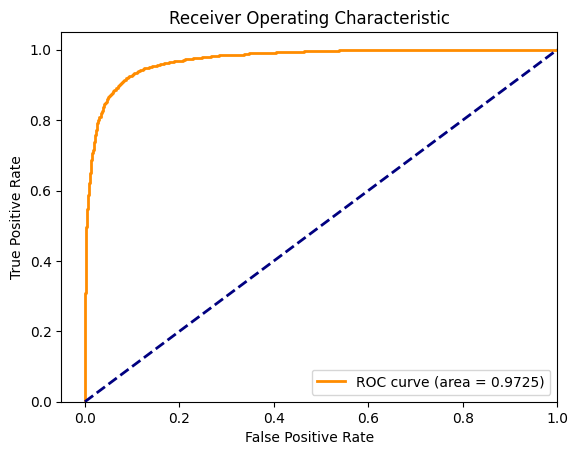

Best threshold: 0.4386398494243622


In [70]:
from sklearn.metrics import roc_curve, roc_auc_score

params = {
     'learning_rate': 0.1,
     'lambda': 1e-4,
     'gamma': 0.21,
     'alpha': 0.004,
     'subsample': 0.95,
     'colsample_bytree': 0.87,
     'max_depth': 25,
     'min_child_weight': 2
}
params.update(MODEL_PARAMS)

model, best_score = train_batch_models(params, dtrain, verbose_eval=50)
print(f"Best train accuracy: {best_score:.3f}")

# Predict on reserved DataFrame
preds = model.predict(dval)
fpr, tpr, thr = roc_curve(y_test, preds, pos_label=1)
roc_auc = roc_auc_score(y_test, preds)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

minidx = np.argmin(np.sqrt((1 - tpr) ** 2 + fpr ** 2))
print(f"Best threshold: {thr[minidx]}")

#### Continue

In [71]:
# Train model with best params (on validation) on whole dataset

params = {
     'learning_rate': 0.1,
     'lambda': 1e-4,
     'gamma': 0.21,
     'alpha': 0.004,
     'subsample': 0.95,
     'colsample_bytree': 0.87,
     'max_depth': 25,
     'min_child_weight': 2
}
params.update(MODEL_PARAMS)

X, y = df.drop("class", axis=1).to_numpy(), df["class"].to_numpy()
dtrain_all = xgb.DMatrix(X, label=y)

model, best_score = train_batch_models(params, dtrain_all, verbose_eval=50)

print(f"Best train accuracy: {best_score:.3f}")

THRESHOLD = 0.44

# Predict on reserved DataFrame
reserved_X = reserved_df.to_numpy()
preds = model.predict(xgb.DMatrix(reserved_X))
preds_classes = (preds >= THRESHOLD).astype(int)

[0]	train-logloss:0.60976	train-accuracy:0.57546
[50]	train-logloss:0.06333	train-accuracy:0.99652
[0]	train-logloss:0.61968	train-accuracy:0.57546
[50]	train-logloss:0.06595	train-accuracy:0.99699
[0]	train-logloss:0.60957	train-accuracy:0.57546
[50]	train-logloss:0.06395	train-accuracy:0.99713
[0]	train-logloss:0.60909	train-accuracy:0.57546
[50]	train-logloss:0.06348	train-accuracy:0.99696
[0]	train-logloss:0.60877	train-accuracy:0.57546
[50]	train-logloss:0.06463	train-accuracy:0.99661
[0]	train-logloss:0.61145	train-accuracy:0.57546
[50]	train-logloss:0.06369	train-accuracy:0.99655
[0]	train-logloss:0.61203	train-accuracy:0.57546
[50]	train-logloss:0.06253	train-accuracy:0.99647
[0]	train-logloss:0.60958	train-accuracy:0.57546
[50]	train-logloss:0.06314	train-accuracy:0.99674
[0]	train-logloss:0.60848	train-accuracy:0.57546
[50]	train-logloss:0.06329	train-accuracy:0.99652
[0]	train-logloss:0.60880	train-accuracy:0.57546
[50]	train-logloss:0.06383	train-accuracy:0.99743
Best train

In [72]:
print(preds_classes.tolist())

[0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 

Итоговый accuracy на зарезервированном датасете получился 0.929

## Обучение с подкреплением

### Упражнение 4.1

[Solution here](https://docs.google.com/spreadsheets/d/1X-X0M7aA-r7tFJRhlfn8ngwqmdBcoZ3QdOVJbNw8bVw/edit?usp=sharing)

Нужно только аккуратно подставить все данные значения праметров в отмеченные зелёным места

### Упражнение 4.2

In [8]:
# Устанавливаются, исходя из задания

random_seed = 6 # Random seed
epsilon = 0.1 # Параметр эпсилон при использовании эпсилон жадной стратегии
gamma = 0.8 # Коэффциент дисконтирования гамма

# Другие параметры
time_delay = 1 # Задержка времени при отрисовке процесса игры после обучения (секунды)
lr_rate = 0.9 #Коэффициент скорости обучения альфа

In [ ]:
# Установим нужную версию библиотеки gym
!git clone https://github.com/dvolchek/gym_0_18_0.git -q
%cd /content/gym_0_18_0
!pip install -e. -q

In [9]:
import gym
import numpy as np
import time
from IPython.display import clear_output


def generate_random_map(size, p, sd):
    """Generates a random valid map (one that has a path from start to goal)
    :param size: size of each side of the grid
    :param p: probability that a tile is frozen
    """
    valid = False
    np.random.seed(sd)

    # DFS to check that it's a valid path.
    def is_valid(res):
        frontier, discovered = [], set()
        frontier.append((0,0))
        while frontier:
            r, c = frontier.pop()
            if not (r,c) in discovered:
                discovered.add((r,c))
                directions = [(1, 0), (0, 1), (-1, 0), (0, -1)]
                for x, y in directions:
                    r_new = r + x
                    c_new = c + y
                    if r_new < 0 or r_new >= size or c_new < 0 or c_new >= size:
                        continue
                    if res[r_new][c_new] == 'G':
                        return True
                    if (res[r_new][c_new] not in '#H'):
                        frontier.append((r_new, c_new))
        return False

    while not valid:
        p = min(1, p)
        res = np.random.choice(['F', 'H'], (size, size), p=[p, 1-p])
        res[0][0] = 'S'
        res[-1][-1] = 'G'
        valid = is_valid(res)
    return ["".join(x) for x in res]

#Генерация карты
random_map = generate_random_map(size=6, p=0.8, sd = random_seed) #Создаем свою карту
env = gym.make("FrozenLake-v0", desc=random_map, is_slippery=False) #Инициализируем среду
print("Ваша карта")
env.render() #Выводим карту на экран

Ваша карта

SFHFFF
FFFFFF
FFFHHF
HHFFHF
FFFHFF
FHFFFG


In [10]:
def choose_action(state):
    action=0
    if np.random.uniform(0, 1) < epsilon:
        action = np.random.randint(0,env.action_space.n)
    else:
        action = np.random.choice(np.array(np.argwhere(Q[state, :] == np.amax(Q[state, :])).flatten().tolist()))
    return action

# Функция для обновления ценности
def learn(state, state2, reward, action, done):
    if done:
        Q[state, action] += lr_rate * (reward - Q[state, action])
    else:
        Q[state, action] += lr_rate * (reward + gamma * np.max(Q[state2, :]) - Q[state, action])

In [11]:
from tqdm import tqdm

# Обучение

# Inititalization
np.random.seed(random_seed)
total_games = 10000
max_steps = 100
Q = np.zeros((env.observation_space.n, env.action_space.n))

win_games = 0
streak_win_games = 1
last_win_game = first_streak_win_game = -1

#Main cycle
for game in tqdm(range(total_games)):
    state = env.reset()

    t = 0
    while t < max_steps:
        t += 1
        action = choose_action(state)

        state2, reward, done, info = env.step(action)

        if t == max_steps:
            done = True

        learn(state, state2, reward, action, done)

        state = state2

        if done and reward == 1:
            win_games += 1
            if first_streak_win_game < 0 and game == last_win_game + 1:
                streak_win_games += 1
            else:
                streak_win_games = 1

            if first_streak_win_game < 0 and streak_win_games == 5:
                first_streak_win_game = game + 1

            last_win_game = game

        if done:
            break

print("\nКоличество побед в серии из 10 000 игр: ", win_games)
print("Пять побед подряд впервые было одержано в игре ", first_streak_win_game)

100%|██████████| 10000/10000 [00:01<00:00, 7277.70it/s]


Количество побед в серии из 10 000 игр:  2202
Пять побед подряд впервые было одержано в игре  7473


In [12]:
# Визуальное отображение прохождения карты агентом

import time

#Жадный выбор действий
def choose_action_one_game(state):
    action = np.random.choice(np.array(np.argwhere(Q[state, :] == np.amax(Q[state, :])).flatten().tolist()))
    return action

# Массив для сохранения состояний агента в течение игры
states=[]
t = 0
state = env.reset()
wn = 0

while(t < 100):
    env.render()
    time.sleep(time_delay)
    clear_output(wait=True)
    action = choose_action_one_game(state)
    state2, reward, done, info = env.step(action)
    states.append(state)
    state = state2
    t += 1
    if done and reward == 1:
        wn=1
    if done:
        break

if wn == 1:
    print("!!!Победа!!!")

!!!Победа!!!


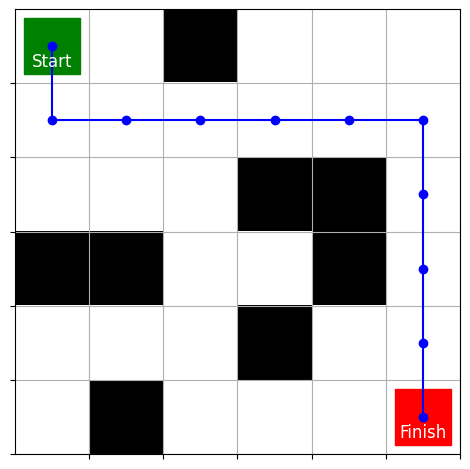

In [13]:
import matplotlib.pyplot as plt

def make_maze_pic(maze):
    maze_pic=[]

    for i in range(len(maze)):
        row = []
        for j in range(len(maze[i])):
            if maze[i][j] == 'S':
                row.append(0)
            if maze[i][j] == 'F':
                row.append(0)
            if maze[i][j] == 'H':
                row.append(1)
            if maze[i][j] == 'G':
                row.append(0)
        maze_pic.append(row)

    maze_pic = np.array(maze_pic)
    return maze_pic


#Make maze fit to plot
maze_pic = make_maze_pic(random_map)
nrows, ncols = maze_pic.shape

#Arrays of picture elements
rw = np.remainder(states,nrows)
cl = np.floor_divide(states,nrows)
if wn == 1:
    rw = np.append(rw, [nrows-1])
    cl = np.append(cl,[ncols-1])

#Picture plotting
fig, ax1 = plt.subplots(1, 1, tight_layout=True)
ax1.clear()
ax1.set_xticks(np.arange(0.5, nrows, step=1))
ax1.set_xticklabels([])
ax1.set_yticks(np.arange(0.5, ncols, step=1))
ax1.set_yticklabels([])
ax1.grid(True)
ax1.plot([0],[0], "gs", markersize=40)  # start is a big green square
ax1.text(0, 0.2,"Start", ha="center", va="center", color="white", fontsize=12) #Start text
ax1.plot([nrows-1],[ncols-1], "rs", markersize=40)  # exit is a big red square
ax1.text(nrows-1, ncols-1+0.2,"Finish", ha="center", va="center", color="white", fontsize=12) #Exit text
ax1.plot(rw,cl, ls = '-', color = 'blue') #Blue lines path
ax1.plot(rw,cl, "bo")  # Blue dots visited cells
ax1.imshow(maze_pic, cmap="binary")

# Глубокое обучение

Переходим к разделу "Глубокое обучение" или как решить все их упражнения не написав ни одной нейронки

## Перцептрон. Упражнение 5

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

### Загружаем датасет

In [14]:
!wget https://drive.google.com/uc?id=1o42zw-uR_uCLPWhcFGbrUz56UkC6HgvQ -O datasets/360T.csv

--2025-11-25 15:31:36--  https://drive.google.com/uc?id=1o42zw-uR_uCLPWhcFGbrUz56UkC6HgvQ
Resolving drive.google.com (drive.google.com)... 173.194.221.194, 2a00:1450:4010:c0a::c2
Connecting to drive.google.com (drive.google.com)|173.194.221.194|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1o42zw-uR_uCLPWhcFGbrUz56UkC6HgvQ [following]
--2025-11-25 15:31:36--  https://drive.usercontent.google.com/download?id=1o42zw-uR_uCLPWhcFGbrUz56UkC6HgvQ
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.161.132, 2a00:1450:4010:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.161.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 489503 (478K) [application/octet-stream]
Saving to: ‘datasets/360T.csv’

datasets/360T.csv   100%[===================>] 478.03K  --.-KB/s    in 0.1s    

2025-11-25 15:31:42 (3.50 MB/s) - ‘datas

In [3]:
df = pd.read_csv('datasets/360T.csv')
df

,num_frames,num_frames_avg,num_packets,num_packets_avg,num_packets_out_avg,num_packets_out_max,num_packets_out_min,num_packets_in_avg,num_packets_in_max,num_packets_in_min,...,num_forwarded_packets_avg,num_forwarded_packets_max,num_forwarded_packets_min,num_packets_created_avg,num_packets_created_max,num_packets_created_min,frac_packets_created_acquired_avg,frac_packets_created_acquired_max,frac_packets_created_acquired_min,class
0,38007,2533,31348,2089,218,1777,46,266,2266,38,...,583,1328,108,69,136,46,1.02,2,1,0
1,32695,2179,26253,1750,212,1726,48,212,1814,34,...,575,1344,105,32,83,48,1.00,1,1,0
2,32655,2177,26396,1759,212,1654,41,212,1701,30,...,578,1270,120,21,76,41,1.00,1,1,0
3,33541,2236,26612,1774,213,1695,50,214,1741,38,...,586,1316,112,1,82,50,1.00,1,1,0
4,32925,2195,26472,1764,213,1750,44,213,1805,35,...,586,1375,115,1,83,44,1.00,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2331,33025,2201,26446,1763,212,1654,45,213,1674,37,...,579,1273,126,1,81,45,1.00,1,1,1
2332,33072,2204,26372,1758,211,1685,39,212,1721,39,...,573,1307,106,1,86,39,1.00,1,1,1
2333,32555,2170,26043,1736,210,1667,48,210,1716,37,...,567,1289,117,1,77,48,1.00,1,1,1
2334,33033,2202,26395,1759,212,1714,47,213,1722,38,...,581,1335,92,1,79,46,1.00,1,1,1


Посмотрим на распределение откликов

(array([  85., 2251.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

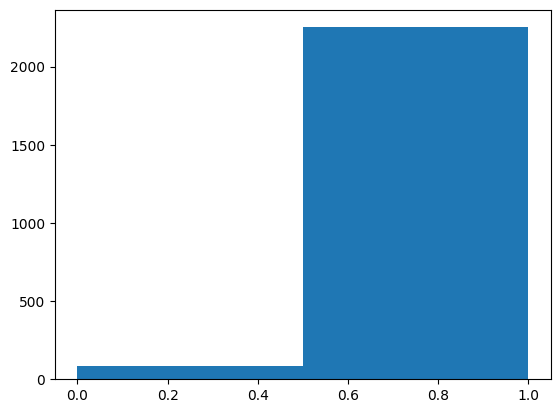

In [4]:
plt.hist(df['class'],bins = 2)

Разделим датасет на обучающую и тестовую выборки. Из-за неоднородности объектов используем стратификацию по столбцу откликов.

In [5]:
RANDOM_STATE = 94
TEST_SIZE = 0.25

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('class', axis=1), df['class'], 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify = df['class']
)

In [7]:
sc = StandardScaler()
# Обучаем скейлер на X_train и применяем преобразование
X_train_scaled = sc.fit_transform(X_train)

# Преобразовываем X_test
X_test_scaled = sc.transform(X_test)

### Строим классификатор

In [8]:
HIDDEN_LAYER_SIZES = (35, 10)

mlp = MLPClassifier(
    random_state=RANDOM_STATE, 
    hidden_layer_sizes=HIDDEN_LAYER_SIZES, 
    activation='logistic',
    max_iter=1000
)
mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(35, ...)"
,activation,'logistic'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,94


Посмотрим, как убывал loss в зависимости от номера эпохи обучения

In [9]:
y_mlp_pred = mlp.predict(X_test_scaled)
y_mlp_pred
print(classification_report(y_test, y_mlp_pred, digits=3))

              precision    recall  f1-score   support

           0      0.667     0.381     0.485        21
           1      0.977     0.993     0.985       563

    accuracy                          0.971       584
   macro avg      0.822     0.687     0.735       584
weighted avg      0.966     0.971     0.967       584



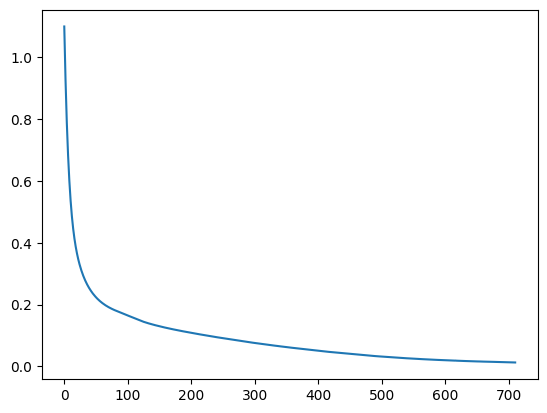

In [10]:
plt.plot(mlp.loss_curve_)

### Предсказание

In [15]:
filenames = [
    "datasets/360T/DL_Task_2_test_file_15.csv",
    "datasets/360T/DL_Task_2_test_file_54.csv",
    "datasets/360T/DL_Task_2_test_file_131.csv",
    "datasets/360T/DL_Task_2_test_file_153.csv",
]

In [18]:
for i, filename in enumerate(filenames, 1):
    test_obj = pd.read_csv(filename)
    test_obj = sc.transform(test_obj)
    obj_pred = mlp.predict(test_obj)[0]
    print(f"Объект {i}: {obj_pred}")

Объект 1: 0
Объект 2: 0
Объект 3: 1
Объект 4: 1


## Инструменты. Обучение НС. Упражнение 6

In [53]:
# Их метод скачивания датасет не работает, так что скачиваем то же самое с драйва (поддержка прислала)
!wget "https://drive.google.com/uc?id=1yQalydS4f4bRlwLb2uQV8QABa8gKNptM" -O datasets/titanic_train.csv

--2025-11-27 11:44:06--  https://drive.google.com/uc?id=1yQalydS4f4bRlwLb2uQV8QABa8gKNptM
Resolving drive.google.com (drive.google.com)... 173.194.221.194, 2a00:1450:4010:c0a::c2
Connecting to drive.google.com (drive.google.com)|173.194.221.194|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1yQalydS4f4bRlwLb2uQV8QABa8gKNptM [following]
--2025-11-27 11:44:07--  https://drive.usercontent.google.com/download?id=1yQalydS4f4bRlwLb2uQV8QABa8gKNptM
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.161.132, 2a00:1450:4010:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.161.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 128948 (126K) [application/octet-stream]
Saving to: ‘datasets/titanic_train.csv’

datasets/titanic_tr 100%[===================>] 125.93K  --.-KB/s    in 0.09s   

2025-11-27 11:44:08 (1.31 MB/s)

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [3]:
DATASET_PATH = 'datasets/titanic_train.csv'
RESERVED_DATASET_PATH = "datasets/DL_Task_3_Titain_reserved.csv"

In [4]:
df = pd.read_csv(DATASET_PATH)
reserved_df = pd.read_csv(RESERVED_DATASET_PATH)

print(df.shape)
print(reserved_df.shape)

df.head()

(1178, 14)
(131, 13)


,age,boat,body,cabin,embarked,fare,home.dest,name,parch,pclass,sex,sibsp,ticket,survived
0,29.0000,b'2',-1,b'B5',2,211.3375,"b'St Louis, MO'","b'Allen, Miss. Elisabeth Walton'",0,1,1,0,b'24160',1
1,0.9167,b'11',-1,b'C22 C26',2,151.5500,"b'Montreal, PQ / Chesterville, ON'","b'Allison, Master. Hudson Trevor'",2,1,0,1,b'113781',1
2,30.0000,b'Unknown',135,b'C22 C26',2,151.5500,"b'Montreal, PQ / Chesterville, ON'","b'Allison, Mr. Hudson Joshua Creighton'",2,1,0,1,b'113781',0
3,25.0000,b'Unknown',-1,b'C22 C26',2,151.5500,"b'Montreal, PQ / Chesterville, ON'","b'Allison, Mrs. Hudson J C (Bessie Waldo Danie...",2,1,1,1,b'113781',0
4,48.0000,b'3',-1,b'E12',2,26.5500,"b'New York, NY'","b'Anderson, Mr. Harry'",0,1,0,0,b'19952',1


In [5]:
# Дропаем ненужые фичи ticket, name, home.dest
df = df.drop(['ticket', 'name', 'home.dest'], axis=1)
reserved_df = reserved_df.drop(['ticket', 'name', 'home.dest'], axis=1)

In [6]:
# Убираем b'...' у boat, cabin, делаем labelencode
cat_feat_enc = {
    'boat': LabelEncoder(),
    'cabin': LabelEncoder()
}

for feat in cat_feat_enc:
    df[feat] = df[feat].str[2:-1]
    reserved_df[feat] = reserved_df[feat].str[2:-1]
    
    label_enc = cat_feat_enc[feat]
    label_enc.fit(df[feat].tolist() + reserved_df[feat].tolist())
    
    df[feat] = label_enc.fit_transform(df[feat])
    reserved_df.loc[~reserved_df[feat].isin(label_enc.classes_), feat] = 'Unknown'
    reserved_df[feat] = label_enc.transform(reserved_df[feat])

df.head()

,age,boat,body,cabin,embarked,fare,parch,pclass,sex,sibsp,survived
0,29.0000,11,-1,40,2,211.3375,0,1,1,0,1
1,0.9167,2,-1,75,2,151.5500,2,1,0,1,1
2,30.0000,27,135,75,2,151.5500,2,1,0,1,0
3,25.0000,27,-1,75,2,151.5500,2,1,1,1,0
4,48.0000,12,-1,142,2,26.5500,0,1,0,0,1


In [7]:
reserved_df.head()

,age,boat,body,cabin,embarked,fare,parch,pclass,sex,sibsp
0,0.8333,4,-1,177,2,29.0000,2,1,0,0
1,-1.0000,10,-1,177,1,23.2500,0,2,1,2
2,6.0000,12,-1,149,0,134.5000,2,0,0,0
3,29.0000,27,-1,177,2,9.4833,0,2,0,0
4,-1.0000,27,-1,177,2,0.0000,0,0,0,0


In [8]:
# Обучим бустинг
import xgboost as xgb

In [9]:
MODEL_PARAMS = {
    'objective': 'binary:logistic',
    "booster": "gbtree",
    'tree_method': 'hist',
}
SEEDS = [
    42, 672, 961, 956, 389, 
    387, 438, 379, 755, 173
]

In [10]:
def f1_xgb(preds, dtrain):
    labels = dtrain.get_label()
    # Расчет взвешенной MAE
    pred_clases = np.round(preds)
    f1 = f1_score(labels, pred_clases)
    return 'f1', f1

def train_batch_models(params, dtrain, dval = None, num_boost_round=1000, verbose_eval=500):
    best_model = None
    best_score = None
    for seed in SEEDS:
        params['seed'] = seed

        evals = [(dtrain, 'train')]
        if dval is not None:
            evals.append((dval, 'val'))
    
        model = xgb.train(
            params, dtrain, 
            num_boost_round=num_boost_round,
            evals=evals,
            custom_metric=f1_xgb,
            early_stopping_rounds=50,
            verbose_eval=verbose_eval
        )

        if dval is not None:
            _, score = f1_xgb(model.predict(dval), dval)
        else:
            _, score = f1_xgb(model.predict(dtrain), dtrain)

        if best_score is None or best_score < score:
            best_score = score 
            best_model = model

    return best_model, best_score


#### Params selection process (you don't need this)

In [11]:
# Создаем DMatrix
RANDOM_STATE = 3

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("survived", axis=1).to_numpy(),
    df["survived"].to_numpy(),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["survived"]
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_test, label=y_test)

In [12]:
import optuna

# Обучение моделей с подбором гиперпараметров
def objective(trial):
    params = {
        # "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.1),
        "lambda": trial.suggest_float("lambda", 1e-5, 1.0, log=True),
        'gamma': trial.suggest_float("gamma", 1e-5, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        'max_depth': trial.suggest_int("max_depth", 2, 16),
        'min_child_weight': trial.suggest_int("min_child_weight", 2, 20)
    }
    params.update(MODEL_PARAMS)

    _, score = train_batch_models(params, dtrain, dval)
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
study.best_params

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-11-27 12:04:18,244] A new study created in memory with name: no-name-ca9a6ce9-f338-4fed-880c-f89de2678242


[0]	train-logloss:0.66204	train-f1:0.00000	val-logloss:0.66066	val-f1:0.00000
[50]	train-logloss:0.21141	train-f1:0.96369	val-logloss:0.19788	val-f1:0.98324
[0]	train-logloss:0.63003	train-f1:0.00000	val-logloss:0.62944	val-f1:0.00000
[50]	train-logloss:0.19453	train-f1:0.96369	val-logloss:0.17791	val-f1:0.98324
[0]	train-logloss:0.65095	train-f1:0.00000	val-logloss:0.65211	val-f1:0.00000
[50]	train-logloss:0.17480	train-f1:0.96369	val-logloss:0.15262	val-f1:0.98324
[0]	train-logloss:0.62961	train-f1:0.00000	val-logloss:0.62900	val-f1:0.00000
[50]	train-logloss:0.20354	train-f1:0.96369	val-logloss:0.18630	val-f1:0.98324
[0]	train-logloss:0.66349	train-f1:0.00000	val-logloss:0.66468	val-f1:0.00000
[50]	train-logloss:0.20130	train-f1:0.96369	val-logloss:0.18742	val-f1:0.98324
[0]	train-logloss:0.65030	train-f1:0.00000	val-logloss:0.65113	val-f1:0.00000
[50]	train-logloss:0.22729	train-f1:0.96369	val-logloss:0.21370	val-f1:0.98324
[0]	train-logloss:0.65240	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:19,223] Trial 0 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04230133768196131, 'lambda': 0.002830949728595699, 'gamma': 0.9827352480909219, 'alpha': 0.13968912439896441, 'subsample': 0.6316265959954896, 'colsample_bytree': 0.5603401823033343, 'max_depth': 5, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65725	train-f1:0.00000	val-logloss:0.65656	val-f1:0.00000
[50]	train-logloss:0.14096	train-f1:0.96369	val-logloss:0.12620	val-f1:0.98324
[0]	train-logloss:0.60763	train-f1:0.00000	val-logloss:0.60677	val-f1:0.00000
[50]	train-logloss:0.13015	train-f1:0.96369	val-logloss:0.11054	val-f1:0.98324
[0]	train-logloss:0.64120	train-f1:0.00000	val-logloss:0.64273	val-f1:0.00000
[50]	train-logloss:0.12080	train-f1:0.96369	val-logloss:0.09704	val-f1:0.98324
[0]	train-logloss:0.60700	train-f1:0.00000	val-logloss:0.60587	val-f1:0.00000
[50]	train-logloss:0.13744	train-f1:0.96369	val-logloss:0.11720	val-f1:0.98324
[0]	train-logloss:0.66144	train-f1:0.00000	val-logloss:0.66241	val-f1:0.00000
[50]	train-logloss:0.13442	train-f1:0.96369	val-logloss:0.11714	val-f1:0.98324
[0]	train-logloss:0.64008	train-f1:0.00000	val-logloss:0.64170	val-f1:0.00000
[50]	train-logloss:0.15272	train-f1:0.96369	val-logloss:0.13701	val-f1:0.98324
[0]	train-logloss:0.64253	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:19,919] Trial 1 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06833236454495813, 'lambda': 1.8971041387256623e-05, 'gamma': 0.013602560804940596, 'alpha': 0.0003863086552772837, 'subsample': 0.8269437628676058, 'colsample_bytree': 0.5159003768042014, 'max_depth': 16, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65499	train-f1:0.00000	val-logloss:0.65463	val-f1:0.00000
[50]	train-logloss:0.16761	train-f1:0.96513	val-logloss:0.16312	val-f1:0.98324
[0]	train-logloss:0.62253	train-f1:0.00000	val-logloss:0.62199	val-f1:0.00000
[50]	train-logloss:0.15370	train-f1:0.96369	val-logloss:0.14628	val-f1:0.98324
[0]	train-logloss:0.64646	train-f1:0.00000	val-logloss:0.64705	val-f1:0.00000
[50]	train-logloss:0.13863	train-f1:0.96369	val-logloss:0.12467	val-f1:0.98324
[0]	train-logloss:0.62205	train-f1:0.00000	val-logloss:0.62171	val-f1:0.00000
[50]	train-logloss:0.16249	train-f1:0.96369	val-logloss:0.15083	val-f1:0.98324
[0]	train-logloss:0.65701	train-f1:0.00000	val-logloss:0.65775	val-f1:0.00000
[50]	train-logloss:0.15992	train-f1:0.96369	val-logloss:0.15225	val-f1:0.98324
[0]	train-logloss:0.64540	train-f1:0.00000	val-logloss:0.64760	val-f1:0.00000
[50]	train-logloss:0.18034	train-f1:0.96369	val-logloss:0.17416	val-f1:0.98324
[0]	train-logloss:0.64726	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:20,645] Trial 2 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05068060684529781, 'lambda': 0.31176936050404935, 'gamma': 0.5988039387661372, 'alpha': 0.01291905920581252, 'subsample': 0.6643623408633155, 'colsample_bytree': 0.5127803028693498, 'max_depth': 4, 'min_child_weight': 4}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64054	train-f1:0.00000	val-logloss:0.64281	val-f1:0.00000
[50]	train-logloss:0.10279	train-f1:0.96369	val-logloss:0.08321	val-f1:0.98324
[0]	train-logloss:0.61111	train-f1:0.00000	val-logloss:0.61014	val-f1:0.00000
[50]	train-logloss:0.10103	train-f1:0.96369	val-logloss:0.07618	val-f1:0.98324
[0]	train-logloss:0.61032	train-f1:0.00000	val-logloss:0.60933	val-f1:0.00000
[50]	train-logloss:0.09988	train-f1:0.96369	val-logloss:0.07403	val-f1:0.98324
[0]	train-logloss:0.61061	train-f1:0.00000	val-logloss:0.60975	val-f1:0.00000
[50]	train-logloss:0.10227	train-f1:0.96369	val-logloss:0.07827	val-f1:0.98324
[0]	train-logloss:0.64023	train-f1:0.00000	val-logloss:0.64278	val-f1:0.00000
[50]	train-logloss:0.10168	train-f1:0.96369	val-logloss:0.07708	val-f1:0.98324
[0]	train-logloss:0.61143	train-f1:0.00000	val-logloss:0.61034	val-f1:0.00000
[50]	train-logloss:0.10225	train-f1:0.96369	val-logloss:0.07731	val-f1:0.98324
[0]	train-logloss:0.61142	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:21,343] Trial 3 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06388355027497301, 'lambda': 0.0025987860558316063, 'gamma': 0.0006400299417800336, 'alpha': 0.0005818407789582054, 'subsample': 0.5990982956900767, 'colsample_bytree': 0.9036888946288235, 'max_depth': 4, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66225	train-f1:0.00000	val-logloss:0.66266	val-f1:0.00000
[50]	train-logloss:0.35135	train-f1:0.96192	val-logloss:0.35057	val-f1:0.97753
[0]	train-logloss:0.65177	train-f1:0.00000	val-logloss:0.65191	val-f1:0.00000
[50]	train-logloss:0.34012	train-f1:0.96494	val-logloss:0.33855	val-f1:0.98324
[0]	train-logloss:0.65929	train-f1:0.00000	val-logloss:0.66002	val-f1:0.00000
[50]	train-logloss:0.31611	train-f1:0.96369	val-logloss:0.31162	val-f1:0.98324
[0]	train-logloss:0.65165	train-f1:0.00000	val-logloss:0.65184	val-f1:0.00000
[50]	train-logloss:0.32100	train-f1:0.96369	val-logloss:0.31448	val-f1:0.98324
[0]	train-logloss:0.66003	train-f1:0.00000	val-logloss:0.66128	val-f1:0.00000
[50]	train-logloss:0.32350	train-f1:0.96369	val-logloss:0.32029	val-f1:0.98324
[0]	train-logloss:0.65898	train-f1:0.00000	val-logloss:0.66057	val-f1:0.00000
[50]	train-logloss:0.34396	train-f1:0.96765	val-logloss:0.34322	val-f1:0.98324
[0]	train-logloss:0.65912	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:22,058] Trial 4 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.016287261253336807, 'lambda': 0.0005600585926878726, 'gamma': 0.022756487295039797, 'alpha': 0.06903933095014154, 'subsample': 0.7806309112632935, 'colsample_bytree': 0.606046634745096, 'max_depth': 16, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66351	train-f1:0.00000	val-logloss:0.66370	val-f1:0.00000
[50]	train-logloss:0.39491	train-f1:0.94676	val-logloss:0.39364	val-f1:0.96000
[0]	train-logloss:0.65470	train-f1:0.00000	val-logloss:0.65500	val-f1:0.00000
[50]	train-logloss:0.38502	train-f1:0.96023	val-logloss:0.38393	val-f1:0.96591
[0]	train-logloss:0.66075	train-f1:0.00000	val-logloss:0.66142	val-f1:0.00000
[50]	train-logloss:0.36183	train-f1:0.96369	val-logloss:0.35698	val-f1:0.98324
[0]	train-logloss:0.65464	train-f1:0.00000	val-logloss:0.65492	val-f1:0.00000
[50]	train-logloss:0.36675	train-f1:0.96369	val-logloss:0.36043	val-f1:0.98324
[0]	train-logloss:0.66135	train-f1:0.00000	val-logloss:0.66256	val-f1:0.00000
[50]	train-logloss:0.36856	train-f1:0.96369	val-logloss:0.36521	val-f1:0.98324
[0]	train-logloss:0.66065	train-f1:0.00000	val-logloss:0.66183	val-f1:0.00000
[50]	train-logloss:0.38832	train-f1:0.96170	val-logloss:0.38770	val-f1:0.97175
[0]	train-logloss:0.66071	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:22,914] Trial 5 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.012905720592931352, 'lambda': 0.002403223207785579, 'gamma': 0.3315186743263781, 'alpha': 0.004934952703436608, 'subsample': 0.8854447304779873, 'colsample_bytree': 0.6745695966209968, 'max_depth': 8, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65593	train-f1:0.00000	val-logloss:0.65527	val-f1:0.00000
[50]	train-logloss:0.16821	train-f1:0.96369	val-logloss:0.15626	val-f1:0.98324
[0]	train-logloss:0.61970	train-f1:0.00000	val-logloss:0.61887	val-f1:0.00000
[50]	train-logloss:0.15512	train-f1:0.96369	val-logloss:0.13894	val-f1:0.98324
[0]	train-logloss:0.64580	train-f1:0.00000	val-logloss:0.64678	val-f1:0.00000
[50]	train-logloss:0.14127	train-f1:0.96369	val-logloss:0.11964	val-f1:0.98324
[0]	train-logloss:0.61917	train-f1:0.00000	val-logloss:0.61835	val-f1:0.00000
[50]	train-logloss:0.16185	train-f1:0.96369	val-logloss:0.14663	val-f1:0.98324
[0]	train-logloss:0.65889	train-f1:0.00000	val-logloss:0.65939	val-f1:0.00000
[50]	train-logloss:0.16075	train-f1:0.96369	val-logloss:0.14640	val-f1:0.98324
[0]	train-logloss:0.64523	train-f1:0.00000	val-logloss:0.64626	val-f1:0.00000
[50]	train-logloss:0.18238	train-f1:0.96369	val-logloss:0.17038	val-f1:0.98324
[0]	train-logloss:0.64746	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:23,625] Trial 6 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05425365583123823, 'lambda': 0.3048044072900623, 'gamma': 0.0877830519634657, 'alpha': 8.403008918594705e-05, 'subsample': 0.6412406450340398, 'colsample_bytree': 0.5959726015019498, 'max_depth': 11, 'min_child_weight': 12}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66304	train-f1:0.00000	val-logloss:0.66321	val-f1:0.00000
[50]	train-logloss:0.28404	train-f1:0.96369	val-logloss:0.27502	val-f1:0.98324
[0]	train-logloss:0.64259	train-f1:0.00000	val-logloss:0.64229	val-f1:0.00000
[50]	train-logloss:0.26452	train-f1:0.96369	val-logloss:0.25456	val-f1:0.98324
[0]	train-logloss:0.65611	train-f1:0.00000	val-logloss:0.65701	val-f1:0.00000
[50]	train-logloss:0.24235	train-f1:0.96369	val-logloss:0.22790	val-f1:0.98324
[0]	train-logloss:0.64224	train-f1:0.00000	val-logloss:0.64214	val-f1:0.00000
[50]	train-logloss:0.27568	train-f1:0.96369	val-logloss:0.26580	val-f1:0.98324
[0]	train-logloss:0.66432	train-f1:0.00000	val-logloss:0.66519	val-f1:0.00000
[50]	train-logloss:0.27405	train-f1:0.96369	val-logloss:0.26459	val-f1:0.98324
[0]	train-logloss:0.65574	train-f1:0.00000	val-logloss:0.65661	val-f1:0.00000
[50]	train-logloss:0.30119	train-f1:0.96224	val-logloss:0.29244	val-f1:0.98324
[0]	train-logloss:0.65711	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:24,315] Trial 7 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.027356586414269378, 'lambda': 0.0005970911002609941, 'gamma': 0.003861681961287907, 'alpha': 0.04679608463507103, 'subsample': 0.6839789557440314, 'colsample_bytree': 0.5614256059672229, 'max_depth': 12, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65582	train-f1:0.00000	val-logloss:0.65378	val-f1:0.00000
[50]	train-logloss:0.10559	train-f1:0.96369	val-logloss:0.08989	val-f1:0.98324
[0]	train-logloss:0.59263	train-f1:0.00000	val-logloss:0.59112	val-f1:0.00000
[50]	train-logloss:0.10142	train-f1:0.96369	val-logloss:0.08370	val-f1:0.98324
[0]	train-logloss:0.63493	train-f1:0.00000	val-logloss:0.63764	val-f1:0.00000
[50]	train-logloss:0.09452	train-f1:0.96369	val-logloss:0.07469	val-f1:0.98324
[0]	train-logloss:0.59191	train-f1:0.00000	val-logloss:0.59030	val-f1:0.00000
[50]	train-logloss:0.09617	train-f1:0.96369	val-logloss:0.07288	val-f1:0.98324
[0]	train-logloss:0.63886	train-f1:0.00000	val-logloss:0.64200	val-f1:0.00000
[50]	train-logloss:0.09589	train-f1:0.96369	val-logloss:0.07627	val-f1:0.98324
[0]	train-logloss:0.63409	train-f1:0.00000	val-logloss:0.63584	val-f1:0.00000
[50]	train-logloss:0.10205	train-f1:0.96369	val-logloss:0.08485	val-f1:0.98324
[0]	train-logloss:0.63417	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:24,986] Trial 8 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.08656597840723855, 'lambda': 0.0008522381379221002, 'gamma': 0.008260351100719184, 'alpha': 0.00021353454043405854, 'subsample': 0.8282250997408578, 'colsample_bytree': 0.673464253852585, 'max_depth': 2, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65516	train-f1:0.00000	val-logloss:0.65604	val-f1:0.00000
[50]	train-logloss:0.20147	train-f1:0.96369	val-logloss:0.18398	val-f1:0.98324
[0]	train-logloss:0.64109	train-f1:0.00000	val-logloss:0.64096	val-f1:0.00000
[50]	train-logloss:0.19430	train-f1:0.96369	val-logloss:0.17410	val-f1:0.98324
[0]	train-logloss:0.64098	train-f1:0.00000	val-logloss:0.64084	val-f1:0.00000
[50]	train-logloss:0.19258	train-f1:0.96369	val-logloss:0.17100	val-f1:0.98324
[0]	train-logloss:0.64098	train-f1:0.00000	val-logloss:0.64084	val-f1:0.00000
[50]	train-logloss:0.19458	train-f1:0.96369	val-logloss:0.17423	val-f1:0.98324
[0]	train-logloss:0.65509	train-f1:0.00000	val-logloss:0.65632	val-f1:0.00000
[50]	train-logloss:0.19200	train-f1:0.96369	val-logloss:0.17088	val-f1:0.98324
[0]	train-logloss:0.64104	train-f1:0.00000	val-logloss:0.64091	val-f1:0.00000
[50]	train-logloss:0.19691	train-f1:0.96369	val-logloss:0.17722	val-f1:0.98324
[0]	train-logloss:0.64106	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:25,811] Trial 9 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.0288301758410804, 'lambda': 0.7452555968810852, 'gamma': 5.172205483497078e-05, 'alpha': 1.0572726411327999e-05, 'subsample': 0.8921303282492086, 'colsample_bytree': 0.9677770451860468, 'max_depth': 14, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63358	train-f1:0.00000	val-logloss:0.63738	val-f1:0.00000
[50]	train-logloss:0.11745	train-f1:0.96369	val-logloss:0.09273	val-f1:0.98324
[0]	train-logloss:0.58826	train-f1:0.00000	val-logloss:0.58646	val-f1:0.00000
[50]	train-logloss:0.11729	train-f1:0.96369	val-logloss:0.09095	val-f1:0.98324
[0]	train-logloss:0.58683	train-f1:0.00000	val-logloss:0.58497	val-f1:0.00000
[50]	train-logloss:0.11833	train-f1:0.96369	val-logloss:0.08752	val-f1:0.98324
[0]	train-logloss:0.58732	train-f1:0.00000	val-logloss:0.58547	val-f1:0.00000
[50]	train-logloss:0.12390	train-f1:0.96369	val-logloss:0.09298	val-f1:0.98324
[0]	train-logloss:0.63176	train-f1:0.00000	val-logloss:0.63389	val-f1:0.00000
[50]	train-logloss:0.12254	train-f1:0.96369	val-logloss:0.09219	val-f1:0.98324
[0]	train-logloss:0.58805	train-f1:0.00000	val-logloss:0.58597	val-f1:0.00000
[50]	train-logloss:0.12245	train-f1:0.96369	val-logloss:0.08986	val-f1:0.98324
[0]	train-logloss:0.58900	train-f1:0.00000	val-logloss:0.5

[I 2025-11-27 12:04:26,505] Trial 10 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.09343909030486541, 'lambda': 0.019830790944583124, 'gamma': 0.00033150087666442224, 'alpha': 0.907571651023124, 'subsample': 0.5407451388403953, 'colsample_bytree': 0.8001949725082963, 'max_depth': 7, 'min_child_weight': 13}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65770	train-f1:0.00000	val-logloss:0.65716	val-f1:0.00000
[50]	train-logloss:0.14516	train-f1:0.96369	val-logloss:0.12853	val-f1:0.98324
[0]	train-logloss:0.60780	train-f1:0.00000	val-logloss:0.60661	val-f1:0.00000
[50]	train-logloss:0.13396	train-f1:0.96369	val-logloss:0.11335	val-f1:0.98324
[0]	train-logloss:0.64166	train-f1:0.00000	val-logloss:0.64291	val-f1:0.00000
[50]	train-logloss:0.12307	train-f1:0.96369	val-logloss:0.09984	val-f1:0.98324
[0]	train-logloss:0.60783	train-f1:0.00000	val-logloss:0.60665	val-f1:0.00000
[50]	train-logloss:0.14001	train-f1:0.96369	val-logloss:0.11967	val-f1:0.98324
[0]	train-logloss:0.65786	train-f1:0.00000	val-logloss:0.65766	val-f1:0.00000
[50]	train-logloss:0.13811	train-f1:0.96369	val-logloss:0.11831	val-f1:0.98324
[0]	train-logloss:0.64036	train-f1:0.00000	val-logloss:0.64181	val-f1:0.00000
[50]	train-logloss:0.15678	train-f1:0.96369	val-logloss:0.14150	val-f1:0.98324
[0]	train-logloss:0.64309	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:27,192] Trial 11 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06790297534460757, 'lambda': 1.1361409166117454e-05, 'gamma': 0.0596674777606925, 'alpha': 0.7635291646270885, 'subsample': 0.9771290241597844, 'colsample_bytree': 0.5091932298902107, 'max_depth': 6, 'min_child_weight': 20}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65072	train-f1:0.00000	val-logloss:0.65167	val-f1:0.00000
[50]	train-logloss:0.17992	train-f1:0.96369	val-logloss:0.16632	val-f1:0.98324
[0]	train-logloss:0.63124	train-f1:0.00000	val-logloss:0.63076	val-f1:0.00000
[50]	train-logloss:0.17530	train-f1:0.96369	val-logloss:0.16066	val-f1:0.98324
[0]	train-logloss:0.65119	train-f1:0.00000	val-logloss:0.65234	val-f1:0.00000
[50]	train-logloss:0.15698	train-f1:0.96369	val-logloss:0.13502	val-f1:0.98324
[0]	train-logloss:0.63085	train-f1:0.00000	val-logloss:0.63052	val-f1:0.00000
[50]	train-logloss:0.15859	train-f1:0.96369	val-logloss:0.13536	val-f1:0.98324
[0]	train-logloss:0.65094	train-f1:0.00000	val-logloss:0.65208	val-f1:0.00000
[50]	train-logloss:0.15670	train-f1:0.96369	val-logloss:0.13511	val-f1:0.98324
[0]	train-logloss:0.63128	train-f1:0.00000	val-logloss:0.63095	val-f1:0.00000
[50]	train-logloss:0.16657	train-f1:0.96369	val-logloss:0.14629	val-f1:0.98324
[0]	train-logloss:0.63115	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:27,922] Trial 12 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.040184039893276596, 'lambda': 1.2288419691091201e-05, 'gamma': 1.020099813432871e-05, 'alpha': 0.0010080250390073285, 'subsample': 0.7189432857590623, 'colsample_bytree': 0.7585597503897067, 'max_depth': 11, 'min_child_weight': 16}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65874	train-f1:0.00000	val-logloss:0.65707	val-f1:0.00000
[50]	train-logloss:0.13410	train-f1:0.96369	val-logloss:0.11280	val-f1:0.98324
[0]	train-logloss:0.60585	train-f1:0.00000	val-logloss:0.60469	val-f1:0.00000
[50]	train-logloss:0.13274	train-f1:0.96369	val-logloss:0.11004	val-f1:0.98324
[0]	train-logloss:0.64038	train-f1:0.00000	val-logloss:0.64239	val-f1:0.00000
[50]	train-logloss:0.12875	train-f1:0.96369	val-logloss:0.10220	val-f1:0.98324
[0]	train-logloss:0.60491	train-f1:0.00000	val-logloss:0.60344	val-f1:0.00000
[50]	train-logloss:0.13625	train-f1:0.96369	val-logloss:0.10747	val-f1:0.98324
[0]	train-logloss:0.64219	train-f1:0.00000	val-logloss:0.64593	val-f1:0.00000
[50]	train-logloss:0.12903	train-f1:0.96369	val-logloss:0.10223	val-f1:0.98324
[0]	train-logloss:0.63923	train-f1:0.00000	val-logloss:0.64058	val-f1:0.00000
[50]	train-logloss:0.13016	train-f1:0.96369	val-logloss:0.10566	val-f1:0.98324
[0]	train-logloss:0.64047	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:28,711] Trial 13 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07218404377377059, 'lambda': 5.689935142374609e-05, 'gamma': 0.15583944319591359, 'alpha': 0.1134736692837798, 'subsample': 0.5009229735385499, 'colsample_bytree': 0.6693759577446303, 'max_depth': 15, 'min_child_weight': 15}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65714	train-f1:0.00000	val-logloss:0.65649	val-f1:0.00000
[50]	train-logloss:0.13034	train-f1:0.96369	val-logloss:0.10818	val-f1:0.98324
[0]	train-logloss:0.59892	train-f1:0.00000	val-logloss:0.59724	val-f1:0.00000
[50]	train-logloss:0.12375	train-f1:0.96369	val-logloss:0.09796	val-f1:0.98324
[0]	train-logloss:0.63745	train-f1:0.00000	val-logloss:0.63908	val-f1:0.00000
[50]	train-logloss:0.12416	train-f1:0.96369	val-logloss:0.09521	val-f1:0.98324
[0]	train-logloss:0.59780	train-f1:0.00000	val-logloss:0.59607	val-f1:0.00000
[50]	train-logloss:0.12825	train-f1:0.96369	val-logloss:0.10410	val-f1:0.98324
[0]	train-logloss:0.66121	train-f1:0.00000	val-logloss:0.66347	val-f1:0.00000
[50]	train-logloss:0.12666	train-f1:0.96369	val-logloss:0.10288	val-f1:0.98324
[0]	train-logloss:0.63693	train-f1:0.00000	val-logloss:0.63850	val-f1:0.00000
[50]	train-logloss:0.13887	train-f1:0.96369	val-logloss:0.11891	val-f1:0.98324
[0]	train-logloss:0.63935	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:29,408] Trial 14 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.08025518573686186, 'lambda': 0.027568332271065327, 'gamma': 0.9860044600976403, 'alpha': 3.6966314432596095e-05, 'subsample': 0.768445328298639, 'colsample_bytree': 0.5010379251552427, 'max_depth': 9, 'min_child_weight': 20}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66046	train-f1:0.00000	val-logloss:0.65993	val-f1:0.00000
[50]	train-logloss:0.18751	train-f1:0.96369	val-logloss:0.17591	val-f1:0.98324
[0]	train-logloss:0.62937	train-f1:0.00000	val-logloss:0.62903	val-f1:0.00000
[50]	train-logloss:0.17720	train-f1:0.96369	val-logloss:0.16492	val-f1:0.98324
[0]	train-logloss:0.64934	train-f1:0.00000	val-logloss:0.65003	val-f1:0.00000
[50]	train-logloss:0.15666	train-f1:0.96369	val-logloss:0.13844	val-f1:0.98324
[0]	train-logloss:0.62897	train-f1:0.00000	val-logloss:0.62848	val-f1:0.00000
[50]	train-logloss:0.16190	train-f1:0.96369	val-logloss:0.14231	val-f1:0.98324
[0]	train-logloss:0.65141	train-f1:0.00000	val-logloss:0.65364	val-f1:0.00000
[50]	train-logloss:0.16208	train-f1:0.96369	val-logloss:0.14592	val-f1:0.98324
[0]	train-logloss:0.64971	train-f1:0.00000	val-logloss:0.65084	val-f1:0.00000
[50]	train-logloss:0.18075	train-f1:0.96369	val-logloss:0.16716	val-f1:0.98324
[0]	train-logloss:0.64973	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:30,121] Trial 15 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04236460790269105, 'lambda': 7.068289929928943e-05, 'gamma': 0.0006256452372685662, 'alpha': 0.002792089138203735, 'subsample': 0.833997541360984, 'colsample_bytree': 0.612186938603719, 'max_depth': 5, 'min_child_weight': 15}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64384	train-f1:0.00000	val-logloss:0.64591	val-f1:0.00000
[50]	train-logloss:0.12144	train-f1:0.96369	val-logloss:0.10146	val-f1:0.98324
[0]	train-logloss:0.61441	train-f1:0.00000	val-logloss:0.61338	val-f1:0.00000
[50]	train-logloss:0.11670	train-f1:0.96369	val-logloss:0.09222	val-f1:0.98324
[0]	train-logloss:0.61360	train-f1:0.00000	val-logloss:0.61273	val-f1:0.00000
[50]	train-logloss:0.11374	train-f1:0.96369	val-logloss:0.08801	val-f1:0.98324
[0]	train-logloss:0.61390	train-f1:0.00000	val-logloss:0.61307	val-f1:0.00000
[50]	train-logloss:0.11677	train-f1:0.96369	val-logloss:0.08809	val-f1:0.98324
[0]	train-logloss:0.64346	train-f1:0.00000	val-logloss:0.64505	val-f1:0.00000
[50]	train-logloss:0.11432	train-f1:0.96369	val-logloss:0.08910	val-f1:0.98324
[0]	train-logloss:0.61457	train-f1:0.00000	val-logloss:0.61358	val-f1:0.00000
[50]	train-logloss:0.11624	train-f1:0.96369	val-logloss:0.08908	val-f1:0.98324
[0]	train-logloss:0.61474	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:30,827] Trial 16 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06015216908501717, 'lambda': 0.023509171454589143, 'gamma': 0.01657336542056614, 'alpha': 0.013783287531024745, 'subsample': 0.5957453071317671, 'colsample_bytree': 0.8446166714833567, 'max_depth': 2, 'min_child_weight': 10}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64888	train-f1:0.00000	val-logloss:0.64969	val-f1:0.00000
[50]	train-logloss:0.16779	train-f1:0.96369	val-logloss:0.15381	val-f1:0.98324
[0]	train-logloss:0.62854	train-f1:0.00000	val-logloss:0.62795	val-f1:0.00000
[50]	train-logloss:0.16486	train-f1:0.96369	val-logloss:0.15001	val-f1:0.98324
[0]	train-logloss:0.64890	train-f1:0.00000	val-logloss:0.64978	val-f1:0.00000
[50]	train-logloss:0.14533	train-f1:0.96369	val-logloss:0.12382	val-f1:0.98324
[0]	train-logloss:0.62855	train-f1:0.00000	val-logloss:0.62796	val-f1:0.00000
[50]	train-logloss:0.14788	train-f1:0.96369	val-logloss:0.12552	val-f1:0.98324
[0]	train-logloss:0.64898	train-f1:0.00000	val-logloss:0.64966	val-f1:0.00000
[50]	train-logloss:0.14601	train-f1:0.96369	val-logloss:0.12275	val-f1:0.98324
[0]	train-logloss:0.62854	train-f1:0.00000	val-logloss:0.62795	val-f1:0.00000
[50]	train-logloss:0.15536	train-f1:0.96369	val-logloss:0.13621	val-f1:0.98324
[0]	train-logloss:0.62854	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:31,612] Trial 17 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04296664212375832, 'lambda': 9.163388872782967e-05, 'gamma': 0.0019504866467015415, 'alpha': 0.2698180898234612, 'subsample': 0.9954933772148067, 'colsample_bytree': 0.7036372802810524, 'max_depth': 13, 'min_child_weight': 17}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65298	train-f1:0.00000	val-logloss:0.64959	val-f1:0.00000
[50]	train-logloss:0.10951	train-f1:0.96369	val-logloss:0.08932	val-f1:0.98324
[0]	train-logloss:0.58194	train-f1:0.00000	val-logloss:0.57994	val-f1:0.00000
[50]	train-logloss:0.10438	train-f1:0.96369	val-logloss:0.08273	val-f1:0.98324
[0]	train-logloss:0.62862	train-f1:0.00000	val-logloss:0.62996	val-f1:0.00000
[50]	train-logloss:0.10631	train-f1:0.96369	val-logloss:0.08143	val-f1:0.98324
[0]	train-logloss:0.58116	train-f1:0.00000	val-logloss:0.57926	val-f1:0.00000
[50]	train-logloss:0.10965	train-f1:0.96369	val-logloss:0.08639	val-f1:0.98324
[0]	train-logloss:0.65165	train-f1:0.00000	val-logloss:0.65349	val-f1:0.00000
[50]	train-logloss:0.10570	train-f1:0.96369	val-logloss:0.08539	val-f1:0.98324
[0]	train-logloss:0.62862	train-f1:0.00000	val-logloss:0.63070	val-f1:0.00000
[50]	train-logloss:0.11430	train-f1:0.96369	val-logloss:0.09589	val-f1:0.98324
[0]	train-logloss:0.63212	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:32,394] Trial 18 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.09982593281854338, 'lambda': 0.007937362722977827, 'gamma': 0.03744005377190295, 'alpha': 0.0004934830890783554, 'subsample': 0.7283167035071823, 'colsample_bytree': 0.56973155529027, 'max_depth': 10, 'min_child_weight': 14}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64558	train-f1:0.00000	val-logloss:0.64893	val-f1:0.00000
[50]	train-logloss:0.09459	train-f1:0.97902	val-logloss:0.11258	val-f1:0.98324
[0]	train-logloss:0.60072	train-f1:0.00000	val-logloss:0.60047	val-f1:0.00000
[50]	train-logloss:0.08471	train-f1:0.97902	val-logloss:0.09976	val-f1:0.98324
[0]	train-logloss:0.63497	train-f1:0.00000	val-logloss:0.63616	val-f1:0.00000
[50]	train-logloss:0.07625	train-f1:0.97335	val-logloss:0.08240	val-f1:0.97753
[0]	train-logloss:0.60072	train-f1:0.00000	val-logloss:0.60103	val-f1:0.00000
[50]	train-logloss:0.08990	train-f1:0.97616	val-logloss:0.10372	val-f1:0.98324
[0]	train-logloss:0.64764	train-f1:0.00000	val-logloss:0.65110	val-f1:0.00000
[50]	train-logloss:0.08963	train-f1:0.97479	val-logloss:0.10674	val-f1:0.98324
[0]	train-logloss:0.63089	train-f1:0.00000	val-logloss:0.63871	val-f1:0.00000
[50]	train-logloss:0.10099	train-f1:0.97609	val-logloss:0.12363	val-f1:0.98324
[0]	train-logloss:0.63183	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:33,156] Trial 19 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07491698350885936, 'lambda': 0.00017294385853499982, 'gamma': 0.2003227244418522, 'alpha': 0.002496450646148802, 'subsample': 0.9150511653537217, 'colsample_bytree': 0.5583927946692383, 'max_depth': 7, 'min_child_weight': 2}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65399	train-f1:0.00000	val-logloss:0.65509	val-f1:0.00000
[50]	train-logloss:0.21713	train-f1:0.96369	val-logloss:0.20560	val-f1:0.98324
[0]	train-logloss:0.63832	train-f1:0.00000	val-logloss:0.63823	val-f1:0.00000
[50]	train-logloss:0.21261	train-f1:0.96369	val-logloss:0.19988	val-f1:0.98324
[0]	train-logloss:0.65427	train-f1:0.00000	val-logloss:0.65514	val-f1:0.00000
[50]	train-logloss:0.19003	train-f1:0.96369	val-logloss:0.17097	val-f1:0.98324
[0]	train-logloss:0.63794	train-f1:0.00000	val-logloss:0.63770	val-f1:0.00000
[50]	train-logloss:0.19157	train-f1:0.96369	val-logloss:0.17116	val-f1:0.98324
[0]	train-logloss:0.65419	train-f1:0.00000	val-logloss:0.65536	val-f1:0.00000
[50]	train-logloss:0.18896	train-f1:0.96369	val-logloss:0.16888	val-f1:0.98324
[0]	train-logloss:0.63843	train-f1:0.00000	val-logloss:0.63825	val-f1:0.00000
[50]	train-logloss:0.20087	train-f1:0.96369	val-logloss:0.18360	val-f1:0.98324
[0]	train-logloss:0.63822	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:33,856] Trial 20 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03197668205315393, 'lambda': 0.10255227190802882, 'gamma': 0.00010172062966419934, 'alpha': 0.018915310105631206, 'subsample': 0.8185127883137185, 'colsample_bytree': 0.7557492873359013, 'max_depth': 16, 'min_child_weight': 20}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65449	train-f1:0.00000	val-logloss:0.65562	val-f1:0.00000
[50]	train-logloss:0.15630	train-f1:0.96513	val-logloss:0.15286	val-f1:0.98324
[0]	train-logloss:0.61988	train-f1:0.00000	val-logloss:0.62002	val-f1:0.00000
[50]	train-logloss:0.14315	train-f1:0.96369	val-logloss:0.13806	val-f1:0.98324
[0]	train-logloss:0.64496	train-f1:0.00000	val-logloss:0.64624	val-f1:0.00000
[50]	train-logloss:0.12768	train-f1:0.96369	val-logloss:0.11744	val-f1:0.98324
[0]	train-logloss:0.61931	train-f1:0.00000	val-logloss:0.61940	val-f1:0.00000
[50]	train-logloss:0.15261	train-f1:0.96369	val-logloss:0.14387	val-f1:0.98324
[0]	train-logloss:0.65610	train-f1:0.00000	val-logloss:0.65703	val-f1:0.00000
[50]	train-logloss:0.14964	train-f1:0.96369	val-logloss:0.14468	val-f1:0.98324
[0]	train-logloss:0.64360	train-f1:0.00000	val-logloss:0.64671	val-f1:0.00000
[50]	train-logloss:0.16859	train-f1:0.96369	val-logloss:0.16575	val-f1:0.98324
[0]	train-logloss:0.64537	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:34,589] Trial 21 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05335693825373739, 'lambda': 0.12402564863022261, 'gamma': 0.9917317659901835, 'alpha': 0.01566652989154179, 'subsample': 0.6594824538976958, 'colsample_bytree': 0.5200673409928346, 'max_depth': 4, 'min_child_weight': 2}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65752	train-f1:0.00000	val-logloss:0.65895	val-f1:0.00000
[50]	train-logloss:0.16440	train-f1:0.96369	val-logloss:0.15646	val-f1:0.98324
[0]	train-logloss:0.62391	train-f1:0.00000	val-logloss:0.62327	val-f1:0.00000
[50]	train-logloss:0.15684	train-f1:0.96369	val-logloss:0.14559	val-f1:0.98324
[0]	train-logloss:0.64705	train-f1:0.00000	val-logloss:0.64812	val-f1:0.00000
[50]	train-logloss:0.13654	train-f1:0.96369	val-logloss:0.11854	val-f1:0.98324
[0]	train-logloss:0.62328	train-f1:0.00000	val-logloss:0.62261	val-f1:0.00000
[50]	train-logloss:0.14100	train-f1:0.96369	val-logloss:0.12294	val-f1:0.98324
[0]	train-logloss:0.64901	train-f1:0.00000	val-logloss:0.65028	val-f1:0.00000
[50]	train-logloss:0.14221	train-f1:0.96369	val-logloss:0.12716	val-f1:0.98324
[0]	train-logloss:0.64614	train-f1:0.00000	val-logloss:0.64836	val-f1:0.00000
[50]	train-logloss:0.15863	train-f1:0.96369	val-logloss:0.14622	val-f1:0.98324
[0]	train-logloss:0.64689	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:35,457] Trial 22 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.0499865572146103, 'lambda': 0.9515203014170804, 'gamma': 0.3572935721748814, 'alpha': 0.21217302886590664, 'subsample': 0.6113841319390507, 'colsample_bytree': 0.6320877473920262, 'max_depth': 4, 'min_child_weight': 5}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65757	train-f1:0.00000	val-logloss:0.65603	val-f1:0.00000
[50]	train-logloss:0.15219	train-f1:0.96369	val-logloss:0.14070	val-f1:0.98324
[0]	train-logloss:0.61482	train-f1:0.00000	val-logloss:0.61375	val-f1:0.00000
[50]	train-logloss:0.13978	train-f1:0.96369	val-logloss:0.12327	val-f1:0.98324
[0]	train-logloss:0.64314	train-f1:0.00000	val-logloss:0.64405	val-f1:0.00000
[50]	train-logloss:0.12687	train-f1:0.96369	val-logloss:0.10557	val-f1:0.98324
[0]	train-logloss:0.61439	train-f1:0.00000	val-logloss:0.61334	val-f1:0.00000
[50]	train-logloss:0.14635	train-f1:0.96369	val-logloss:0.13062	val-f1:0.98324
[0]	train-logloss:0.65825	train-f1:0.00000	val-logloss:0.65865	val-f1:0.00000
[50]	train-logloss:0.14485	train-f1:0.96369	val-logloss:0.13142	val-f1:0.98324
[0]	train-logloss:0.64259	train-f1:0.00000	val-logloss:0.64425	val-f1:0.00000
[50]	train-logloss:0.16334	train-f1:0.96369	val-logloss:0.15268	val-f1:0.98324
[0]	train-logloss:0.64550	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:36,192] Trial 23 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.059681494487972386, 'lambda': 0.008086943403936682, 'gamma': 0.46646646206299663, 'alpha': 0.006227272847272407, 'subsample': 0.6889208669605899, 'colsample_bytree': 0.5424032865943941, 'max_depth': 3, 'min_child_weight': 10}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65446	train-f1:0.00000	val-logloss:0.65550	val-f1:0.00000
[50]	train-logloss:0.17431	train-f1:0.96783	val-logloss:0.17763	val-f1:0.97753
[0]	train-logloss:0.62612	train-f1:0.00000	val-logloss:0.62575	val-f1:0.00000
[50]	train-logloss:0.15918	train-f1:0.96503	val-logloss:0.15852	val-f1:0.98324
[0]	train-logloss:0.64757	train-f1:0.00000	val-logloss:0.64786	val-f1:0.00000
[50]	train-logloss:0.14361	train-f1:0.96369	val-logloss:0.13749	val-f1:0.98324
[0]	train-logloss:0.62600	train-f1:0.00000	val-logloss:0.62601	val-f1:0.00000
[50]	train-logloss:0.16890	train-f1:0.96503	val-logloss:0.16518	val-f1:0.98324
[0]	train-logloss:0.65674	train-f1:0.00000	val-logloss:0.65746	val-f1:0.00000
[50]	train-logloss:0.16626	train-f1:0.96503	val-logloss:0.16733	val-f1:0.98324
[0]	train-logloss:0.64690	train-f1:0.00000	val-logloss:0.64882	val-f1:0.00000
[50]	train-logloss:0.18608	train-f1:0.96910	val-logloss:0.19049	val-f1:0.98324
[0]	train-logloss:0.64786	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:36,921] Trial 24 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.045810057246692085, 'lambda': 0.11895832278025688, 'gamma': 0.009102985413203065, 'alpha': 0.028906438386319736, 'subsample': 0.7409719998374895, 'colsample_bytree': 0.5391430444649224, 'max_depth': 6, 'min_child_weight': 4}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66304	train-f1:0.00000	val-logloss:0.66235	val-f1:0.00000
[50]	train-logloss:0.24468	train-f1:0.96369	val-logloss:0.23312	val-f1:0.98324
[0]	train-logloss:0.63648	train-f1:0.00000	val-logloss:0.63620	val-f1:0.00000
[50]	train-logloss:0.22620	train-f1:0.96369	val-logloss:0.21258	val-f1:0.98324
[0]	train-logloss:0.65380	train-f1:0.00000	val-logloss:0.65504	val-f1:0.00000
[50]	train-logloss:0.20321	train-f1:0.96369	val-logloss:0.18506	val-f1:0.98324
[0]	train-logloss:0.63602	train-f1:0.00000	val-logloss:0.63562	val-f1:0.00000
[50]	train-logloss:0.23599	train-f1:0.96369	val-logloss:0.22182	val-f1:0.98324
[0]	train-logloss:0.66422	train-f1:0.00000	val-logloss:0.66533	val-f1:0.00000
[50]	train-logloss:0.23341	train-f1:0.96369	val-logloss:0.22253	val-f1:0.98324
[0]	train-logloss:0.65313	train-f1:0.00000	val-logloss:0.65414	val-f1:0.00000
[50]	train-logloss:0.26136	train-f1:0.96369	val-logloss:0.25049	val-f1:0.98324
[0]	train-logloss:0.65427	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:37,634] Trial 25 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03454747459570088, 'lambda': 2.372997564755932e-05, 'gamma': 0.10671842549698624, 'alpha': 0.0013682678740803461, 'subsample': 0.5692956115047163, 'colsample_bytree': 0.5828412856795372, 'max_depth': 9, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66258	train-f1:0.00000	val-logloss:0.66268	val-f1:0.00000
[50]	train-logloss:0.29615	train-f1:0.96369	val-logloss:0.28737	val-f1:0.98324
[0]	train-logloss:0.64586	train-f1:0.00000	val-logloss:0.64584	val-f1:0.00000
[50]	train-logloss:0.28358	train-f1:0.96369	val-logloss:0.27484	val-f1:0.98324
[0]	train-logloss:0.65690	train-f1:0.00000	val-logloss:0.65753	val-f1:0.00000
[50]	train-logloss:0.25482	train-f1:0.96369	val-logloss:0.24218	val-f1:0.98324
[0]	train-logloss:0.64565	train-f1:0.00000	val-logloss:0.64565	val-f1:0.00000
[50]	train-logloss:0.26159	train-f1:0.96369	val-logloss:0.24783	val-f1:0.98324
[0]	train-logloss:0.65763	train-f1:0.00000	val-logloss:0.65936	val-f1:0.00000
[50]	train-logloss:0.26308	train-f1:0.96369	val-logloss:0.25268	val-f1:0.98324
[0]	train-logloss:0.65687	train-f1:0.00000	val-logloss:0.65774	val-f1:0.00000
[50]	train-logloss:0.28839	train-f1:0.96369	val-logloss:0.27846	val-f1:0.98324
[0]	train-logloss:0.65717	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:38,761] Trial 26 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.02314311534859638, 'lambda': 0.00024388429558153116, 'gamma': 0.8914462842019243, 'alpha': 0.00015851778610506307, 'subsample': 0.6647109480984936, 'colsample_bytree': 0.6290377842461591, 'max_depth': 5, 'min_child_weight': 12}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65728	train-f1:0.00000	val-logloss:0.65621	val-f1:0.00000
[50]	train-logloss:0.12885	train-f1:0.96369	val-logloss:0.11021	val-f1:0.98324
[0]	train-logloss:0.59878	train-f1:0.00000	val-logloss:0.59722	val-f1:0.00000
[50]	train-logloss:0.12017	train-f1:0.96369	val-logloss:0.09758	val-f1:0.98324
[0]	train-logloss:0.63774	train-f1:0.00000	val-logloss:0.63943	val-f1:0.00000
[50]	train-logloss:0.11934	train-f1:0.96369	val-logloss:0.09306	val-f1:0.98324
[0]	train-logloss:0.59805	train-f1:0.00000	val-logloss:0.59668	val-f1:0.00000
[50]	train-logloss:0.12508	train-f1:0.96369	val-logloss:0.10272	val-f1:0.98324
[0]	train-logloss:0.66095	train-f1:0.00000	val-logloss:0.66327	val-f1:0.00000
[50]	train-logloss:0.12298	train-f1:0.96369	val-logloss:0.10425	val-f1:0.98324
[0]	train-logloss:0.63608	train-f1:0.00000	val-logloss:0.63759	val-f1:0.00000
[50]	train-logloss:0.13695	train-f1:0.96369	val-logloss:0.11945	val-f1:0.98324
[0]	train-logloss:0.63968	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:39,498] Trial 27 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07922291887820222, 'lambda': 0.007512417654767938, 'gamma': 0.0023562296570049613, 'alpha': 0.009438559533545698, 'subsample': 0.7114756813060484, 'colsample_bytree': 0.5020824885450567, 'max_depth': 3, 'min_child_weight': 17}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65783	train-f1:0.00000	val-logloss:0.65677	val-f1:0.00000
[50]	train-logloss:0.16674	train-f1:0.96369	val-logloss:0.15677	val-f1:0.98324
[0]	train-logloss:0.62481	train-f1:0.00000	val-logloss:0.62427	val-f1:0.00000
[50]	train-logloss:0.15791	train-f1:0.96369	val-logloss:0.14666	val-f1:0.98324
[0]	train-logloss:0.64720	train-f1:0.00000	val-logloss:0.64792	val-f1:0.00000
[50]	train-logloss:0.13826	train-f1:0.96369	val-logloss:0.12083	val-f1:0.98324
[0]	train-logloss:0.62428	train-f1:0.00000	val-logloss:0.62361	val-f1:0.00000
[50]	train-logloss:0.14305	train-f1:0.96369	val-logloss:0.12382	val-f1:0.98324
[0]	train-logloss:0.64946	train-f1:0.00000	val-logloss:0.65231	val-f1:0.00000
[50]	train-logloss:0.14341	train-f1:0.96369	val-logloss:0.12976	val-f1:0.98324
[0]	train-logloss:0.64736	train-f1:0.00000	val-logloss:0.64920	val-f1:0.00000
[50]	train-logloss:0.15994	train-f1:0.96369	val-logloss:0.14870	val-f1:0.98324
[0]	train-logloss:0.64728	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:40,301] Trial 28 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04788501135635893, 'lambda': 0.05573292756229545, 'gamma': 0.048460867054251976, 'alpha': 0.15077393355028681, 'subsample': 0.7980926213590028, 'colsample_bytree': 0.6487193092584891, 'max_depth': 7, 'min_child_weight': 10}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63958	train-f1:0.00000	val-logloss:0.64169	val-f1:0.00000
[50]	train-logloss:0.11054	train-f1:0.96369	val-logloss:0.10726	val-f1:0.98324
[0]	train-logloss:0.61218	train-f1:0.00000	val-logloss:0.61149	val-f1:0.00000
[50]	train-logloss:0.10980	train-f1:0.96369	val-logloss:0.10151	val-f1:0.98324
[0]	train-logloss:0.63912	train-f1:0.00000	val-logloss:0.64104	val-f1:0.00000
[50]	train-logloss:0.09813	train-f1:0.96369	val-logloss:0.08301	val-f1:0.98324
[0]	train-logloss:0.61146	train-f1:0.00000	val-logloss:0.61103	val-f1:0.00000
[50]	train-logloss:0.10034	train-f1:0.96369	val-logloss:0.08501	val-f1:0.98324
[0]	train-logloss:0.63888	train-f1:0.00000	val-logloss:0.63947	val-f1:0.00000
[50]	train-logloss:0.09868	train-f1:0.96369	val-logloss:0.08513	val-f1:0.98324
[0]	train-logloss:0.61220	train-f1:0.00000	val-logloss:0.61107	val-f1:0.00000
[50]	train-logloss:0.10361	train-f1:0.96369	val-logloss:0.09314	val-f1:0.98324
[0]	train-logloss:0.61191	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:41,111] Trial 29 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06236788408899597, 'lambda': 0.0012114208384911393, 'gamma': 0.18876331286824627, 'alpha': 0.0002885604190938955, 'subsample': 0.6207697435369737, 'colsample_bytree': 0.716103237061484, 'max_depth': 5, 'min_child_weight': 4}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65247	train-f1:0.00000	val-logloss:0.65363	val-f1:0.00000
[50]	train-logloss:0.16650	train-f1:0.96369	val-logloss:0.14290	val-f1:0.98324
[0]	train-logloss:0.63378	train-f1:0.00000	val-logloss:0.63331	val-f1:0.00000
[50]	train-logloss:0.16272	train-f1:0.96369	val-logloss:0.13498	val-f1:0.98324
[0]	train-logloss:0.63332	train-f1:0.00000	val-logloss:0.63283	val-f1:0.00000
[50]	train-logloss:0.16063	train-f1:0.96369	val-logloss:0.13187	val-f1:0.98324
[0]	train-logloss:0.63338	train-f1:0.00000	val-logloss:0.63290	val-f1:0.00000
[50]	train-logloss:0.16188	train-f1:0.96369	val-logloss:0.13534	val-f1:0.98324
[0]	train-logloss:0.65203	train-f1:0.00000	val-logloss:0.65309	val-f1:0.00000
[50]	train-logloss:0.16202	train-f1:0.96369	val-logloss:0.13366	val-f1:0.98324
[0]	train-logloss:0.63336	train-f1:0.00000	val-logloss:0.63288	val-f1:0.00000
[50]	train-logloss:0.16389	train-f1:0.96369	val-logloss:0.13746	val-f1:0.98324
[0]	train-logloss:0.63393	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:41,818] Trial 30 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03776261905267794, 'lambda': 0.003708682542352711, 'gamma': 0.37383364672768776, 'alpha': 0.31226566381642373, 'subsample': 0.5677225539732411, 'colsample_bytree': 0.9985253200948347, 'max_depth': 3, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63944	train-f1:0.00000	val-logloss:0.64174	val-f1:0.00000
[50]	train-logloss:0.09974	train-f1:0.96369	val-logloss:0.08107	val-f1:0.98324
[0]	train-logloss:0.60920	train-f1:0.00000	val-logloss:0.60826	val-f1:0.00000
[50]	train-logloss:0.09840	train-f1:0.96369	val-logloss:0.07439	val-f1:0.98324
[0]	train-logloss:0.60822	train-f1:0.00000	val-logloss:0.60727	val-f1:0.00000
[50]	train-logloss:0.09822	train-f1:0.96369	val-logloss:0.07202	val-f1:0.98324
[0]	train-logloss:0.60882	train-f1:0.00000	val-logloss:0.60781	val-f1:0.00000
[50]	train-logloss:0.09915	train-f1:0.96369	val-logloss:0.07609	val-f1:0.98324
[0]	train-logloss:0.63891	train-f1:0.00000	val-logloss:0.64167	val-f1:0.00000
[50]	train-logloss:0.09900	train-f1:0.96369	val-logloss:0.07544	val-f1:0.98324
[0]	train-logloss:0.60934	train-f1:0.00000	val-logloss:0.60821	val-f1:0.00000
[50]	train-logloss:0.09938	train-f1:0.96369	val-logloss:0.07611	val-f1:0.98324
[0]	train-logloss:0.60929	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:42,538] Trial 31 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06619121272522863, 'lambda': 0.0014497884135174332, 'gamma': 0.0008340027750234113, 'alpha': 0.0009475068390801593, 'subsample': 0.6351947794139289, 'colsample_bytree': 0.9153203434278004, 'max_depth': 4, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64141	train-f1:0.00000	val-logloss:0.64310	val-f1:0.00000
[50]	train-logloss:0.11202	train-f1:0.96369	val-logloss:0.09976	val-f1:0.98324
[0]	train-logloss:0.61447	train-f1:0.00000	val-logloss:0.61376	val-f1:0.00000
[50]	train-logloss:0.10800	train-f1:0.96369	val-logloss:0.09209	val-f1:0.98324
[0]	train-logloss:0.61378	train-f1:0.00000	val-logloss:0.61303	val-f1:0.00000
[50]	train-logloss:0.10332	train-f1:0.96369	val-logloss:0.08338	val-f1:0.98324
[0]	train-logloss:0.61395	train-f1:0.00000	val-logloss:0.61319	val-f1:0.00000
[50]	train-logloss:0.10512	train-f1:0.96369	val-logloss:0.08239	val-f1:0.98324
[0]	train-logloss:0.64120	train-f1:0.00000	val-logloss:0.64381	val-f1:0.00000
[50]	train-logloss:0.10442	train-f1:0.96369	val-logloss:0.08478	val-f1:0.98324
[0]	train-logloss:0.61451	train-f1:0.00000	val-logloss:0.61348	val-f1:0.00000
[50]	train-logloss:0.10630	train-f1:0.96369	val-logloss:0.08637	val-f1:0.98324
[0]	train-logloss:0.61467	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:43,264] Trial 32 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.059911996586004046, 'lambda': 0.00029701756626739393, 'gamma': 0.00011659306798934812, 'alpha': 0.0005464370967944174, 'subsample': 0.5815144081557513, 'colsample_bytree': 0.8824828182639235, 'max_depth': 6, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65869	train-f1:0.00000	val-logloss:0.65973	val-f1:0.00000
[50]	train-logloss:0.30078	train-f1:0.96369	val-logloss:0.29401	val-f1:0.98324
[0]	train-logloss:0.65023	train-f1:0.00000	val-logloss:0.65034	val-f1:0.00000
[50]	train-logloss:0.29025	train-f1:0.96369	val-logloss:0.28197	val-f1:0.98324
[0]	train-logloss:0.64986	train-f1:0.00000	val-logloss:0.65000	val-f1:0.00000
[50]	train-logloss:0.27706	train-f1:0.96369	val-logloss:0.26611	val-f1:0.98324
[0]	train-logloss:0.65004	train-f1:0.00000	val-logloss:0.65022	val-f1:0.00000
[50]	train-logloss:0.27529	train-f1:0.96369	val-logloss:0.26237	val-f1:0.98324
[0]	train-logloss:0.65887	train-f1:0.00000	val-logloss:0.65974	val-f1:0.00000
[50]	train-logloss:0.27375	train-f1:0.96369	val-logloss:0.26142	val-f1:0.98324
[0]	train-logloss:0.65008	train-f1:0.00000	val-logloss:0.65021	val-f1:0.00000
[50]	train-logloss:0.28213	train-f1:0.96369	val-logloss:0.27144	val-f1:0.98324
[0]	train-logloss:0.65015	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:43,977] Trial 33 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.01815884092343078, 'lambda': 0.00282008350388738, 'gamma': 0.0008057637830739393, 'alpha': 4.8821963528074085e-05, 'subsample': 0.5235953757167067, 'colsample_bytree': 0.8009937281838407, 'max_depth': 8, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65457	train-f1:0.00000	val-logloss:0.65512	val-f1:0.00000
[50]	train-logloss:0.14446	train-f1:0.96639	val-logloss:0.14176	val-f1:0.98324
[0]	train-logloss:0.62032	train-f1:0.00000	val-logloss:0.62012	val-f1:0.00000
[50]	train-logloss:0.13752	train-f1:0.96513	val-logloss:0.13406	val-f1:0.98324
[0]	train-logloss:0.64490	train-f1:0.00000	val-logloss:0.64588	val-f1:0.00000
[50]	train-logloss:0.11971	train-f1:0.96369	val-logloss:0.11167	val-f1:0.98324
[0]	train-logloss:0.62001	train-f1:0.00000	val-logloss:0.61963	val-f1:0.00000
[50]	train-logloss:0.12261	train-f1:0.96369	val-logloss:0.11166	val-f1:0.98324
[0]	train-logloss:0.64695	train-f1:0.00000	val-logloss:0.64939	val-f1:0.00000
[50]	train-logloss:0.12407	train-f1:0.96369	val-logloss:0.11976	val-f1:0.98324
[0]	train-logloss:0.64329	train-f1:0.00000	val-logloss:0.64683	val-f1:0.00000
[50]	train-logloss:0.13833	train-f1:0.96503	val-logloss:0.13411	val-f1:0.98324
[0]	train-logloss:0.64377	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:44,824] Trial 34 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05329654607867456, 'lambda': 0.40842692348834847, 'gamma': 0.006221561712992955, 'alpha': 0.0529182010880115, 'subsample': 0.6877415461688635, 'colsample_bytree': 0.6000027745063963, 'max_depth': 4, 'min_child_weight': 3}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65777	train-f1:0.00000	val-logloss:0.65617	val-f1:0.00000
[50]	train-logloss:0.13476	train-f1:0.96369	val-logloss:0.12287	val-f1:0.98324
[0]	train-logloss:0.60702	train-f1:0.00000	val-logloss:0.60595	val-f1:0.00000
[50]	train-logloss:0.12296	train-f1:0.96369	val-logloss:0.10566	val-f1:0.98324
[0]	train-logloss:0.64088	train-f1:0.00000	val-logloss:0.64318	val-f1:0.00000
[50]	train-logloss:0.11280	train-f1:0.96369	val-logloss:0.09049	val-f1:0.98324
[0]	train-logloss:0.60645	train-f1:0.00000	val-logloss:0.60527	val-f1:0.00000
[50]	train-logloss:0.12957	train-f1:0.96369	val-logloss:0.11149	val-f1:0.98324
[0]	train-logloss:0.65978	train-f1:0.00000	val-logloss:0.66053	val-f1:0.00000
[50]	train-logloss:0.12791	train-f1:0.96369	val-logloss:0.11316	val-f1:0.98324
[0]	train-logloss:0.64027	train-f1:0.00000	val-logloss:0.64179	val-f1:0.00000
[50]	train-logloss:0.14510	train-f1:0.96369	val-logloss:0.13184	val-f1:0.98324
[0]	train-logloss:0.64334	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:45,534] Trial 35 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.0688902971789243, 'lambda': 0.003749095814768811, 'gamma': 0.01842372949312047, 'alpha': 0.004066027280056674, 'subsample': 0.7592390845545741, 'colsample_bytree': 0.540614673357534, 'max_depth': 2, 'min_child_weight': 5}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64294	train-f1:0.00000	val-logloss:0.64472	val-f1:0.00000
[50]	train-logloss:0.12196	train-f1:0.96369	val-logloss:0.10530	val-f1:0.98324
[0]	train-logloss:0.61799	train-f1:0.00000	val-logloss:0.61704	val-f1:0.00000
[50]	train-logloss:0.11723	train-f1:0.96369	val-logloss:0.09726	val-f1:0.98324
[0]	train-logloss:0.61694	train-f1:0.00000	val-logloss:0.61623	val-f1:0.00000
[50]	train-logloss:0.11172	train-f1:0.96369	val-logloss:0.08898	val-f1:0.98324
[0]	train-logloss:0.61741	train-f1:0.00000	val-logloss:0.61654	val-f1:0.00000
[50]	train-logloss:0.11333	train-f1:0.96369	val-logloss:0.08834	val-f1:0.98324
[0]	train-logloss:0.64318	train-f1:0.00000	val-logloss:0.64569	val-f1:0.00000
[50]	train-logloss:0.11308	train-f1:0.96369	val-logloss:0.08864	val-f1:0.98324
[0]	train-logloss:0.61784	train-f1:0.00000	val-logloss:0.61694	val-f1:0.00000
[50]	train-logloss:0.11606	train-f1:0.96369	val-logloss:0.09236	val-f1:0.98324
[0]	train-logloss:0.61783	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:46,261] Trial 36 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05598558042087445, 'lambda': 0.0005109875045086362, 'gamma': 0.00021458699022596905, 'alpha': 0.00010410703566662928, 'subsample': 0.6495632736749553, 'colsample_bytree': 0.8938889310905979, 'max_depth': 13, 'min_child_weight': 9}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64922	train-f1:0.00000	val-logloss:0.64860	val-f1:0.00000
[50]	train-logloss:0.10407	train-f1:0.96369	val-logloss:0.10204	val-f1:0.98324
[0]	train-logloss:0.59321	train-f1:0.00000	val-logloss:0.59133	val-f1:0.00000
[50]	train-logloss:0.09672	train-f1:0.96369	val-logloss:0.08792	val-f1:0.98324
[0]	train-logloss:0.63297	train-f1:0.00000	val-logloss:0.63397	val-f1:0.00000
[50]	train-logloss:0.09120	train-f1:0.96369	val-logloss:0.07868	val-f1:0.98324
[0]	train-logloss:0.59295	train-f1:0.00000	val-logloss:0.59147	val-f1:0.00000
[50]	train-logloss:0.10140	train-f1:0.96369	val-logloss:0.09303	val-f1:0.98324
[0]	train-logloss:0.64991	train-f1:0.00000	val-logloss:0.64965	val-f1:0.00000
[50]	train-logloss:0.09921	train-f1:0.96369	val-logloss:0.09375	val-f1:0.98324
[0]	train-logloss:0.63135	train-f1:0.00000	val-logloss:0.63490	val-f1:0.00000
[50]	train-logloss:0.11155	train-f1:0.96503	val-logloss:0.10999	val-f1:0.98324
[0]	train-logloss:0.63343	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:46,977] Trial 37 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.08531325728215933, 'lambda': 0.013375974890230269, 'gamma': 3.7572746133311716e-05, 'alpha': 0.0018833282070832517, 'subsample': 0.8701327075527822, 'colsample_bytree': 0.586693188117936, 'max_depth': 8, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64248	train-f1:0.00000	val-logloss:0.64455	val-f1:0.00000
[50]	train-logloss:0.12335	train-f1:0.96369	val-logloss:0.09613	val-f1:0.98324
[0]	train-logloss:0.61121	train-f1:0.00000	val-logloss:0.60995	val-f1:0.00000
[50]	train-logloss:0.12111	train-f1:0.96369	val-logloss:0.09388	val-f1:0.98324
[0]	train-logloss:0.61010	train-f1:0.00000	val-logloss:0.60926	val-f1:0.00000
[50]	train-logloss:0.12153	train-f1:0.96369	val-logloss:0.09184	val-f1:0.98324
[0]	train-logloss:0.61053	train-f1:0.00000	val-logloss:0.60960	val-f1:0.00000
[50]	train-logloss:0.12491	train-f1:0.96369	val-logloss:0.09616	val-f1:0.98324
[0]	train-logloss:0.64108	train-f1:0.00000	val-logloss:0.64302	val-f1:0.00000
[50]	train-logloss:0.12716	train-f1:0.96369	val-logloss:0.09539	val-f1:0.98324
[0]	train-logloss:0.61099	train-f1:0.00000	val-logloss:0.61011	val-f1:0.00000
[50]	train-logloss:0.12148	train-f1:0.96369	val-logloss:0.09094	val-f1:0.98324
[0]	train-logloss:0.61169	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:47,824] Trial 38 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06434233349157735, 'lambda': 0.05333307289528726, 'gamma': 0.001395388007255791, 'alpha': 0.00034835970105755523, 'subsample': 0.5400663929979239, 'colsample_bytree': 0.9392590533077851, 'max_depth': 11, 'min_child_weight': 13}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63501	train-f1:0.00000	val-logloss:0.63661	val-f1:0.00000
[50]	train-logloss:0.09500	train-f1:0.96369	val-logloss:0.08410	val-f1:0.98324
[0]	train-logloss:0.60323	train-f1:0.00000	val-logloss:0.60176	val-f1:0.00000
[50]	train-logloss:0.09276	train-f1:0.96369	val-logloss:0.07868	val-f1:0.98324
[0]	train-logloss:0.60188	train-f1:0.00000	val-logloss:0.60022	val-f1:0.00000
[50]	train-logloss:0.09065	train-f1:0.96369	val-logloss:0.07257	val-f1:0.98324
[0]	train-logloss:0.60264	train-f1:0.00000	val-logloss:0.60171	val-f1:0.00000
[50]	train-logloss:0.09182	train-f1:0.96369	val-logloss:0.07231	val-f1:0.98324
[0]	train-logloss:0.63402	train-f1:0.00000	val-logloss:0.63745	val-f1:0.00000
[50]	train-logloss:0.09109	train-f1:0.96369	val-logloss:0.07243	val-f1:0.98324
[0]	train-logloss:0.60306	train-f1:0.00000	val-logloss:0.60150	val-f1:0.00000
[50]	train-logloss:0.09107	train-f1:0.96369	val-logloss:0.07372	val-f1:0.98324
[0]	train-logloss:0.60305	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:48,564] Trial 39 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07332917786282221, 'lambda': 0.0006172905653668959, 'gamma': 0.029448419246940066, 'alpha': 0.08924567916736126, 'subsample': 0.7886176339148725, 'colsample_bytree': 0.8090063951669786, 'max_depth': 16, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65888	train-f1:0.00000	val-logloss:0.65836	val-f1:0.00000
[50]	train-logloss:0.16367	train-f1:0.96369	val-logloss:0.15240	val-f1:0.98324
[0]	train-logloss:0.61750	train-f1:0.00000	val-logloss:0.61681	val-f1:0.00000
[50]	train-logloss:0.15043	train-f1:0.96369	val-logloss:0.13402	val-f1:0.98324
[0]	train-logloss:0.64536	train-f1:0.00000	val-logloss:0.64676	val-f1:0.00000
[50]	train-logloss:0.13613	train-f1:0.96369	val-logloss:0.11519	val-f1:0.98324
[0]	train-logloss:0.61749	train-f1:0.00000	val-logloss:0.61656	val-f1:0.00000
[50]	train-logloss:0.15698	train-f1:0.96369	val-logloss:0.14157	val-f1:0.98324
[0]	train-logloss:0.66211	train-f1:0.00000	val-logloss:0.66295	val-f1:0.00000
[50]	train-logloss:0.15555	train-f1:0.96369	val-logloss:0.14147	val-f1:0.98324
[0]	train-logloss:0.64444	train-f1:0.00000	val-logloss:0.64564	val-f1:0.00000
[50]	train-logloss:0.17662	train-f1:0.96369	val-logloss:0.16570	val-f1:0.98324
[0]	train-logloss:0.64673	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:49,295] Trial 40 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05606075884353626, 'lambda': 0.001298948581077475, 'gamma': 0.00459049114816402, 'alpha': 2.3062682556632752e-05, 'subsample': 0.9277794538581414, 'colsample_bytree': 0.528031236769601, 'max_depth': 5, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66254	train-f1:0.00000	val-logloss:0.66369	val-f1:0.00000
[50]	train-logloss:0.41757	train-f1:0.89466	val-logloss:0.42156	val-f1:0.89697
[0]	train-logloss:0.65551	train-f1:0.00000	val-logloss:0.65595	val-f1:0.00000
[50]	train-logloss:0.40296	train-f1:0.94964	val-logloss:0.40592	val-f1:0.94798
[0]	train-logloss:0.66123	train-f1:0.00000	val-logloss:0.66184	val-f1:0.00000
[50]	train-logloss:0.38541	train-f1:0.96620	val-logloss:0.38542	val-f1:0.96000
[0]	train-logloss:0.65547	train-f1:0.00000	val-logloss:0.65596	val-f1:0.00000
[50]	train-logloss:0.41239	train-f1:0.92941	val-logloss:0.41411	val-f1:0.94186
[0]	train-logloss:0.66364	train-f1:0.00000	val-logloss:0.66437	val-f1:0.00000
[50]	train-logloss:0.41044	train-f1:0.91964	val-logloss:0.41304	val-f1:0.92308
[0]	train-logloss:0.66095	train-f1:0.00000	val-logloss:0.66196	val-f1:0.00000
[50]	train-logloss:0.42738	train-f1:0.88444	val-logloss:0.43230	val-f1:0.89024
[0]	train-logloss:0.66116	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:50,053] Trial 41 finished with value: 0.96 and parameters: {'learning_rate': 0.011918555657915861, 'lambda': 3.811093754124818e-05, 'gamma': 0.09436408097630974, 'alpha': 0.054900283346214836, 'subsample': 0.8599051125214784, 'colsample_bytree': 0.5617388361424203, 'max_depth': 15, 'min_child_weight': 5}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65962	train-f1:0.00000	val-logloss:0.66058	val-f1:0.00000
[50]	train-logloss:0.29878	train-f1:0.96774	val-logloss:0.30308	val-f1:0.97753
[0]	train-logloss:0.64772	train-f1:0.00000	val-logloss:0.64845	val-f1:0.00000
[50]	train-logloss:0.28840	train-f1:0.96503	val-logloss:0.29114	val-f1:0.98324
[0]	train-logloss:0.65692	train-f1:0.00000	val-logloss:0.65814	val-f1:0.00000
[50]	train-logloss:0.26388	train-f1:0.96369	val-logloss:0.26223	val-f1:0.98324
[0]	train-logloss:0.64758	train-f1:0.00000	val-logloss:0.64778	val-f1:0.00000
[50]	train-logloss:0.26885	train-f1:0.96369	val-logloss:0.26383	val-f1:0.98324
[0]	train-logloss:0.65812	train-f1:0.00000	val-logloss:0.65949	val-f1:0.00000
[50]	train-logloss:0.27226	train-f1:0.96369	val-logloss:0.27232	val-f1:0.98324
[0]	train-logloss:0.65660	train-f1:0.00000	val-logloss:0.65858	val-f1:0.00000
[50]	train-logloss:0.29071	train-f1:0.96774	val-logloss:0.29413	val-f1:0.98324
[0]	train-logloss:0.65657	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:50,927] Trial 42 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.020960861652248346, 'lambda': 0.001730410731508664, 'gamma': 0.009662224721985914, 'alpha': 0.46032158492659564, 'subsample': 0.7750379597330774, 'colsample_bytree': 0.6132817709922944, 'max_depth': 14, 'min_child_weight': 3}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65501	train-f1:0.00000	val-logloss:0.65584	val-f1:0.00000
[50]	train-logloss:0.24442	train-f1:0.96369	val-logloss:0.23907	val-f1:0.98324
[0]	train-logloss:0.64315	train-f1:0.00000	val-logloss:0.64312	val-f1:0.00000
[50]	train-logloss:0.24048	train-f1:0.96369	val-logloss:0.23293	val-f1:0.98324
[0]	train-logloss:0.65526	train-f1:0.00000	val-logloss:0.65601	val-f1:0.00000
[50]	train-logloss:0.21434	train-f1:0.96369	val-logloss:0.20133	val-f1:0.98324
[0]	train-logloss:0.64299	train-f1:0.00000	val-logloss:0.64294	val-f1:0.00000
[50]	train-logloss:0.21633	train-f1:0.96369	val-logloss:0.20278	val-f1:0.98324
[0]	train-logloss:0.65467	train-f1:0.00000	val-logloss:0.65582	val-f1:0.00000
[50]	train-logloss:0.21355	train-f1:0.96369	val-logloss:0.19935	val-f1:0.98324
[0]	train-logloss:0.64322	train-f1:0.00000	val-logloss:0.64311	val-f1:0.00000
[50]	train-logloss:0.22760	train-f1:0.96369	val-logloss:0.21625	val-f1:0.98324
[0]	train-logloss:0.64312	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:51,639] Trial 43 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.02621176216296004, 'lambda': 0.004664654139423158, 'gamma': 0.5598301449541515, 'alpha': 0.03765297160011289, 'subsample': 0.7001484583938843, 'colsample_bytree': 0.702051610645244, 'max_depth': 15, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66212	train-f1:0.00000	val-logloss:0.66254	val-f1:0.00000
[50]	train-logloss:0.35869	train-f1:0.95415	val-logloss:0.36012	val-f1:0.96591
[0]	train-logloss:0.65132	train-f1:0.00000	val-logloss:0.65143	val-f1:0.00000
[50]	train-logloss:0.34196	train-f1:0.96494	val-logloss:0.34112	val-f1:0.97753
[0]	train-logloss:0.65931	train-f1:0.00000	val-logloss:0.66004	val-f1:0.00000
[50]	train-logloss:0.32250	train-f1:0.96369	val-logloss:0.31952	val-f1:0.98324
[0]	train-logloss:0.65120	train-f1:0.00000	val-logloss:0.65142	val-f1:0.00000
[50]	train-logloss:0.35295	train-f1:0.96348	val-logloss:0.35212	val-f1:0.97753
[0]	train-logloss:0.66279	train-f1:0.00000	val-logloss:0.66322	val-f1:0.00000
[50]	train-logloss:0.35055	train-f1:0.96464	val-logloss:0.35084	val-f1:0.96591
[0]	train-logloss:0.65897	train-f1:0.00000	val-logloss:0.66030	val-f1:0.00000
[50]	train-logloss:0.37101	train-f1:0.93586	val-logloss:0.37295	val-f1:0.95402
[0]	train-logloss:0.65931	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:52,384] Trial 44 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.016743553021842383, 'lambda': 0.0007455406027494484, 'gamma': 0.016888024709414824, 'alpha': 0.006849558864981758, 'subsample': 0.8150587730438379, 'colsample_bytree': 0.5207904248893677, 'max_depth': 12, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65626	train-f1:0.00000	val-logloss:0.65684	val-f1:0.00000
[50]	train-logloss:0.13255	train-f1:0.96369	val-logloss:0.11235	val-f1:0.98324
[0]	train-logloss:0.60706	train-f1:0.00000	val-logloss:0.60535	val-f1:0.00000
[50]	train-logloss:0.12736	train-f1:0.96369	val-logloss:0.10482	val-f1:0.98324
[0]	train-logloss:0.64087	train-f1:0.00000	val-logloss:0.64280	val-f1:0.00000
[50]	train-logloss:0.12111	train-f1:0.96369	val-logloss:0.09479	val-f1:0.98324
[0]	train-logloss:0.60546	train-f1:0.00000	val-logloss:0.60420	val-f1:0.00000
[50]	train-logloss:0.12925	train-f1:0.96369	val-logloss:0.10039	val-f1:0.98324
[0]	train-logloss:0.64367	train-f1:0.00000	val-logloss:0.64698	val-f1:0.00000
[50]	train-logloss:0.12196	train-f1:0.96369	val-logloss:0.09500	val-f1:0.98324
[0]	train-logloss:0.63925	train-f1:0.00000	val-logloss:0.64056	val-f1:0.00000
[50]	train-logloss:0.12812	train-f1:0.96369	val-logloss:0.10344	val-f1:0.98324
[0]	train-logloss:0.64073	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:53,154] Trial 45 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07019246272823053, 'lambda': 0.00011341187518825779, 'gamma': 0.00044677849547754457, 'alpha': 0.07654955625173093, 'subsample': 0.6171838377373013, 'colsample_bytree': 0.6595993696593018, 'max_depth': 16, 'min_child_weight': 16}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65690	train-f1:0.00000	val-logloss:0.65488	val-f1:0.00000
[50]	train-logloss:0.12386	train-f1:0.96369	val-logloss:0.11096	val-f1:0.98324
[0]	train-logloss:0.60041	train-f1:0.00000	val-logloss:0.59915	val-f1:0.00000
[50]	train-logloss:0.11411	train-f1:0.96369	val-logloss:0.09708	val-f1:0.98324
[0]	train-logloss:0.63811	train-f1:0.00000	val-logloss:0.64063	val-f1:0.00000
[50]	train-logloss:0.10607	train-f1:0.96369	val-logloss:0.08290	val-f1:0.98324
[0]	train-logloss:0.59982	train-f1:0.00000	val-logloss:0.59846	val-f1:0.00000
[50]	train-logloss:0.11934	train-f1:0.96369	val-logloss:0.10234	val-f1:0.98324
[0]	train-logloss:0.65872	train-f1:0.00000	val-logloss:0.65956	val-f1:0.00000
[50]	train-logloss:0.11952	train-f1:0.96369	val-logloss:0.10460	val-f1:0.98324
[0]	train-logloss:0.63702	train-f1:0.00000	val-logloss:0.63864	val-f1:0.00000
[50]	train-logloss:0.13313	train-f1:0.96369	val-logloss:0.11919	val-f1:0.98324
[0]	train-logloss:0.64066	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:53,959] Trial 46 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07691017983946133, 'lambda': 0.00036963923532899626, 'gamma': 0.07600910470607201, 'alpha': 0.0006108777634857102, 'subsample': 0.6708279665766514, 'colsample_bytree': 0.5620273129229776, 'max_depth': 2, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64825	train-f1:0.00000	val-logloss:0.65022	val-f1:0.00000
[50]	train-logloss:0.17087	train-f1:0.96910	val-logloss:0.17427	val-f1:0.98324
[0]	train-logloss:0.63343	train-f1:0.00000	val-logloss:0.63327	val-f1:0.00000
[50]	train-logloss:0.16793	train-f1:0.96774	val-logloss:0.16886	val-f1:0.98324
[0]	train-logloss:0.64818	train-f1:0.00000	val-logloss:0.65160	val-f1:0.00000
[50]	train-logloss:0.14816	train-f1:0.96369	val-logloss:0.14429	val-f1:0.98324
[0]	train-logloss:0.63318	train-f1:0.00000	val-logloss:0.63328	val-f1:0.00000
[50]	train-logloss:0.14964	train-f1:0.96369	val-logloss:0.14203	val-f1:0.98324
[0]	train-logloss:0.64938	train-f1:0.00000	val-logloss:0.65078	val-f1:0.00000
[50]	train-logloss:0.14886	train-f1:0.96369	val-logloss:0.14079	val-f1:0.98324
[0]	train-logloss:0.63324	train-f1:0.00000	val-logloss:0.63339	val-f1:0.00000
[50]	train-logloss:0.15759	train-f1:0.96503	val-logloss:0.15453	val-f1:0.98324
[0]	train-logloss:0.63306	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:54,686] Trial 47 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.037143865767009426, 'lambda': 0.014643793558013369, 'gamma': 0.20411816372949235, 'alpha': 0.030579902326587107, 'subsample': 0.844270008671311, 'colsample_bytree': 0.7762582395644384, 'max_depth': 14, 'min_child_weight': 4}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63546	train-f1:0.00000	val-logloss:0.63691	val-f1:0.00000
[50]	train-logloss:0.11989	train-f1:0.96369	val-logloss:0.09383	val-f1:0.98324
[0]	train-logloss:0.59605	train-f1:0.00000	val-logloss:0.59426	val-f1:0.00000
[50]	train-logloss:0.12441	train-f1:0.96369	val-logloss:0.09509	val-f1:0.98324
[0]	train-logloss:0.59478	train-f1:0.00000	val-logloss:0.59294	val-f1:0.00000
[50]	train-logloss:0.12301	train-f1:0.96369	val-logloss:0.09461	val-f1:0.98324
[0]	train-logloss:0.59522	train-f1:0.00000	val-logloss:0.59340	val-f1:0.00000
[50]	train-logloss:0.12913	train-f1:0.96369	val-logloss:0.09748	val-f1:0.98324
[0]	train-logloss:0.63493	train-f1:0.00000	val-logloss:0.63698	val-f1:0.00000
[50]	train-logloss:0.12934	train-f1:0.96369	val-logloss:0.09854	val-f1:0.98324
[0]	train-logloss:0.59564	train-f1:0.00000	val-logloss:0.59383	val-f1:0.00000
[50]	train-logloss:0.12699	train-f1:0.96369	val-logloss:0.09545	val-f1:0.98324
[0]	train-logloss:0.59600	train-f1:0.00000	val-logloss:0.5

[I 2025-11-27 12:04:55,378] Trial 48 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.0837087972523873, 'lambda': 0.0021070062929126163, 'gamma': 0.003908496886580128, 'alpha': 0.6121371095162248, 'subsample': 0.7353692957830018, 'colsample_bytree': 0.8570897943923916, 'max_depth': 6, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65711	train-f1:0.00000	val-logloss:0.65641	val-f1:0.00000
[50]	train-logloss:0.16723	train-f1:0.96369	val-logloss:0.15580	val-f1:0.98324
[0]	train-logloss:0.62426	train-f1:0.00000	val-logloss:0.62351	val-f1:0.00000
[50]	train-logloss:0.15877	train-f1:0.96369	val-logloss:0.14565	val-f1:0.98324
[0]	train-logloss:0.64723	train-f1:0.00000	val-logloss:0.64792	val-f1:0.00000
[50]	train-logloss:0.13791	train-f1:0.96369	val-logloss:0.11956	val-f1:0.98324
[0]	train-logloss:0.62381	train-f1:0.00000	val-logloss:0.62313	val-f1:0.00000
[50]	train-logloss:0.14349	train-f1:0.96369	val-logloss:0.12414	val-f1:0.98324
[0]	train-logloss:0.64846	train-f1:0.00000	val-logloss:0.65054	val-f1:0.00000
[50]	train-logloss:0.14383	train-f1:0.96369	val-logloss:0.12784	val-f1:0.98324
[0]	train-logloss:0.64644	train-f1:0.00000	val-logloss:0.64824	val-f1:0.00000
[50]	train-logloss:0.16063	train-f1:0.96369	val-logloss:0.14603	val-f1:0.98324
[0]	train-logloss:0.64730	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:56,078] Trial 49 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.048471083281719785, 'lambda': 2.4842249162555138e-05, 'gamma': 0.001347018026838206, 'alpha': 0.15170608495450777, 'subsample': 0.5960412555701144, 'colsample_bytree': 0.6909463774231059, 'max_depth': 13, 'min_child_weight': 9}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65412	train-f1:0.00000	val-logloss:0.65549	val-f1:0.00000
[50]	train-logloss:0.13498	train-f1:0.96369	val-logloss:0.12536	val-f1:0.98324
[0]	train-logloss:0.60874	train-f1:0.00000	val-logloss:0.60769	val-f1:0.00000
[50]	train-logloss:0.12453	train-f1:0.96369	val-logloss:0.10946	val-f1:0.98324
[0]	train-logloss:0.63983	train-f1:0.00000	val-logloss:0.64081	val-f1:0.00000
[50]	train-logloss:0.11296	train-f1:0.96369	val-logloss:0.09493	val-f1:0.98324
[0]	train-logloss:0.60847	train-f1:0.00000	val-logloss:0.60738	val-f1:0.00000
[50]	train-logloss:0.12960	train-f1:0.96369	val-logloss:0.11650	val-f1:0.98324
[0]	train-logloss:0.65576	train-f1:0.00000	val-logloss:0.65733	val-f1:0.00000
[50]	train-logloss:0.12815	train-f1:0.96369	val-logloss:0.11677	val-f1:0.98324
[0]	train-logloss:0.63970	train-f1:0.00000	val-logloss:0.64128	val-f1:0.00000
[50]	train-logloss:0.14466	train-f1:0.96369	val-logloss:0.13741	val-f1:0.98324
[0]	train-logloss:0.64223	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:56,897] Trial 50 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06657898930197959, 'lambda': 0.0001294608981363436, 'gamma': 0.2519520737457873, 'alpha': 0.021333558471379292, 'subsample': 0.9054756517052571, 'colsample_bytree': 0.576424364433805, 'max_depth': 7, 'min_child_weight': 11}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66369	train-f1:0.00000	val-logloss:0.66398	val-f1:0.00000
[50]	train-logloss:0.41566	train-f1:0.92467	val-logloss:0.41505	val-f1:0.95402
[0]	train-logloss:0.65597	train-f1:0.00000	val-logloss:0.65629	val-f1:0.00000
[50]	train-logloss:0.40617	train-f1:0.94964	val-logloss:0.40547	val-f1:0.96000
[0]	train-logloss:0.66131	train-f1:0.00000	val-logloss:0.66198	val-f1:0.00000
[50]	train-logloss:0.38402	train-f1:0.96369	val-logloss:0.38059	val-f1:0.98324
[0]	train-logloss:0.65598	train-f1:0.00000	val-logloss:0.65631	val-f1:0.00000
[50]	train-logloss:0.38914	train-f1:0.96369	val-logloss:0.38352	val-f1:0.98324
[0]	train-logloss:0.66197	train-f1:0.00000	val-logloss:0.66310	val-f1:0.00000
[50]	train-logloss:0.39067	train-f1:0.96774	val-logloss:0.38857	val-f1:0.98324
[0]	train-logloss:0.66117	train-f1:0.00000	val-logloss:0.66216	val-f1:0.00000
[50]	train-logloss:0.40952	train-f1:0.95115	val-logloss:0.40924	val-f1:0.95402
[0]	train-logloss:0.66114	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:57,642] Trial 51 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.011406049898695914, 'lambda': 0.006589423236376732, 'gamma': 0.12829913514000088, 'alpha': 0.004079209472232761, 'subsample': 0.9450428728203568, 'colsample_bytree': 0.6115749467518735, 'max_depth': 10, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66434	train-f1:0.00000	val-logloss:0.66475	val-f1:0.00000
[50]	train-logloss:0.39200	train-f1:0.90555	val-logloss:0.38804	val-f1:0.94186
[0]	train-logloss:0.65286	train-f1:0.00000	val-logloss:0.65313	val-f1:0.00000
[50]	train-logloss:0.37478	train-f1:0.95921	val-logloss:0.36923	val-f1:0.97753
[0]	train-logloss:0.66022	train-f1:0.00000	val-logloss:0.66091	val-f1:0.00000
[50]	train-logloss:0.35287	train-f1:0.96369	val-logloss:0.34438	val-f1:0.98324
[0]	train-logloss:0.65287	train-f1:0.00000	val-logloss:0.65308	val-f1:0.00000
[50]	train-logloss:0.38569	train-f1:0.95590	val-logloss:0.37894	val-f1:0.96591
[0]	train-logloss:0.66430	train-f1:0.00000	val-logloss:0.66477	val-f1:0.00000
[50]	train-logloss:0.38220	train-f1:0.95442	val-logloss:0.37701	val-f1:0.96591
[0]	train-logloss:0.66029	train-f1:0.00000	val-logloss:0.66110	val-f1:0.00000
[50]	train-logloss:0.40782	train-f1:0.89728	val-logloss:0.40317	val-f1:0.92941
[0]	train-logloss:0.66083	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:58,346] Trial 52 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.01495499076585837, 'lambda': 0.0009368327928094427, 'gamma': 0.5956138379879274, 'alpha': 0.0009905527857511137, 'subsample': 0.9487322851228053, 'colsample_bytree': 0.5483705498323974, 'max_depth': 3, 'min_child_weight': 17}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65461	train-f1:0.00000	val-logloss:0.65549	val-f1:0.00000
[50]	train-logloss:0.23771	train-f1:0.96369	val-logloss:0.23350	val-f1:0.98324
[0]	train-logloss:0.64258	train-f1:0.00000	val-logloss:0.64258	val-f1:0.00000
[50]	train-logloss:0.23396	train-f1:0.96369	val-logloss:0.22783	val-f1:0.98324
[0]	train-logloss:0.65498	train-f1:0.00000	val-logloss:0.65581	val-f1:0.00000
[50]	train-logloss:0.20950	train-f1:0.96369	val-logloss:0.19716	val-f1:0.98324
[0]	train-logloss:0.64242	train-f1:0.00000	val-logloss:0.64235	val-f1:0.00000
[50]	train-logloss:0.21118	train-f1:0.96369	val-logloss:0.19771	val-f1:0.98324
[0]	train-logloss:0.65463	train-f1:0.00000	val-logloss:0.65600	val-f1:0.00000
[50]	train-logloss:0.20824	train-f1:0.96369	val-logloss:0.19548	val-f1:0.98324
[0]	train-logloss:0.64257	train-f1:0.00000	val-logloss:0.64252	val-f1:0.00000
[50]	train-logloss:0.22186	train-f1:0.96369	val-logloss:0.21148	val-f1:0.98324
[0]	train-logloss:0.64248	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:59,065] Trial 53 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.026835744870176613, 'lambda': 0.002801436348475707, 'gamma': 0.31124266175823695, 'alpha': 0.0001824327361327419, 'subsample': 0.8587960896033862, 'colsample_bytree': 0.7413712949994105, 'max_depth': 10, 'min_child_weight': 9}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65745	train-f1:0.00000	val-logloss:0.65859	val-f1:0.00000
[50]	train-logloss:0.23601	train-f1:0.96503	val-logloss:0.23446	val-f1:0.98324
[0]	train-logloss:0.64009	train-f1:0.00000	val-logloss:0.64007	val-f1:0.00000
[50]	train-logloss:0.22587	train-f1:0.96503	val-logloss:0.22444	val-f1:0.98324
[0]	train-logloss:0.65363	train-f1:0.00000	val-logloss:0.65441	val-f1:0.00000
[50]	train-logloss:0.20190	train-f1:0.96369	val-logloss:0.19468	val-f1:0.98324
[0]	train-logloss:0.63995	train-f1:0.00000	val-logloss:0.64000	val-f1:0.00000
[50]	train-logloss:0.20650	train-f1:0.96369	val-logloss:0.19630	val-f1:0.98324
[0]	train-logloss:0.65497	train-f1:0.00000	val-logloss:0.65706	val-f1:0.00000
[50]	train-logloss:0.20910	train-f1:0.96369	val-logloss:0.20328	val-f1:0.98324
[0]	train-logloss:0.65314	train-f1:0.00000	val-logloss:0.65521	val-f1:0.00000
[50]	train-logloss:0.22810	train-f1:0.96369	val-logloss:0.22550	val-f1:0.98324
[0]	train-logloss:0.65301	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:04:59,797] Trial 54 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.029564173182697648, 'lambda': 1.1713489877701626e-05, 'gamma': 0.7183379216447127, 'alpha': 0.011295194900015003, 'subsample': 0.8286031311779142, 'colsample_bytree': 0.6411619407804194, 'max_depth': 15, 'min_child_weight': 5}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66011	train-f1:0.00000	val-logloss:0.66049	val-f1:0.00000
[50]	train-logloss:0.19781	train-f1:0.96369	val-logloss:0.18597	val-f1:0.98324
[0]	train-logloss:0.62747	train-f1:0.00000	val-logloss:0.62682	val-f1:0.00000
[50]	train-logloss:0.18171	train-f1:0.96369	val-logloss:0.16667	val-f1:0.98324
[0]	train-logloss:0.65006	train-f1:0.00000	val-logloss:0.65121	val-f1:0.00000
[50]	train-logloss:0.16459	train-f1:0.96369	val-logloss:0.14400	val-f1:0.98324
[0]	train-logloss:0.62705	train-f1:0.00000	val-logloss:0.62661	val-f1:0.00000
[50]	train-logloss:0.19045	train-f1:0.96369	val-logloss:0.17569	val-f1:0.98324
[0]	train-logloss:0.66302	train-f1:0.00000	val-logloss:0.66445	val-f1:0.00000
[50]	train-logloss:0.18976	train-f1:0.96369	val-logloss:0.17638	val-f1:0.98324
[0]	train-logloss:0.64862	train-f1:0.00000	val-logloss:0.64956	val-f1:0.00000
[50]	train-logloss:0.21306	train-f1:0.96369	val-logloss:0.19994	val-f1:0.98324
[0]	train-logloss:0.65069	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:00,660] Trial 55 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04469623776381219, 'lambda': 0.010057191974349637, 'gamma': 0.44244521627651373, 'alpha': 0.0020827171708129076, 'subsample': 0.6396483418594139, 'colsample_bytree': 0.5075027518242924, 'max_depth': 8, 'min_child_weight': 15}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65949	train-f1:0.00000	val-logloss:0.65957	val-f1:0.00000
[50]	train-logloss:0.17651	train-f1:0.96369	val-logloss:0.16445	val-f1:0.98324
[0]	train-logloss:0.62131	train-f1:0.00000	val-logloss:0.62076	val-f1:0.00000
[50]	train-logloss:0.16128	train-f1:0.96369	val-logloss:0.14509	val-f1:0.98324
[0]	train-logloss:0.64704	train-f1:0.00000	val-logloss:0.64830	val-f1:0.00000
[50]	train-logloss:0.14625	train-f1:0.96369	val-logloss:0.12446	val-f1:0.98324
[0]	train-logloss:0.62100	train-f1:0.00000	val-logloss:0.62037	val-f1:0.00000
[50]	train-logloss:0.16884	train-f1:0.96369	val-logloss:0.15368	val-f1:0.98324
[0]	train-logloss:0.66266	train-f1:0.00000	val-logloss:0.66401	val-f1:0.00000
[50]	train-logloss:0.16788	train-f1:0.96369	val-logloss:0.15343	val-f1:0.98324
[0]	train-logloss:0.64626	train-f1:0.00000	val-logloss:0.64751	val-f1:0.00000
[50]	train-logloss:0.18984	train-f1:0.96369	val-logloss:0.17812	val-f1:0.98324
[0]	train-logloss:0.64832	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:01,376] Trial 56 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05176973068174984, 'lambda': 0.03266927568969402, 'gamma': 0.05209860074610637, 'alpha': 0.00573588400065086, 'subsample': 0.8829138571991132, 'colsample_bytree': 0.5962064602706785, 'max_depth': 5, 'min_child_weight': 20}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66071	train-f1:0.00000	val-logloss:0.66122	val-f1:0.00000
[50]	train-logloss:0.28451	train-f1:0.96756	val-logloss:0.28666	val-f1:0.97175
[0]	train-logloss:0.64603	train-f1:0.00000	val-logloss:0.64642	val-f1:0.00000
[50]	train-logloss:0.27419	train-f1:0.96765	val-logloss:0.27510	val-f1:0.97753
[0]	train-logloss:0.65669	train-f1:0.00000	val-logloss:0.65765	val-f1:0.00000
[50]	train-logloss:0.24727	train-f1:0.96494	val-logloss:0.24491	val-f1:0.97753
[0]	train-logloss:0.64581	train-f1:0.00000	val-logloss:0.64634	val-f1:0.00000
[50]	train-logloss:0.25318	train-f1:0.96503	val-logloss:0.24776	val-f1:0.98324
[0]	train-logloss:0.65773	train-f1:0.00000	val-logloss:0.65918	val-f1:0.00000
[50]	train-logloss:0.25523	train-f1:0.96629	val-logloss:0.25565	val-f1:0.97753
[0]	train-logloss:0.65599	train-f1:0.00000	val-logloss:0.65801	val-f1:0.00000
[50]	train-logloss:0.27650	train-f1:0.96765	val-logloss:0.27884	val-f1:0.97753
[0]	train-logloss:0.65605	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:02,108] Trial 57 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.022626543385399142, 'lambda': 0.005388292233973286, 'gamma': 0.032633134677798666, 'alpha': 0.0015454949417590532, 'subsample': 0.8064503854399887, 'colsample_bytree': 0.6813277362955024, 'max_depth': 4, 'min_child_weight': 3}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65044	train-f1:0.00000	val-logloss:0.65126	val-f1:0.00000
[50]	train-logloss:0.17777	train-f1:0.96369	val-logloss:0.16357	val-f1:0.98324
[0]	train-logloss:0.63062	train-f1:0.00000	val-logloss:0.63040	val-f1:0.00000
[50]	train-logloss:0.17312	train-f1:0.96369	val-logloss:0.15799	val-f1:0.98324
[0]	train-logloss:0.65086	train-f1:0.00000	val-logloss:0.65184	val-f1:0.00000
[50]	train-logloss:0.15521	train-f1:0.96369	val-logloss:0.13242	val-f1:0.98324
[0]	train-logloss:0.63007	train-f1:0.00000	val-logloss:0.62973	val-f1:0.00000
[50]	train-logloss:0.15703	train-f1:0.96369	val-logloss:0.13303	val-f1:0.98324
[0]	train-logloss:0.65083	train-f1:0.00000	val-logloss:0.65212	val-f1:0.00000
[50]	train-logloss:0.15484	train-f1:0.96369	val-logloss:0.13261	val-f1:0.98324
[0]	train-logloss:0.63062	train-f1:0.00000	val-logloss:0.63027	val-f1:0.00000
[50]	train-logloss:0.16421	train-f1:0.96369	val-logloss:0.14348	val-f1:0.98324
[0]	train-logloss:0.63042	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:02,809] Trial 58 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.041057177612556534, 'lambda': 0.00018164037857006413, 'gamma': 0.01188015975158758, 'alpha': 0.023566457143850472, 'subsample': 0.7699574920406442, 'colsample_bytree': 0.7361078942963035, 'max_depth': 6, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64452	train-f1:0.00000	val-logloss:0.64587	val-f1:0.00000
[50]	train-logloss:0.10435	train-f1:0.96369	val-logloss:0.09460	val-f1:0.98324
[0]	train-logloss:0.58742	train-f1:0.00000	val-logloss:0.58542	val-f1:0.00000
[50]	train-logloss:0.09771	train-f1:0.96369	val-logloss:0.08577	val-f1:0.98324
[0]	train-logloss:0.63034	train-f1:0.00000	val-logloss:0.63065	val-f1:0.00000
[50]	train-logloss:0.09183	train-f1:0.96369	val-logloss:0.07490	val-f1:0.98324
[0]	train-logloss:0.58705	train-f1:0.00000	val-logloss:0.58526	val-f1:0.00000
[50]	train-logloss:0.10208	train-f1:0.96369	val-logloss:0.08652	val-f1:0.98324
[0]	train-logloss:0.64826	train-f1:0.00000	val-logloss:0.64812	val-f1:0.00000
[50]	train-logloss:0.09976	train-f1:0.96369	val-logloss:0.08965	val-f1:0.98324
[0]	train-logloss:0.62872	train-f1:0.00000	val-logloss:0.63202	val-f1:0.00000
[50]	train-logloss:0.11099	train-f1:0.96369	val-logloss:0.10115	val-f1:0.98324
[0]	train-logloss:0.63101	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:03,630] Trial 59 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.09244614965013286, 'lambda': 0.002164004575172425, 'gamma': 0.9131140113845854, 'alpha': 0.0003360119952902685, 'subsample': 0.7489243408944266, 'colsample_bytree': 0.5264914273647574, 'max_depth': 11, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65471	train-f1:0.00000	val-logloss:0.65570	val-f1:0.00000
[50]	train-logloss:0.14049	train-f1:0.96369	val-logloss:0.13105	val-f1:0.98324
[0]	train-logloss:0.61598	train-f1:0.00000	val-logloss:0.61520	val-f1:0.00000
[50]	train-logloss:0.13411	train-f1:0.96369	val-logloss:0.12195	val-f1:0.98324
[0]	train-logloss:0.64344	train-f1:0.00000	val-logloss:0.64450	val-f1:0.00000
[50]	train-logloss:0.11741	train-f1:0.96369	val-logloss:0.09882	val-f1:0.98324
[0]	train-logloss:0.61541	train-f1:0.00000	val-logloss:0.61446	val-f1:0.00000
[50]	train-logloss:0.12181	train-f1:0.96369	val-logloss:0.10328	val-f1:0.98324
[0]	train-logloss:0.64470	train-f1:0.00000	val-logloss:0.64702	val-f1:0.00000
[50]	train-logloss:0.12138	train-f1:0.96369	val-logloss:0.10681	val-f1:0.98324
[0]	train-logloss:0.64248	train-f1:0.00000	val-logloss:0.64408	val-f1:0.00000
[50]	train-logloss:0.13514	train-f1:0.96369	val-logloss:0.12333	val-f1:0.98324
[0]	train-logloss:0.64372	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:04,345] Trial 60 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05853115514807744, 'lambda': 0.2242775305285766, 'gamma': 0.0026226712950937303, 'alpha': 0.003427562814760412, 'subsample': 0.5978924696036473, 'colsample_bytree': 0.6231199551343445, 'max_depth': 5, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65764	train-f1:0.00000	val-logloss:0.65770	val-f1:0.00000
[50]	train-logloss:0.15515	train-f1:0.96369	val-logloss:0.13962	val-f1:0.98324
[0]	train-logloss:0.61328	train-f1:0.00000	val-logloss:0.61231	val-f1:0.00000
[50]	train-logloss:0.14272	train-f1:0.96369	val-logloss:0.12280	val-f1:0.98324
[0]	train-logloss:0.64420	train-f1:0.00000	val-logloss:0.64559	val-f1:0.00000
[50]	train-logloss:0.13051	train-f1:0.96369	val-logloss:0.10667	val-f1:0.98324
[0]	train-logloss:0.61261	train-f1:0.00000	val-logloss:0.61159	val-f1:0.00000
[50]	train-logloss:0.14943	train-f1:0.96369	val-logloss:0.13086	val-f1:0.98324
[0]	train-logloss:0.66174	train-f1:0.00000	val-logloss:0.66284	val-f1:0.00000
[50]	train-logloss:0.14733	train-f1:0.96369	val-logloss:0.13135	val-f1:0.98324
[0]	train-logloss:0.64252	train-f1:0.00000	val-logloss:0.64386	val-f1:0.00000
[50]	train-logloss:0.16605	train-f1:0.96369	val-logloss:0.15027	val-f1:0.98324
[0]	train-logloss:0.64529	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:05,048] Trial 61 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.062388720408230514, 'lambda': 0.5542163191646801, 'gamma': 0.12892660574254527, 'alpha': 0.00010927616381401646, 'subsample': 0.6304179762031545, 'colsample_bytree': 0.5780553010120011, 'max_depth': 9, 'min_child_weight': 14}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66351	train-f1:0.00000	val-logloss:0.66401	val-f1:0.00000
[50]	train-logloss:0.39539	train-f1:0.92533	val-logloss:0.38999	val-f1:0.94798
[0]	train-logloss:0.65424	train-f1:0.00000	val-logloss:0.65448	val-f1:0.00000
[50]	train-logloss:0.38404	train-f1:0.96203	val-logloss:0.37882	val-f1:0.98324
[0]	train-logloss:0.66084	train-f1:0.00000	val-logloss:0.66148	val-f1:0.00000
[50]	train-logloss:0.35749	train-f1:0.96369	val-logloss:0.34903	val-f1:0.98324
[0]	train-logloss:0.65407	train-f1:0.00000	val-logloss:0.65432	val-f1:0.00000
[50]	train-logloss:0.36446	train-f1:0.96369	val-logloss:0.35513	val-f1:0.98324
[0]	train-logloss:0.66148	train-f1:0.00000	val-logloss:0.66250	val-f1:0.00000
[50]	train-logloss:0.36512	train-f1:0.96369	val-logloss:0.35884	val-f1:0.98324
[0]	train-logloss:0.66084	train-f1:0.00000	val-logloss:0.66163	val-f1:0.00000
[50]	train-logloss:0.38958	train-f1:0.95933	val-logloss:0.38242	val-f1:0.98324
[0]	train-logloss:0.66085	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:05,789] Trial 62 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.013628076987103097, 'lambda': 0.2815686165414595, 'gamma': 0.024343077266616102, 'alpha': 3.3091073788018215e-05, 'subsample': 0.56599754760905, 'colsample_bytree': 0.6685417817520205, 'max_depth': 12, 'min_child_weight': 11}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66021	train-f1:0.00000	val-logloss:0.66008	val-f1:0.00000
[50]	train-logloss:0.18005	train-f1:0.96369	val-logloss:0.16644	val-f1:0.98324
[0]	train-logloss:0.62237	train-f1:0.00000	val-logloss:0.62144	val-f1:0.00000
[50]	train-logloss:0.16508	train-f1:0.96369	val-logloss:0.14810	val-f1:0.98324
[0]	train-logloss:0.64776	train-f1:0.00000	val-logloss:0.64897	val-f1:0.00000
[50]	train-logloss:0.14998	train-f1:0.96369	val-logloss:0.12716	val-f1:0.98324
[0]	train-logloss:0.62171	train-f1:0.00000	val-logloss:0.62097	val-f1:0.00000
[50]	train-logloss:0.17267	train-f1:0.96369	val-logloss:0.15679	val-f1:0.98324
[0]	train-logloss:0.66257	train-f1:0.00000	val-logloss:0.66417	val-f1:0.00000
[50]	train-logloss:0.17159	train-f1:0.96369	val-logloss:0.15711	val-f1:0.98324
[0]	train-logloss:0.64653	train-f1:0.00000	val-logloss:0.64790	val-f1:0.00000
[50]	train-logloss:0.19380	train-f1:0.96369	val-logloss:0.18047	val-f1:0.98324
[0]	train-logloss:0.64874	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:06,617] Trial 63 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.051110282028291334, 'lambda': 0.205378915634818, 'gamma': 0.28280117040442365, 'alpha': 6.421508153095205e-05, 'subsample': 0.6654081697820438, 'colsample_bytree': 0.5371023713796383, 'max_depth': 14, 'min_child_weight': 16}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65888	train-f1:0.00000	val-logloss:0.65747	val-f1:0.00000
[50]	train-logloss:0.15877	train-f1:0.96369	val-logloss:0.14789	val-f1:0.98324
[0]	train-logloss:0.61736	train-f1:0.00000	val-logloss:0.61640	val-f1:0.00000
[50]	train-logloss:0.14501	train-f1:0.96369	val-logloss:0.12999	val-f1:0.98324
[0]	train-logloss:0.64447	train-f1:0.00000	val-logloss:0.64541	val-f1:0.00000
[50]	train-logloss:0.13160	train-f1:0.96369	val-logloss:0.11152	val-f1:0.98324
[0]	train-logloss:0.61682	train-f1:0.00000	val-logloss:0.61586	val-f1:0.00000
[50]	train-logloss:0.15266	train-f1:0.96369	val-logloss:0.13753	val-f1:0.98324
[0]	train-logloss:0.65911	train-f1:0.00000	val-logloss:0.65958	val-f1:0.00000
[50]	train-logloss:0.15144	train-f1:0.96369	val-logloss:0.13732	val-f1:0.98324
[0]	train-logloss:0.64432	train-f1:0.00000	val-logloss:0.64588	val-f1:0.00000
[50]	train-logloss:0.17121	train-f1:0.96369	val-logloss:0.16077	val-f1:0.98324
[0]	train-logloss:0.64624	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:07,353] Trial 64 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05666145266675255, 'lambda': 0.039440852431470164, 'gamma': 0.14642287268729584, 'alpha': 2.170977513605368e-05, 'subsample': 0.7859543308208987, 'colsample_bytree': 0.5548603531990942, 'max_depth': 3, 'min_child_weight': 12}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66228	train-f1:0.00000	val-logloss:0.66232	val-f1:0.00000
[50]	train-logloss:0.25334	train-f1:0.96369	val-logloss:0.24337	val-f1:0.98324
[0]	train-logloss:0.63800	train-f1:0.00000	val-logloss:0.63764	val-f1:0.00000
[50]	train-logloss:0.23406	train-f1:0.96369	val-logloss:0.22230	val-f1:0.98324
[0]	train-logloss:0.65435	train-f1:0.00000	val-logloss:0.65538	val-f1:0.00000
[50]	train-logloss:0.21308	train-f1:0.96369	val-logloss:0.19723	val-f1:0.98324
[0]	train-logloss:0.63768	train-f1:0.00000	val-logloss:0.63751	val-f1:0.00000
[50]	train-logloss:0.24484	train-f1:0.96369	val-logloss:0.23338	val-f1:0.98324
[0]	train-logloss:0.66390	train-f1:0.00000	val-logloss:0.66517	val-f1:0.00000
[50]	train-logloss:0.24304	train-f1:0.96369	val-logloss:0.23297	val-f1:0.98324
[0]	train-logloss:0.65364	train-f1:0.00000	val-logloss:0.65455	val-f1:0.00000
[50]	train-logloss:0.27026	train-f1:0.96369	val-logloss:0.26089	val-f1:0.98324
[0]	train-logloss:0.65506	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:08,082] Trial 65 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03238047822276522, 'lambda': 0.09962108494361842, 'gamma': 0.0777816220890064, 'alpha': 0.00011048478343228657, 'subsample': 0.7141424154573517, 'colsample_bytree': 0.5042096162434436, 'max_depth': 16, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65751	train-f1:0.00000	val-logloss:0.65865	val-f1:0.00000
[50]	train-logloss:0.16891	train-f1:0.96369	val-logloss:0.16566	val-f1:0.98324
[0]	train-logloss:0.62659	train-f1:0.00000	val-logloss:0.62587	val-f1:0.00000
[50]	train-logloss:0.16134	train-f1:0.96369	val-logloss:0.15346	val-f1:0.98324
[0]	train-logloss:0.64793	train-f1:0.00000	val-logloss:0.64908	val-f1:0.00000
[50]	train-logloss:0.14007	train-f1:0.96369	val-logloss:0.12669	val-f1:0.98324
[0]	train-logloss:0.62616	train-f1:0.00000	val-logloss:0.62591	val-f1:0.00000
[50]	train-logloss:0.14508	train-f1:0.96369	val-logloss:0.12936	val-f1:0.98324
[0]	train-logloss:0.64922	train-f1:0.00000	val-logloss:0.65106	val-f1:0.00000
[50]	train-logloss:0.14609	train-f1:0.96369	val-logloss:0.13557	val-f1:0.98324
[0]	train-logloss:0.64676	train-f1:0.00000	val-logloss:0.64946	val-f1:0.00000
[50]	train-logloss:0.16256	train-f1:0.96369	val-logloss:0.15356	val-f1:0.98324
[0]	train-logloss:0.64709	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:08,812] Trial 66 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.045609971288421904, 'lambda': 6.490730795642873e-05, 'gamma': 0.04445741518496786, 'alpha': 0.2387406925182937, 'subsample': 0.610450743423467, 'colsample_bytree': 0.6004617017124785, 'max_depth': 4, 'min_child_weight': 4}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64220	train-f1:0.00000	val-logloss:0.64375	val-f1:0.00000
[50]	train-logloss:0.11265	train-f1:0.96369	val-logloss:0.08892	val-f1:0.98324
[0]	train-logloss:0.61219	train-f1:0.00000	val-logloss:0.61116	val-f1:0.00000
[50]	train-logloss:0.11336	train-f1:0.96369	val-logloss:0.08474	val-f1:0.98324
[0]	train-logloss:0.61131	train-f1:0.00000	val-logloss:0.61025	val-f1:0.00000
[50]	train-logloss:0.11247	train-f1:0.96369	val-logloss:0.08396	val-f1:0.98324
[0]	train-logloss:0.61159	train-f1:0.00000	val-logloss:0.61052	val-f1:0.00000
[50]	train-logloss:0.11413	train-f1:0.96369	val-logloss:0.08333	val-f1:0.98324
[0]	train-logloss:0.64233	train-f1:0.00000	val-logloss:0.64412	val-f1:0.00000
[50]	train-logloss:0.11259	train-f1:0.96369	val-logloss:0.08470	val-f1:0.98324
[0]	train-logloss:0.61174	train-f1:0.00000	val-logloss:0.61071	val-f1:0.00000
[50]	train-logloss:0.11439	train-f1:0.96369	val-logloss:0.08603	val-f1:0.98324
[0]	train-logloss:0.61228	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:09,655] Trial 67 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06412831404538995, 'lambda': 0.8749229191608203, 'gamma': 0.006494316884386377, 'alpha': 1.0605539616096735e-05, 'subsample': 0.5501646634617429, 'colsample_bytree': 0.9876800972821081, 'max_depth': 15, 'min_child_weight': 10}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66076	train-f1:0.00000	val-logloss:0.66136	val-f1:0.00000
[50]	train-logloss:0.21173	train-f1:0.96369	val-logloss:0.19775	val-f1:0.98324
[0]	train-logloss:0.63356	train-f1:0.00000	val-logloss:0.63294	val-f1:0.00000
[50]	train-logloss:0.20051	train-f1:0.96369	val-logloss:0.18638	val-f1:0.98324
[0]	train-logloss:0.65216	train-f1:0.00000	val-logloss:0.65335	val-f1:0.00000
[50]	train-logloss:0.17567	train-f1:0.96369	val-logloss:0.15626	val-f1:0.98324
[0]	train-logloss:0.63277	train-f1:0.00000	val-logloss:0.63248	val-f1:0.00000
[50]	train-logloss:0.18335	train-f1:0.96369	val-logloss:0.16203	val-f1:0.98324
[0]	train-logloss:0.65353	train-f1:0.00000	val-logloss:0.65619	val-f1:0.00000
[50]	train-logloss:0.18243	train-f1:0.96369	val-logloss:0.16544	val-f1:0.98324
[0]	train-logloss:0.65143	train-f1:0.00000	val-logloss:0.65256	val-f1:0.00000
[50]	train-logloss:0.20328	train-f1:0.96369	val-logloss:0.18710	val-f1:0.98324
[0]	train-logloss:0.65227	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:10,377] Trial 68 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03800265946827246, 'lambda': 0.017991028929498554, 'gamma': 0.6207712354581845, 'alpha': 0.0007189567721646568, 'subsample': 0.648648166216484, 'colsample_bytree': 0.6493328713012732, 'max_depth': 12, 'min_child_weight': 17}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66262	train-f1:0.00000	val-logloss:0.66255	val-f1:0.00000
[50]	train-logloss:0.34060	train-f1:0.94556	val-logloss:0.33605	val-f1:0.97175
[0]	train-logloss:0.64913	train-f1:0.00000	val-logloss:0.64928	val-f1:0.00000
[50]	train-logloss:0.32181	train-f1:0.96369	val-logloss:0.31649	val-f1:0.98324
[0]	train-logloss:0.65849	train-f1:0.00000	val-logloss:0.65921	val-f1:0.00000
[50]	train-logloss:0.30085	train-f1:0.96369	val-logloss:0.29246	val-f1:0.98324
[0]	train-logloss:0.64898	train-f1:0.00000	val-logloss:0.64908	val-f1:0.00000
[50]	train-logloss:0.33281	train-f1:0.96369	val-logloss:0.32619	val-f1:0.98324
[0]	train-logloss:0.66279	train-f1:0.00000	val-logloss:0.66340	val-f1:0.00000
[50]	train-logloss:0.33038	train-f1:0.96503	val-logloss:0.32585	val-f1:0.98324
[0]	train-logloss:0.65839	train-f1:0.00000	val-logloss:0.65926	val-f1:0.00000
[50]	train-logloss:0.35391	train-f1:0.92868	val-logloss:0.34897	val-f1:0.96000
[0]	train-logloss:0.65907	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:11,108] Trial 69 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.019549529606447156, 'lambda': 0.4190813579318868, 'gamma': 0.20966944917187005, 'alpha': 0.13782371013620537, 'subsample': 0.6764151006760482, 'colsample_bytree': 0.570927597795703, 'max_depth': 10, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63223	train-f1:0.00000	val-logloss:0.63738	val-f1:0.00000
[50]	train-logloss:0.07453	train-f1:0.96927	val-logloss:0.07805	val-f1:0.98324
[0]	train-logloss:0.60529	train-f1:0.00000	val-logloss:0.60539	val-f1:0.00000
[50]	train-logloss:0.07313	train-f1:0.96783	val-logloss:0.07321	val-f1:0.98324
[0]	train-logloss:0.60446	train-f1:0.00000	val-logloss:0.60320	val-f1:0.00000
[50]	train-logloss:0.07314	train-f1:0.96639	val-logloss:0.07071	val-f1:0.98324
[0]	train-logloss:0.60488	train-f1:0.00000	val-logloss:0.60525	val-f1:0.00000
[50]	train-logloss:0.07454	train-f1:0.96639	val-logloss:0.07421	val-f1:0.98324
[0]	train-logloss:0.63214	train-f1:0.00000	val-logloss:0.63763	val-f1:0.00000
[50]	train-logloss:0.07313	train-f1:0.96783	val-logloss:0.07374	val-f1:0.98324
[0]	train-logloss:0.60483	train-f1:0.00000	val-logloss:0.60466	val-f1:0.00000
[50]	train-logloss:0.07317	train-f1:0.96639	val-logloss:0.07390	val-f1:0.98324
[0]	train-logloss:0.60585	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:11,860] Trial 70 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06984108843304224, 'lambda': 0.0004586328847104221, 'gamma': 1.3230876181647234e-05, 'alpha': 0.00023998088564659056, 'subsample': 0.5855630750539843, 'colsample_bytree': 0.9419668564565225, 'max_depth': 7, 'min_child_weight': 2}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66373	train-f1:0.00000	val-logloss:0.66310	val-f1:0.00000
[50]	train-logloss:0.30678	train-f1:0.96369	val-logloss:0.29817	val-f1:0.98324
[0]	train-logloss:0.64513	train-f1:0.00000	val-logloss:0.64500	val-f1:0.00000
[50]	train-logloss:0.28701	train-f1:0.96369	val-logloss:0.27724	val-f1:0.98324
[0]	train-logloss:0.65716	train-f1:0.00000	val-logloss:0.65804	val-f1:0.00000
[50]	train-logloss:0.26417	train-f1:0.96369	val-logloss:0.25051	val-f1:0.98324
[0]	train-logloss:0.64483	train-f1:0.00000	val-logloss:0.64468	val-f1:0.00000
[50]	train-logloss:0.29818	train-f1:0.96369	val-logloss:0.28846	val-f1:0.98324
[0]	train-logloss:0.66459	train-f1:0.00000	val-logloss:0.66551	val-f1:0.00000
[50]	train-logloss:0.29644	train-f1:0.96369	val-logloss:0.28794	val-f1:0.98324
[0]	train-logloss:0.65691	train-f1:0.00000	val-logloss:0.65772	val-f1:0.00000
[50]	train-logloss:0.32379	train-f1:0.95775	val-logloss:0.31577	val-f1:0.97753
[0]	train-logloss:0.65821	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:12,701] Trial 71 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.024326763761928192, 'lambda': 0.0009772272107688698, 'gamma': 0.0017736933162158057, 'alpha': 0.04852642703533212, 'subsample': 0.701768334919008, 'colsample_bytree': 0.5166246604598503, 'max_depth': 11, 'min_child_weight': 20}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66103	train-f1:0.00000	val-logloss:0.65900	val-f1:0.00000
[50]	train-logloss:0.17219	train-f1:0.96369	val-logloss:0.15651	val-f1:0.98324
[0]	train-logloss:0.62015	train-f1:0.00000	val-logloss:0.61915	val-f1:0.00000
[50]	train-logloss:0.15835	train-f1:0.96369	val-logloss:0.13990	val-f1:0.98324
[0]	train-logloss:0.64653	train-f1:0.00000	val-logloss:0.64777	val-f1:0.00000
[50]	train-logloss:0.14387	train-f1:0.96369	val-logloss:0.11902	val-f1:0.98324
[0]	train-logloss:0.61944	train-f1:0.00000	val-logloss:0.61848	val-f1:0.00000
[50]	train-logloss:0.16557	train-f1:0.96369	val-logloss:0.14758	val-f1:0.98324
[0]	train-logloss:0.66265	train-f1:0.00000	val-logloss:0.66387	val-f1:0.00000
[50]	train-logloss:0.16333	train-f1:0.96369	val-logloss:0.14764	val-f1:0.98324
[0]	train-logloss:0.64588	train-f1:0.00000	val-logloss:0.64699	val-f1:0.00000
[50]	train-logloss:0.18577	train-f1:0.96369	val-logloss:0.17112	val-f1:0.98324
[0]	train-logloss:0.64851	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:13,434] Trial 72 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05427455791958024, 'lambda': 0.0027307474620523577, 'gamma': 0.0002511751215295211, 'alpha': 0.09831060385627093, 'subsample': 0.6829937654344257, 'colsample_bytree': 0.5471162228735942, 'max_depth': 13, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66401	train-f1:0.00000	val-logloss:0.66465	val-f1:0.00000
[50]	train-logloss:0.38032	train-f1:0.92375	val-logloss:0.37466	val-f1:0.95402
[0]	train-logloss:0.65210	train-f1:0.00000	val-logloss:0.65221	val-f1:0.00000
[50]	train-logloss:0.36251	train-f1:0.96369	val-logloss:0.35557	val-f1:0.98324
[0]	train-logloss:0.66016	train-f1:0.00000	val-logloss:0.66097	val-f1:0.00000
[50]	train-logloss:0.34041	train-f1:0.96369	val-logloss:0.33026	val-f1:0.98324
[0]	train-logloss:0.65185	train-f1:0.00000	val-logloss:0.65204	val-f1:0.00000
[50]	train-logloss:0.37334	train-f1:0.96224	val-logloss:0.36664	val-f1:0.97753
[0]	train-logloss:0.66506	train-f1:0.00000	val-logloss:0.66588	val-f1:0.00000
[50]	train-logloss:0.37149	train-f1:0.96192	val-logloss:0.36560	val-f1:0.97175
[0]	train-logloss:0.65991	train-f1:0.00000	val-logloss:0.66068	val-f1:0.00000
[50]	train-logloss:0.39711	train-f1:0.90719	val-logloss:0.39070	val-f1:0.94798
[0]	train-logloss:0.66072	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:14,157] Trial 73 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.01625059614289798, 'lambda': 1.753859675307713e-05, 'gamma': 0.011186144577464684, 'alpha': 0.01403856351412116, 'subsample': 0.6530674066603641, 'colsample_bytree': 0.5862276691612698, 'max_depth': 8, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65904	train-f1:0.00000	val-logloss:0.65962	val-f1:0.00000
[50]	train-logloss:0.17297	train-f1:0.96369	val-logloss:0.15825	val-f1:0.98324
[0]	train-logloss:0.62445	train-f1:0.00000	val-logloss:0.62371	val-f1:0.00000
[50]	train-logloss:0.16399	train-f1:0.96369	val-logloss:0.14817	val-f1:0.98324
[0]	train-logloss:0.64835	train-f1:0.00000	val-logloss:0.64958	val-f1:0.00000
[50]	train-logloss:0.14329	train-f1:0.96369	val-logloss:0.12204	val-f1:0.98324
[0]	train-logloss:0.62382	train-f1:0.00000	val-logloss:0.62326	val-f1:0.00000
[50]	train-logloss:0.15098	train-f1:0.96369	val-logloss:0.12794	val-f1:0.98324
[0]	train-logloss:0.65034	train-f1:0.00000	val-logloss:0.65229	val-f1:0.00000
[50]	train-logloss:0.14865	train-f1:0.96369	val-logloss:0.13090	val-f1:0.98324
[0]	train-logloss:0.64726	train-f1:0.00000	val-logloss:0.64844	val-f1:0.00000
[50]	train-logloss:0.16577	train-f1:0.96369	val-logloss:0.14784	val-f1:0.98324
[0]	train-logloss:0.64767	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:14,873] Trial 74 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.0483476539607228, 'lambda': 0.0016896057218855275, 'gamma': 0.021310906143243057, 'alpha': 0.00934213410439393, 'subsample': 0.620709495798618, 'colsample_bytree': 0.6241490576505931, 'max_depth': 9, 'min_child_weight': 14}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65805	train-f1:0.00000	val-logloss:0.65871	val-f1:0.00000
[50]	train-logloss:0.22618	train-f1:0.96639	val-logloss:0.22469	val-f1:0.98324
[0]	train-logloss:0.63601	train-f1:0.00000	val-logloss:0.63565	val-f1:0.00000
[50]	train-logloss:0.20901	train-f1:0.96369	val-logloss:0.20355	val-f1:0.98324
[0]	train-logloss:0.65248	train-f1:0.00000	val-logloss:0.65302	val-f1:0.00000
[50]	train-logloss:0.18970	train-f1:0.96369	val-logloss:0.18192	val-f1:0.98324
[0]	train-logloss:0.63589	train-f1:0.00000	val-logloss:0.63562	val-f1:0.00000
[50]	train-logloss:0.21951	train-f1:0.96369	val-logloss:0.21274	val-f1:0.98324
[0]	train-logloss:0.65914	train-f1:0.00000	val-logloss:0.65970	val-f1:0.00000
[50]	train-logloss:0.21663	train-f1:0.96369	val-logloss:0.21387	val-f1:0.98324
[0]	train-logloss:0.65161	train-f1:0.00000	val-logloss:0.65320	val-f1:0.00000
[50]	train-logloss:0.23837	train-f1:0.96774	val-logloss:0.23763	val-f1:0.98324
[0]	train-logloss:0.65271	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:15,731] Trial 75 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.034356682176244706, 'lambda': 0.00020585343083473658, 'gamma': 0.006548014578675276, 'alpha': 0.06056039629394963, 'subsample': 0.7295646226505549, 'colsample_bytree': 0.5338311882318759, 'max_depth': 16, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65611	train-f1:0.00000	val-logloss:0.65455	val-f1:0.00000
[50]	train-logloss:0.13061	train-f1:0.96369	val-logloss:0.11765	val-f1:0.98324
[0]	train-logloss:0.60429	train-f1:0.00000	val-logloss:0.60290	val-f1:0.00000
[50]	train-logloss:0.12146	train-f1:0.96369	val-logloss:0.10465	val-f1:0.98324
[0]	train-logloss:0.63828	train-f1:0.00000	val-logloss:0.63911	val-f1:0.00000
[50]	train-logloss:0.11280	train-f1:0.96369	val-logloss:0.09257	val-f1:0.98324
[0]	train-logloss:0.60372	train-f1:0.00000	val-logloss:0.60232	val-f1:0.00000
[50]	train-logloss:0.12665	train-f1:0.96369	val-logloss:0.10814	val-f1:0.98324
[0]	train-logloss:0.65642	train-f1:0.00000	val-logloss:0.65713	val-f1:0.00000
[50]	train-logloss:0.12447	train-f1:0.96369	val-logloss:0.10868	val-f1:0.98324
[0]	train-logloss:0.63824	train-f1:0.00000	val-logloss:0.64007	val-f1:0.00000
[50]	train-logloss:0.14039	train-f1:0.96369	val-logloss:0.12837	val-f1:0.98324
[0]	train-logloss:0.64090	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:16,444] Trial 76 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07230845507804098, 'lambda': 0.000689357212326198, 'gamma': 0.3964928116083438, 'alpha': 0.03643647488751151, 'subsample': 0.8471006068061201, 'colsample_bytree': 0.5543813429744983, 'max_depth': 4, 'min_child_weight': 13}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64740	train-f1:0.00000	val-logloss:0.64888	val-f1:0.00000
[50]	train-logloss:0.14416	train-f1:0.96369	val-logloss:0.13862	val-f1:0.98324
[0]	train-logloss:0.62870	train-f1:0.00000	val-logloss:0.62818	val-f1:0.00000
[50]	train-logloss:0.13816	train-f1:0.96369	val-logloss:0.12837	val-f1:0.98324
[0]	train-logloss:0.62794	train-f1:0.00000	val-logloss:0.62724	val-f1:0.00000
[50]	train-logloss:0.13090	train-f1:0.96369	val-logloss:0.11661	val-f1:0.98324
[0]	train-logloss:0.62859	train-f1:0.00000	val-logloss:0.62848	val-f1:0.00000
[50]	train-logloss:0.13129	train-f1:0.96369	val-logloss:0.11372	val-f1:0.98324
[0]	train-logloss:0.64696	train-f1:0.00000	val-logloss:0.64943	val-f1:0.00000
[50]	train-logloss:0.13035	train-f1:0.96369	val-logloss:0.11439	val-f1:0.98324
[0]	train-logloss:0.62891	train-f1:0.00000	val-logloss:0.62859	val-f1:0.00000
[50]	train-logloss:0.13311	train-f1:0.96369	val-logloss:0.11970	val-f1:0.98324
[0]	train-logloss:0.62846	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:17,168] Trial 77 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04279164465872414, 'lambda': 0.00447448187762882, 'gamma': 0.00461409946129214, 'alpha': 0.00043504673842944603, 'subsample': 0.7028823330250604, 'colsample_bytree': 0.8187971671206485, 'max_depth': 15, 'min_child_weight': 5}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66483	train-f1:0.00000	val-logloss:0.66560	val-f1:0.00000
[50]	train-logloss:0.45026	train-f1:0.85127	val-logloss:0.44702	val-f1:0.85535
[0]	train-logloss:0.65671	train-f1:0.00000	val-logloss:0.65707	val-f1:0.00000
[50]	train-logloss:0.43425	train-f1:0.88754	val-logloss:0.42991	val-f1:0.91667
[0]	train-logloss:0.66214	train-f1:0.00000	val-logloss:0.66301	val-f1:0.00000
[50]	train-logloss:0.41565	train-f1:0.96369	val-logloss:0.40990	val-f1:0.98324
[0]	train-logloss:0.65662	train-f1:0.00000	val-logloss:0.65697	val-f1:0.00000
[50]	train-logloss:0.44362	train-f1:0.87346	val-logloss:0.43918	val-f1:0.87654
[0]	train-logloss:0.66507	train-f1:0.00000	val-logloss:0.66571	val-f1:0.00000
[50]	train-logloss:0.44164	train-f1:0.85535	val-logloss:0.43804	val-f1:0.86250
[0]	train-logloss:0.66191	train-f1:0.00000	val-logloss:0.66265	val-f1:0.00000
[50]	train-logloss:0.46227	train-f1:0.84261	val-logloss:0.45768	val-f1:0.84076
[0]	train-logloss:0.66247	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:17,871] Trial 78 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.010661969274500405, 'lambda': 0.0003359988720958357, 'gamma': 0.0004858071880987065, 'alpha': 6.637768509706884e-05, 'subsample': 0.6314820745900679, 'colsample_bytree': 0.5932343047174418, 'max_depth': 2, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65833	train-f1:0.00000	val-logloss:0.65805	val-f1:0.00000
[50]	train-logloss:0.15011	train-f1:0.96369	val-logloss:0.13286	val-f1:0.98324
[0]	train-logloss:0.61571	train-f1:0.00000	val-logloss:0.61479	val-f1:0.00000
[50]	train-logloss:0.14231	train-f1:0.96369	val-logloss:0.12350	val-f1:0.98324
[0]	train-logloss:0.64465	train-f1:0.00000	val-logloss:0.64580	val-f1:0.00000
[50]	train-logloss:0.12747	train-f1:0.96369	val-logloss:0.10454	val-f1:0.98324
[0]	train-logloss:0.61540	train-f1:0.00000	val-logloss:0.61445	val-f1:0.00000
[50]	train-logloss:0.13256	train-f1:0.96369	val-logloss:0.10683	val-f1:0.98324
[0]	train-logloss:0.64765	train-f1:0.00000	val-logloss:0.65029	val-f1:0.00000
[50]	train-logloss:0.13066	train-f1:0.96369	val-logloss:0.10833	val-f1:0.98324
[0]	train-logloss:0.64374	train-f1:0.00000	val-logloss:0.64519	val-f1:0.00000
[50]	train-logloss:0.14443	train-f1:0.96369	val-logloss:0.12420	val-f1:0.98324
[0]	train-logloss:0.64383	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:18,608] Trial 79 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05859070611641406, 'lambda': 0.011117867009652402, 'gamma': 0.0662921182966986, 'alpha': 0.32315882522806455, 'subsample': 0.8848995292766233, 'colsample_bytree': 0.6096887279725502, 'max_depth': 12, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64271	train-f1:0.00000	val-logloss:0.64369	val-f1:0.00000
[50]	train-logloss:0.12962	train-f1:0.96369	val-logloss:0.11087	val-f1:0.98324
[0]	train-logloss:0.61297	train-f1:0.00000	val-logloss:0.61182	val-f1:0.00000
[50]	train-logloss:0.12770	train-f1:0.96369	val-logloss:0.10619	val-f1:0.98324
[0]	train-logloss:0.64351	train-f1:0.00000	val-logloss:0.64496	val-f1:0.00000
[50]	train-logloss:0.11908	train-f1:0.96369	val-logloss:0.09099	val-f1:0.98324
[0]	train-logloss:0.61230	train-f1:0.00000	val-logloss:0.61140	val-f1:0.00000
[50]	train-logloss:0.12175	train-f1:0.96369	val-logloss:0.09402	val-f1:0.98324
[0]	train-logloss:0.64308	train-f1:0.00000	val-logloss:0.64489	val-f1:0.00000
[50]	train-logloss:0.12161	train-f1:0.96369	val-logloss:0.09196	val-f1:0.98324
[0]	train-logloss:0.61312	train-f1:0.00000	val-logloss:0.61229	val-f1:0.00000
[50]	train-logloss:0.12394	train-f1:0.96369	val-logloss:0.09641	val-f1:0.98324
[0]	train-logloss:0.61292	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:19,466] Trial 80 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06201985334780401, 'lambda': 0.07486521361451276, 'gamma': 0.013859325899138457, 'alpha': 0.005313475870470099, 'subsample': 0.7565179488028879, 'colsample_bytree': 0.7219086342398204, 'max_depth': 6, 'min_child_weight': 17}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63404	train-f1:0.00000	val-logloss:0.63593	val-f1:0.00000
[50]	train-logloss:0.10042	train-f1:0.96369	val-logloss:0.08618	val-f1:0.98324
[0]	train-logloss:0.59802	train-f1:0.00000	val-logloss:0.59674	val-f1:0.00000
[50]	train-logloss:0.09973	train-f1:0.96369	val-logloss:0.08340	val-f1:0.98324
[0]	train-logloss:0.63502	train-f1:0.00000	val-logloss:0.63642	val-f1:0.00000
[50]	train-logloss:0.09369	train-f1:0.96369	val-logloss:0.07220	val-f1:0.98324
[0]	train-logloss:0.59724	train-f1:0.00000	val-logloss:0.59586	val-f1:0.00000
[50]	train-logloss:0.09497	train-f1:0.96369	val-logloss:0.07084	val-f1:0.98324
[0]	train-logloss:0.63443	train-f1:0.00000	val-logloss:0.63678	val-f1:0.00000
[50]	train-logloss:0.09447	train-f1:0.96369	val-logloss:0.07268	val-f1:0.98324
[0]	train-logloss:0.59774	train-f1:0.00000	val-logloss:0.59640	val-f1:0.00000
[50]	train-logloss:0.09592	train-f1:0.96369	val-logloss:0.07750	val-f1:0.98324
[0]	train-logloss:0.59776	train-f1:0.00000	val-logloss:0.5

[I 2025-11-27 12:05:20,198] Trial 81 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.0801474869474369, 'lambda': 0.0009130419201586163, 'gamma': 0.003224882843792958, 'alpha': 0.17495632824047255, 'subsample': 0.801434346662734, 'colsample_bytree': 0.7825714446662415, 'max_depth': 3, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65608	train-f1:0.00000	val-logloss:0.65411	val-f1:0.00000
[50]	train-logloss:0.11668	train-f1:0.96369	val-logloss:0.10239	val-f1:0.98324
[0]	train-logloss:0.59452	train-f1:0.00000	val-logloss:0.59308	val-f1:0.00000
[50]	train-logloss:0.10875	train-f1:0.96369	val-logloss:0.09039	val-f1:0.98324
[0]	train-logloss:0.63572	train-f1:0.00000	val-logloss:0.63838	val-f1:0.00000
[50]	train-logloss:0.10195	train-f1:0.96369	val-logloss:0.08022	val-f1:0.98324
[0]	train-logloss:0.59382	train-f1:0.00000	val-logloss:0.59227	val-f1:0.00000
[50]	train-logloss:0.11379	train-f1:0.96369	val-logloss:0.09267	val-f1:0.98324
[0]	train-logloss:0.65845	train-f1:0.00000	val-logloss:0.65743	val-f1:0.00000
[50]	train-logloss:0.11178	train-f1:0.96369	val-logloss:0.09444	val-f1:0.98324
[0]	train-logloss:0.63491	train-f1:0.00000	val-logloss:0.63663	val-f1:0.00000
[50]	train-logloss:0.12467	train-f1:0.96369	val-logloss:0.10977	val-f1:0.98324
[0]	train-logloss:0.63816	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:20,919] Trial 82 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.08422990244574058, 'lambda': 0.00045271425107728185, 'gamma': 0.005716721197550117, 'alpha': 0.0002153754343120885, 'subsample': 0.8288521005220619, 'colsample_bytree': 0.5728639296961341, 'max_depth': 2, 'min_child_weight': 10}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65184	train-f1:0.00000	val-logloss:0.64890	val-f1:0.00000
[50]	train-logloss:0.10026	train-f1:0.96369	val-logloss:0.08820	val-f1:0.98324
[0]	train-logloss:0.58256	train-f1:0.00000	val-logloss:0.58084	val-f1:0.00000
[50]	train-logloss:0.09551	train-f1:0.96369	val-logloss:0.08064	val-f1:0.98324
[0]	train-logloss:0.62866	train-f1:0.00000	val-logloss:0.63011	val-f1:0.00000
[50]	train-logloss:0.09116	train-f1:0.96369	val-logloss:0.07243	val-f1:0.98324
[0]	train-logloss:0.58194	train-f1:0.00000	val-logloss:0.57997	val-f1:0.00000
[50]	train-logloss:0.09941	train-f1:0.96369	val-logloss:0.08283	val-f1:0.98324
[0]	train-logloss:0.65321	train-f1:0.00000	val-logloss:0.65271	val-f1:0.00000
[50]	train-logloss:0.09660	train-f1:0.96369	val-logloss:0.08426	val-f1:0.98324
[0]	train-logloss:0.62774	train-f1:0.00000	val-logloss:0.63150	val-f1:0.00000
[50]	train-logloss:0.10615	train-f1:0.96369	val-logloss:0.09572	val-f1:0.98324
[0]	train-logloss:0.63176	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:21,638] Trial 83 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.09885505282331317, 'lambda': 0.0013042962431487988, 'gamma': 0.008540528767695168, 'alpha': 0.0001427520740281737, 'subsample': 0.8679750794328989, 'colsample_bytree': 0.515770659164289, 'max_depth': 3, 'min_child_weight': 9}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66227	train-f1:0.00000	val-logloss:0.66300	val-f1:0.00000
[50]	train-logloss:0.32556	train-f1:0.96774	val-logloss:0.32136	val-f1:0.97175
[0]	train-logloss:0.64938	train-f1:0.00000	val-logloss:0.64950	val-f1:0.00000
[50]	train-logloss:0.31486	train-f1:0.96369	val-logloss:0.31159	val-f1:0.98324
[0]	train-logloss:0.65849	train-f1:0.00000	val-logloss:0.65924	val-f1:0.00000
[50]	train-logloss:0.28826	train-f1:0.96369	val-logloss:0.28022	val-f1:0.98324
[0]	train-logloss:0.64922	train-f1:0.00000	val-logloss:0.64936	val-f1:0.00000
[50]	train-logloss:0.29437	train-f1:0.96369	val-logloss:0.28489	val-f1:0.98324
[0]	train-logloss:0.65889	train-f1:0.00000	val-logloss:0.66007	val-f1:0.00000
[50]	train-logloss:0.29548	train-f1:0.96369	val-logloss:0.28954	val-f1:0.98324
[0]	train-logloss:0.65819	train-f1:0.00000	val-logloss:0.65909	val-f1:0.00000
[50]	train-logloss:0.31853	train-f1:0.96369	val-logloss:0.31243	val-f1:0.98324
[0]	train-logloss:0.65858	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:22,495] Trial 84 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.019003821528394124, 'lambda': 0.0020530705539340876, 'gamma': 0.0010031995713131658, 'alpha': 0.0008104885174490191, 'subsample': 0.6027145818987611, 'colsample_bytree': 0.6387170350396475, 'max_depth': 5, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65361	train-f1:0.00000	val-logloss:0.65046	val-f1:0.00000
[50]	train-logloss:0.11579	train-f1:0.96369	val-logloss:0.09507	val-f1:0.98324
[0]	train-logloss:0.58784	train-f1:0.00000	val-logloss:0.58639	val-f1:0.00000
[50]	train-logloss:0.10881	train-f1:0.96369	val-logloss:0.08509	val-f1:0.98324
[0]	train-logloss:0.63275	train-f1:0.00000	val-logloss:0.63476	val-f1:0.00000
[50]	train-logloss:0.11037	train-f1:0.96369	val-logloss:0.08401	val-f1:0.98324
[0]	train-logloss:0.58683	train-f1:0.00000	val-logloss:0.58517	val-f1:0.00000
[50]	train-logloss:0.11291	train-f1:0.96369	val-logloss:0.08901	val-f1:0.98324
[0]	train-logloss:0.65316	train-f1:0.00000	val-logloss:0.65371	val-f1:0.00000
[50]	train-logloss:0.11034	train-f1:0.96369	val-logloss:0.08976	val-f1:0.98324
[0]	train-logloss:0.63164	train-f1:0.00000	val-logloss:0.63391	val-f1:0.00000
[50]	train-logloss:0.12207	train-f1:0.96369	val-logloss:0.10407	val-f1:0.98324
[0]	train-logloss:0.63437	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:23,225] Trial 85 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.09273066355863163, 'lambda': 0.003549133723762939, 'gamma': 0.5129427549958498, 'alpha': 0.0012245037650297557, 'subsample': 0.7837517070496399, 'colsample_bytree': 0.5653641548394288, 'max_depth': 4, 'min_child_weight': 16}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65237	train-f1:0.00000	val-logloss:0.65002	val-f1:0.00000
[50]	train-logloss:0.09755	train-f1:0.96369	val-logloss:0.08818	val-f1:0.98324
[0]	train-logloss:0.59163	train-f1:0.00000	val-logloss:0.58984	val-f1:0.00000
[50]	train-logloss:0.09409	train-f1:0.96369	val-logloss:0.08451	val-f1:0.98324
[0]	train-logloss:0.63273	train-f1:0.00000	val-logloss:0.63407	val-f1:0.00000
[50]	train-logloss:0.08712	train-f1:0.96369	val-logloss:0.07264	val-f1:0.98324
[0]	train-logloss:0.59136	train-f1:0.00000	val-logloss:0.59018	val-f1:0.00000
[50]	train-logloss:0.08790	train-f1:0.96369	val-logloss:0.07348	val-f1:0.98324
[0]	train-logloss:0.63689	train-f1:0.00000	val-logloss:0.64117	val-f1:0.00000
[50]	train-logloss:0.08843	train-f1:0.96369	val-logloss:0.07519	val-f1:0.98324
[0]	train-logloss:0.63158	train-f1:0.00000	val-logloss:0.63456	val-f1:0.00000
[50]	train-logloss:0.09424	train-f1:0.96369	val-logloss:0.08370	val-f1:0.98324
[0]	train-logloss:0.63194	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:23,950] Trial 86 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.08700886417133308, 'lambda': 4.473759043048744e-05, 'gamma': 0.027798917781498924, 'alpha': 0.00042025923006332075, 'subsample': 0.9038711527428389, 'colsample_bytree': 0.6690313913863555, 'max_depth': 3, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65710	train-f1:0.00000	val-logloss:0.65908	val-f1:0.00000
[50]	train-logloss:0.23782	train-f1:0.96629	val-logloss:0.24420	val-f1:0.97753
[0]	train-logloss:0.64106	train-f1:0.00000	val-logloss:0.64106	val-f1:0.00000
[50]	train-logloss:0.22751	train-f1:0.96629	val-logloss:0.23237	val-f1:0.97753
[0]	train-logloss:0.65290	train-f1:0.00000	val-logloss:0.65426	val-f1:0.00000
[50]	train-logloss:0.20401	train-f1:0.96503	val-logloss:0.20286	val-f1:0.98324
[0]	train-logloss:0.64100	train-f1:0.00000	val-logloss:0.64133	val-f1:0.00000
[50]	train-logloss:0.20912	train-f1:0.96369	val-logloss:0.20483	val-f1:0.98324
[0]	train-logloss:0.65445	train-f1:0.00000	val-logloss:0.65666	val-f1:0.00000
[50]	train-logloss:0.21212	train-f1:0.96503	val-logloss:0.21290	val-f1:0.98324
[0]	train-logloss:0.65224	train-f1:0.00000	val-logloss:0.65505	val-f1:0.00000
[50]	train-logloss:0.23012	train-f1:0.96774	val-logloss:0.23639	val-f1:0.97753
[0]	train-logloss:0.65233	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:24,698] Trial 87 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.028086409965821305, 'lambda': 0.0005923491805710027, 'gamma': 0.839372122989891, 'alpha': 0.07472676238957614, 'subsample': 0.9764351932949292, 'colsample_bytree': 0.6881642058034474, 'max_depth': 14, 'min_child_weight': 3}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65738	train-f1:0.00000	val-logloss:0.65897	val-f1:0.00000
[50]	train-logloss:0.12454	train-f1:0.96369	val-logloss:0.11269	val-f1:0.98324
[0]	train-logloss:0.60161	train-f1:0.00000	val-logloss:0.60042	val-f1:0.00000
[50]	train-logloss:0.11457	train-f1:0.96369	val-logloss:0.09866	val-f1:0.98324
[0]	train-logloss:0.63862	train-f1:0.00000	val-logloss:0.64111	val-f1:0.00000
[50]	train-logloss:0.10600	train-f1:0.96369	val-logloss:0.08379	val-f1:0.98324
[0]	train-logloss:0.60087	train-f1:0.00000	val-logloss:0.59954	val-f1:0.00000
[50]	train-logloss:0.12025	train-f1:0.96369	val-logloss:0.10318	val-f1:0.98324
[0]	train-logloss:0.65875	train-f1:0.00000	val-logloss:0.65962	val-f1:0.00000
[50]	train-logloss:0.11874	train-f1:0.96369	val-logloss:0.10294	val-f1:0.98324
[0]	train-logloss:0.63730	train-f1:0.00000	val-logloss:0.63888	val-f1:0.00000
[50]	train-logloss:0.13410	train-f1:0.96369	val-logloss:0.11991	val-f1:0.98324
[0]	train-logloss:0.64116	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:25,520] Trial 88 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.07569421340244394, 'lambda': 0.00025741021858847123, 'gamma': 0.008569444722307902, 'alpha': 0.01805102785186325, 'subsample': 0.6562246423297209, 'colsample_bytree': 0.5292905929104738, 'max_depth': 2, 'min_child_weight': 5}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65658	train-f1:0.00000	val-logloss:0.65752	val-f1:0.00000
[50]	train-logloss:0.27392	train-f1:0.96369	val-logloss:0.27143	val-f1:0.98324
[0]	train-logloss:0.64689	train-f1:0.00000	val-logloss:0.64701	val-f1:0.00000
[50]	train-logloss:0.27087	train-f1:0.96369	val-logloss:0.26658	val-f1:0.98324
[0]	train-logloss:0.65673	train-f1:0.00000	val-logloss:0.65788	val-f1:0.00000
[50]	train-logloss:0.24522	train-f1:0.96369	val-logloss:0.23593	val-f1:0.98324
[0]	train-logloss:0.64670	train-f1:0.00000	val-logloss:0.64676	val-f1:0.00000
[50]	train-logloss:0.24630	train-f1:0.96369	val-logloss:0.23549	val-f1:0.98324
[0]	train-logloss:0.65660	train-f1:0.00000	val-logloss:0.65784	val-f1:0.00000
[50]	train-logloss:0.24424	train-f1:0.96369	val-logloss:0.23386	val-f1:0.98324
[0]	train-logloss:0.64686	train-f1:0.00000	val-logloss:0.64700	val-f1:0.00000
[50]	train-logloss:0.25782	train-f1:0.96369	val-logloss:0.24999	val-f1:0.98324
[0]	train-logloss:0.64679	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:26,270] Trial 89 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.021894809025903093, 'lambda': 0.00659282739237712, 'gamma': 0.09824585199212049, 'alpha': 0.008782465869722526, 'subsample': 0.845003233990768, 'colsample_bytree': 0.7642194210618815, 'max_depth': 8, 'min_child_weight': 8}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66089	train-f1:0.00000	val-logloss:0.66171	val-f1:0.00000
[50]	train-logloss:0.37344	train-f1:0.96503	val-logloss:0.36758	val-f1:0.98324
[0]	train-logloss:0.65415	train-f1:0.00000	val-logloss:0.65448	val-f1:0.00000
[50]	train-logloss:0.36935	train-f1:0.96369	val-logloss:0.36304	val-f1:0.98324
[0]	train-logloss:0.66100	train-f1:0.00000	val-logloss:0.66173	val-f1:0.00000
[50]	train-logloss:0.34336	train-f1:0.96369	val-logloss:0.33322	val-f1:0.98324
[0]	train-logloss:0.65398	train-f1:0.00000	val-logloss:0.65428	val-f1:0.00000
[50]	train-logloss:0.34463	train-f1:0.96369	val-logloss:0.33441	val-f1:0.98324
[0]	train-logloss:0.66096	train-f1:0.00000	val-logloss:0.66183	val-f1:0.00000
[50]	train-logloss:0.34149	train-f1:0.96369	val-logloss:0.33142	val-f1:0.98324
[0]	train-logloss:0.65419	train-f1:0.00000	val-logloss:0.65447	val-f1:0.00000
[50]	train-logloss:0.35666	train-f1:0.96369	val-logloss:0.34760	val-f1:0.98324
[0]	train-logloss:0.65411	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:27,007] Trial 90 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.01361101750132709, 'lambda': 0.0010649585446105602, 'gamma': 0.04023279783243965, 'alpha': 8.417261699899548e-05, 'subsample': 0.8174596096336487, 'colsample_bytree': 0.712283334735911, 'max_depth': 7, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65074	train-f1:0.00000	val-logloss:0.65171	val-f1:0.00000
[50]	train-logloss:0.15566	train-f1:0.96369	val-logloss:0.13421	val-f1:0.98324
[0]	train-logloss:0.63184	train-f1:0.00000	val-logloss:0.63138	val-f1:0.00000
[50]	train-logloss:0.15048	train-f1:0.96369	val-logloss:0.12551	val-f1:0.98324
[0]	train-logloss:0.63165	train-f1:0.00000	val-logloss:0.63119	val-f1:0.00000
[50]	train-logloss:0.15047	train-f1:0.96369	val-logloss:0.12558	val-f1:0.98324
[0]	train-logloss:0.63164	train-f1:0.00000	val-logloss:0.63118	val-f1:0.00000
[50]	train-logloss:0.15147	train-f1:0.96369	val-logloss:0.12658	val-f1:0.98324
[0]	train-logloss:0.65066	train-f1:0.00000	val-logloss:0.65150	val-f1:0.00000
[50]	train-logloss:0.14987	train-f1:0.96369	val-logloss:0.12443	val-f1:0.98324
[0]	train-logloss:0.63178	train-f1:0.00000	val-logloss:0.63133	val-f1:0.00000
[50]	train-logloss:0.15270	train-f1:0.96369	val-logloss:0.12878	val-f1:0.98324
[0]	train-logloss:0.63176	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:27,770] Trial 91 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03942896000938286, 'lambda': 0.15446894963253818, 'gamma': 5.9505243026776295e-05, 'alpha': 1.3134017415387578e-05, 'subsample': 0.8871416953568897, 'colsample_bytree': 0.9732434162361568, 'max_depth': 15, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.64673	train-f1:0.00000	val-logloss:0.64821	val-f1:0.00000
[50]	train-logloss:0.13569	train-f1:0.96369	val-logloss:0.10734	val-f1:0.98324
[0]	train-logloss:0.62166	train-f1:0.00000	val-logloss:0.62078	val-f1:0.00000
[50]	train-logloss:0.13373	train-f1:0.96369	val-logloss:0.10304	val-f1:0.98324
[0]	train-logloss:0.62061	train-f1:0.00000	val-logloss:0.61969	val-f1:0.00000
[50]	train-logloss:0.13501	train-f1:0.96369	val-logloss:0.10409	val-f1:0.98324
[0]	train-logloss:0.62113	train-f1:0.00000	val-logloss:0.62023	val-f1:0.00000
[50]	train-logloss:0.13688	train-f1:0.96369	val-logloss:0.10649	val-f1:0.98324
[0]	train-logloss:0.64617	train-f1:0.00000	val-logloss:0.64753	val-f1:0.00000
[50]	train-logloss:0.13770	train-f1:0.96369	val-logloss:0.10531	val-f1:0.98324
[0]	train-logloss:0.62138	train-f1:0.00000	val-logloss:0.62049	val-f1:0.00000
[50]	train-logloss:0.13548	train-f1:0.96369	val-logloss:0.10564	val-f1:0.98324
[0]	train-logloss:0.62168	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:28,594] Trial 92 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05272161724232843, 'lambda': 0.5367540153502256, 'gamma': 1.9042525064620856e-05, 'alpha': 3.687150536907338e-05, 'subsample': 0.6426399191105594, 'colsample_bytree': 0.9582134388050293, 'max_depth': 16, 'min_child_weight': 18}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.66191	train-f1:0.00000	val-logloss:0.66257	val-f1:0.00000
[50]	train-logloss:0.25388	train-f1:0.96369	val-logloss:0.24234	val-f1:0.98324
[0]	train-logloss:0.64038	train-f1:0.00000	val-logloss:0.64014	val-f1:0.00000
[50]	train-logloss:0.24147	train-f1:0.96369	val-logloss:0.22993	val-f1:0.98324
[0]	train-logloss:0.65516	train-f1:0.00000	val-logloss:0.65631	val-f1:0.00000
[50]	train-logloss:0.21327	train-f1:0.96369	val-logloss:0.19676	val-f1:0.98324
[0]	train-logloss:0.63979	train-f1:0.00000	val-logloss:0.63961	val-f1:0.00000
[50]	train-logloss:0.22143	train-f1:0.96369	val-logloss:0.20324	val-f1:0.98324
[0]	train-logloss:0.65662	train-f1:0.00000	val-logloss:0.65826	val-f1:0.00000
[50]	train-logloss:0.22173	train-f1:0.96369	val-logloss:0.20740	val-f1:0.98324
[0]	train-logloss:0.65466	train-f1:0.00000	val-logloss:0.65564	val-f1:0.00000
[50]	train-logloss:0.24594	train-f1:0.96369	val-logloss:0.23216	val-f1:0.98324
[0]	train-logloss:0.65526	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:29,310] Trial 93 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.030267076101080117, 'lambda': 0.6640625240530018, 'gamma': 0.01510687891785664, 'alpha': 0.11667022743588741, 'subsample': 0.587175731687227, 'colsample_bytree': 0.6548615056964592, 'max_depth': 14, 'min_child_weight': 15}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65710	train-f1:0.00000	val-logloss:0.65782	val-f1:0.00000
[50]	train-logloss:0.25398	train-f1:0.96369	val-logloss:0.24218	val-f1:0.98324
[0]	train-logloss:0.64514	train-f1:0.00000	val-logloss:0.64513	val-f1:0.00000
[50]	train-logloss:0.24309	train-f1:0.96369	val-logloss:0.22985	val-f1:0.98324
[0]	train-logloss:0.64507	train-f1:0.00000	val-logloss:0.64505	val-f1:0.00000
[50]	train-logloss:0.23179	train-f1:0.96369	val-logloss:0.21550	val-f1:0.98324
[0]	train-logloss:0.64515	train-f1:0.00000	val-logloss:0.64514	val-f1:0.00000
[50]	train-logloss:0.22915	train-f1:0.96369	val-logloss:0.21154	val-f1:0.98324
[0]	train-logloss:0.65688	train-f1:0.00000	val-logloss:0.65778	val-f1:0.00000
[50]	train-logloss:0.22787	train-f1:0.96369	val-logloss:0.21069	val-f1:0.98324
[0]	train-logloss:0.64517	train-f1:0.00000	val-logloss:0.64516	val-f1:0.00000
[50]	train-logloss:0.23574	train-f1:0.96369	val-logloss:0.21946	val-f1:0.98324
[0]	train-logloss:0.64515	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:30,031] Trial 94 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.02393681596026847, 'lambda': 0.35095724070560264, 'gamma': 3.628087523150307e-05, 'alpha': 0.0030007325400668162, 'subsample': 0.9209812697824482, 'colsample_bytree': 0.8946456322017514, 'max_depth': 13, 'min_child_weight': 20}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65122	train-f1:0.00000	val-logloss:0.65363	val-f1:0.00000
[50]	train-logloss:0.15785	train-f1:0.96783	val-logloss:0.16189	val-f1:0.98324
[0]	train-logloss:0.62227	train-f1:0.00000	val-logloss:0.62178	val-f1:0.00000
[50]	train-logloss:0.14411	train-f1:0.96503	val-logloss:0.14368	val-f1:0.98324
[0]	train-logloss:0.64605	train-f1:0.00000	val-logloss:0.64649	val-f1:0.00000
[50]	train-logloss:0.12979	train-f1:0.96369	val-logloss:0.12353	val-f1:0.98324
[0]	train-logloss:0.62224	train-f1:0.00000	val-logloss:0.62239	val-f1:0.00000
[50]	train-logloss:0.15343	train-f1:0.96369	val-logloss:0.15004	val-f1:0.98324
[0]	train-logloss:0.65535	train-f1:0.00000	val-logloss:0.65661	val-f1:0.00000
[50]	train-logloss:0.15066	train-f1:0.96503	val-logloss:0.15258	val-f1:0.98324
[0]	train-logloss:0.64463	train-f1:0.00000	val-logloss:0.64715	val-f1:0.00000
[50]	train-logloss:0.16842	train-f1:0.96774	val-logloss:0.17324	val-f1:0.97753
[0]	train-logloss:0.64533	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:30,791] Trial 95 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.05015679166342858, 'lambda': 0.0008080099584271479, 'gamma': 0.00011419218832743239, 'alpha': 0.0001560841556164091, 'subsample': 0.6904148845525706, 'colsample_bytree': 0.5004246456790626, 'max_depth': 11, 'min_child_weight': 4}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65965	train-f1:0.00000	val-logloss:0.66046	val-f1:0.00000
[50]	train-logloss:0.29619	train-f1:0.96369	val-logloss:0.28420	val-f1:0.98324
[0]	train-logloss:0.65114	train-f1:0.00000	val-logloss:0.65131	val-f1:0.00000
[50]	train-logloss:0.28642	train-f1:0.96369	val-logloss:0.27246	val-f1:0.98324
[0]	train-logloss:0.65108	train-f1:0.00000	val-logloss:0.65125	val-f1:0.00000
[50]	train-logloss:0.28297	train-f1:0.96369	val-logloss:0.26780	val-f1:0.98324
[0]	train-logloss:0.65108	train-f1:0.00000	val-logloss:0.65125	val-f1:0.00000
[50]	train-logloss:0.28675	train-f1:0.96369	val-logloss:0.27266	val-f1:0.98324
[0]	train-logloss:0.65957	train-f1:0.00000	val-logloss:0.66047	val-f1:0.00000
[50]	train-logloss:0.28319	train-f1:0.96369	val-logloss:0.26805	val-f1:0.98324
[0]	train-logloss:0.65116	train-f1:0.00000	val-logloss:0.65133	val-f1:0.00000
[50]	train-logloss:0.28877	train-f1:0.96369	val-logloss:0.27517	val-f1:0.98324
[0]	train-logloss:0.65113	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:31,618] Trial 96 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.01719284017894888, 'lambda': 0.995841929304895, 'gamma': 0.7156708110089633, 'alpha': 0.0022537537161232773, 'subsample': 0.9032553624687446, 'colsample_bytree': 0.9131538504141626, 'max_depth': 10, 'min_child_weight': 19}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.63852	train-f1:0.00000	val-logloss:0.63997	val-f1:0.00000
[50]	train-logloss:0.10584	train-f1:0.96369	val-logloss:0.08968	val-f1:0.98324
[0]	train-logloss:0.60886	train-f1:0.00000	val-logloss:0.60783	val-f1:0.00000
[50]	train-logloss:0.10278	train-f1:0.96369	val-logloss:0.08325	val-f1:0.98324
[0]	train-logloss:0.60825	train-f1:0.00000	val-logloss:0.60719	val-f1:0.00000
[50]	train-logloss:0.09917	train-f1:0.96369	val-logloss:0.07746	val-f1:0.98324
[0]	train-logloss:0.60830	train-f1:0.00000	val-logloss:0.60720	val-f1:0.00000
[50]	train-logloss:0.10076	train-f1:0.96369	val-logloss:0.07477	val-f1:0.98324
[0]	train-logloss:0.63831	train-f1:0.00000	val-logloss:0.64191	val-f1:0.00000
[50]	train-logloss:0.10027	train-f1:0.96369	val-logloss:0.07668	val-f1:0.98324
[0]	train-logloss:0.60879	train-f1:0.00000	val-logloss:0.60777	val-f1:0.00000
[50]	train-logloss:0.10113	train-f1:0.96369	val-logloss:0.08026	val-f1:0.98324
[0]	train-logloss:0.60855	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:32,356] Trial 97 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.06674508371619417, 'lambda': 0.00011712941796213701, 'gamma': 0.34896637507960404, 'alpha': 0.0006134437159589635, 'subsample': 0.8351294796841927, 'colsample_bytree': 0.8362889901745162, 'max_depth': 16, 'min_child_weight': 9}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65779	train-f1:0.00000	val-logloss:0.65719	val-f1:0.00000
[50]	train-logloss:0.21786	train-f1:0.96639	val-logloss:0.21749	val-f1:0.98324
[0]	train-logloss:0.63490	train-f1:0.00000	val-logloss:0.63448	val-f1:0.00000
[50]	train-logloss:0.20146	train-f1:0.96369	val-logloss:0.19861	val-f1:0.98324
[0]	train-logloss:0.65185	train-f1:0.00000	val-logloss:0.65266	val-f1:0.00000
[50]	train-logloss:0.18258	train-f1:0.96369	val-logloss:0.17452	val-f1:0.98324
[0]	train-logloss:0.63500	train-f1:0.00000	val-logloss:0.63479	val-f1:0.00000
[50]	train-logloss:0.21220	train-f1:0.96369	val-logloss:0.20824	val-f1:0.98324
[0]	train-logloss:0.65900	train-f1:0.00000	val-logloss:0.65944	val-f1:0.00000
[50]	train-logloss:0.20823	train-f1:0.96369	val-logloss:0.20724	val-f1:0.98324
[0]	train-logloss:0.65112	train-f1:0.00000	val-logloss:0.65275	val-f1:0.00000
[50]	train-logloss:0.22999	train-f1:0.96919	val-logloss:0.23214	val-f1:0.98324
[0]	train-logloss:0.65151	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:33,132] Trial 98 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.03538229203344191, 'lambda': 0.0016387345075716158, 'gamma': 0.0023810587488773565, 'alpha': 0.00031962653806035, 'subsample': 0.9438925128515011, 'colsample_bytree': 0.5447786060539471, 'max_depth': 12, 'min_child_weight': 7}. Best is trial 0 with value: 0.9832402234636871.


[0]	train-logloss:0.65560	train-f1:0.00000	val-logloss:0.65601	val-f1:0.00000
[50]	train-logloss:0.16708	train-f1:0.96369	val-logloss:0.16549	val-f1:0.98324
[0]	train-logloss:0.62722	train-f1:0.00000	val-logloss:0.62661	val-f1:0.00000
[50]	train-logloss:0.15773	train-f1:0.96369	val-logloss:0.15457	val-f1:0.98324
[0]	train-logloss:0.64741	train-f1:0.00000	val-logloss:0.64819	val-f1:0.00000
[50]	train-logloss:0.13805	train-f1:0.96369	val-logloss:0.12858	val-f1:0.98324
[0]	train-logloss:0.62700	train-f1:0.00000	val-logloss:0.62676	val-f1:0.00000
[50]	train-logloss:0.14371	train-f1:0.96369	val-logloss:0.13106	val-f1:0.98324
[0]	train-logloss:0.64959	train-f1:0.00000	val-logloss:0.65155	val-f1:0.00000
[50]	train-logloss:0.14397	train-f1:0.96369	val-logloss:0.13637	val-f1:0.98324
[0]	train-logloss:0.64693	train-f1:0.00000	val-logloss:0.64933	val-f1:0.00000
[50]	train-logloss:0.15967	train-f1:0.96369	val-logloss:0.15675	val-f1:0.98324
[0]	train-logloss:0.64667	train-f1:0.00000	val-logloss:0.6

[I 2025-11-27 12:05:33,881] Trial 99 finished with value: 0.9832402234636871 and parameters: {'learning_rate': 0.04456882166445465, 'lambda': 0.002855367377032821, 'gamma': 0.1707673336616802, 'alpha': 2.1500679592276267e-05, 'subsample': 0.8752535988746125, 'colsample_bytree': 0.6071593735743713, 'max_depth': 15, 'min_child_weight': 6}. Best is trial 0 with value: 0.9832402234636871.


{'learning_rate': 0.04230133768196131,
 'lambda': 0.002830949728595699,
 'gamma': 0.9827352480909219,
 'alpha': 0.13968912439896441,
 'subsample': 0.6316265959954896,
 'colsample_bytree': 0.5603401823033343,
 'max_depth': 5,
 'min_child_weight': 19}

In [13]:
study.best_params

{'learning_rate': 0.04230133768196131,
 'lambda': 0.002830949728595699,
 'gamma': 0.9827352480909219,
 'alpha': 0.13968912439896441,
 'subsample': 0.6316265959954896,
 'colsample_bytree': 0.5603401823033343,
 'max_depth': 5,
 'min_child_weight': 19}

[0]	train-logloss:0.66185	train-f1:0.00000
[50]	train-logloss:0.20540	train-f1:0.96369
[0]	train-logloss:0.63203	train-f1:0.00000
[50]	train-logloss:0.19650	train-f1:0.96369
[0]	train-logloss:0.65148	train-f1:0.00000
[50]	train-logloss:0.17004	train-f1:0.96369
[0]	train-logloss:0.63151	train-f1:0.00000
[50]	train-logloss:0.17833	train-f1:0.96369
[0]	train-logloss:0.65316	train-f1:0.00000
[50]	train-logloss:0.17766	train-f1:0.96369
[0]	train-logloss:0.65114	train-f1:0.00000
[50]	train-logloss:0.19834	train-f1:0.96369
[0]	train-logloss:0.65176	train-f1:0.00000
[50]	train-logloss:0.17812	train-f1:0.96369
[0]	train-logloss:0.63130	train-f1:0.00000
[50]	train-logloss:0.20334	train-f1:0.96369
[0]	train-logloss:0.63137	train-f1:0.00000
[50]	train-logloss:0.17944	train-f1:0.96369
[0]	train-logloss:0.63150	train-f1:0.00000
[50]	train-logloss:0.19241	train-f1:0.96369
Best train accuracy: 0.964


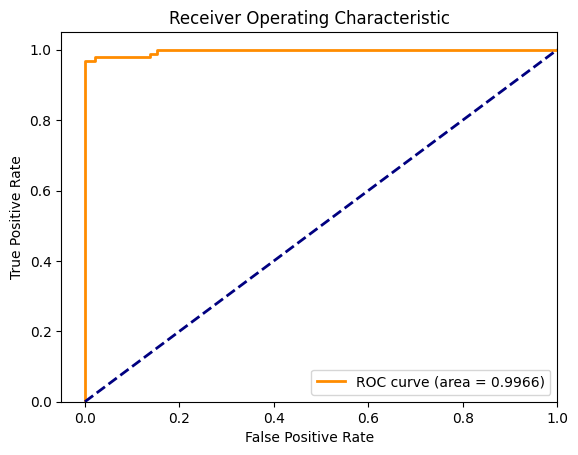

Best threshold: 0.27290451526641846


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

params = {
     'learning_rate': 0.04,
     'lambda': 0.003,
     'gamma': 0.95,
     'alpha': 0.14,
     'subsample': 0.65,
     'colsample_bytree': 0.6,
     'max_depth': 5,
     'min_child_weight': 20
}
params.update(MODEL_PARAMS)

model, best_score = train_batch_models(params, dtrain, verbose_eval=50)
print(f"Best train accuracy: {best_score:.3f}")

# Predict on reserved DataFrame
preds = model.predict(dval)
fpr, tpr, thr = roc_curve(y_test, preds, pos_label=1)
roc_auc = roc_auc_score(y_test, preds)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

minidx = np.argmin(np.sqrt((1 - tpr) ** 2 + fpr ** 2))
print(f"Best threshold: {thr[minidx]}")

#### Continue

In [19]:
# Train model with best params (on validation) on whole dataset

params = {
     'learning_rate': 0.04,
     'lambda': 0.003,
     'gamma': 0.95,
     'alpha': 0.14,
     'subsample': 0.65,
     'colsample_bytree': 0.6,
     'max_depth': 5,
     'min_child_weight': 20
}
params.update(MODEL_PARAMS)

X, y = df.drop("survived", axis=1).to_numpy(), df["survived"].to_numpy()
dtrain_all = xgb.DMatrix(X, label=y)

model, best_score = train_batch_models(params, dtrain_all, verbose_eval=50)

print(f"Best train F1: {best_score:.3f}")

THRESHOLD = 0.3

# Predict on reserved DataFrame
reserved_X = reserved_df.to_numpy()
preds = model.predict(xgb.DMatrix(reserved_X))
preds_classes = (preds >= THRESHOLD).astype(int)

[0]	train-logloss:0.66091	train-f1:0.00000
[50]	train-logloss:0.20088	train-f1:0.96760
[0]	train-logloss:0.63113	train-f1:0.00000
[50]	train-logloss:0.18890	train-f1:0.96760
[0]	train-logloss:0.65156	train-f1:0.00000
[50]	train-logloss:0.16318	train-f1:0.96760
[0]	train-logloss:0.63099	train-f1:0.00000
[50]	train-logloss:0.17065	train-f1:0.96760
[0]	train-logloss:0.65441	train-f1:0.00000
[50]	train-logloss:0.17102	train-f1:0.96760
[0]	train-logloss:0.65122	train-f1:0.00000
[50]	train-logloss:0.19193	train-f1:0.96760
[0]	train-logloss:0.65149	train-f1:0.00000
[50]	train-logloss:0.17119	train-f1:0.96760
[0]	train-logloss:0.63129	train-f1:0.00000
[50]	train-logloss:0.19621	train-f1:0.96760
[0]	train-logloss:0.63072	train-f1:0.00000
[50]	train-logloss:0.17165	train-f1:0.96760
[0]	train-logloss:0.63131	train-f1:0.00000
[50]	train-logloss:0.18560	train-f1:0.96760
Best train F1: 0.968


In [20]:
print(preds_classes.tolist())

[1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]


Получился итоговый F1 на резерве = 0.9565

## Сверточные нейронные сети. Упражнение 7

In [ ]:
%pip install torchvision

In [2]:
import os
from os.path import exists, join, basename, splitext

import random
import PIL
import torchvision
import cv2
import numpy as np
import torch
torch.set_grad_enabled(False)
  
import time
import matplotlib
import matplotlib.pylab as plt
plt.rcParams["axes.grid"] = False

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model = model.eval().cpu()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [40]:
!wget https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/Computer_Vision/Task_5/Files_for_task/Comp_Vision_Task_5_File_7.jpg -O datasets/cv_image.jpg

--2025-11-25 16:54:34--  https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/Computer_Vision/Task_5/Files_for_task/Comp_Vision_Task_5_File_7.jpg
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 181227 (177K) [image/jpeg]
Saving to: ‘datasets/cv_image.jpg’

datasets/cv_image.j 100%[===================>] 176.98K  --.-KB/s    in 0.07s   

2025-11-25 16:54:34 (2.41 MB/s) - ‘datasets/cv_image.jpg’ saved [181227/181227]



In [3]:
IMAGE_PATH = "datasets/cv_image.jpg"

In [4]:
t = time.time()
image = PIL.Image.open(IMAGE_PATH)
image_tensor = torchvision.transforms.functional.to_tensor(image).cpu()
output = model([image_tensor])[0]
print('Время распознавания: %.3fs' % (time.time() - t))

Время распознавания: 1.840s


In [5]:
coco_names = ['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

In [6]:
output.keys()

dict_keys(['boxes', 'labels', 'scores', 'masks'])

In [40]:
max_area_id = output['masks'].sum(axis=(1, 2, 3)).argmax()
print("Label:", coco_names[output['labels'][max_area_id]])
print("Score:", round(float(output['scores'][max_area_id]), 3))

Label: person
Score: 1.0


In [28]:
area_ratio = output['masks'][max_area_id].sum() / (image.size[0] * image.size[1])
print(f"Доля площади выбранного объекта: {area_ratio:.3f}")

Доля площади выбранного объекта: 0.020


In [39]:
print("X левого верхнего:", round(float(output['boxes'][max_area_id][0])))
print("Y левого верхнего:", round(float(output['boxes'][max_area_id][1])))
print("X правого нижнего:", round(float(output['boxes'][max_area_id][2])))
print("Y правого нижнего:", round(float(output['boxes'][max_area_id][3])))
print("Ширина:", round(float(output['boxes'][max_area_id][2] - output['boxes'][max_area_id][0])))
print("Высота:", round(float(output['boxes'][max_area_id][3] - output['boxes'][max_area_id][1])))

X левого верхнего: 544
Y левого верхнего: 27
X правого нижнего: 608
Y правого нижнего: 169
Ширина: 64
Высота: 142


Это всё, но вот можно ещё поглядеть на боксы

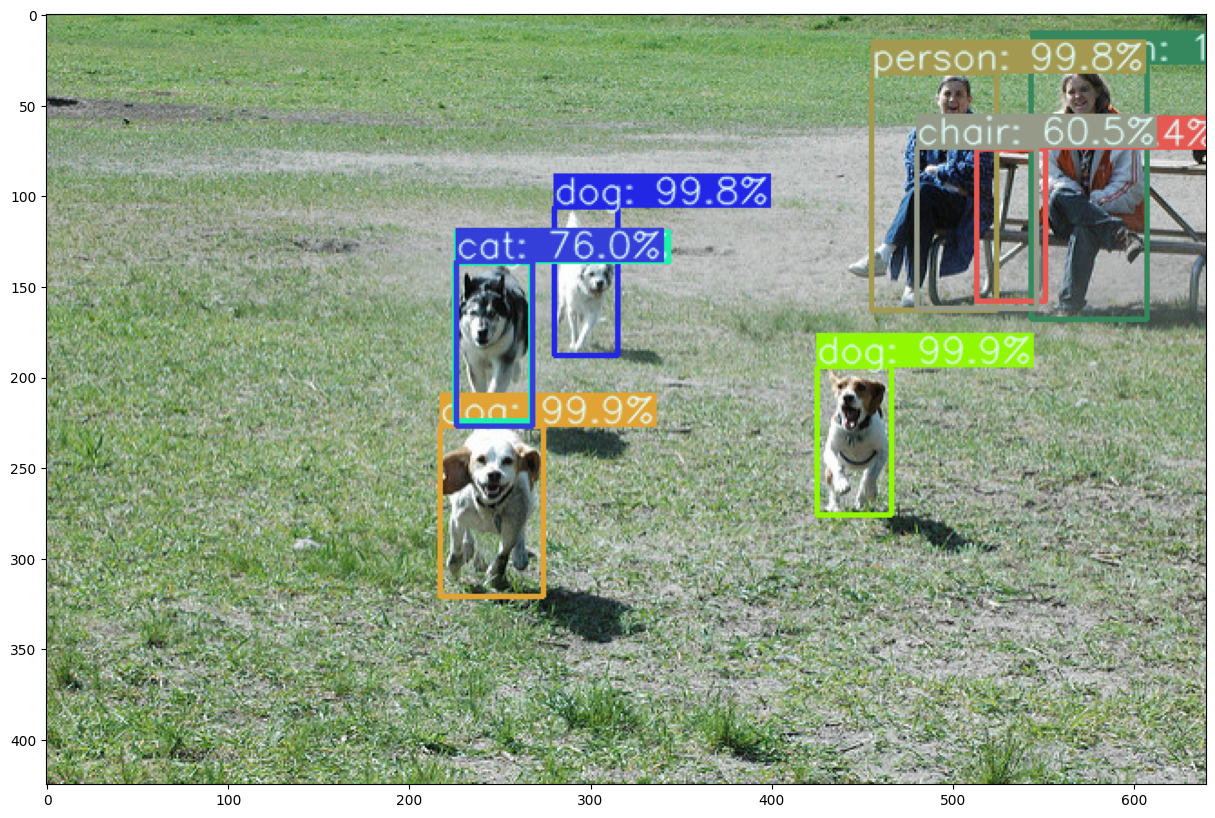

In [33]:
result = {}
result['masks'] = []
result['labels'] = []
result['scores'] = []
result['boxes'] = []

for i in range(len(output['scores'])):
  if output['scores'][i] <= 0.5:
    continue
  # Исправляем маски
  one_mask = output['masks'][i][0].cpu().numpy()
  one_mask[one_mask >= np.max(one_mask) * 0.5] = 1
  one_mask[one_mask < np.max(one_mask) * 0.5] = 0
  result['masks'].append(one_mask)
  # Исправляем коробки
  result['boxes'].append(output['boxes'][i].int().cpu().numpy())
  # Добавляем остальное
  result['scores'].append(output['scores'][i].cpu().numpy())
  result['labels'].append(output['labels'][i].cpu().numpy())

colors = [[random.randint(0, 255) for _ in range(3)] for _ in coco_names]

result_image = np.array(image.copy())
for box, label, score, mask in zip(result['boxes'], result['labels'], result['scores'], result['masks']):
  color = random.choice(colors)
  
  # draw box
  tl = round(0.002 * max(result_image.shape[0:2])) + 1  # line thickness
  c1, c2 = (box[0], box[1]), (box[2], box[3])
  cv2.rectangle(result_image, c1, c2, color, thickness=tl)
  # draw text
  display_txt = "%s: %.1f%%" % (coco_names[label], 100*score)
  tf = max(tl - 1, 1)  # font thickness
  t_size = cv2.getTextSize(display_txt, 0, fontScale=tl / 3, thickness=tf)[0]
  c2 = c1[0] + t_size[0], c1[1] - t_size[1] - 3
  cv2.rectangle(result_image, c1, c2, color, -1)  # filled
  cv2.putText(result_image, display_txt, (c1[0], c1[1] - 2), 0, tl / 3, [225, 255, 255], thickness=tf, lineType=cv2.LINE_AA)
  
plt.figure(figsize=(15, 10))
plt.imshow(result_image)

## Рекурентные НС. Упражнение 9

In [ ]:
%pip install gdown gensim gunzip unzip

In [26]:
# Скачиваем модель
! gdown --id 0B7XkCwpI5KDYNlNUTTlSS21pQmM
! gunzip GoogleNews-vectors-negative300.bin.gz

/opt/conda/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM
From (redirected): https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM&confirm=t&uuid=f057c1a6-4227-4f50-a80b-7cf8094bf933
To: /home/jovyan/work/digital_culture/sem1/GoogleNews-vectors-negative300.bin.gz
100%|██████████████████████████████████████| 1.65G/1.65G [02:41<00:00, 10.2MB/s]


In [35]:
# И вторую модель
! wget -c http://vectors.nlpl.eu/repository/20/0.zip
import zipfile
with zipfile.ZipFile('0.zip', 'r') as zip_ref:
    zip_ref.extractall('./british_model/')

In [2]:
import gensim
from gensim.models import KeyedVectors

In [3]:
GN_word_vec = KeyedVectors.load_word2vec_format(
    "GoogleNews-vectors-negative300.bin", binary=True
)
BR_word_vec = KeyedVectors.load_word2vec_format(
    "british_model/model.bin", binary=True
)

In [4]:
# Задание 1

WORDS = ['professor', 'student']

print("GN distance:", GN_word_vec.distance(*WORDS))
br_words = [f'{w}_NOUN' for w in WORDS]
print("BR distance:", BR_word_vec.distance(*br_words))

GN distance: 0.5793382
BR distance: 0.5742735


In [4]:
WORDS = ['professor', 'student', 'smart', 'wood']

print("GN distance:", GN_word_vec.doesnt_match(WORDS))
br_words = [f'{w}_NOUN' for w in WORDS]
print("BR distance:", BR_word_vec.doesnt_match(br_words))

GN distance: wood
BR distance: wood_NOUN


In [5]:
# Только для модели GN
from sklearn.metrics.pairwise import cosine_distances
SENTENCES = [
    'fool his money are soon parted',
    'journey thousand miles begins with single step'
]

sentances_vec = [
    np.mean(np.array([GN_word_vec[word] for word in sent.split()]), axis=0)
    for sent in SENTENCES
]

dists = cosine_distances(sentances_vec[0:1], sentances_vec[1:2])
print(dists[0][0])

0.6541218


In [7]:
# Скачиваем датасет
!wget https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/Text_Processing/Task_6/wordsim_similarity_goldstandard.txt -O datasets/wordsim_similarity_goldstandard.txt

--2025-11-27 12:48:12--  https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/Text_Processing/Task_6/wordsim_similarity_goldstandard.txt
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4002 (3.9K) [text/plain]
Saving to: ‘datasets/wordsim_similarity_goldstandard.txt’

datasets/wordsim_si 100%[===================>]   3.91K  --.-KB/s    in 0s      

2025-11-27 12:48:12 (1.86 GB/s) - ‘datasets/wordsim_similarity_goldstandard.txt’ saved [4002/4002]



In [49]:
DATASET_PATH = 'datasets/wordsim_similarity_goldstandard.txt'

df = pd.read_csv(DATASET_PATH, sep="\t", header=None)
df.columns = ["first", "second", "score"]
df.head(3)

,first,second,score
0,tiger,cat,7.35
1,tiger,tiger,10.00
2,plane,car,5.77


In [50]:
SUB_DF_RANGE = (18, 118)
df = df.iloc[SUB_DF_RANGE[0]:SUB_DF_RANGE[1]]
df.shape

(100, 3)

In [51]:
# Фильтруем, оставляет только те, что есть в британском словаре
gn_dist, br_dist, orig_scores  = [], [], []
save_idx = []

for idx, row in df.iterrows():
    br_first_word = row['first'].lower() + "_NOUN"
    br_second_word = row['second'].lower() + "_NOUN"
    is_first_in = br_first_word in BR_word_vec
    is_second_in = br_second_word in BR_word_vec
    if is_first_in and is_second_in:
        gn_dist.append(GN_word_vec.similarity(row['first'], row['second']))
        br_dist.append(BR_word_vec.similarity(br_first_word, br_second_word))
        orig_scores.append(row['score'])
        save_idx.append(idx)
    else:
        print(f"Removing {idx}: {row['first']} {'' if is_first_in else 'not '}in, {row['second']} {'' if is_second_in else 'not '}in")

print("Num deleted:", len(df) - len(save_idx))
df = df.loc[save_idx]
df.shape

Removing 21: Arafat not in, Jackson not in
Removing 68: Harvard not in, Yale not in
Removing 94: Mexico not in, Brazil in
Num deleted: 3


(97, 3)

In [53]:
from scipy.stats import spearmanr

print("Коэф. корреляции Спирмена для GN:", round(spearmanr(gn_dist, orig_scores).statistic, 3))
print("Коэф. корреляции Спирмена для BR:", round(spearmanr(br_dist, orig_scores).statistic, 3))

Коэф. корреляции Спирмена для GN: 0.719
Коэф. корреляции Спирмена для BR: 0.676


In [48]:
GN_word_vec.distance('american', 'American')

np.float32(0.60907495)

# Экзамен

## Пробный пример

In [1]:
DATASET_PATH = "datasets/MNIST_train.csv.zip" 
TEST_DATASET_PATH = "datasets/MNIST_test.csv.zip"

In [11]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
CSV_FILENAME = "MNIST_train.csv"
TEST_CSV_FIELNAME = "MNIST_test.csv"

with zipfile.ZipFile(DATASET_PATH) as z:
    with z.open(CSV_FILENAME) as f:
        df = pd.read_csv(f)

with zipfile.ZipFile(TEST_DATASET_PATH) as z:
    with z.open(TEST_CSV_FIELNAME) as f:
        test_df = pd.read_csv(f)

print(df.shape)
print(test_df.shape)

df.head()

(60000, 785)
(10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
TARGET_CLASSES = [2, 9]

df = df[df['label'].isin(TARGET_CLASSES)]
test_df = test_df[test_df['label'].isin(TARGET_CLASSES)]

print(df.shape)
print(test_df.shape)

(11907, 785)
(2041, 785)


In [8]:
TARGET_VARIENCE = 0.8

n_components = min(df.shape) - 1

pca = PCA(n_components=n_components, svd_solver='full')
pca.fit(df.drop('label', axis=1))

evr_cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(evr_cumsum > TARGET_VARIENCE) + 1
print("M =", n_components)

M = 40


In [24]:
COMPONENT_NUMBER = 9
IMAGE_NUMBER = 10

pca = PCA(n_components=n_components, svd_solver='full')

X_pca = pca.fit_transform(df.drop('label', axis=1))
X_test_pca = pca.transform(test_df.drop('label', axis=1))

# Нумерация с 0, так что вычитаем 1
print(round(X_pca[IMAGE_NUMBER - 1, COMPONENT_NUMBER - 1], 3))

-179.73


In [15]:
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
    n_estimators=300,
    learning_rate=0.5,
    random_state=3
)
model.fit(X_pca, df['label'].to_numpy())

preds = model.predict(X_test_pca)

print(classification_report(test_df['label'].to_numpy(), preds, digits=3))

              precision    recall  f1-score   support

           2      0.991     0.993     0.992      1032
           9      0.993     0.991     0.992      1009

    accuracy                          0.992      2041
   macro avg      0.992     0.992     0.992      2041
weighted avg      0.992     0.992     0.992      2041



In [21]:
tn, fp, fn, tp = confusion_matrix(test_df['label'].to_numpy(), preds).ravel().tolist()
print(
    "Results:\n",
    "True Negative:", tn, '\n',
    "False Positive:", fp, '\n',
    "False Negative:", fn, '\n',
    "True Positive:", tp,
)

Results:
 True Negative: 1025 
 False Positive: 7 
 False Negative: 9 
 True Positive: 1000
